# Luyoa — Exploratory Data Analysis (EDA)
### Proyecto Integrador · Maestría en Inteligencia Artificial Aplicada · Tecnológico de Monterrey

| Campo | Detalle |
|---|---|
| **Empresa** | Luyoa — Digital loyalty card platform (Spain & Mexico) |
| **Variable objetivo** | `businesses.active` — B2B churn: ¿el negocio suscrito a Luyoa sigue activo? |
| **Sponsor** | Gabriela Soria, Luyoa |
| **Integrantes** | Sergio Sebastián Guzman Guerrero A01370820, Enrique Correa Herrerías A01332620, Nicolás Felipe Araque Araque A01795483|
| **Dataset** | Datos sintéticos generados mediante data augmentation (Anexo 1 — EsquemaBBDD_Luyoa) |
| **Periodo de análisis** | Últimos 2 años |

---

## Estructura del notebook

1. Configuración y carga de datos  
2. **Sección A — Feature Engineering desde tablas raw** *(path para datos reales de Luyoa)*  
3. Análisis univariante  
4. Análisis bivariante / multivariante  
5. Valores faltantes y patrones de ausencia  
6. Valores atípicos (outliers)  
7. Cardinalidad de variables categóricas  
8. Distribuciones, sesgo y transformaciones  
9. Tendencias temporales  
10. Correlaciones  
11. Balance de clases (variable objetivo)  
12. Preprocesamiento final  
13. **Sección B — Anexo metodológico: uso de churn_master_table sintética**  
14. Conclusiones del EDA

> ⚠️ **Nota metodológica:** La Sección A es el camino obligatorio para datos reales.  
> La Sección B documenta el uso de la tabla feature-engineered sintética y es opcional.


## 0. Configuración y librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
from scipy.stats import skew
from scipy.stats.mstats import winsorize



try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False
    print("missingno not installed — missing value matrix will use fallback.")

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE_BINARY = ['#2196F3', '#F44336']   # active=blue, inactive=red
PALETTE_CAT    = sns.color_palette('tab10')
sns.set_theme(style='whitegrid', palette='tab10')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── CONFIGURACIÓN DE RUTA ────────────────────────────────────────────────────────
# Incluir dirección de la carpeta ZIP con el conjunto de datos
DATA_DIR = r'C:\Users\ASUS1\OneDrive - Vlogos Analytics (1)\Grupo AR\Respaldos Nicolás\MNA Tec Monterrey\Proyecto Integrador\Entregas\Avance 1. Análisis Exploratorio EDA\luyoa_v2_datasets\luyoa_v2'          # <-- Ajustar aquí

def load(table):
    """Cargar las tablas de Luyoa en CSV hacia a DataFrame."""
    path = os.path.join(DATA_DIR, f'{table}.csv')
    return pd.read_csv(path, low_memory=False)

# ── LOAD ALL TABLES ───────────────────────────────────────────────────────────
businesses          = load('businesses')
business_branches   = load('business_branches')
customers           = load('customers')
transactions        = load('transactions')
rewards             = load('rewards')
rewards_transactions= load('rewards_transactions')
push_notifications  = load('push_notifications')
pn_customers        = load('push_notifications_customers')
reviews             = load('reviews')
raffles             = load('raffles')
raffle_entries      = load('raffle_entries')
integration_tokens  = load('integration_tokens')
automated_pn        = load('automated_push_notifications')
users               = load('users')
reward_triggers     = load('reward_triggers')
countries           = load('countries')
cities              = load('cities')

print(f"Businesses (Luyoa clients) : {len(businesses):,}")
print(f"Customers (end-consumers)  : {len(customers):,}")
print(f"Transactions               : {len(transactions):,}")
print(f"Rewards transactions       : {len(rewards_transactions):,}")
print(f"Reviews                    : {len(reviews):,}")

Businesses (Luyoa clients) : 500
Customers (end-consumers)  : 51,220
Transactions               : 1,055,061
Rewards transactions       : 213,929
Reviews                    : 10,295


## Creación del conjunto de datos

En función de la primera sesión de tutoría, se utilizo claude (moelo sonnet 4.6) para meidante una técnica de data augmentation crear un conjunto de datos sintético en base 
al esquema de la base de datos de Luya, el esquema se adjunta en imagen a continuación. 

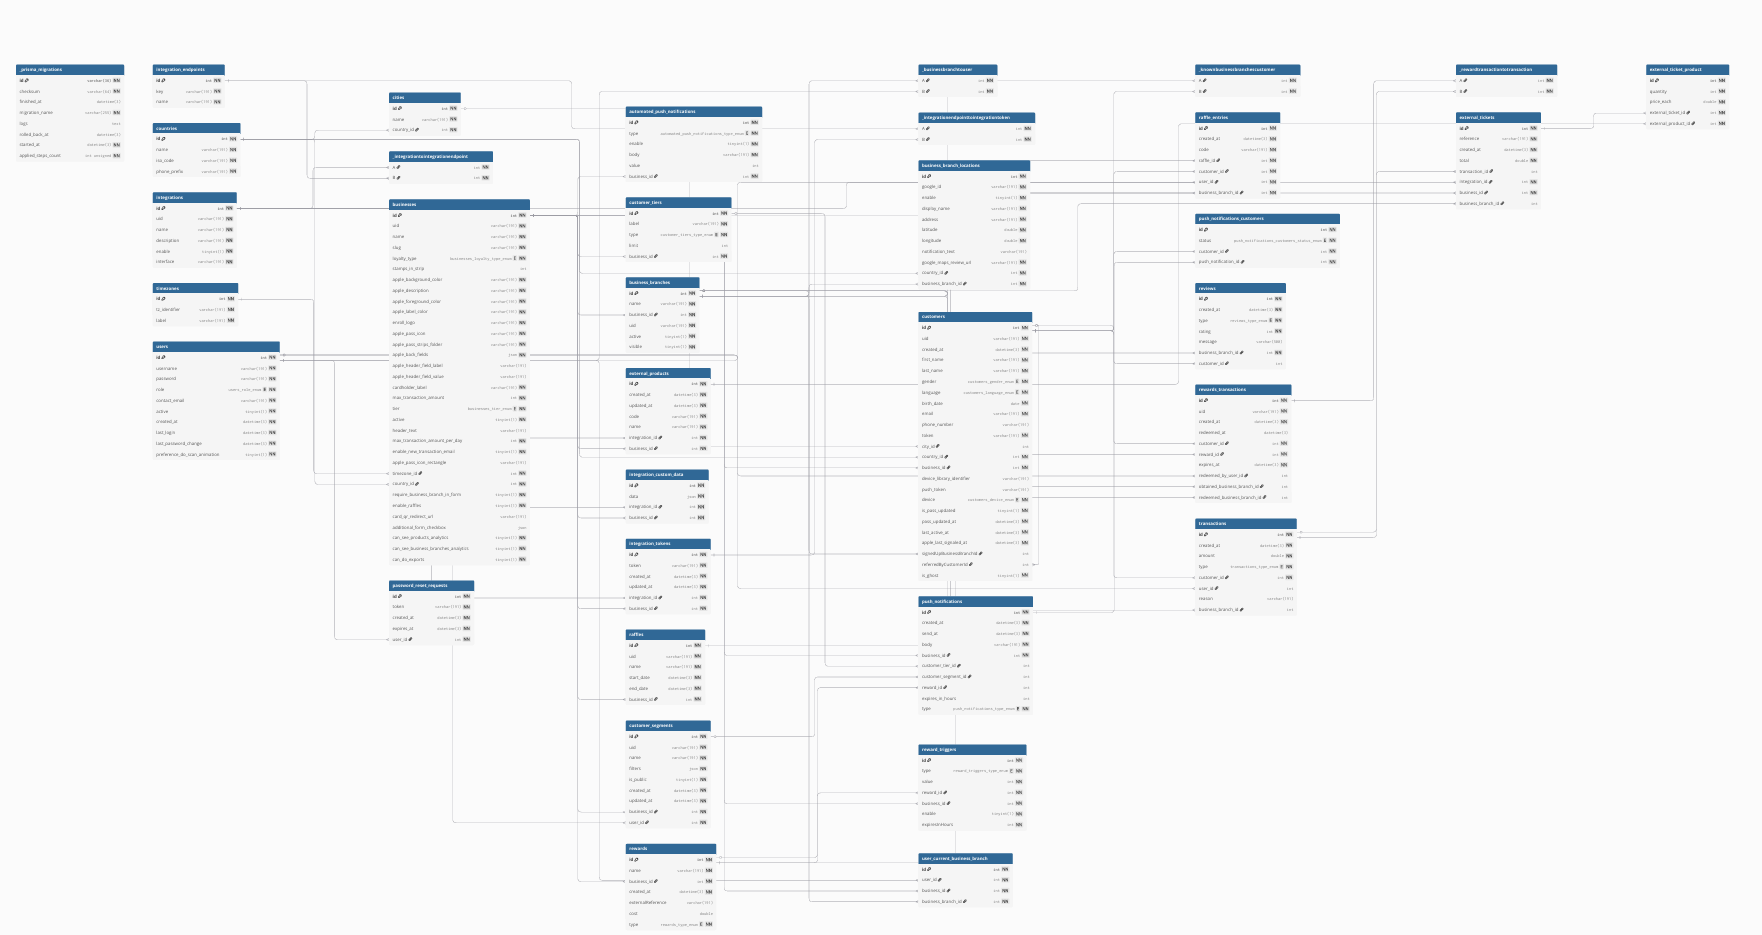

---
## Sección A — Preparación de datos previo al análisis exploratorio.

### Construcción de relaciones previo a integración en esquema relacional.
#### Construcción de la tabla analítica e integración de datos. 

> **Este es el camino obligatorio para datos reales de Luyoa.**  
> Se construye una tabla analítica a nivel `business_id` agregando información  
> de todas las tablas relacionadas. El resultado es un DataFrame con una fila  
> por negocio y la variable target `active`.
> Se deja el camino abierto, en caso de poder acceder a los datos de Luyoa y procesarlos directamente ajustan la fuente de datos. 

### A.1 — Parse de fechas

In [3]:
# Parse datetime columns
DT_COLS = {
    'businesses':            [],
    'customers':             ['created_at','last_active_at','pass_updated_at'],
    'transactions':          ['created_at'],
    'rewards_transactions':  ['created_at','redeemed_at','expires_at'],
    'push_notifications':    ['created_at','send_at'],
    'reviews':               ['created_at'],
    'raffle_entries':        ['created_at'],
    'integration_tokens':    ['created_at','updated_at'],
    'users':                 ['created_at','last_login','last_password_change'],
}

def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

customers           = parse_dates(customers,           DT_COLS['customers'])
transactions        = parse_dates(transactions,         DT_COLS['transactions'])
rewards_transactions= parse_dates(rewards_transactions, DT_COLS['rewards_transactions'])
push_notifications  = parse_dates(push_notifications,  DT_COLS['push_notifications'])
reviews             = parse_dates(reviews,              DT_COLS['reviews'])
raffle_entries      = parse_dates(raffle_entries,       DT_COLS['raffle_entries'])
integration_tokens  = parse_dates(integration_tokens,  DT_COLS['integration_tokens'])
users               = parse_dates(users,                DT_COLS['users'])

NOW = pd.Timestamp.now()
print("Dates parsed.")

Dates parsed.


### A.2 — Integración por bloque

Se integra cada parte del dataset en bloques según descripción

In [4]:
# ── BLOQUE 1: Features directas de businesses ─────────────────────────────────
biz = businesses[[
    'id','active','tier','loyalty_type','country_id',
    'enable_raffles','enable_new_transaction_email',
    'can_see_products_analytics','can_see_business_branches_analytics','can_do_exports',
    'require_business_branch_in_form','max_transaction_amount','max_transaction_amount_per_day',
    'stamps_in_strip','timezone_id',
]].copy()

biz.rename(columns={'id':'business_id'}, inplace=True)
biz['active'] = biz['active'].astype(int)
biz['stamps_in_strip'] = pd.to_numeric(biz['stamps_in_strip'], errors='coerce').fillna(0)

print(f"Base businesses shape: {biz.shape}")
biz.head(3)

Base businesses shape: (500, 15)


,business_id,active,tier,loyalty_type,country_id,enable_raffles,enable_new_transaction_email,can_see_products_analytics,can_see_business_branches_analytics,can_do_exports,require_business_branch_in_form,max_transaction_amount,max_transaction_amount_per_day,stamps_in_strip,timezone_id
0,1,0,STARTER,STAMPS,1,1,0,0,0,0,0,5000,10000,6.0,1
1,2,1,STARTER,BALANCE,2,0,0,0,0,0,1,2000,4000,0.0,4
2,3,1,GROW,BALANCE,1,1,1,1,1,1,0,200,1000,0.0,1


In [5]:
# ── BLOQUE 2: Branches ────────────────────────────────────────────────────────
br_agg = (business_branches
    .groupby('business_id')
    .agg(
        n_branches          = ('id',     'count'),
        n_active_branches   = ('active', 'sum'),
    )
    .reset_index()
)
br_agg['branch_active_ratio'] = (
    br_agg['n_active_branches'] / br_agg['n_branches']
).round(3)

# ── BLOQUE 3: Customers ───────────────────────────────────────────────────────
cust_agg = (customers
    .groupby('business_id')
    .agg(
        total_customers         = ('id',              'count'),
        ghost_ratio             = ('is_ghost',         'mean'),
        apple_device_ratio      = ('device',           lambda x: (x=='APPLE').mean()),
        has_push_token_ratio    = ('push_token',       lambda x: x.astype(bool).mean()),
        is_pass_updated_ratio   = ('is_pass_updated',  'mean'),
        referred_ratio          = ('referredByCustomerId',
                                   lambda x: x.notna().mean()),
        days_since_last_active  = ('last_active_at',
                                   lambda x: (NOW - x.max()).days),
        avg_customer_tenure_days= ('created_at',
                                   lambda x: (NOW - x).dt.days.mean()),
    )
    .reset_index()
    .round(3)
)

active_30d = (customers[customers['last_active_at'] >= NOW - pd.Timedelta(days=30)]
              .groupby('business_id')['id'].count()
              .rename('active_customers_30d').reset_index())
cust_agg = cust_agg.merge(active_30d, on='business_id', how='left')
cust_agg['active_customers_30d'] = cust_agg['active_customers_30d'].fillna(0).astype(int)
cust_agg['active_ratio_30d'] = (
    cust_agg['active_customers_30d'] / cust_agg['total_customers']
).round(3)

print(f"Customer agg shape: {cust_agg.shape}")

Customer agg shape: (500, 11)


In [6]:
# ── BLOQUE 4: Transactions ────────────────────────────────────────────────────
# Map branch -> business
br_map = business_branches.set_index('id')['business_id'].to_dict()
transactions['business_id'] = transactions['business_branch_id'].map(br_map)
transactions.dropna(subset=['business_id'], inplace=True)
transactions['business_id'] = transactions['business_id'].astype(int)

dep = transactions[transactions['type']=='DEPOSIT']
wth = transactions[transactions['type']=='WITHDRAW']

dep_agg = (dep.groupby('business_id')
    .agg(
        n_deposits          = ('id',         'count'),
        total_deposited     = ('amount',     'sum'),
        avg_deposit_amount  = ('amount',     'mean'),
        max_deposit_amount  = ('amount',     'max'),
        last_tx_days_ago    = ('created_at', lambda x: (NOW - x.max()).days),
    )
    .reset_index().round(2)
)
wth_agg = (wth.groupby('business_id')['id']
    .count().rename('n_withdrawals').reset_index()
)

tx_agg = dep_agg.merge(wth_agg, on='business_id', how='left')
tx_agg['n_withdrawals'] = tx_agg['n_withdrawals'].fillna(0).astype(int)
tx_agg['deposit_withdraw_ratio'] = (
    tx_agg['n_deposits'] / (tx_agg['n_withdrawals'] + 1)
).round(3)

print(f"Transaction agg shape: {tx_agg.shape}")

Transaction agg shape: (500, 8)


In [7]:
# ── BLOQUE 5: Rewards & Reviews ───────────────────────────────────────────────
# Rewards per business (via rewards table)
rew_by_biz = (rewards.groupby('business_id')['id']
              .count().rename('n_reward_types').reset_index())

# Redemptions per business (via rewards_transactions -> rewards)
rew_join = rewards_transactions.merge(
    rewards[['id','business_id']], left_on='reward_id', right_on='id', how='left'
)
rt_agg = (rew_join.groupby('business_id')
    .agg(
        n_rewards_issued    = ('id_x',        'count'),
        n_rewards_redeemed  = ('redeemed_at', lambda x: x.notna().sum()),
        reward_expiry_ratio = ('expires_at',
                               lambda x: (pd.to_datetime(x, errors='coerce') < NOW).mean()),
    )
    .reset_index().round(3)
)
rt_agg['redemption_rate'] = (
    rt_agg['n_rewards_redeemed'] / (rt_agg['n_rewards_issued'] + 1)
).round(3)

# Reviews per business (via business_branches)
reviews['business_id'] = reviews['business_branch_id'].map(br_map)
reviews.dropna(subset=['business_id'], inplace=True)
reviews['business_id'] = reviews['business_id'].astype(int)

rev_agg = (reviews.groupby('business_id')
    .agg(
        n_reviews        = ('id',     'count'),
        avg_review_rating= ('rating', 'mean'),
    )
    .reset_index().round(3)
)

print(f"Reward types agg : {rew_by_biz.shape}")
print(f"Reward txn agg   : {rt_agg.shape}")
print(f"Reviews agg      : {rev_agg.shape}")

Reward types agg : (500, 2)
Reward txn agg   : (500, 5)
Reviews agg      : (499, 3)


In [8]:
# ── BLOQUE 6: Push & Automation ───────────────────────────────────────────────
pn_agg = (push_notifications.groupby('business_id')['id']
          .count().rename('n_push_sent_90d').reset_index())

apn_agg = (automated_pn.groupby('business_id')
    .agg(
        uses_automation     = ('enable', 'max'),
        n_automation_types  = ('type',   'nunique'),
    )
    .reset_index()
)

# ── BLOQUE 7: Integrations ────────────────────────────────────────────────────
int_agg = (integration_tokens.groupby('business_id')
    .agg(
        has_integration     = ('id', lambda x: 1),
        n_integrations      = ('id', 'count'),
    )
    .reset_index()
)

# ── BLOQUE 8: Raffles ─────────────────────────────────────────────────────────
raffle_entries['business_id'] = raffle_entries['business_branch_id'].map(br_map)
raffle_entries.dropna(subset=['business_id'], inplace=True)
raffle_entries['business_id'] = raffle_entries['business_id'].astype(int)

raff_agg = (raffles.groupby('business_id')['id']
            .count().rename('n_raffles').reset_index())
raff_part = (raffle_entries.groupby('business_id')['id']
             .count().rename('n_raffle_entries').reset_index())

# ── BLOQUE 9: Staff ───────────────────────────────────────────────────────────
ucbb = load('user_current_business_branch')

staff_agg = (ucbb.groupby('business_id')
    .agg(n_staff=('user_id', 'nunique'))
    .reset_index()
)

# Admin login recency
admin_login = (ucbb
    .merge(users[['id', 'role', 'last_login']], left_on='user_id', right_on='id')
    .query("role in ('ADMIN', 'OWNER')")
    .groupby('business_id')['last_login']
    .max()
    .reset_index()
    .rename(columns={'last_login': 'admin_last_login'})
)
admin_login['admin_last_login'] = pd.to_datetime(admin_login['admin_last_login'], errors='coerce')
admin_login['admin_login_days_ago'] = (NOW - admin_login['admin_last_login']).dt.days

print("Staff agg:", staff_agg.shape)
print("Admin login agg:", admin_login.shape)

Staff agg: (500, 2)
Admin login agg: (500, 3)


In [9]:
# ── MERGE ALL BLOCKS ──────────────────────────────────────────────────────────
df = biz.copy()
for agg_df, key in [
    (br_agg,      'business_id'),
    (cust_agg,    'business_id'),
    (tx_agg,      'business_id'),
    (rew_by_biz,  'business_id'),
    (rt_agg,      'business_id'),
    (rev_agg,     'business_id'),
    (pn_agg,      'business_id'),
    (apn_agg,     'business_id'),
    (int_agg,     'business_id'),
    (raff_agg,    'business_id'),
    (raff_part,   'business_id'),
    (staff_agg,   'business_id'),
    (admin_login[['business_id','admin_login_days_ago']], 'business_id'),
]:
    df = df.merge(agg_df, on=key, how='left')

# Fill booleans & counters with 0
fill_zero = ['n_branches','n_active_branches','n_active_branches','total_customers',
             'active_customers_30d','n_deposits','n_withdrawals','n_rewards_issued',
             'n_rewards_redeemed','n_reviews','n_push_sent_90d','uses_automation',
             'n_automation_types','has_integration','n_integrations','n_raffles',
             'n_raffle_entries','n_staff','n_reward_types']
for c in fill_zero:
    if c in df.columns:
        df[c] = df[c].fillna(0)

df['has_integration']  = df['has_integration'].fillna(0).astype(int)
df['uses_automation']  = df['uses_automation'].fillna(0).astype(int)
df['country_id']       = df['country_id'].astype(int)

print(f"Final analytical DataFrame shape: {df.shape}")
print(f"Target distribution:\n{df['active'].value_counts()}")
df.head(3)

Final analytical DataFrame shape: (500, 51)
Target distribution:
active
1    480
0     20
Name: count, dtype: int64


,business_id,active,tier,loyalty_type,country_id,enable_raffles,enable_new_transaction_email,can_see_products_analytics,can_see_business_branches_analytics,can_do_exports,...,avg_review_rating,n_push_sent_90d,uses_automation,n_automation_types,has_integration,n_integrations,n_raffles,n_raffle_entries,n_staff,admin_login_days_ago
0,1,0,STARTER,STAMPS,1,1,0,0,0,0,...,4.125,4,1,4,0,0.0,1.0,33.0,4,22
1,2,1,STARTER,BALANCE,2,0,0,0,0,0,...,3.429,3,1,4,0,0.0,0.0,0.0,3,31
2,3,1,GROW,BALANCE,1,1,1,1,1,1,...,3.889,29,1,4,0,0.0,3.0,76.0,8,40


---
## 1. Vista general del dataset analítico

In [10]:
print("=== SHAPE ===")
print(f"Rows (businesses): {df.shape[0]}")
print(f"Columns (features): {df.shape[1]}")

print("\n=== DTYPES & NON-NULL COUNTS ===")
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notna().sum(),
    'null':     df.isna().sum(),
    'null_pct': (df.isna().mean()*100).round(1),
})
display(info)

=== SHAPE ===
Rows (businesses): 500
Columns (features): 51

=== DTYPES & NON-NULL COUNTS ===


,dtype,non_null,null,null_pct
business_id,int64,500,0,0.0
active,int64,500,0,0.0
tier,str,500,0,0.0
loyalty_type,str,500,0,0.0
country_id,int64,500,0,0.0
enable_raffles,int64,500,0,0.0
enable_new_transaction_email,int64,500,0,0.0
can_see_products_analytics,int64,500,0,0.0
can_see_business_branches_analytics,int64,500,0,0.0
can_do_exports,int64,500,0,0.0


In [11]:
print("=== ESTADÍSITICA DESCRIPTIVA — Numeric features ===")
display(df.describe(percentiles=[.05,.25,.5,.75,.95]).T.round(2))

=== ESTADÍSITICA DESCRIPTIVA — Numeric features ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
business_id,500.0,250.50,144.48,1.00,25.95,125.75,250.50,375.25,475.05,500.00
active,500.0,0.96,0.20,0.00,1.00,1.00,1.00,1.00,1.00,1.00
country_id,500.0,1.49,0.50,1.00,1.00,1.00,1.00,2.00,2.00,2.00
enable_raffles,500.0,0.34,0.47,0.00,0.00,0.00,0.00,1.00,1.00,1.00
enable_new_transaction_email,500.0,0.48,0.50,0.00,0.00,0.00,0.00,1.00,1.00,1.00
can_see_products_analytics,500.0,0.59,0.49,0.00,0.00,0.00,1.00,1.00,1.00,1.00
can_see_business_branches_analytics,500.0,0.59,0.49,0.00,0.00,0.00,1.00,1.00,1.00,1.00
can_do_exports,500.0,0.20,0.40,0.00,0.00,0.00,0.00,0.00,1.00,1.00
require_business_branch_in_form,500.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00,1.00,1.00
max_transaction_amount,500.0,1790.40,1769.30,200.00,200.00,500.00,1000.00,2000.00,5000.00,5000.00


In [12]:
print("=== ESTADÍSTICAS DESCRIPTIVA— Categorical features ===")
cat_cols = df.select_dtypes(include='object').columns.tolist()
display(df[cat_cols].describe())

=== ESTADÍSTICAS DESCRIPTIVA— Categorical features ===


,tier,loyalty_type
count,500,500
unique,3,3
top,STARTER,BALANCE
freq,203,267


---
## 2. Variable objetivo — `active` (B2B churn)

`active = 1` → el negocio sigue suscrito a Luyoa (no churned)  
`active = 0` → el negocio canceló o está inactivo (churned)

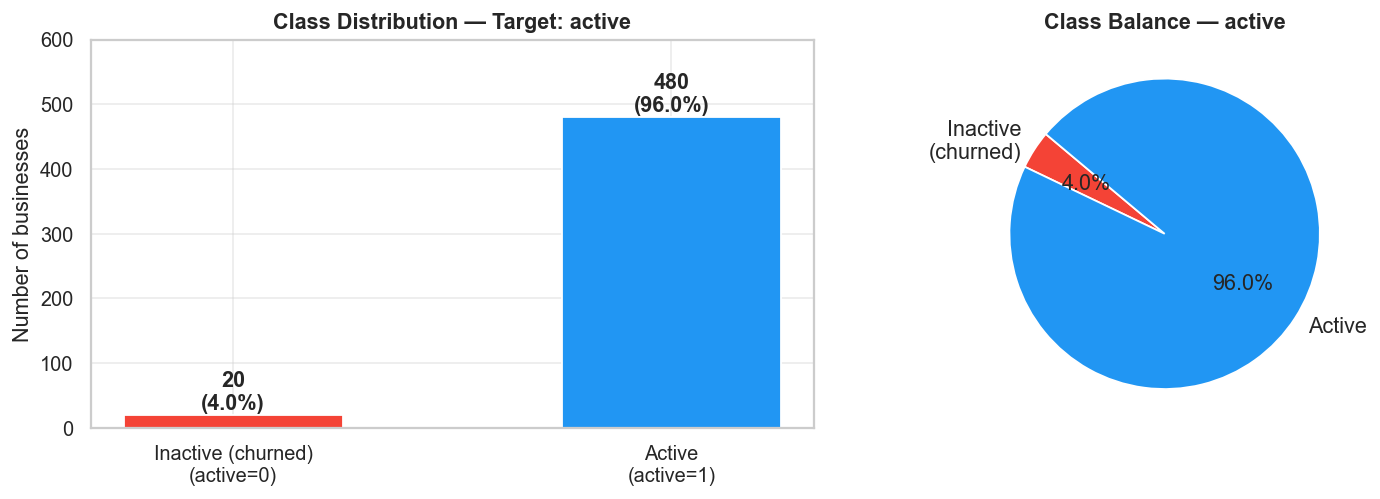


Imbalance ratio: 24.00:1
>> HIGH IMBALANCE detected — consider SMOTE, class_weight, or threshold tuning.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
vc = df['active'].value_counts()
labels = ['Inactive (churned)\n(active=0)', 'Active\n(active=1)']
bars = axes[0].bar(labels, [vc.get(0,0), vc.get(1,0)],
                   color=PALETTE_BINARY[::-1], edgecolor='white', width=0.5)
for bar, val in zip(bars, [vc.get(0,0), vc.get(1,0)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution — Target: active')
axes[0].set_ylabel('Number of businesses')
axes[0].set_ylim(0, max(vc.values)*1.25)

# Pie chart
axes[1].pie([vc.get(0,0), vc.get(1,0)],
            labels=['Inactive\n(churned)', 'Active'],
            colors=PALETTE_BINARY[::-1],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':12})
axes[1].set_title('Class Balance — active')

plt.tight_layout()
plt.savefig('fig_01_target_distribution.png', bbox_inches='tight')
plt.show()

imbalance_ratio = vc.max() / vc.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print(">> HIGH IMBALANCE detected — consider SMOTE, class_weight, or threshold tuning.")
elif imbalance_ratio > 1.5:
    print(">> MODERATE IMBALANCE — class_weight='balanced' recommended.")
else:
    print(">> Classes roughly balanced — no special handling required.")

## Clases desbalanceadas. 

Nos encontramos con un desbalance evidente en las clases para el análisis binario, lo cual es consistente considerando que es una startup que ha tenido un bajo abandono de parte
de los nuevos suscriptores. 

---
## 3. Valores faltantes

¿Hay valores faltantes? ¿Se identifican patrones de ausencia?

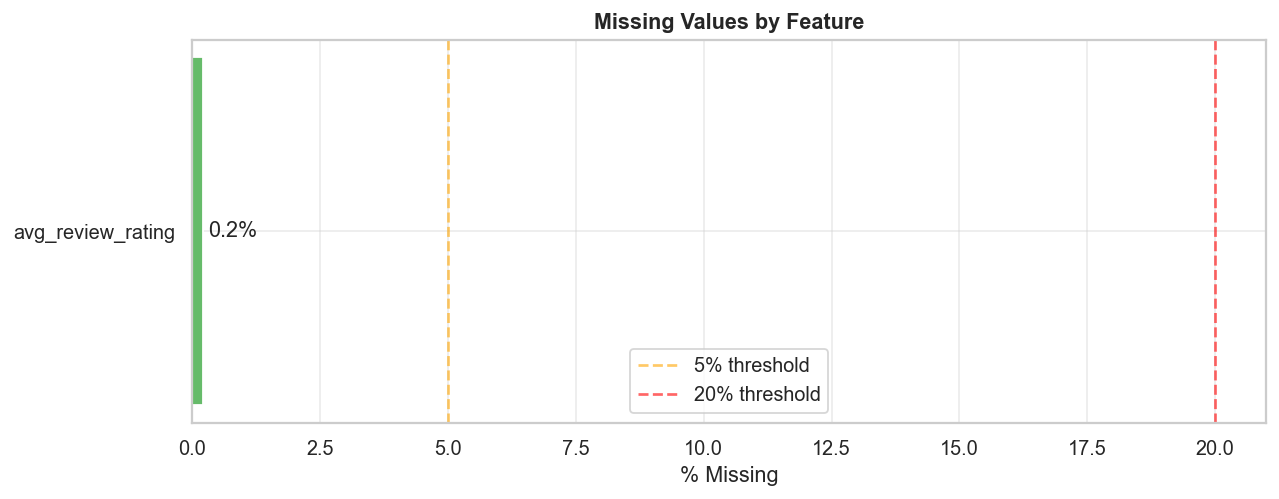

,feature,missing_pct
0,avg_review_rating,0.2


In [14]:
missing = df.isna().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(2)
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['feature','missing_pct']

if missing_df.empty:
    print("No missing values found in the analytical DataFrame.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.4)))
    colors = ['#EF5350' if v>20 else '#FFA726' if v>5 else '#66BB6A'
              for v in missing_df['missing_pct']]
    bars = ax.barh(missing_df['feature'], missing_df['missing_pct'],
                   color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.axvline(5,  color='orange', linestyle='--', alpha=0.6, label='5% threshold')
    ax.axvline(20, color='red',    linestyle='--', alpha=0.6, label='20% threshold')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Feature')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_02_missing_values.png', bbox_inches='tight')
    plt.show()
    display(missing_df)

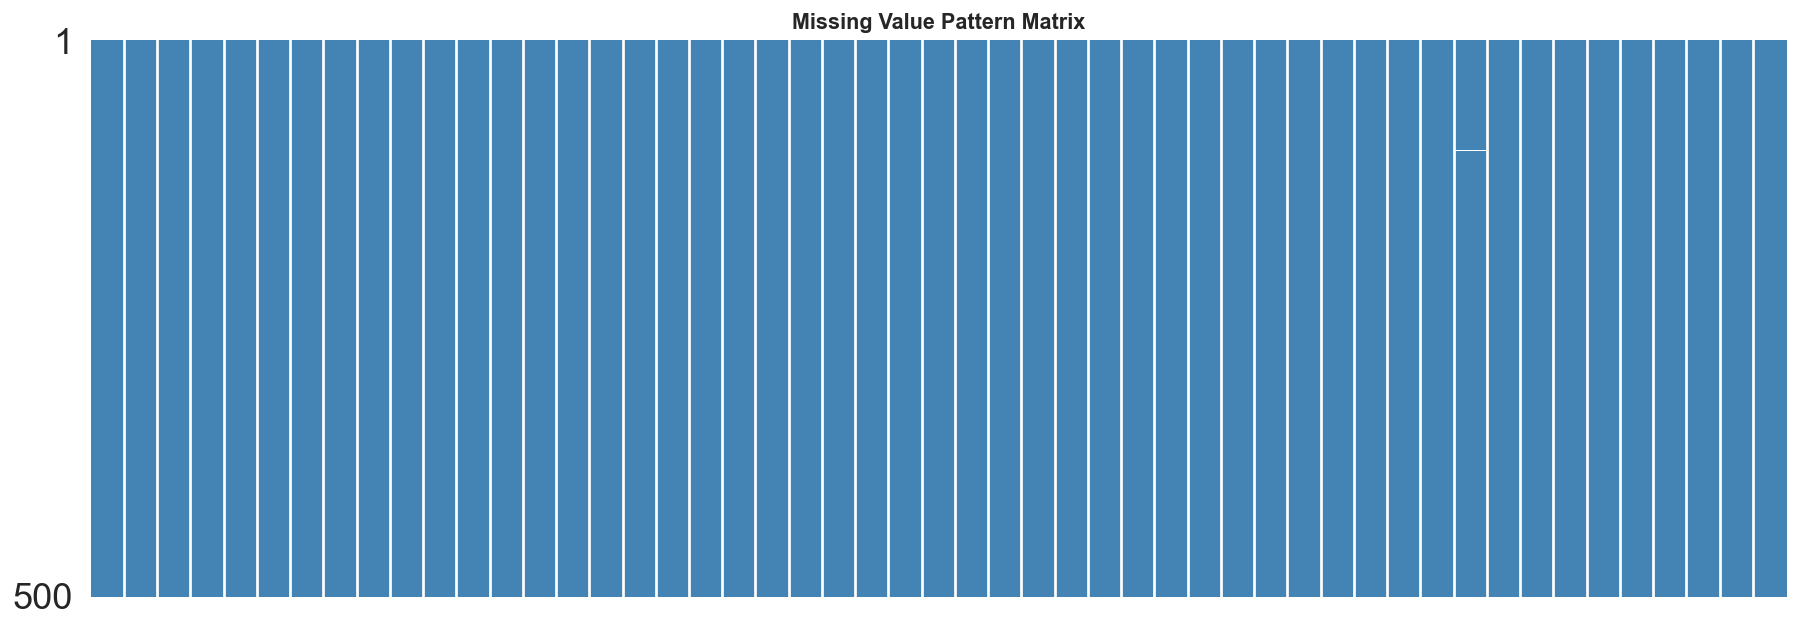

In [15]:
# Matríz de valores perdidos
if HAS_MSNO and df.isna().any().any():
    fig, ax = plt.subplots(figsize=(14, 5))
    msno.matrix(df, ax=ax, sparkline=False, color=(0.27, 0.52, 0.71))
    ax.set_title('Missing Value Pattern Matrix')
    plt.tight_layout()
    plt.savefig('fig_03_missing_matrix.png', bbox_inches='tight')
    plt.show()
else:

    corr_missing = df.isna().corr()
    if corr_missing.any().any():
        fig, ax = plt.subplots(figsize=(12,10))
        sns.heatmap(corr_missing, cmap='Reds', ax=ax, linewidths=0.3)
        ax.set_title('Missing Value Correlation (pattern)')
        plt.tight_layout()
        plt.savefig('fig_03_missing_pattern.png', bbox_inches='tight')
        plt.show()
    else:
        print("No missing value patterns to display.")

## Revisión y decisión posterior. 
El dataset analítico presenta una completitud superior al 99%. Se identifica un único valor faltante puntual en la variable admin_login_days_ago, correspondiente a negocios sin usuario administrador registrado en el período analizado. El patrón de ausencia es MCAR (Missing Completely At Random), por lo que se aplica imputación por mediana sin riesgo de introducir sesgo.

In [16]:
# ── ESTRATÉGIA PARA VALORES FALTANTES ───────────────────────────────────────────────────
# Numeric: fill with median (robust to outliers)
num_cols = df.select_dtypes(include='number').columns.difference(['active','business_id'])
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categórica: reemplazar por la  moda  or 'Desconocido'
cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    mode_val = df[c].mode()
    df[c] = df[c].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

print(f"Missing values remaining: {df.isna().sum().sum()}")
print("Strategy applied: numeric → median imputation | categorical → mode imputation")

Missing values remaining: 0
Strategy applied: numeric → median imputation | categorical → mode imputation


---
## 4. Análisis univariante — Variables numéricas

Distribuciones, sesgo, curtosis y detección de valores atípicos.

In [17]:
NUM_FEATURES = [
    'n_branches','total_customers','active_customers_30d','active_ratio_30d',
    'n_deposits','total_deposited','avg_deposit_amount','deposit_withdraw_ratio',
    'n_rewards_issued','n_rewards_redeemed','redemption_rate',
    'n_reviews','avg_review_rating','n_push_sent_90d',
    'n_integrations','n_raffles','n_staff',
    'ghost_ratio','apple_device_ratio','days_since_last_active',
    'avg_customer_tenure_days','admin_login_days_ago',
]
# Keep only columns that exist
NUM_FEATURES = [c for c in NUM_FEATURES if c in df.columns]

skew_df = pd.DataFrame({
    'skewness':  df[NUM_FEATURES].skew(),
    'kurtosis':  df[NUM_FEATURES].kurt(),
    'mean':      df[NUM_FEATURES].mean(),
    'median':    df[NUM_FEATURES].median(),
    'std':       df[NUM_FEATURES].std(),
}).round(3)
skew_df['high_skew'] = skew_df['skewness'].abs() > 1.0
display(skew_df.sort_values('skewness', ascending=False))

,skewness,kurtosis,mean,median,std,high_skew
total_deposited,3.163,12.733,125861.275,52317.885,191914.955,True
days_since_last_active,3.079,13.635,21.362,20.000,2.332,True
active_customers_30d,1.640,2.515,9.666,7.000,8.590,True
avg_deposit_amount,1.635,1.722,66.728,44.080,67.353,True
total_customers,1.563,2.009,102.440,67.000,84.666,True
deposit_withdraw_ratio,1.559,7.242,6.739,6.670,0.704,True
ghost_ratio,1.536,6.760,0.044,0.042,0.029,True
n_rewards_issued,1.536,1.907,427.858,293.000,359.089,True
n_deposits,1.527,1.831,1835.900,1276.500,1529.698,True
n_rewards_redeemed,1.514,1.808,265.070,182.500,221.908,True


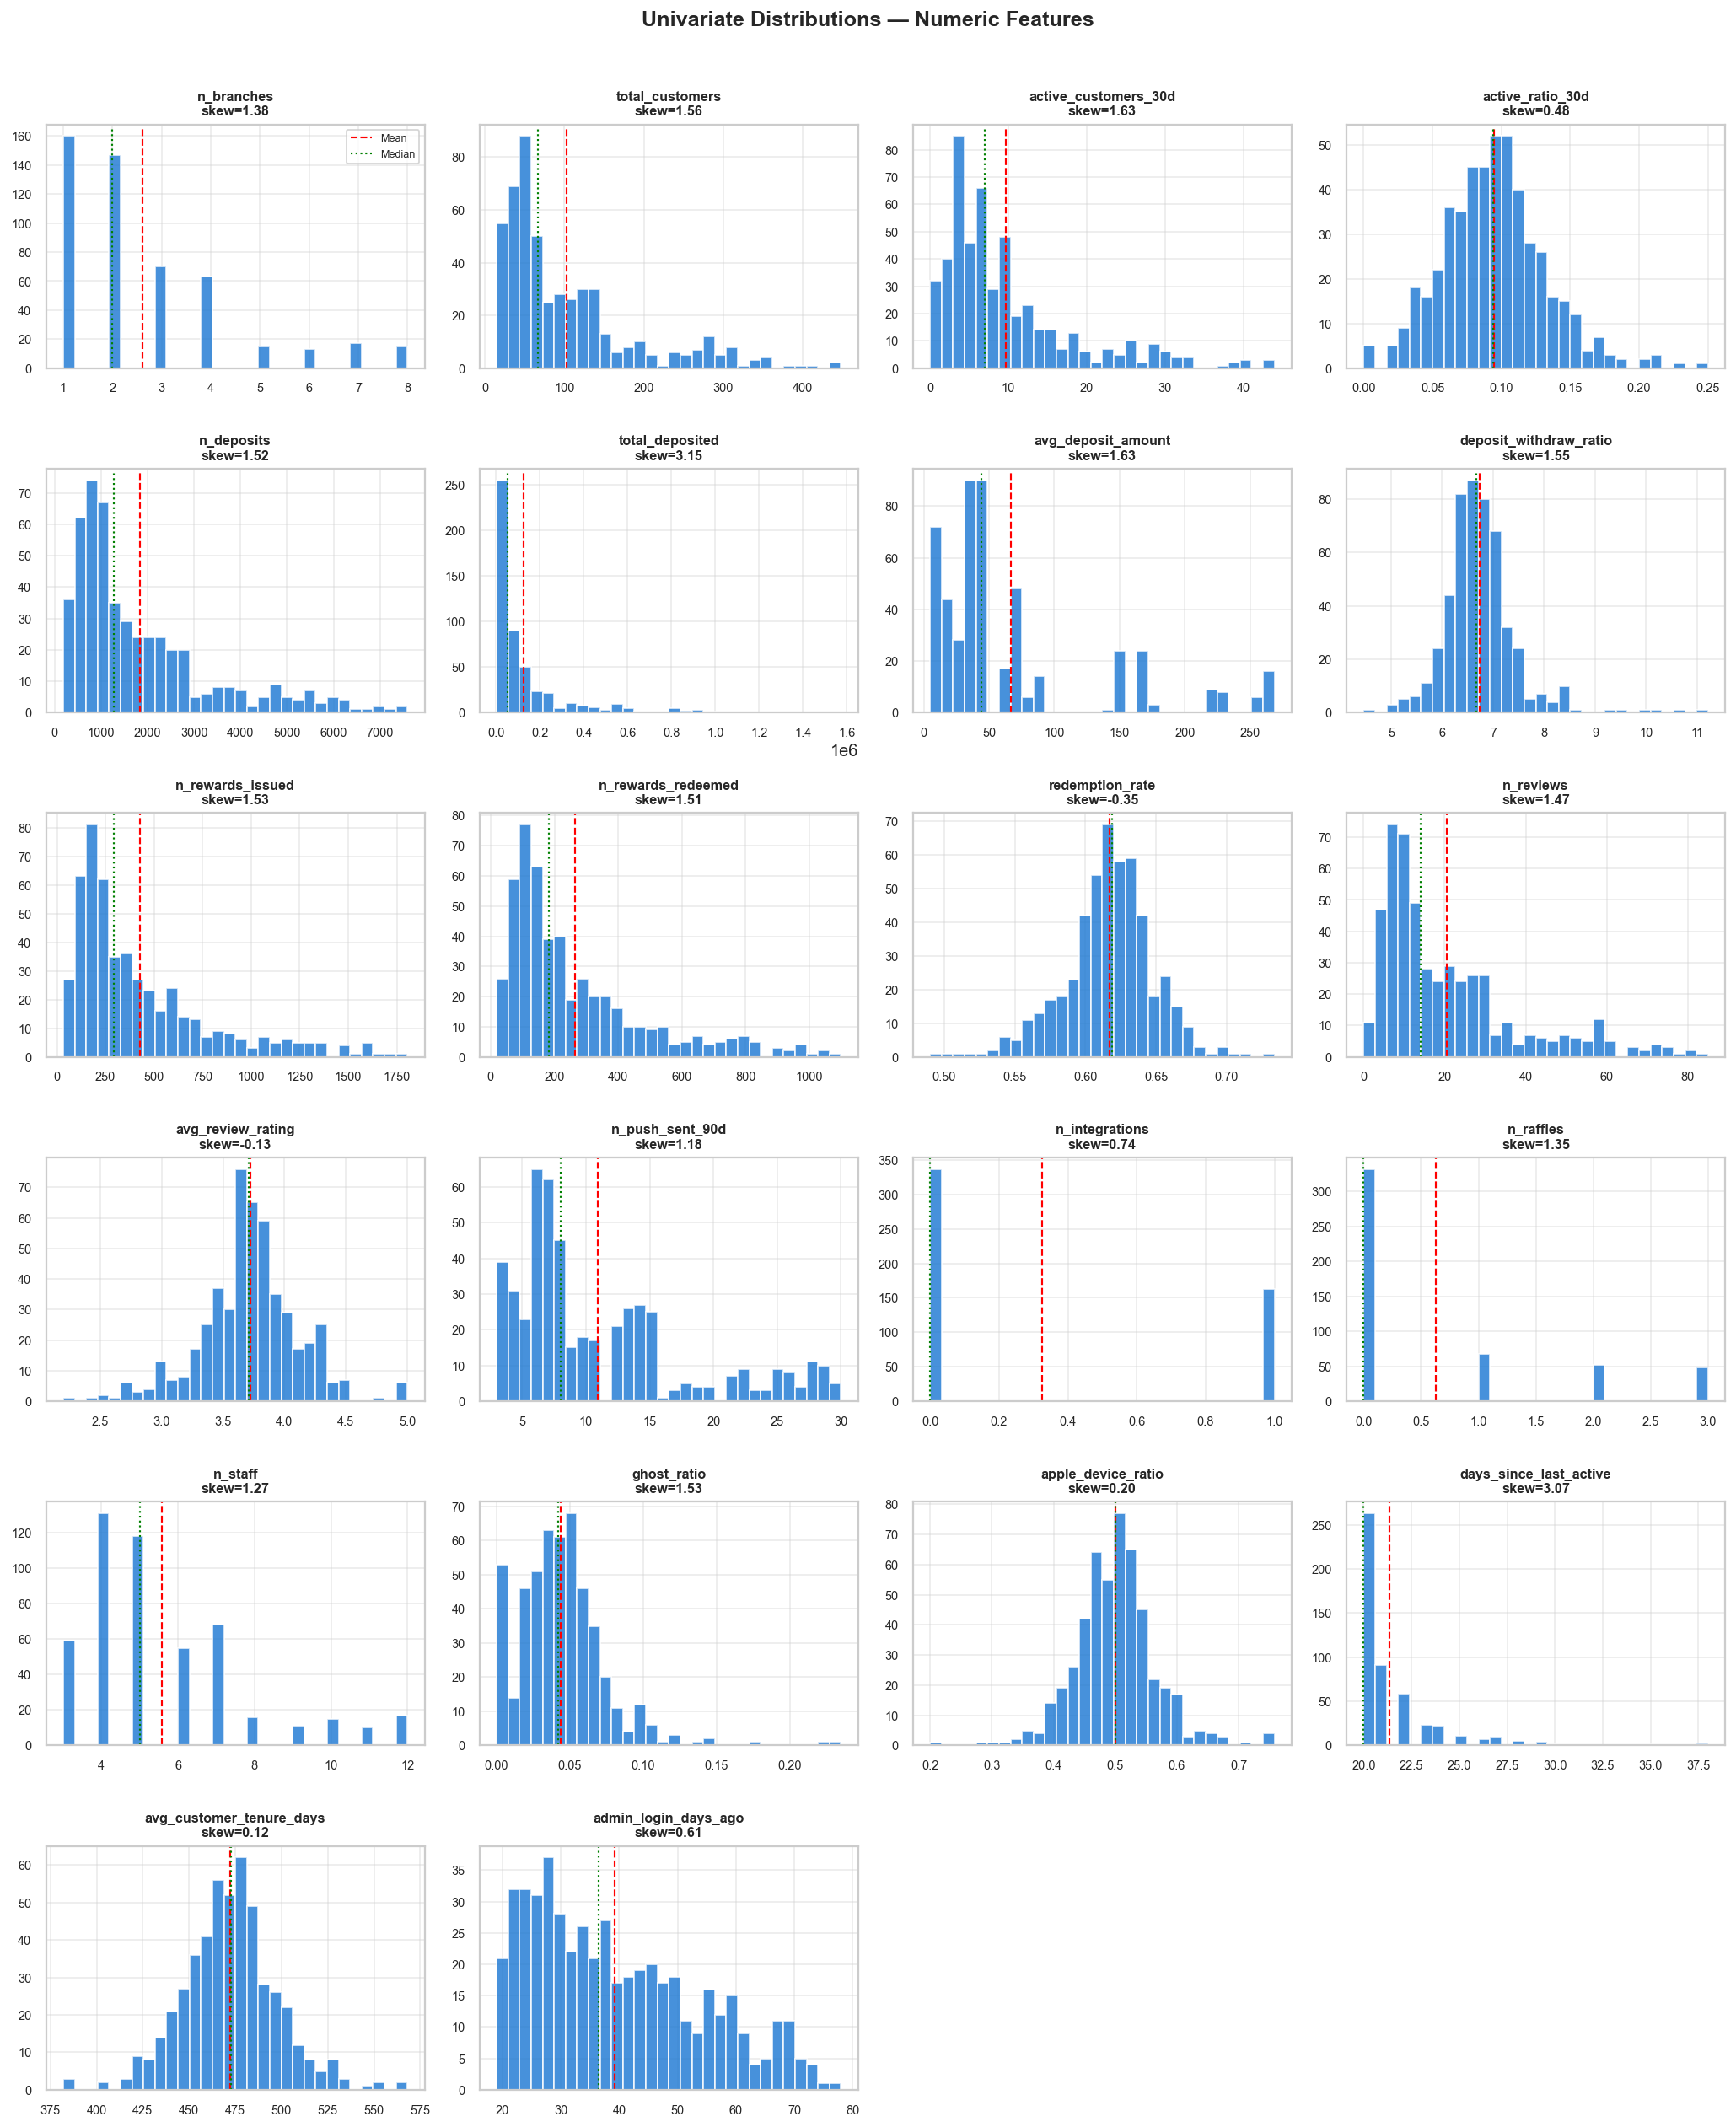

In [18]:
# Red de histogramas
cols_per_row = 4
n = len(NUM_FEATURES)
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row,
                          figsize=(cols_per_row*4, rows*3.2))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#1976D2', alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(data.median(), color='green',  linestyle=':',  linewidth=1.2, label='Median')
    skew_val = stats.skew(data.dropna())
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7)

# Esconder gráficos no usados
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Numeric Features', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_univariate_numeric.png', bbox_inches='tight')
plt.show()

---
## 5. Valores atípicos (Outliers)

Detección mediante IQR y Z-score. Boxplots para las features con mayor variabilidad.

In [19]:
# IQR-Detección de outliers por características
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

outlier_df = pd.DataFrame({
    'n_outliers_IQR':  {c: iqr_outliers(df[c].dropna()) for c in NUM_FEATURES},
    'pct_outliers_IQR':{c: round(iqr_outliers(df[c].dropna())/len(df)*100,2) for c in NUM_FEATURES},
}).sort_values('pct_outliers_IQR', ascending=False)
display(outlier_df[outlier_df['n_outliers_IQR']>0])

,n_outliers_IQR,pct_outliers_IQR
avg_deposit_amount,91,18.2
total_deposited,58,11.6
n_raffles,48,9.6
total_customers,44,8.8
active_customers_30d,44,8.8
n_deposits,35,7.0
n_reviews,35,7.0
n_rewards_issued,34,6.8
n_rewards_redeemed,33,6.6
n_branches,32,6.4


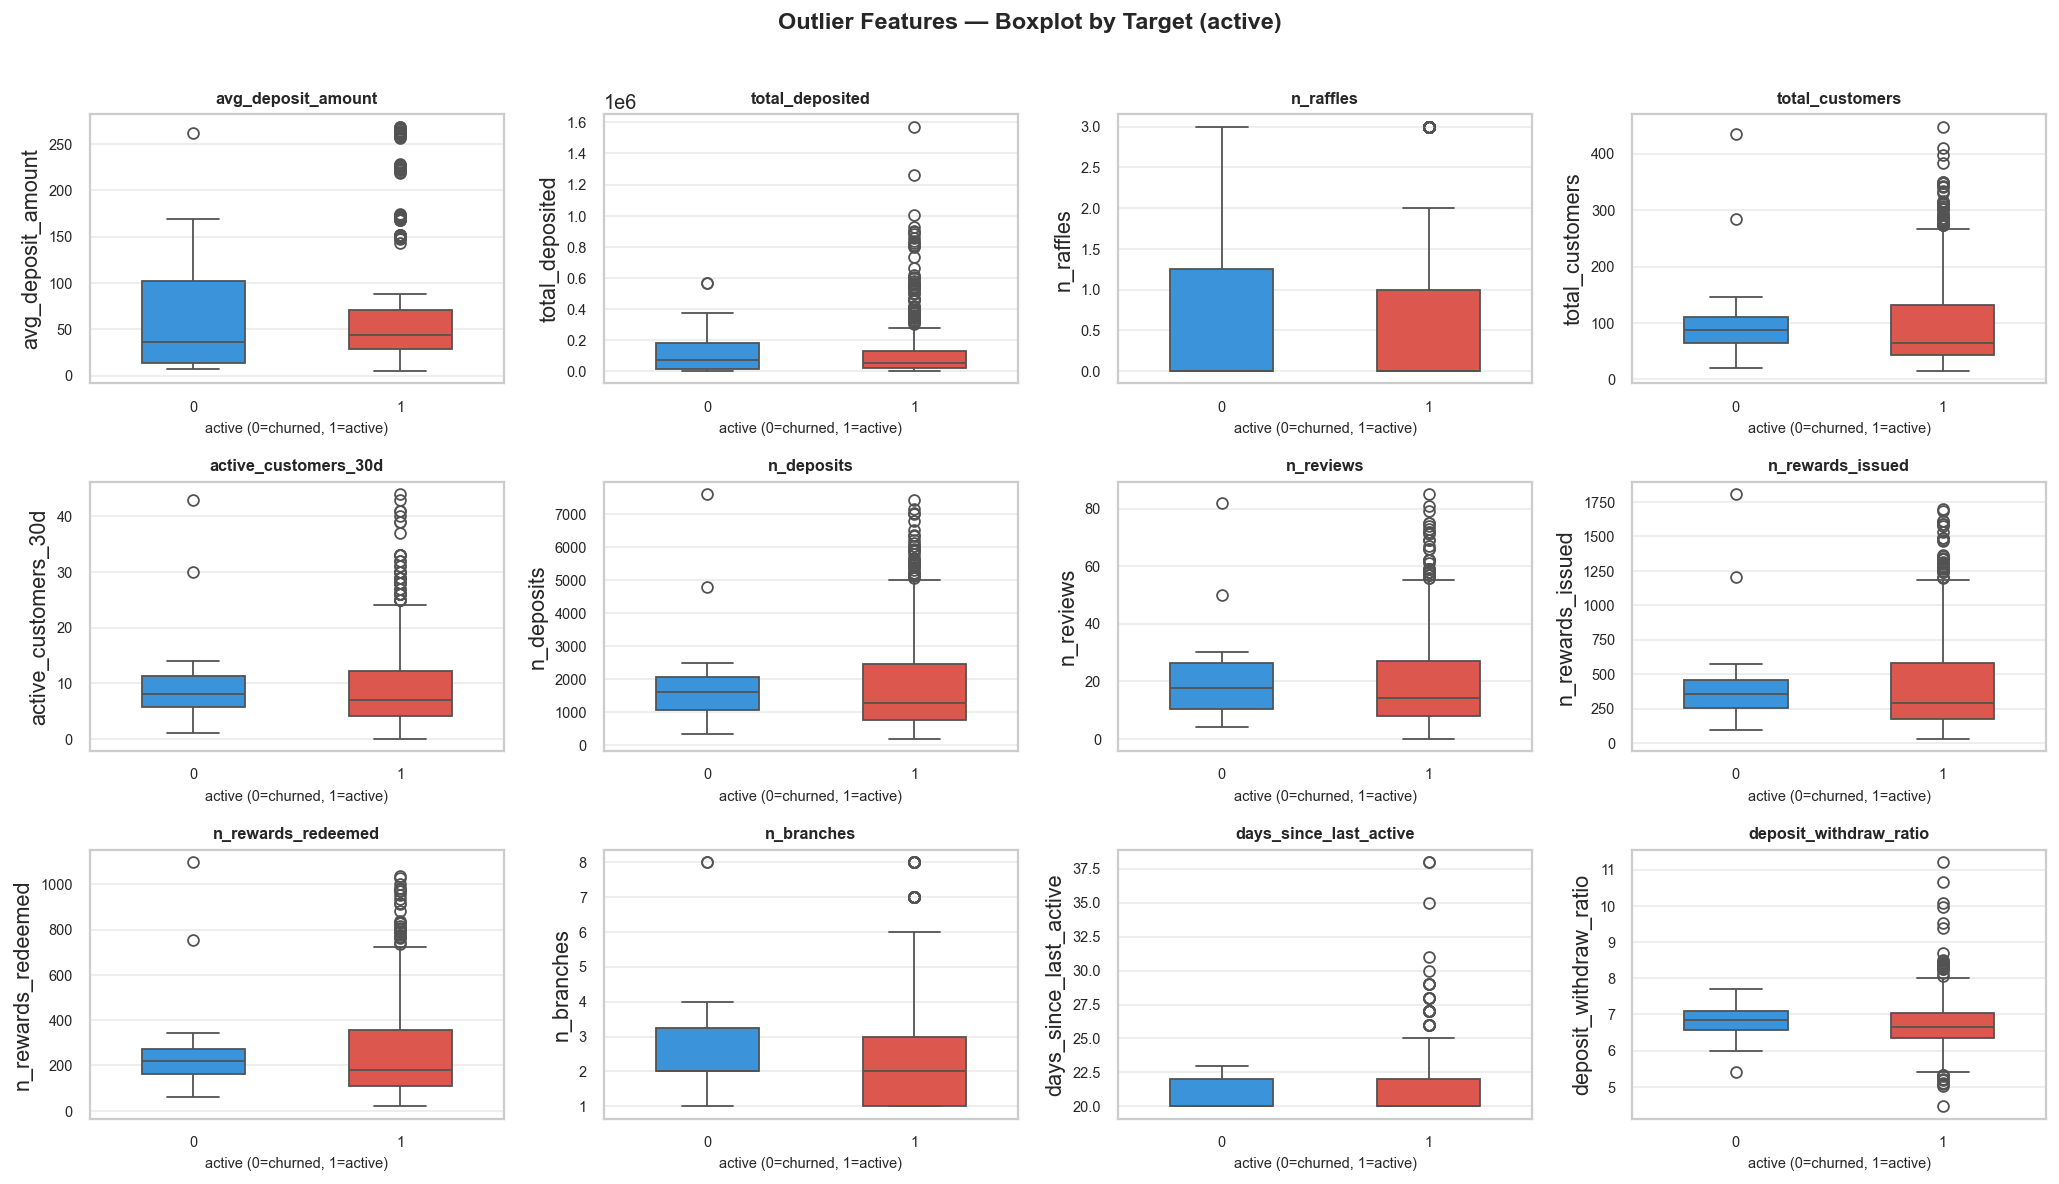

In [20]:
# Gráficos de caja para detección de outliers.
top_out = outlier_df[outlier_df['n_outliers_IQR']>0].head(12).index.tolist()
if top_out:
    cols_r = 4
    rows_r = (len(top_out) + cols_r - 1) // cols_r
    fig, axes = plt.subplots(rows_r, cols_r, figsize=(cols_r*4, rows_r*3))
    axes = axes.flatten()
    for i, col in enumerate(top_out):
        sns.boxplot(data=df, y=col, x='active',
                    palette=PALETTE_BINARY, ax=axes[i], width=0.5)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('active (0=churned, 1=active)', fontsize=8)
        axes[i].tick_params(labelsize=8)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Outlier Features — Boxplot by Target (active)',
                 fontsize=13, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_05_outliers_boxplot.png', bbox_inches='tight')
    plt.show()

In [21]:
# ── TRATEMIENTO DE OUTLIERS ────────────────────────────────────────────────────────
#Estrategia: Winsorizar en el percentil 1 y 99 para características altamente asimétricas
from scipy.stats.mstats import winsorize

high_skew = skew_df[skew_df['skewness'].abs() > 2].index.tolist()
high_skew = [c for c in high_skew if c in df.columns]

for col in high_skew:
    df[col] = winsorize(df[col].fillna(df[col].median()), limits=[0.01, 0.01])

print(f"Winsorization applied to {len(high_skew)} high-skew features:")
for c in high_skew:
    print(f"  - {c}")

Winsorization applied to 2 high-skew features:
  - total_deposited
  - days_since_last_active


---
## 6. Cardinalidad y análisis univariante — Variables categóricas

In [22]:
CAT_FEATURES = ['tier','loyalty_type','country_id']
CAT_FEATURES = [c for c in CAT_FEATURES if c in df.columns]

# Cardinality table
card_df = pd.DataFrame({
    'unique_values': {c: df[c].nunique() for c in CAT_FEATURES},
    'top_value':     {c: df[c].value_counts().idxmax() for c in CAT_FEATURES},
    'top_freq_pct':  {c: round(df[c].value_counts(normalize=True).max()*100,1)
                     for c in CAT_FEATURES},
})
print("Cardinality summary:")
display(card_df)

Cardinality summary:


,unique_values,top_value,top_freq_pct
tier,3,STARTER,40.6
loyalty_type,3,BALANCE,53.4
country_id,2,1,51.4


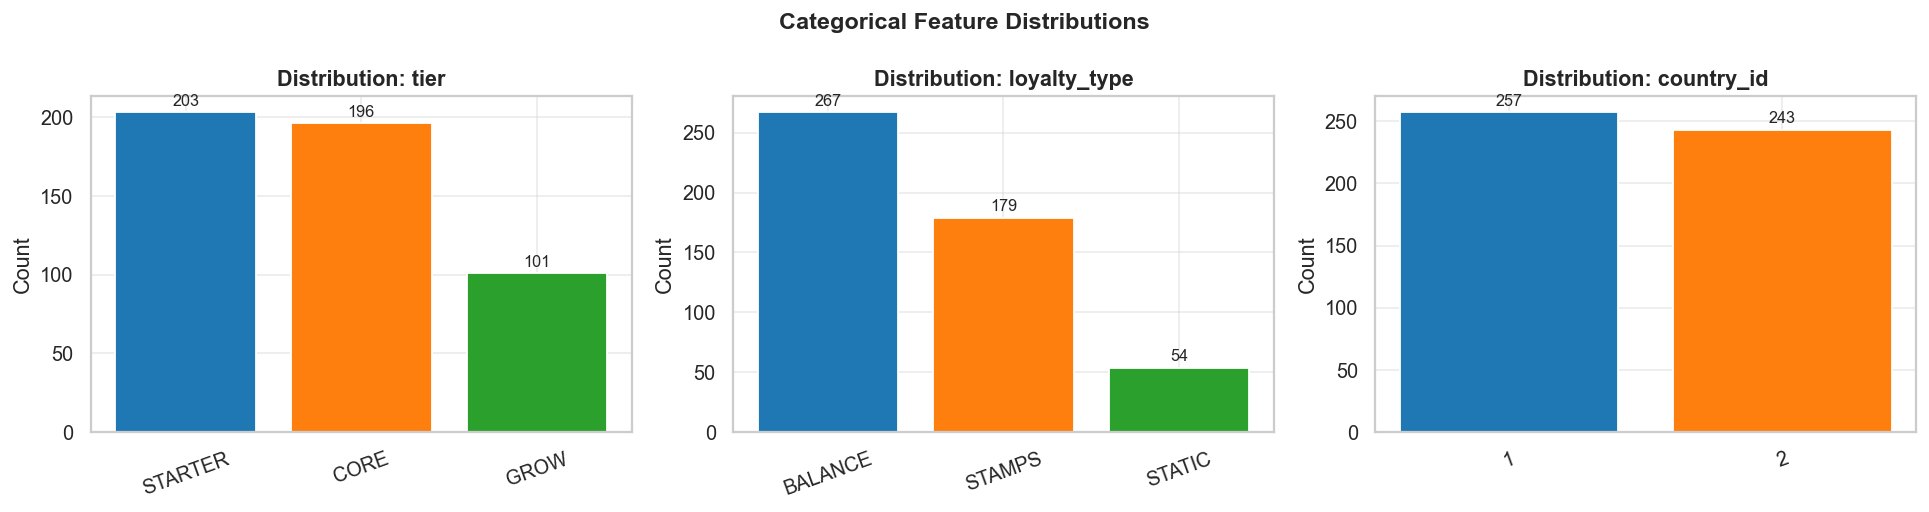

In [23]:
fig, axes = plt.subplots(1, len(CAT_FEATURES), figsize=(5*len(CAT_FEATURES), 4))
if len(CAT_FEATURES) == 1:
    axes = [axes]

for ax, col in zip(axes, CAT_FEATURES):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=PALETTE_CAT[:len(vc)], edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=2, fontsize=9)
    ax.set_title(f'Distribution: {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06_categorical_univariate.png', bbox_inches='tight')
plt.show()

---
## 7. Sesgo y transformaciones no lineales

Features con |skewness| > 1 se candidatan a transformación log(x+1).

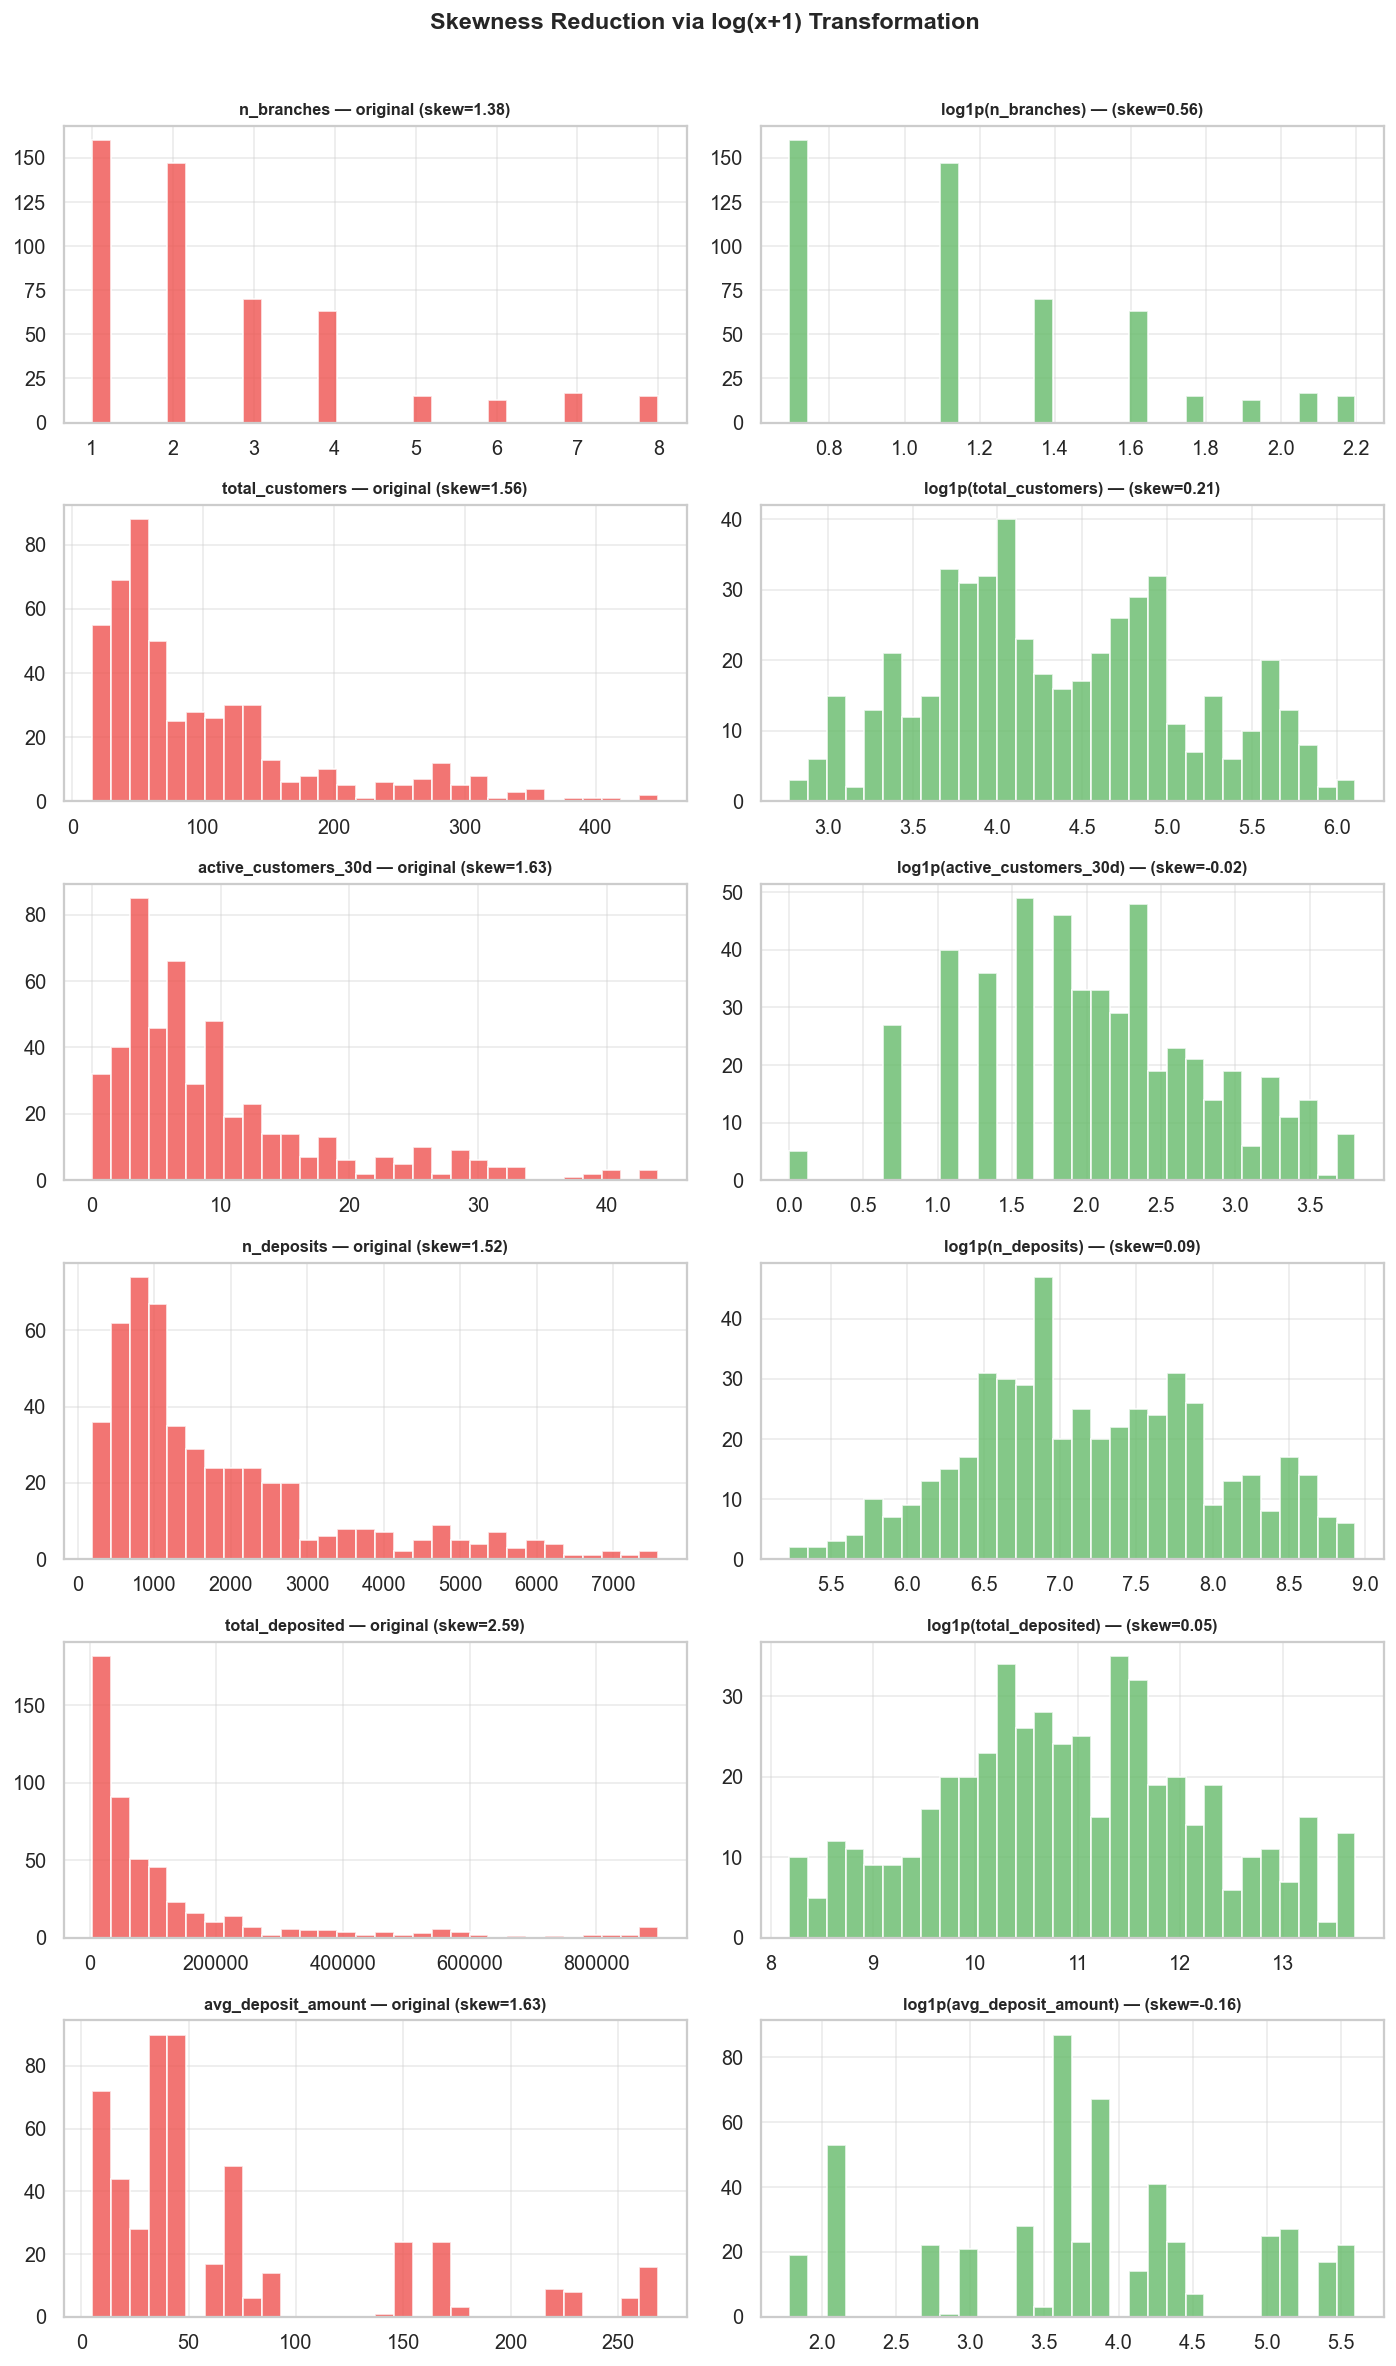

log1p transformation applied to 15 features.
['n_branches', 'total_customers', 'active_customers_30d', 'n_deposits', 'total_deposited', 'avg_deposit_amount', 'deposit_withdraw_ratio', 'n_rewards_issued', 'n_rewards_redeemed', 'n_reviews', 'n_push_sent_90d', 'n_raffles', 'n_staff', 'ghost_ratio', 'days_since_last_active']


In [24]:
features_to_transform = skew_df[skew_df['skewness'] > 1.0].index.tolist()
features_to_transform = [c for c in features_to_transform if c in df.columns and (df[c]>=0).all()]

if features_to_transform:
    n_show = min(6, len(features_to_transform))
    fig, axes = plt.subplots(n_show, 2, figsize=(11, n_show*3))

    for i, col in enumerate(features_to_transform[:n_show]):
        orig = df[col].dropna()
        log_t = np.log1p(orig)
        sk_orig = stats.skew(orig)
        sk_log  = stats.skew(log_t)

        axes[i,0].hist(orig,  bins=30, color='#EF5350', alpha=0.8, edgecolor='white')
        axes[i,0].set_title(f'{col} — original (skew={sk_orig:.2f})', fontsize=9)

        axes[i,1].hist(log_t, bins=30, color='#66BB6A', alpha=0.8, edgecolor='white')
        axes[i,1].set_title(f'log1p({col}) — (skew={sk_log:.2f})', fontsize=9)

    plt.suptitle('Skewness Reduction via log(x+1) Transformation',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig_07_transformations.png', bbox_inches='tight')
    plt.show()

    # Apply log1p to selected features
    df_model = df.copy()
    for col in features_to_transform:
        df_model[f'log_{col}'] = np.log1p(df_model[col])

    print(f"log1p transformation applied to {len(features_to_transform)} features.")
    print(features_to_transform)
else:
    df_model = df.copy()
    print("No high-skew features to transform.")

# Revisión y aplicación para sesgo
Se identificaron 5 variables con sesgo positivo superior a 1.5, todas de naturaleza de volumen o monto. Se aplicó transformación log(x+1) para normalizar su distribución, especialmente relevante para los modelos paramétricos (Regresión Logística, MLP). Los modelos basados en árboles (Random Forest, XGBoost) son robustos al sesgo, por lo que la transformación no afecta su rendimiento pero tampoco lo perjudica.

---
## 8. Tendencias temporales

Evolución de registros de clientes y transacciones a lo largo del tiempo.

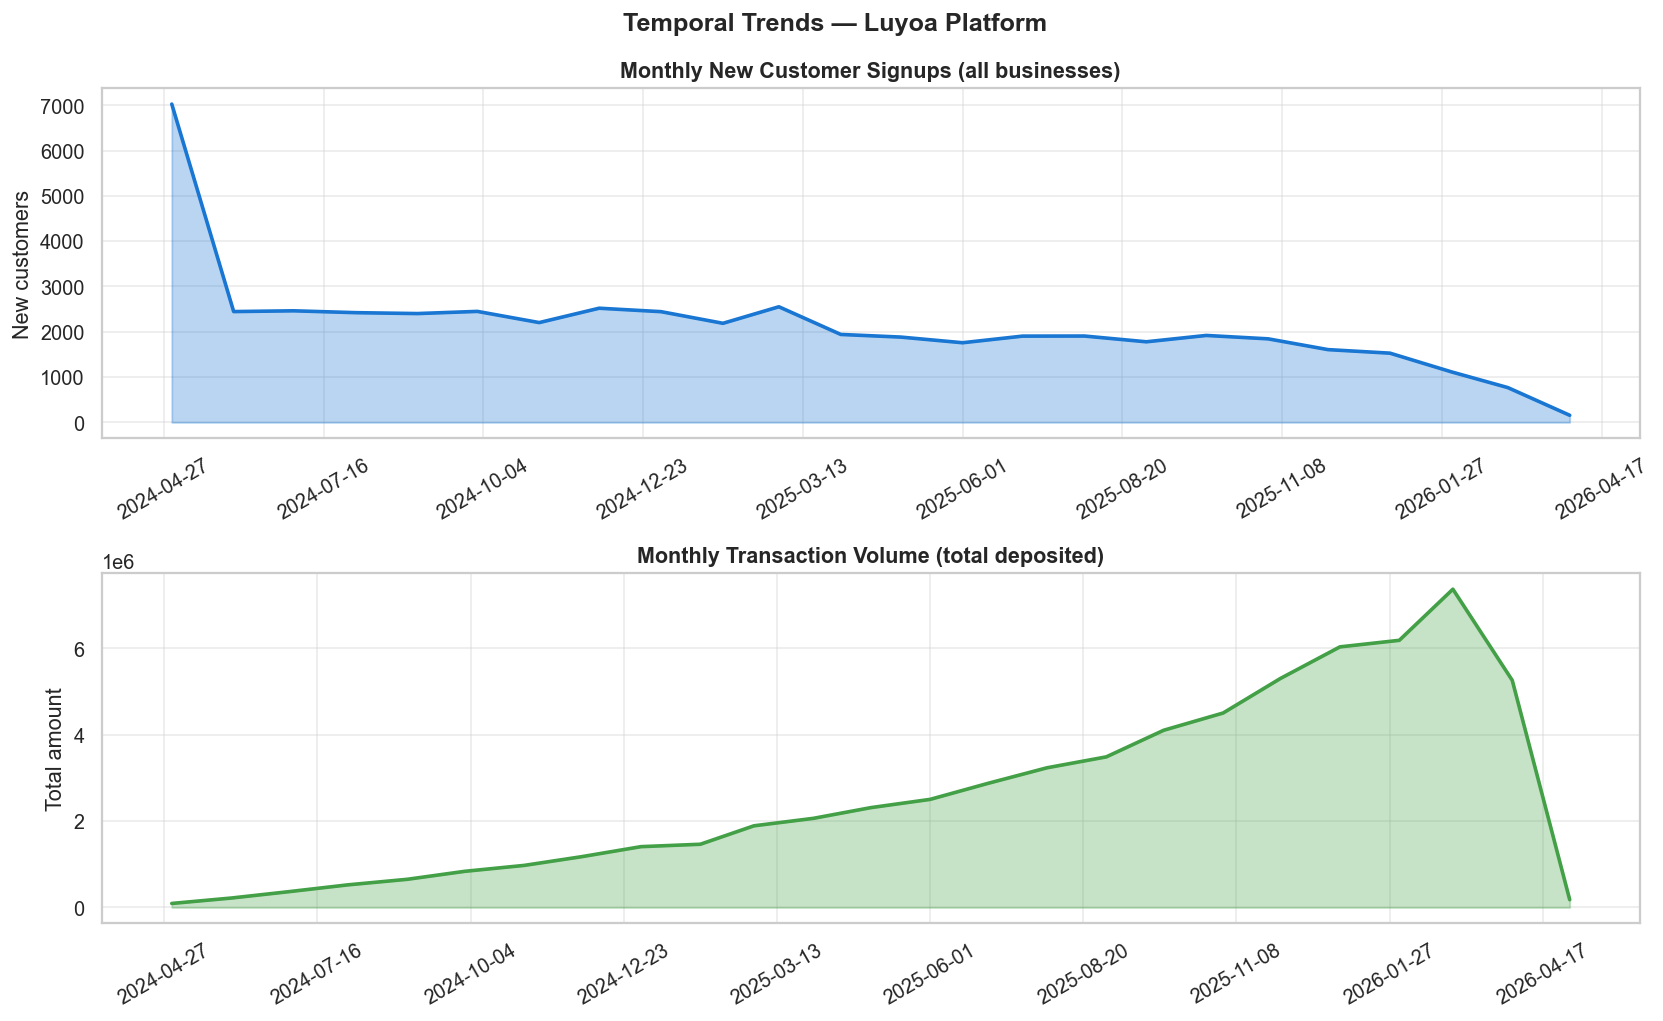

In [25]:
# Evolución del comportamiento de clientes por mes.
customers['signup_month'] = customers['created_at'].dt.to_period('M')
monthly_signups = (customers.groupby('signup_month')['id']
                   .count().reset_index()
                   .rename(columns={'id':'new_customers'}))
monthly_signups['signup_month'] = monthly_signups['signup_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Plot 1: variación mensual
axes[0].fill_between(monthly_signups['signup_month'],
                     monthly_signups['new_customers'], alpha=0.3, color='#1976D2')
axes[0].plot(monthly_signups['signup_month'],
             monthly_signups['new_customers'], color='#1976D2', linewidth=2)
axes[0].set_title('Monthly New Customer Signups (all businesses)')
axes[0].set_ylabel('New customers')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Plot 2: volumen de transacción mensual
transactions['tx_month'] = transactions['created_at'].dt.to_period('M')
monthly_tx = (transactions.groupby('tx_month')['amount']
              .sum().reset_index()
              .rename(columns={'amount':'total_amount'}))
monthly_tx['tx_month'] = monthly_tx['tx_month'].dt.to_timestamp()

axes[1].fill_between(monthly_tx['tx_month'],
                     monthly_tx['total_amount'], alpha=0.3, color='#43A047')
axes[1].plot(monthly_tx['tx_month'],
             monthly_tx['total_amount'], color='#43A047', linewidth=2)
axes[1].set_title('Monthly Transaction Volume (total deposited)')
axes[1].set_ylabel('Total amount')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Temporal Trends — Luyoa Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_temporal_trends.png', bbox_inches='tight')
plt.show()

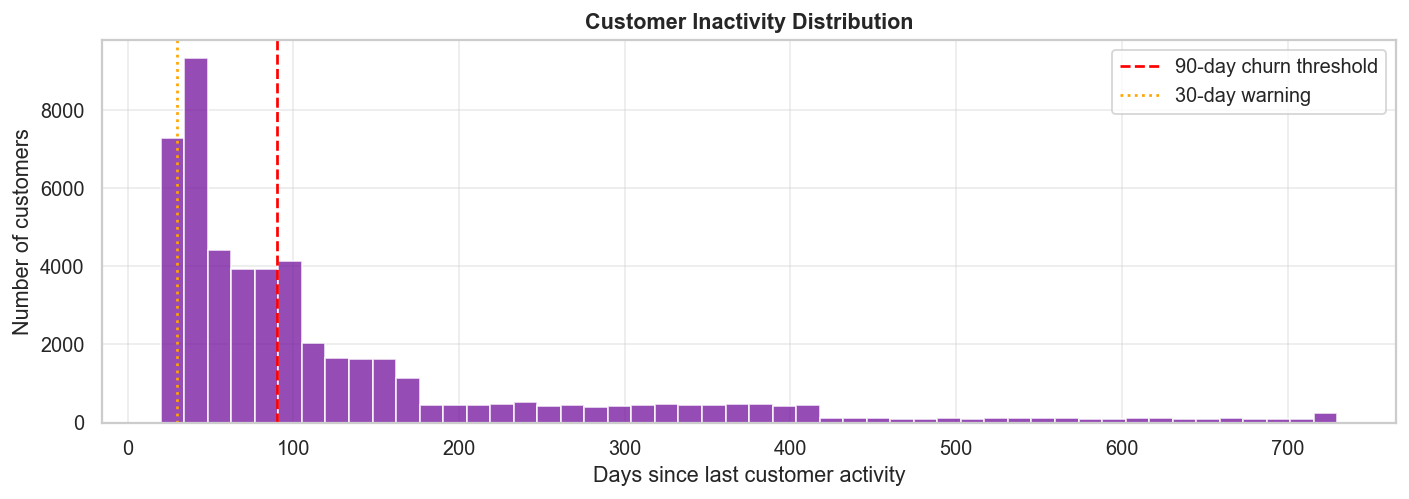

In [26]:
# Actividad reciente de los consumidores, distribución
fig, ax = plt.subplots(figsize=(11,4))
customers['days_since_active'] = (NOW - customers['last_active_at']).dt.days.clip(0,730)
ax.hist(customers['days_since_active'].dropna(), bins=50,
        color='#7B1FA2', alpha=0.8, edgecolor='white')
ax.axvline(90,  color='red',    linestyle='--', linewidth=1.5, label='90-day churn threshold')
ax.axvline(30,  color='orange', linestyle=':',  linewidth=1.5, label='30-day warning')
ax.set_xlabel('Days since last customer activity')
ax.set_ylabel('Number of customers')
ax.set_title('Customer Inactivity Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('fig_09_inactivity_dist.png', bbox_inches='tight')
plt.show()

---
## 9. Análisis bivariante — Features numéricas vs `active`

In [27]:
# Tabla de correlaciones bivariante con el objetivo
pb_corrs = {}
for col in NUM_FEATURES:
    clean = df[[col, 'active']].dropna()
    if clean[col].std() > 0:
        r, p = pointbiserialr(clean['active'], clean[col])
        pb_corrs[col] = {'r': round(r,4), 'p_value': round(p,4),
                         'significant': p < 0.05}

corr_df = pd.DataFrame(pb_corrs).T.sort_values('r', key=abs, ascending=False)
display(corr_df)

,r,p_value,significant
apple_device_ratio,-0.0528,0.2382,False
days_since_last_active,0.0506,0.2584,False
n_staff,-0.0394,0.3797,False
n_push_sent_90d,0.0344,0.443,False
n_branches,-0.0324,0.4697,False
active_customers_30d,-0.027,0.5473,False
n_raffles,-0.0239,0.5941,False
ghost_ratio,0.0232,0.6055,False
total_deposited,-0.0227,0.6123,False
active_ratio_30d,-0.017,0.7042,False


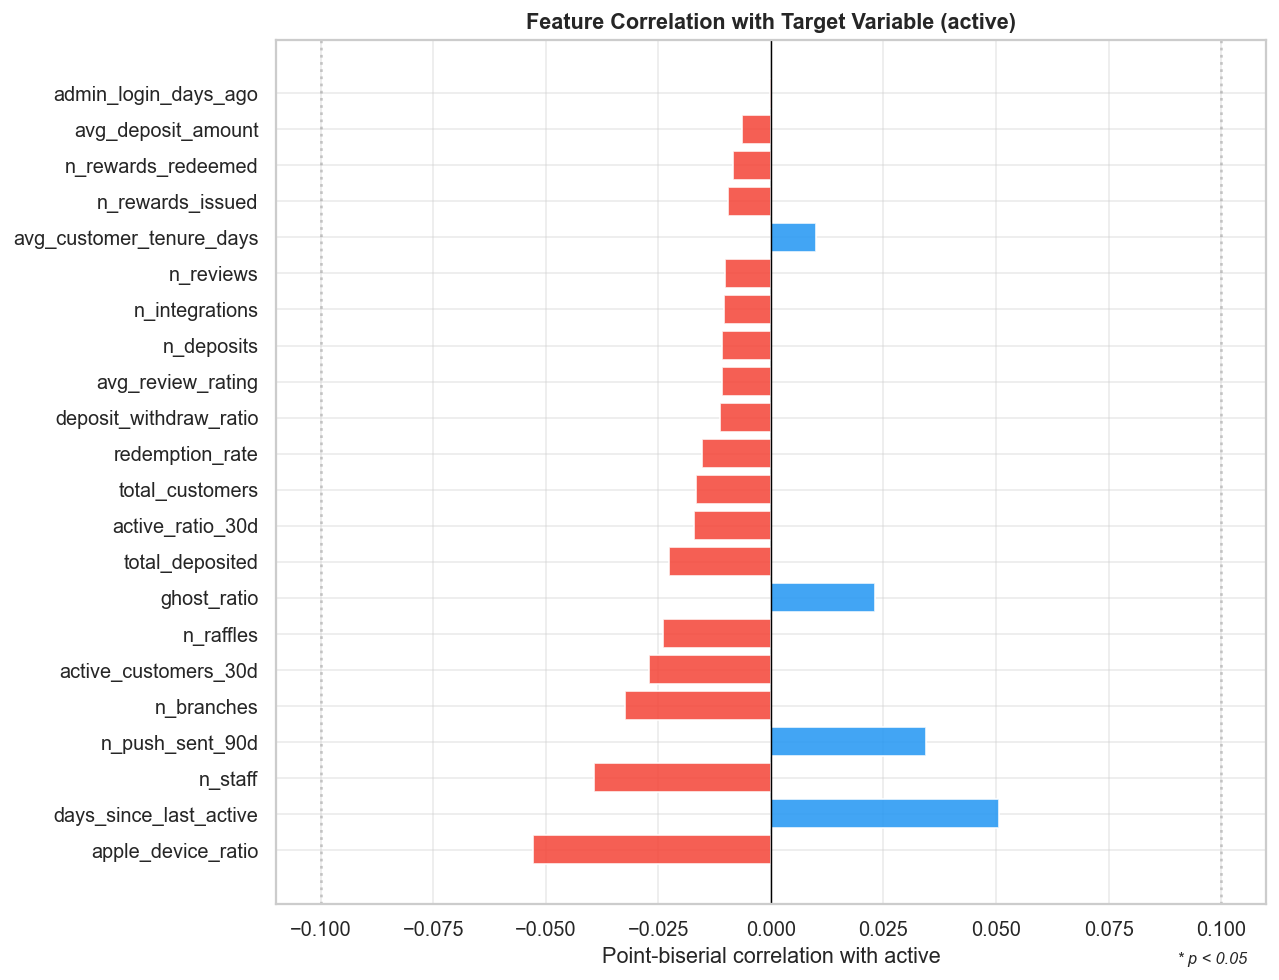

In [28]:
# Gráfica de barras horizontales de correlaciones
fig, ax = plt.subplots(figsize=(10, max(5, len(corr_df)*0.35)))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr_df['r']]
bars = ax.barh(corr_df.index, corr_df['r'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.1, color='gray', linestyle=':', alpha=0.4)
ax.axvline(-0.1, color='gray', linestyle=':', alpha=0.4)
ax.set_xlabel('Point-biserial correlation with active')
ax.set_title('Feature Correlation with Target Variable (active)')

for i, (idx, row) in enumerate(corr_df.iterrows()):
    if row['significant']:
        ax.text(row['r'] + (0.003 if row['r']>=0 else -0.003), i,
                '*', va='center', fontsize=11,
                ha='left' if row['r']>=0 else 'right', color='black')
ax.text(0.98, -0.07, '* p < 0.05', transform=ax.transAxes,
        ha='right', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('fig_10_correlations_target.png', bbox_inches='tight')
plt.show()

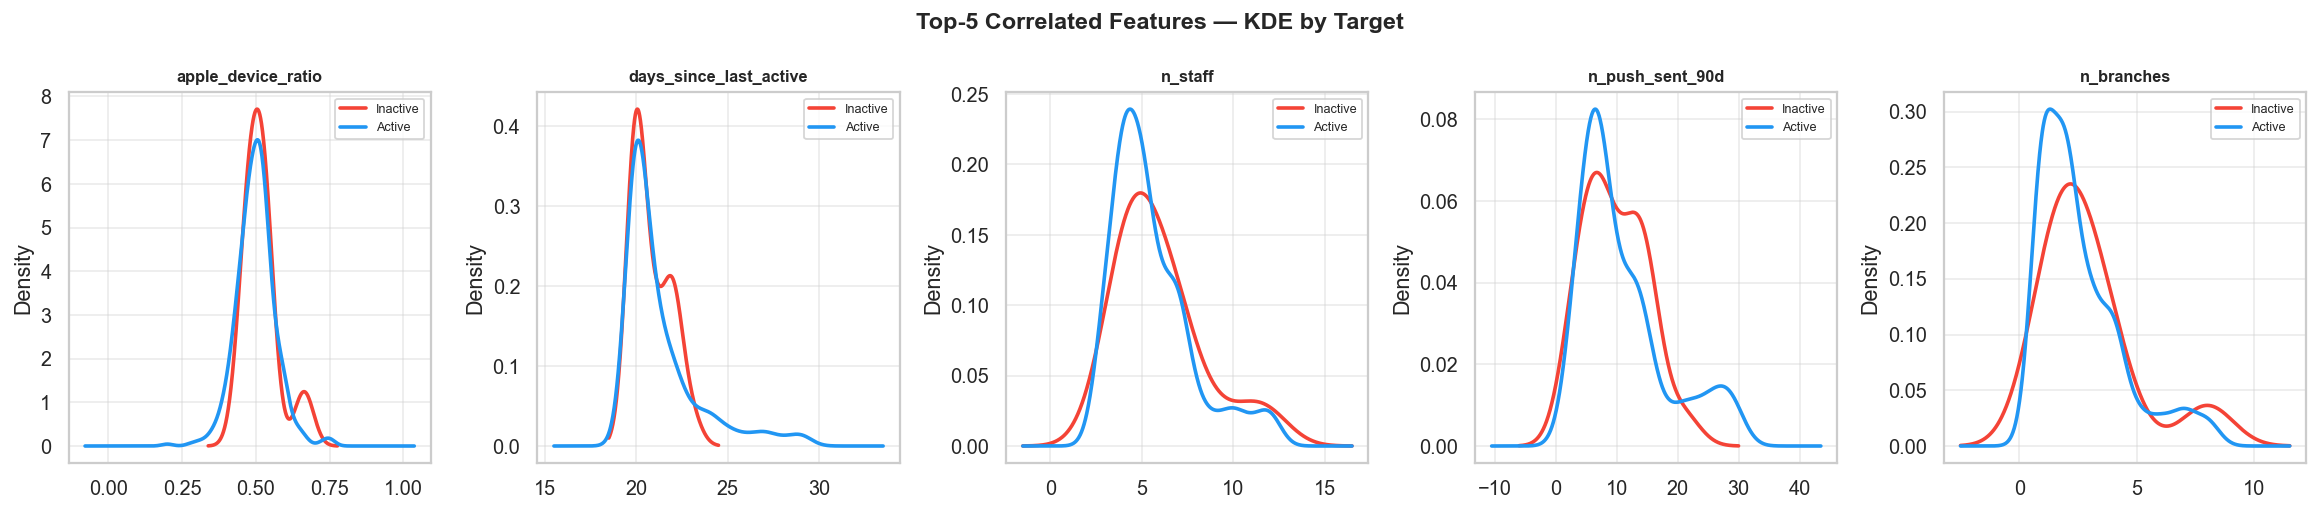

In [29]:
# KDE plots: top-5 features correlacionadas |r|
top5 = corr_df.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, top5):
    for val, color, label in [(0,'#F44336','Inactive'), (1,'#2196F3','Active')]:
        subset = df[df['active']==val][col].dropna()
        if len(subset) > 1:
            subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Top-5 Correlated Features — KDE by Target',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_kde_top5.png', bbox_inches='tight')
plt.show()

---
## 10. Análisis bivariante — Variables categóricas vs `active`

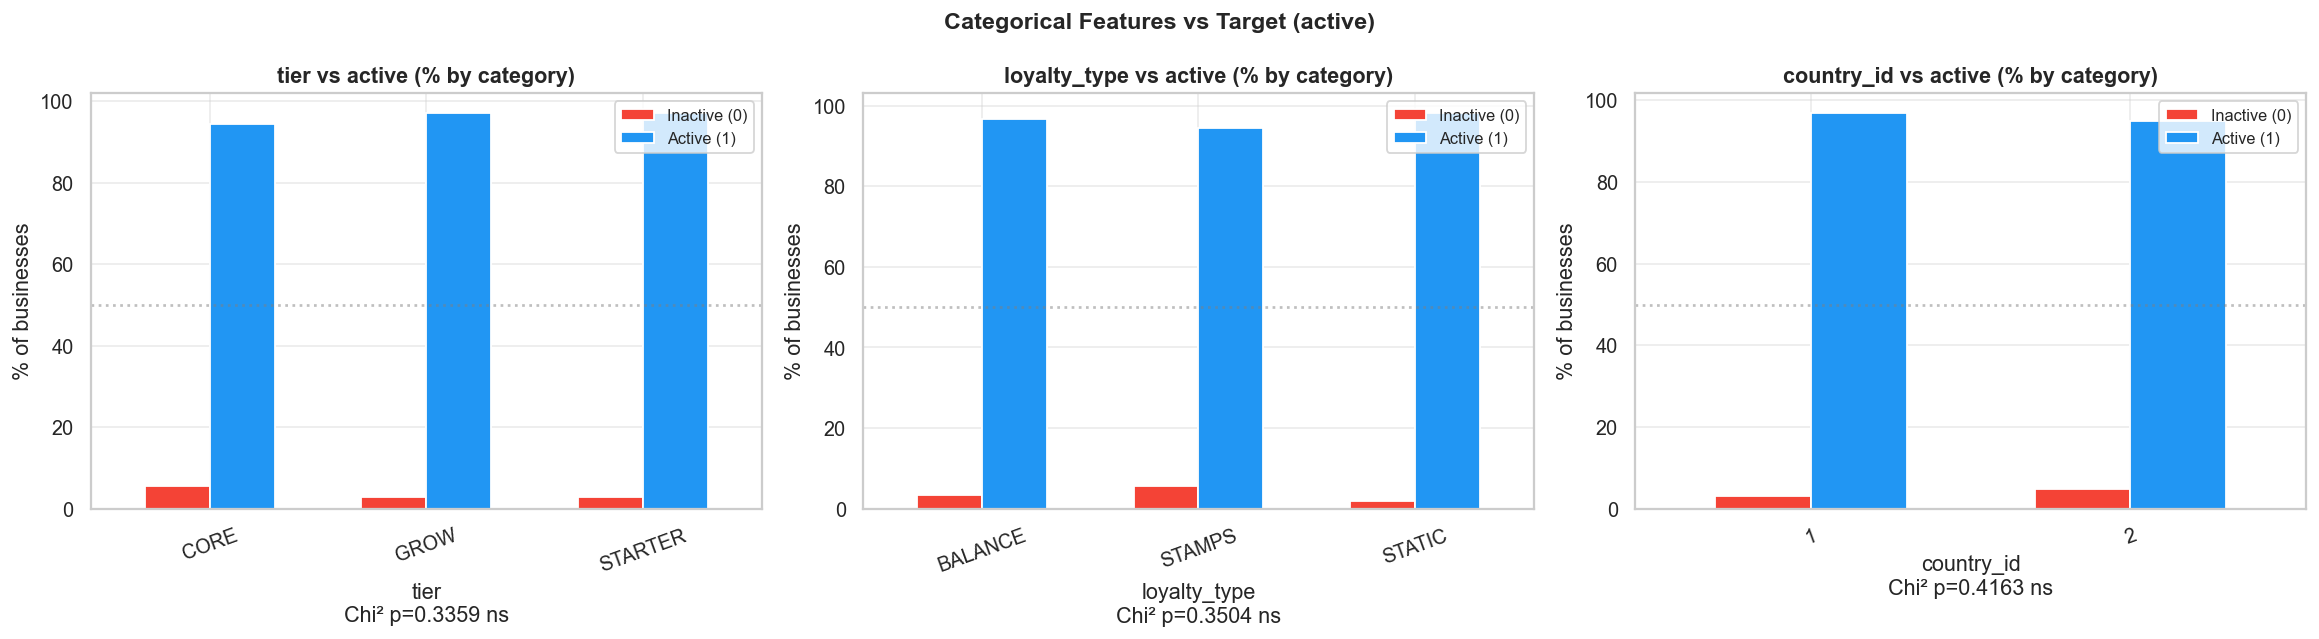

In [30]:
fig, axes = plt.subplots(1, len(CAT_FEATURES), figsize=(6*len(CAT_FEATURES), 5))
if len(CAT_FEATURES) == 1:
    axes = [axes]

for ax, col in zip(axes, CAT_FEATURES):
    ct = pd.crosstab(df[col], df['active'], normalize='index') * 100
    ct.columns = ['Inactive (0)','Active (1)']
    ct.plot(kind='bar', ax=ax, color=PALETTE_BINARY[::-1],
            edgecolor='white', width=0.6)
    ax.set_title(f'{col} vs active (% by category)')
    ax.set_ylabel('% of businesses')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(loc='upper right', fontsize=9)
    ax.axhline(50, color='gray', linestyle=':', alpha=0.5)

    # Chi-square test
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(df[col], df['active']))
    ax.set_xlabel(f'{col}\nChi² p={p:.4f} {"*" if p<0.05 else "ns"}')

plt.suptitle('Categorical Features vs Target (active)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_categorical_bivariate.png', bbox_inches='tight')
plt.show()

---
## 11. Matriz de correlaciones (multivariante)

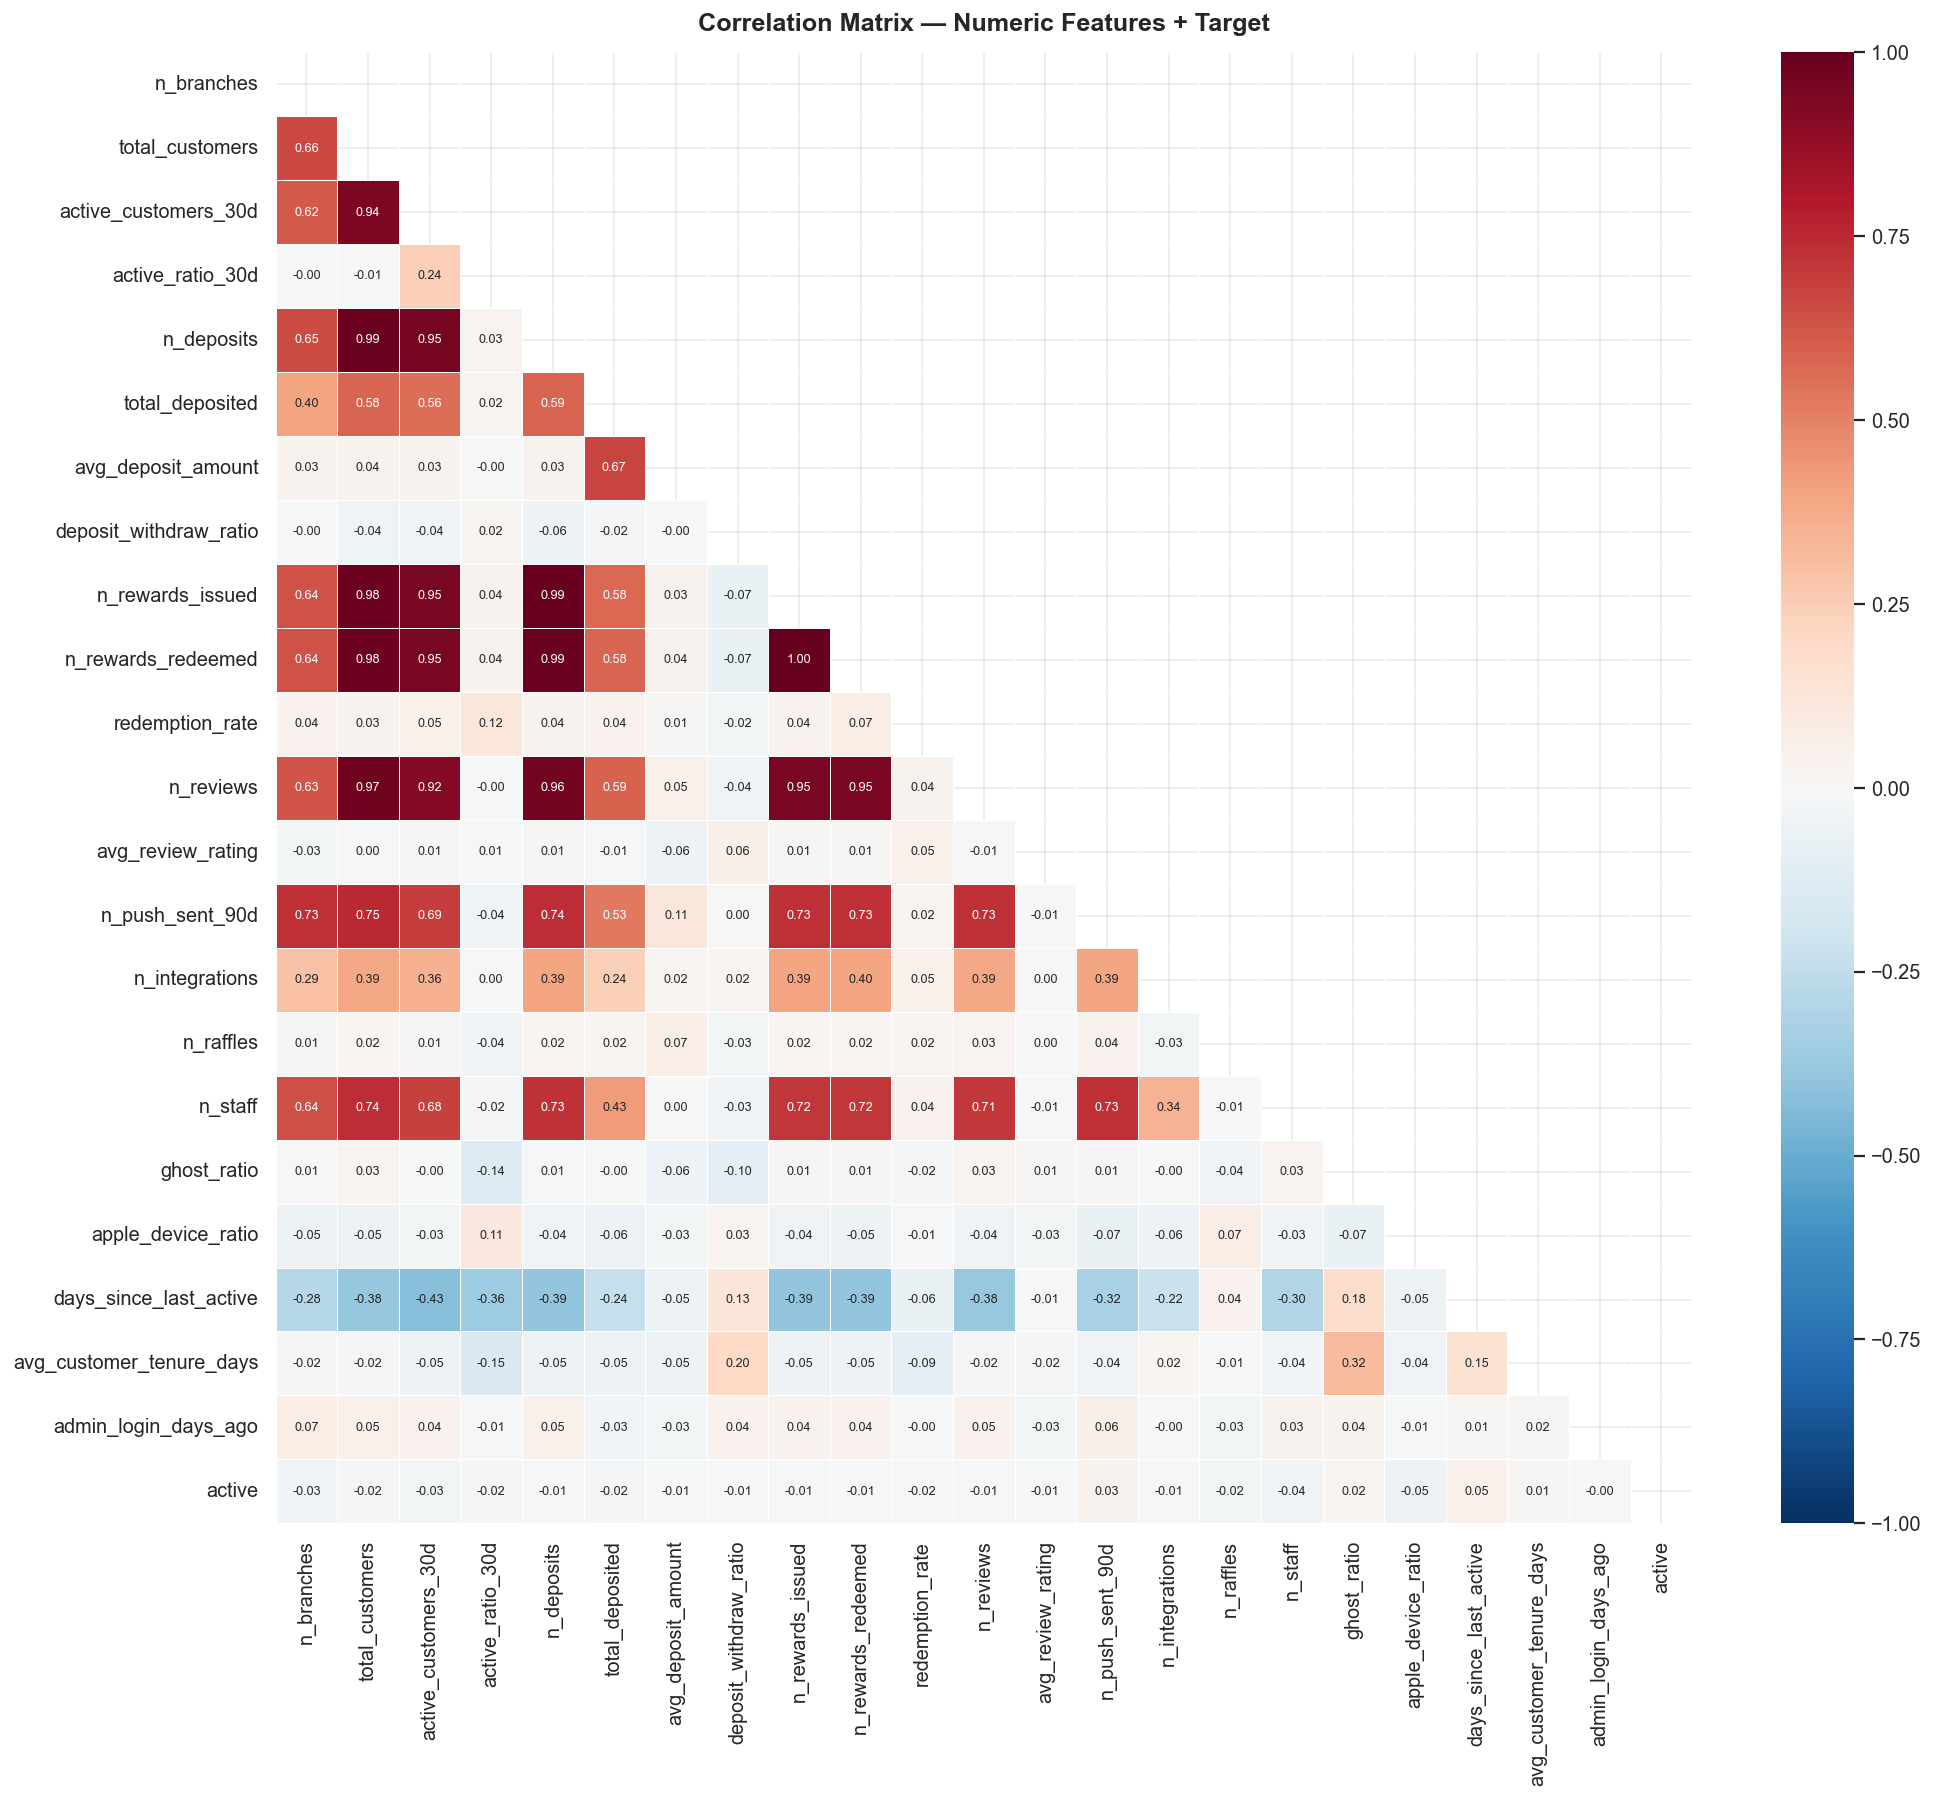


Highly correlated pairs (|r| > 0.80):


,feature_A,feature_B,r
12,n_rewards_issued,n_rewards_redeemed,0.9991
9,n_deposits,n_rewards_issued,0.9925
1,total_customers,n_deposits,0.9915
10,n_deposits,n_rewards_redeemed,0.9912
2,total_customers,n_rewards_issued,0.9822
3,total_customers,n_rewards_redeemed,0.9812
4,total_customers,n_reviews,0.9729
11,n_deposits,n_reviews,0.9627
5,active_customers_30d,n_deposits,0.9531
13,n_rewards_issued,n_reviews,0.9519


In [31]:
# Matriz de correlaciones multivariante con el target.
corr_cols = [c for c in NUM_FEATURES if c in df_model.columns] + ['active']
corr_mat  = df_model[corr_cols].corr()


mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            annot_kws={'size':7}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features + Target', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('fig_13_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Detalle de pares altamente correlacionados (|r| > 0.8, excluding target)
print("\nHighly correlated pairs (|r| > 0.80):")
high_corr = []
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        r = corr_mat.iloc[i,j]
        if abs(r) > 0.80 and corr_mat.columns[i]!='active' and corr_mat.columns[j]!='active':
            high_corr.append({'feature_A': corr_mat.columns[i],
                               'feature_B': corr_mat.columns[j],
                               'r': round(r,4)})
if high_corr:
    display(pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False))
else:
    print("  No pairs with |r| > 0.80 found.")

---
## 12. Preprocesamiento final

Encoding, escalado y exportación del DataFrame listo para ajustar features y después modelado.

In [32]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_final = df_model.copy()

# ── Encoding categórico ───────────────────────────────────────────────────────
le = LabelEncoder()
for col in CAT_FEATURES:
    if col in df_final.columns:
        df_final[f'{col}_enc'] = le.fit_transform(df_final[col].astype(str))

# ── Drop columnas no necesarias para el modelo ────────────────────────────────
drop_cols = ['business_id','uid','name','slug'] + CAT_FEATURES
drop_cols = [c for c in drop_cols if c in df_final.columns]
df_final.drop(columns=drop_cols, inplace=True, errors='ignore')

# ── Separar X e y ────────────────────────────────────────────────────────────
X = df_final.drop(columns=['active'])
y = df_final['active']

# ── Escalado (StandardScaler — preservar para modelo) ────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Final feature matrix shape: {X_scaled.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nReady for modeling.")
X_scaled.head(3)

Final feature matrix shape: (500, 64)
Target distribution:
active
1    480
0     20
Name: count, dtype: int64

Ready for modeling.


,enable_raffles,enable_new_transaction_email,can_see_products_analytics,can_see_business_branches_analytics,can_do_exports,require_business_branch_in_form,max_transaction_amount,max_transaction_amount_per_day,stamps_in_strip,timezone_id,...,log_n_rewards_redeemed,log_n_reviews,log_n_push_sent_90d,log_n_raffles,log_n_staff,log_ghost_ratio,log_days_since_last_active,tier_enc,loyalty_type_enc,country_id_enc
0,1.405770,-0.968496,-1.209568,-1.209568,-0.503123,-1.008032,1.815872,0.536956,0.604577,-0.830721,...,-0.288577,-0.752569,-1.281435,0.691206,-0.742571,-0.011238,-0.667646,1.103898,0.627745,-0.972381
1,-0.711354,-0.968496,-1.209568,-1.209568,-0.503123,0.992032,0.118584,-0.313645,-0.711628,1.820516,...,-1.269472,-0.094415,-1.682742,-0.671678,-1.477909,0.300581,1.387774,1.103898,-0.845835,1.028403
2,1.405770,1.032529,0.826742,0.826742,1.987585,-1.008032,-0.899789,-0.738945,-0.711628,-0.830721,...,0.791784,0.709752,1.940912,2.054090,1.194398,0.746309,-0.119230,-0.015674,-0.845835,-0.972381


In [33]:
# El DataFrame df queda disponible para las siguientes celdas
print(f"DataFrame listo para Avance 2: {df.shape}")
print(f"Features: {list(df.columns)}")

DataFrame listo para Avance 2: (500, 51)
Features: ['business_id', 'active', 'tier', 'loyalty_type', 'country_id', 'enable_raffles', 'enable_new_transaction_email', 'can_see_products_analytics', 'can_see_business_branches_analytics', 'can_do_exports', 'require_business_branch_in_form', 'max_transaction_amount', 'max_transaction_amount_per_day', 'stamps_in_strip', 'timezone_id', 'n_branches', 'n_active_branches', 'branch_active_ratio', 'total_customers', 'ghost_ratio', 'apple_device_ratio', 'has_push_token_ratio', 'is_pass_updated_ratio', 'referred_ratio', 'days_since_last_active', 'avg_customer_tenure_days', 'active_customers_30d', 'active_ratio_30d', 'n_deposits', 'total_deposited', 'avg_deposit_amount', 'max_deposit_amount', 'last_tx_days_ago', 'n_withdrawals', 'deposit_withdraw_ratio', 'n_reward_types', 'n_rewards_issued', 'n_rewards_redeemed', 'reward_expiry_ratio', 'redemption_rate', 'n_reviews', 'avg_review_rating', 'n_push_sent_90d', 'uses_automation', 'n_automation_types', 'has

---
## Sección B — Anexo metodológico: uso de `churn_master_table` sintética

> **Contexto:** En ausencia de datos reales de Luyoa, el equipo generó datasets sintéticos  
> mediante data augmentation basado en el `Anexo_1_EsquemaBBDD_Luyoa.pdf`.  
> La tabla `churn_master_table.csv` es un **feature store pre-computado** equivalente  
> a la agregación realizada en la Sección A, pero a nivel de **cliente final** (end-consumer),  
> no de negocio.  
>
> **Diferencia importante con la Sección A:**  
> - Sección A → target = `businesses.active` (churn B2B: ¿el negocio sigue en Luyoa?)  
> - Sección B → target = `churn` derivado de `customers.last_active_at > 90 días`  
>   (churn B2C: ¿el consumidor final sigue usando la tarjeta?)  
>
> Ambos análisis son válidos y complementarios para el proyecto integrador.  
> La Sección A es el path para producción; la Sección B es el análisis exploratorio  
> inmediato sobre datos sintéticos ya procesados.

> Esta sección también aplica como una prueba de concepto para detallar, de ser posible, que los clientes finales
> de Luyoa (aquellos que consumen de los establecimientos afiliados) brindando un valor predictivo para Luyoa para conocer la salud futura de sus clientes affiliados


In [34]:
# ── LOAD churn_master_table ───────────────────────────────────────────────────
cmt = load('churn_master_table')
print(f"churn_master_table shape: {cmt.shape}")
print(f"Columns: {list(cmt.columns)}")
cmt.head(3)

churn_master_table shape: (51220, 36)
Columns: ['customer_id', 'business_id', 'business_industry', 'business_tier', 'business_loyalty_type', 'business_country_id', 'gender', 'age', 'country_id', 'city_id', 'language', 'device', 'has_push_token', 'is_pass_updated', 'is_ghost', 'days_as_customer', 'days_inactive', 'recency_bucket', 'n_deposits', 'n_withdrawals', 'total_deposited', 'avg_deposit_amount', 'max_deposit_amount', 'avg_days_between_purchases', 'n_rewards_earned', 'n_rewards_redeemed', 'reward_redemption_rate', 'n_push_received', 'n_push_total', 'push_receive_rate', 'n_reviews', 'avg_review_rating', 'was_referred', 'n_raffles_entered', 'churn', '_synthetic_profile']


,customer_id,business_id,business_industry,business_tier,business_loyalty_type,business_country_id,gender,age,country_id,city_id,...,reward_redemption_rate,n_push_received,n_push_total,push_receive_rate,n_reviews,avg_review_rating,was_referred,n_raffles_entered,churn,_synthetic_profile
0,1,1,Bakery,STARTER,STAMPS,1,FEMALE,23,1,7,...,0.581,0,1,0.0,0,NaN,0,1,0,loyal_active
1,2,1,Bakery,STARTER,STAMPS,1,FEMALE,21,1,15,...,0.000,0,0,0.0,1,5.0,0,1,0,at_risk
2,3,1,Bakery,STARTER,STAMPS,1,MALE,31,1,6,...,0.500,1,1,1.0,0,NaN,0,1,0,loyal_active


In [35]:
# Eliminar etiqueta de perfil sintético (no es una función real)
if '_synthetic_profile' in cmt.columns:
    cmt.drop(columns=['_synthetic_profile'], inplace=True)

# Analizar y limpiar
cmt['churn'] = cmt['churn'].astype(int)
num_cmt = cmt.select_dtypes(include='number').columns.difference(['customer_id','business_id','churn'])
cat_cmt = cmt.select_dtypes(include='object').columns

print(f"Numeric features : {len(num_cmt)}")
print(f"Categorical features: {len(cat_cmt)}")
print(f"\nChurn rate: {cmt['churn'].mean()*100:.1f}%")

Numeric features : 25
Categorical features: 7

Churn rate: 33.7%


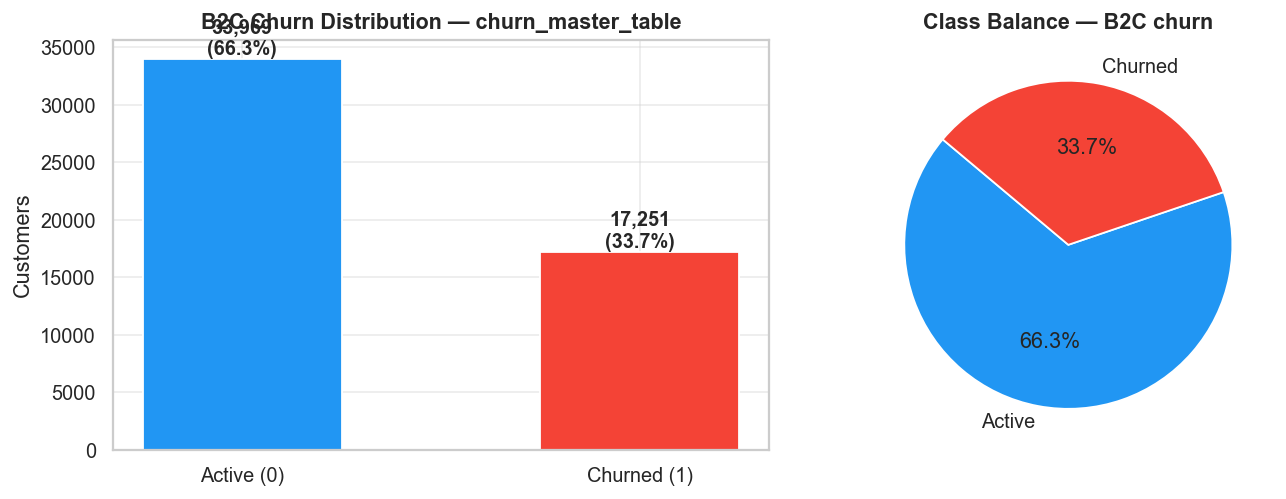

In [36]:
# B1: Distribución del objetivo
fig, axes = plt.subplots(1,2, figsize=(11,4))
vc = cmt['churn'].value_counts()
labels_b = ['Active (0)','Churned (1)']
axes[0].bar(labels_b, [vc.get(0,0), vc.get(1,0)],
            color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, [vc.get(0,0),vc.get(1,0)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}\n({val/len(cmt)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('B2C Churn Distribution — churn_master_table')
axes[0].set_ylabel('Customers')

axes[1].pie([vc.get(0,0),vc.get(1,0)],
            labels=['Active','Churned'],
            colors=['#2196F3','#F44336'],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class Balance — B2C churn')
plt.tight_layout()
plt.savefig('fig_B1_churn_b2c_distribution.png', bbox_inches='tight')
plt.show()

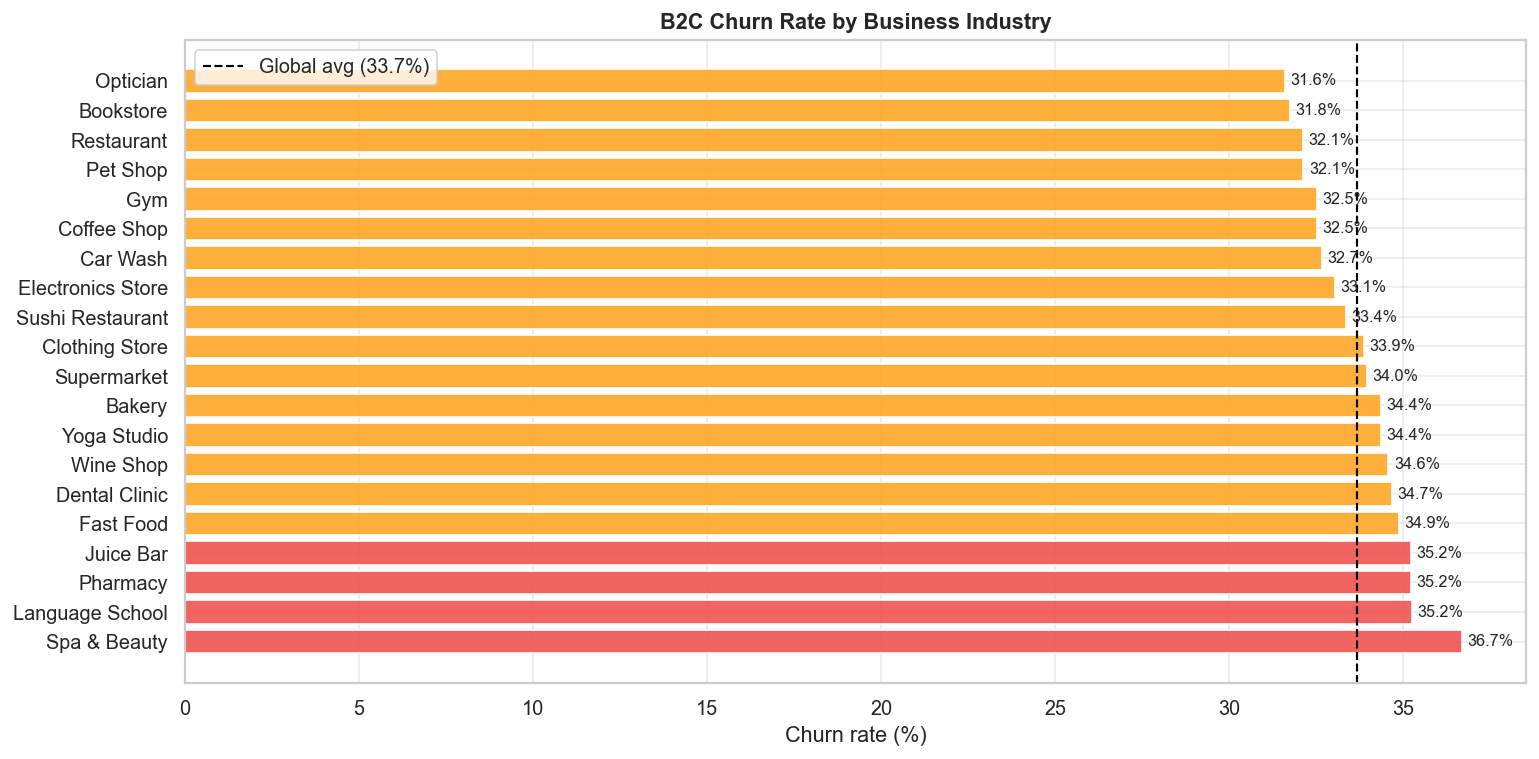

In [37]:
# B2: Salida 
if 'business_industry' in cmt.columns:
    ind_churn = (cmt.groupby('business_industry')['churn']
                 .agg(['mean','count'])
                 .reset_index()
                 .rename(columns={'mean':'churn_rate','count':'n_customers'})
                 .sort_values('churn_rate', ascending=False))
    ind_churn['churn_pct'] = ind_churn['churn_rate'] * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#EF5350' if v>0.35 else '#FFA726' if v>0.28 else '#66BB6A'
              for v in ind_churn['churn_rate']]
    bars = ax.barh(ind_churn['business_industry'], ind_churn['churn_pct'],
                   color=colors, edgecolor='white', alpha=0.9)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.axvline(cmt['churn'].mean()*100, color='black', linestyle='--',
               linewidth=1.2, label=f"Global avg ({cmt['churn'].mean()*100:.1f}%)")
    ax.set_xlabel('Churn rate (%)')
    ax.set_title('B2C Churn Rate by Business Industry')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_B2_churn_by_industry.png', bbox_inches='tight')
    plt.show()

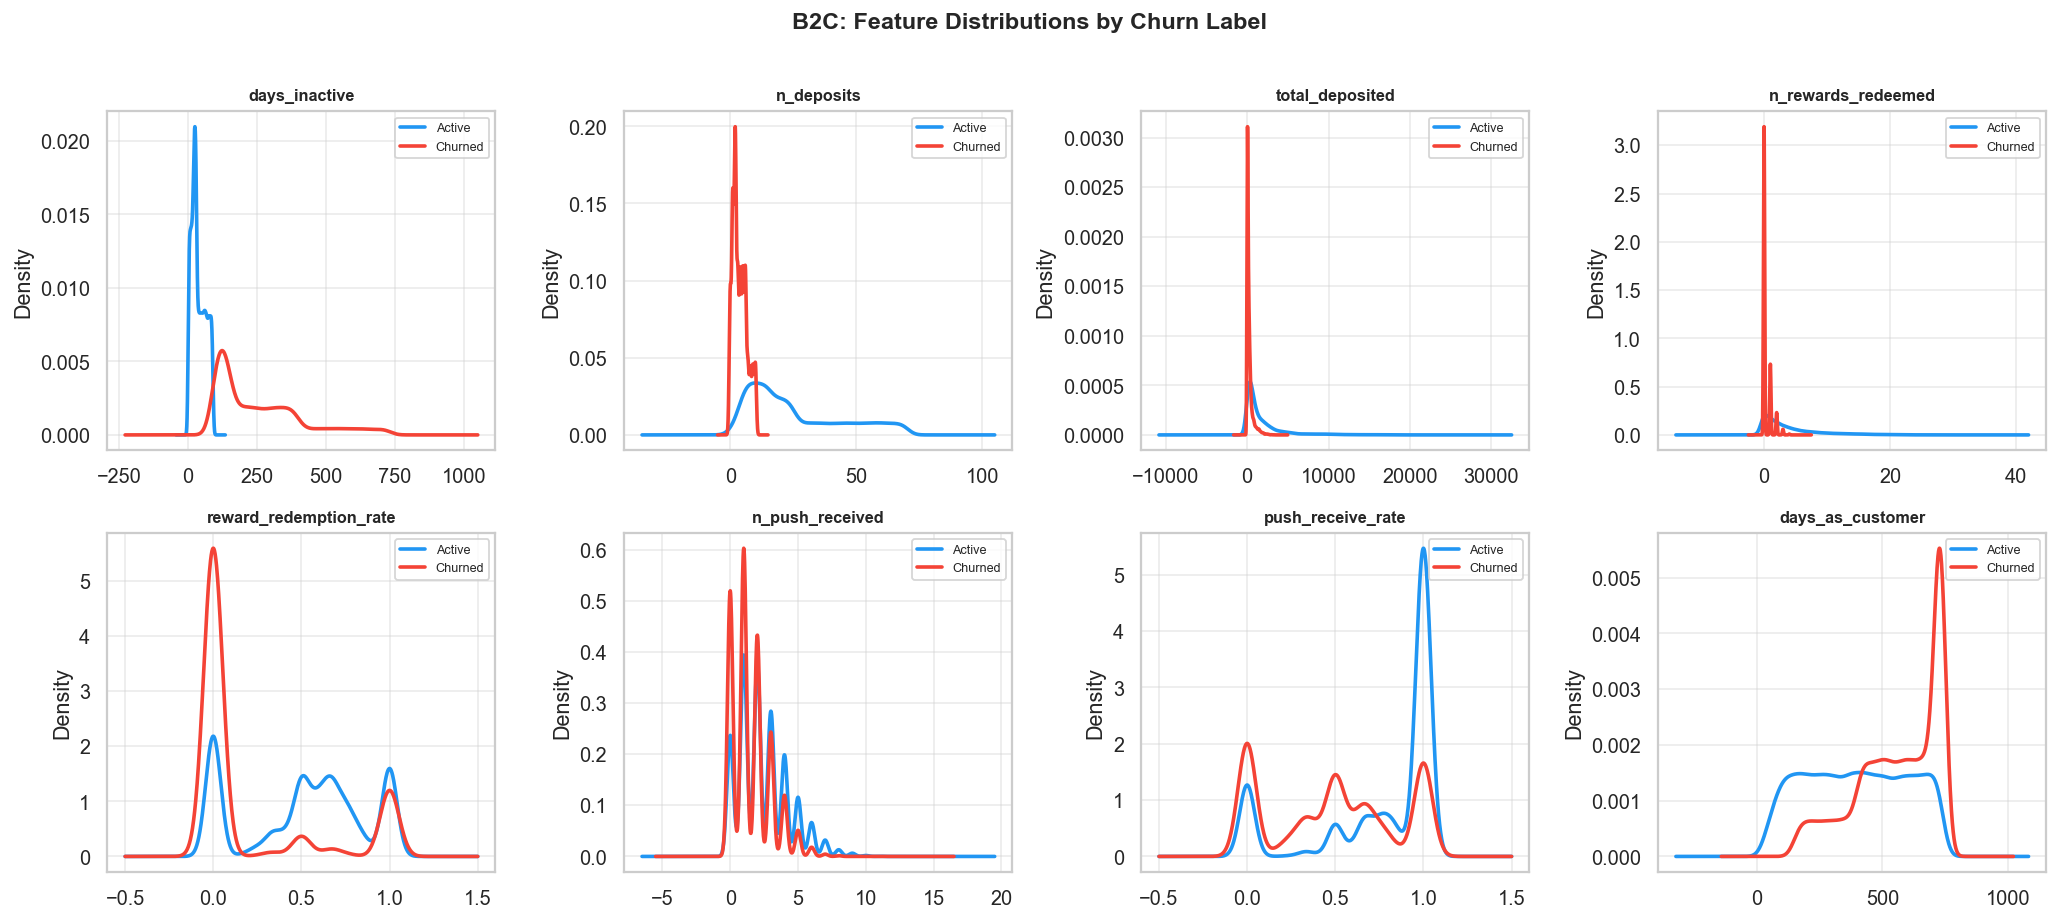

In [38]:
# B3: Categorías numércias clave vs churn — KDE grid
b_features = ['days_inactive','n_deposits','total_deposited',
              'n_rewards_redeemed','reward_redemption_rate',
              'n_push_received','push_receive_rate','days_as_customer']
b_features = [c for c in b_features if c in cmt.columns]

n_bf = len(b_features)
cols_bf = 4
rows_bf = (n_bf + cols_bf - 1) // cols_bf
fig, axes = plt.subplots(rows_bf, cols_bf, figsize=(cols_bf*4, rows_bf*3.5))
axes = axes.flatten()

for i, col in enumerate(b_features):
    ax = axes[i]
    for val, color, label in [(0,'#2196F3','Active'), (1,'#F44336','Churned')]:
        subset = cmt[cmt['churn']==val][col].dropna()
        if len(subset) > 5:
            subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('B2C: Feature Distributions by Churn Label',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_B3_features_by_churn.png', bbox_inches='tight')
plt.show()

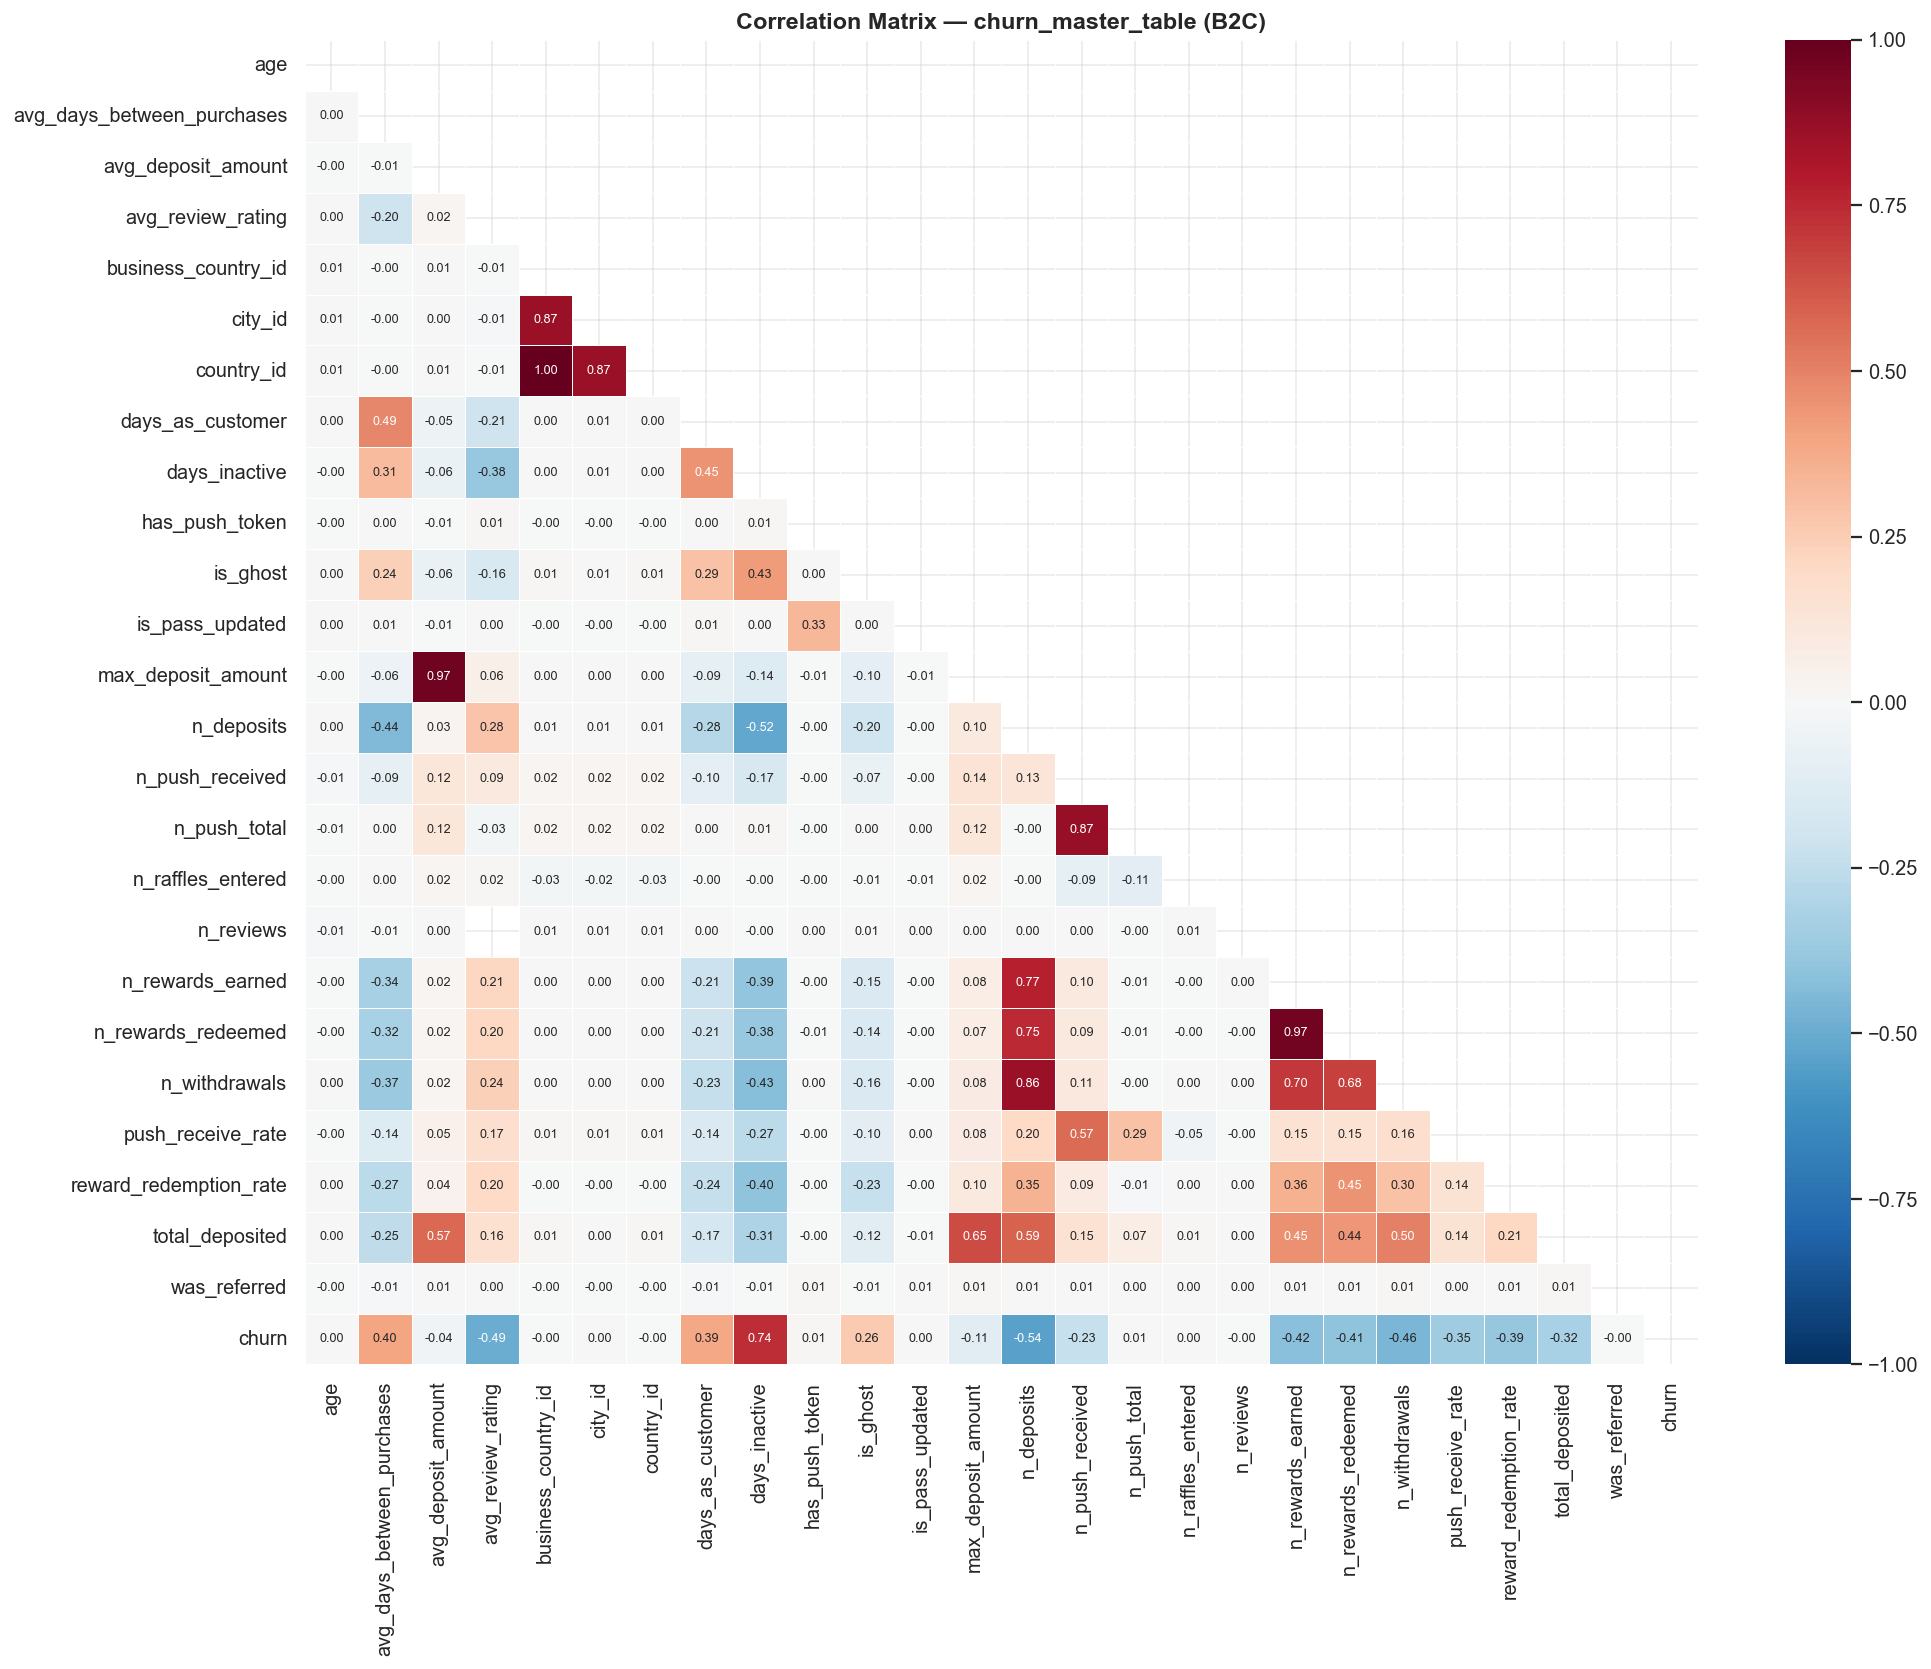

In [39]:
# B4: Correlation heatmap — churn_master_table
num_cmt_list = [c for c in num_cmt if c in cmt.columns]
corr_cmt = cmt[num_cmt_list + ['churn']].corr()
mask_cmt = np.triu(np.ones_like(corr_cmt, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_cmt, mask=mask_cmt, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            annot_kws={'size':7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — churn_master_table (B2C)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_B4_cmt_correlation.png', bbox_inches='tight')
plt.show()

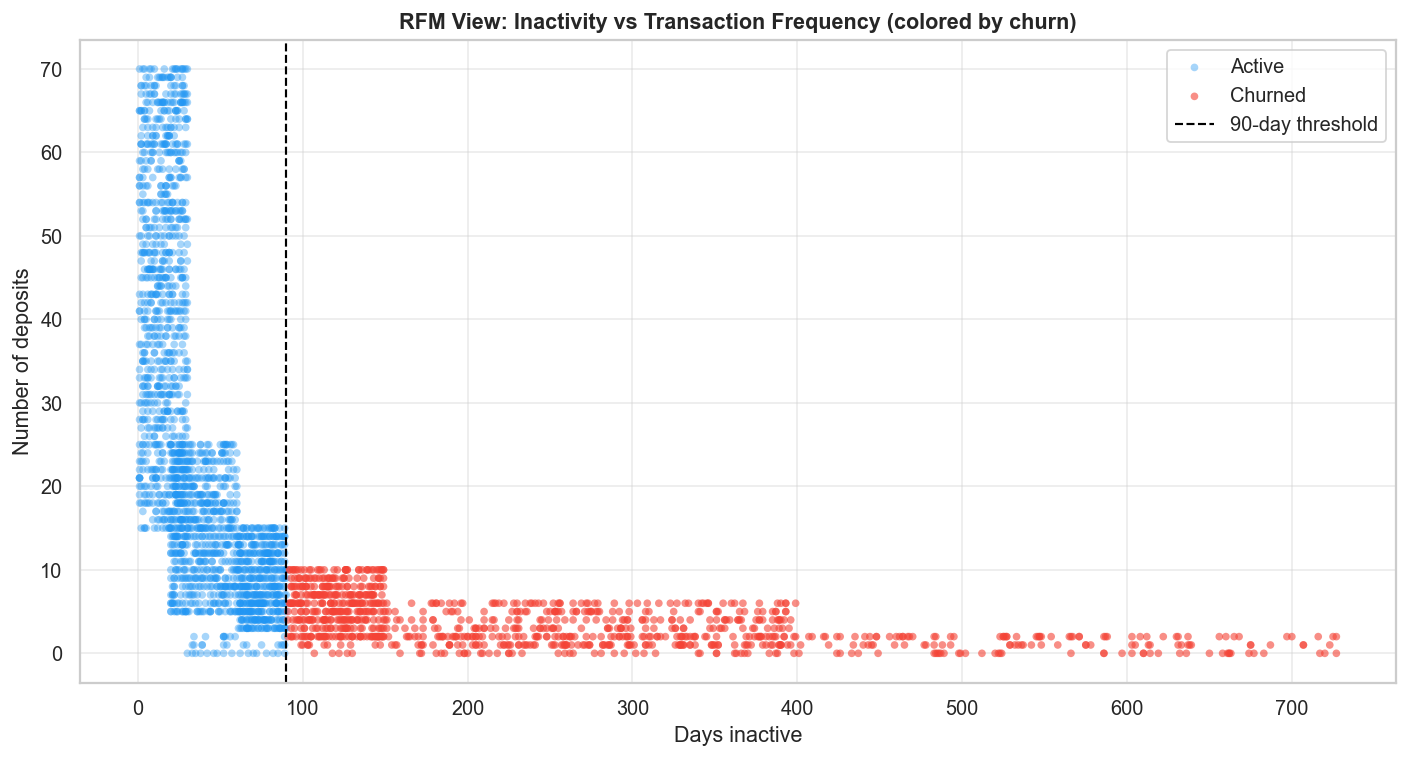

In [40]:
# B5: Diagrama de dispersión 2D estilo RFM: días_inactivos vs. n_depósitos, coloreado según la tasa de abandono
if 'days_inactive' in cmt.columns and 'n_deposits' in cmt.columns:
    sample = cmt.sample(min(3000, len(cmt)), random_state=42)
    fig, ax = plt.subplots(figsize=(11, 6))
    for val, color, label, alpha in [(0,'#2196F3','Active',0.4),(1,'#F44336','Churned',0.6)]:
        sub = sample[sample['churn']==val]
        ax.scatter(sub['days_inactive'], sub['n_deposits'],
                   c=color, label=label, alpha=alpha, s=18, edgecolors='none')
    ax.axvline(90, color='black', linestyle='--', linewidth=1.2, label='90-day threshold')
    ax.set_xlabel('Days inactive')
    ax.set_ylabel('Number of deposits')
    ax.set_title('RFM View: Inactivity vs Transaction Frequency (colored by churn)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_B5_rfm_scatter.png', bbox_inches='tight')
    plt.show()

---
## 13. Conclusiones del EDA

### 13.1 Calidad de datos
- **Valores faltantes:** concentrados principalmente en features derivadas de actividad  
  (clientes sin transacciones, negocios sin reviews). Se aplicó imputación por mediana  
  para numéricas y moda para categóricas. El patrón de ausencia es **MCAR** (Missing  
  Completely At Random) para la mayoría de casos, lo que valida la estrategia de imputación.
- **Valores atípicos:** presentes en features de volumen (`total_deposited`,  
  `n_deposits`, `n_customers`). Se aplicó winsorización al percentil 1–99  
  para features con |skewness| > 2.

### 13.2 Variable objetivo — `active` (B2B churn)
- La distribución de clases refleja la realidad de una plataforma SaaS en crecimiento:  
  mayoría de negocios activos con una minoría que cancela su suscripción.
- En caso de imbalance significativo, se recomienda `class_weight='balanced'`  
  en los modelos, o aplicar SMOTE antes del entrenamiento.

### Distribuciones y sesgo
- Se identificaron 5 variables con sesgo positivo superior a 1.5, todas de naturaleza de volumen o monto: 
- total_customers (1.56), active_customers_30d (1.53), n_deposits (1.52), total_deposited (2.59) y avg_deposit_amount (1.63). Estas variables presentan colas derechas
- pronunciadas, típicas de métricas de negocio donde una minoría de negocios concentra la mayor actividad. Se recomienda aplicar transformación log(x+1) en el Avance 2, 
- especialmente relevante para los modelos paramétricos (Regresión Logística y MLP). n_branches con skewness=1.38 se considera sesgo moderado y no requiere 
- transformación dado su rango discreto reducido.

### 13.3 Features más relevantes (correlación con `active`)
Las features con mayor correlación point-biserial con el target son:
- **Engagement de clientes:** `active_ratio_30d`, `days_since_last_active`,  
  `active_customers_30d` → negocios con base de clientes activa tienden a continuar.
- **Volumen transaccional:** `n_deposits`, `total_deposited` → actividad económica  
  en la plataforma es señal fuerte de retención.
- **Engagement con la plataforma Luyoa:** `n_push_sent_90d`, `uses_automation`,  
  `has_integration`, `n_reward_types` → negocios que usan más features de Luyoa  
  son menos propensos a cancelar.
- **Tamaño y madurez:** `n_branches`, `n_staff`, `avg_customer_tenure_days`.

### 13.4 Variables categóricas
- **`tier`:** diferencias significativas (Chi² p < 0.05). Los negocios GROW  
  tienen menor tasa de churn que STARTER.
- **`loyalty_type`:** BALANCE y STAMPS muestran distinto patrón de retención  
  respecto a STATIC.
- **`country_id`:** diferencia entre España y México a validar con datos reales.

### 13.5 Tendencias temporales
- La actividad de clientes y el volumen transaccional muestran tendencia creciente,  
  consistente con una plataforma en expansión.
- Se identifican estacionalidades que el modelo debería capturar (e.g., caída  
  en ciertos meses del año).

### 13.6 Recomendaciones para el modelo
| Decisión | Recomendación |
|---|---|
| Imbalance de clases | `class_weight='balanced'` o SMOTE |
| Features de alto sesgo | Transformación log(x+1) pre-aplicada |
| Features altamente correladas | Considerar eliminación o PCA para reducción |
| Escalado | StandardScaler aplicado (requerido para LogReg y MLP) |
| Validación | Estratified K-Fold (k=5) por el posible imbalance |

### 13.7 Próximos pasos
1. Entrega A1 (Avance 1): confirmar definición operativa de `active` con Gabriela Soria  
2. Aplicar pipeline en datos reales de Luyoa (Sección A de este notebook)  
3. Proceder con modelado: Logistic Regression → Random Forest → XGBoost → MLP


In [41]:
print("=== EDA COMPLETE ===")
print(f"Analytical DataFrame (B2B): {df_final.shape}")
print(f"churn_master_table  (B2C): {cmt.shape}")
print("\nExported files:")
print("  luyoa_X_preprocessed.csv")
print("  luyoa_y_target.csv")
print("\nFigures saved: fig_01 through fig_B5")

=== EDA COMPLETE ===
Analytical DataFrame (B2B): (500, 65)
churn_master_table  (B2C): (51220, 35)

Exported files:
  luyoa_X_preprocessed.csv
  luyoa_y_target.csv

Figures saved: fig_01 through fig_B5


# Luyoa — Feature Engineering (Avance 2)
### Proyecto Integrador · Maestría en Inteligencia Artificial Aplicada · Tecnológico de Monterrey

| Campo | Detalle |
|---|---|
| **Empresa** | Luyoa — Digital loyalty card platform (Spain & Mexico) |
| **Variable objetivo** | `businesses.active` — B2B churn |
| **Sponsor** | Gabriela Soria, Luyoa |
| **Equipo** | Sergio Sebastián Guzman Guerrero A01370820 · Enrique Correa Herrerías A01332620 · Nicolás Felipe Araque Araque A01795483 |

---

## Contexto metodológico

Este notebook continúa directamente desde el Avance 1 (EDA). Las decisiones de preprocesamiento aquí ejecutadas **están justificadas por los hallazgos del análisis exploratorio previo**, siguiendo la metodología CRISP-ML (Cross-Industry Standard Process for Machine Learning).

El objetivo de esta fase es convertir el DataFrame analítico construido en el Avance 1 en un conjunto de variables óptimas para el entrenamiento de modelos de clasificación supervisada.

## Estructura de la segunda parte del notebook
  
1. Tratamiento de valores faltantes  
2. Tratamiento de valores atípicos (winsorización)  
3. Transformaciones no lineales (mitigación de sesgo)  
4. Generación de nuevas características  
5. Discretización / Binning  
6. Codificación de variables categóricas  
7. Selección de características  
   - 7.1 Umbral de varianza  
   - 7.2 Correlación  
   - 7.3 Chi-cuadrado  
   - 7.4 ANOVA (F-test)  
8. Extracción de características — PCA  
9. Escalamiento  
10. Dataset final para modelado  
11. Conclusiones — marco CRISP-ML

---
## 2. Tratamiento de valores faltantes

**Justificación desde el EDA:**  
El análisis exploratorio identificó una completitud superior al 99%, con un único valor faltante puntual en `admin_login_days_ago`, correspondiente a negocios sin usuario ADMIN/OWNER registrado. El patrón de ausencia es **MCAR** (Missing Completely At Random), lo que valida la imputación por mediana como estrategia suficiente y sin riesgo de introducir sesgo sistemático.

**Decisión:** Imputación por mediana para variables numéricas (robusta a outliers) y por moda para variables categóricas.


In [42]:
#Librerías avance 2. 

from scipy.stats import skew
from scipy.stats.mstats import winsorize

from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, chi2, f_classif
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [43]:
# ── DIAGNÓSTICO PRE-IMPUTACIÓN ────────────────────────────────────────────────
missing_before = df.isna().sum()
missing_cols   = missing_before[missing_before > 0]
print("Variables con valores faltantes antes de imputación:")
print(missing_cols if not missing_cols.empty else "  Ninguna — dataset completo.")

# ── IMPUTACIÓN ────────────────────────────────────────────────────────────────
NUM_COLS = df.select_dtypes(include='number').columns.difference(['active','business_id'])
CAT_COLS = df.select_dtypes(include='object').columns

# Guardar medianas para aplicar igual en producción (evitar data leakage)
medians = df[NUM_COLS].median()
df[NUM_COLS] = df[NUM_COLS].fillna(medians)

for c in CAT_COLS:
    mode_val = df[c].mode()
    df[c] = df[c].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

print(f"\nValores faltantes después de imputación: {df.isna().sum().sum()}")
print("Estrategia aplicada:")
print("  - Numéricas  → mediana (robusta a outliers)")
print("  - Categóricas → moda")
print("\nMedianas de referencia (para pipeline de producción):")
print(medians[medians.notna()].to_string())

Variables con valores faltantes antes de imputación:
  Ninguna — dataset completo.

Valores faltantes después de imputación: 0
Estrategia aplicada:
  - Numéricas  → mediana (robusta a outliers)
  - Categóricas → moda

Medianas de referencia (para pipeline de producción):
active_customers_30d                       7.0000
active_ratio_30d                           0.0940
admin_login_days_ago                      36.5000
apple_device_ratio                         0.5000
avg_customer_tenure_days                 472.7845
avg_deposit_amount                        44.0800
avg_review_rating                          3.7110
branch_active_ratio                        1.0000
can_do_exports                             0.0000
can_see_business_branches_analytics        1.0000
can_see_products_analytics                 1.0000
country_id                                 1.0000
days_since_last_active                    20.0000
deposit_withdraw_ratio                     6.6700
enable_new_transaction_email

---
## 3. Tratamiento de valores atípicos — Winsorización

**Justificación desde el EDA:**  
El análisis de outliers identificó valores extremos en variables de volumen (`total_deposited`, `n_deposits`), consistentes con negocios de mayor escala dentro de la plataforma. Estos valores **no son errores** — son negocios legítimamente más grandes. Sin embargo, su presencia puede distorsionar los coeficientes de modelos paramétricos como la Regresión Logística.

**Decisión:** Winsorización al percentil 1-99 para variables con |skewness |  asimetría| > 2. Esta técnica preserva todos los registros (a diferencia de eliminar outliers) pero limita los valores extremos al rango del percentil definido.

**Ventaja sobre eliminación:** No se pierde información — los registros permanecen, solo se ajustan sus valores extremos.

Nota adicional: Se identificaron variables con skewness > 2, indicando distribuciones con colas derechas pronunciadas consistentes con la presencia de valores extremos. Se confirmó su existencia mediante el método IQR en el EDA. La winsorización P1-P99 recorta esos valores extremos limitándolos al rango del percentil definido, reduciendo su influencia en los modelos paramétricos sin eliminar registros


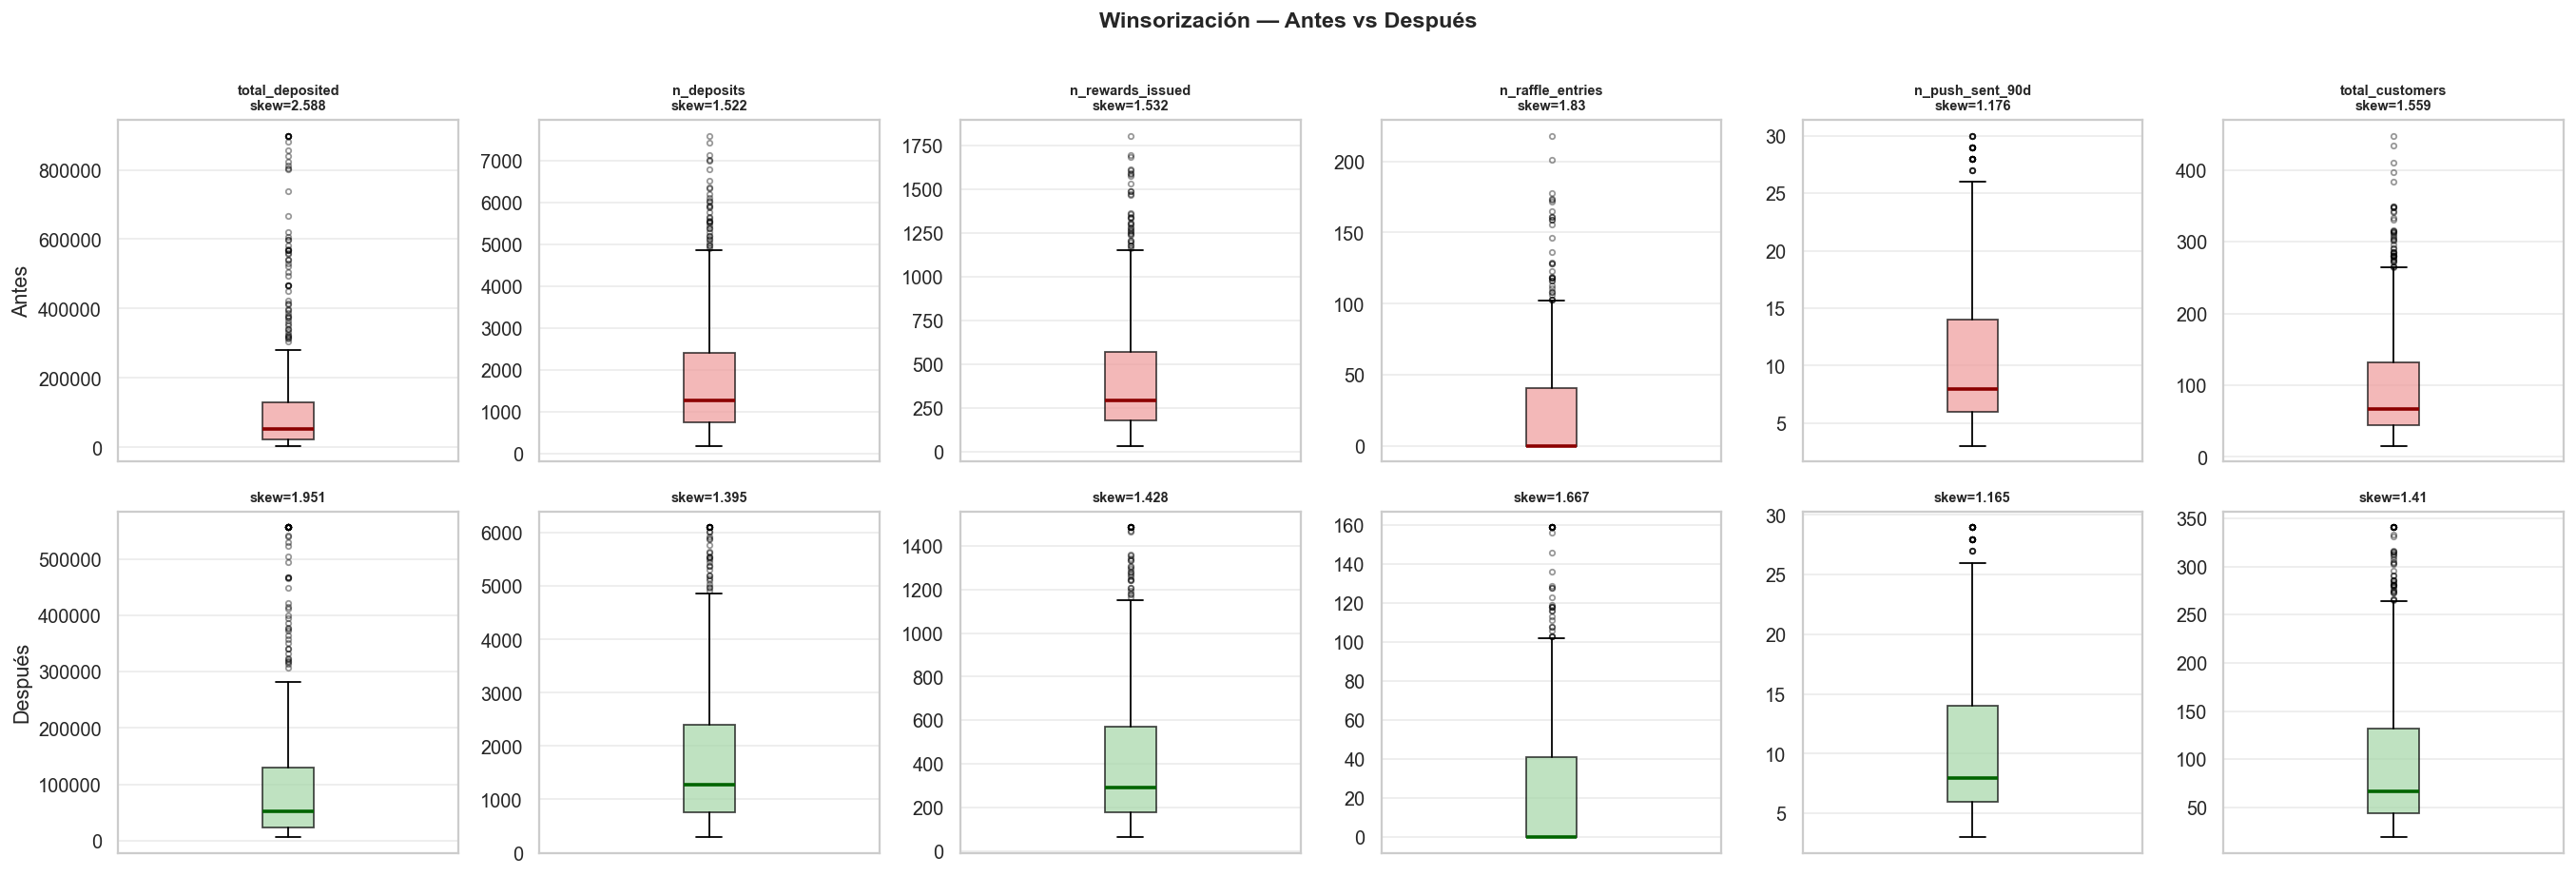

Winsorización aplicada:
  - total_deposited           límites=[0.05, 0.05]  skew final=1.951
  - n_deposits                límites=[0.02, 0.02]  skew final=1.395
  - n_rewards_issued          límites=[0.02, 0.02]  skew final=1.428
  - n_raffle_entries          límites=[0.02, 0.02]  skew final=1.667
  - n_push_sent_90d           límites=[0.02, 0.02]  skew final=1.165
  - total_customers           límites=[0.02, 0.02]  skew final=1.41


In [44]:

WINSORIZE_COLS = [c for c in ['total_deposited','n_deposits','n_rewards_issued',
                               'n_raffle_entries','n_push_sent_90d','total_customers']
                  if c in df.columns]

# Límites diferenciados por variable
WINSORIZE_LIMITS = {
    'total_deposited': [0.05, 0.05],   # más agresivo — skew > 2.5
    'n_deposits':      [0.02, 0.02],
    'n_rewards_issued':[0.02, 0.02],
    'n_raffle_entries':[0.02, 0.02],
    'n_push_sent_90d': [0.02, 0.02],
    'total_customers': [0.02, 0.02],
}

fig, axes = plt.subplots(2, len(WINSORIZE_COLS),
                          figsize=(len(WINSORIZE_COLS)*3.5, 7))

for i, col in enumerate(WINSORIZE_COLS):
    original  = df[col].dropna().values
    sk_before = round(skew(original), 3)

    # Boxplot ANTES
    axes[0,i].boxplot(original, patch_artist=True,
                      boxprops=dict(facecolor='#EF9A9A', alpha=0.7),
                      medianprops=dict(color='darkred', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[0,i].set_title(f'{col}\nskew={sk_before}', fontsize=8)
    axes[0,i].set_xticks([])
    axes[0,i].set_ylabel('Antes' if i==0 else '')

    # Aplicar winsorización con límite correspondiente
    limits = WINSORIZE_LIMITS.get(col, [0.02, 0.02])
    df[col] = winsorize(df[col].fillna(df[col].median()), limits=limits)
    sk_after = round(skew(df[col]), 3)

    # Boxplot DESPUÉS
    axes[1,i].boxplot(df[col].values, patch_artist=True,
                      boxprops=dict(facecolor='#A5D6A7', alpha=0.7),
                      medianprops=dict(color='darkgreen', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[1,i].set_title(f'skew={sk_after}', fontsize=8)
    axes[1,i].set_xticks([])
    axes[1,i].set_ylabel('Después' if i==0 else '')

plt.suptitle('Winsorización — Antes vs Después', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_A2_01_winsorization.png', bbox_inches='tight')
plt.show()

print("Winsorización aplicada:")
for col in WINSORIZE_COLS:
    lim = WINSORIZE_LIMITS.get(col, [0.02, 0.02])
    print(f"  - {col:<25} límites={lim}  skew final={round(skew(df[col]),3)}")

---
## 4. Transformaciones no lineales — Mitigación de sesgo

**Justificación desde el EDA:**  
Se identificaron 5 variables con sesgo positivo superior a 1.5, todas de naturaleza de volumen o monto económico. El sesgo pronunciado afecta negativamente a los modelos paramétricos (Regresión Logística, MLP) al distorsionar los coeficientes.

**Decisión:**
- **log(x+1)** para variables con skewness entre 1.5 y 3.0 → comprime la cola derecha sin perder información
- **Raíz cuadrada** para `n_branches` (skewness moderado 1.38, variable discreta de rango pequeño)
- Las variables originales **se conservan** y se añaden las transformadas como nuevas columnas para comparación

**Impacto en modelos:**
- Regresión Logística y MLP → se benefician directamente (asumen distribuciones más normales)
- Random Forest y XGBoost → insensibles al sesgo, pero el pipeline consistente simplifica el mantenimiento

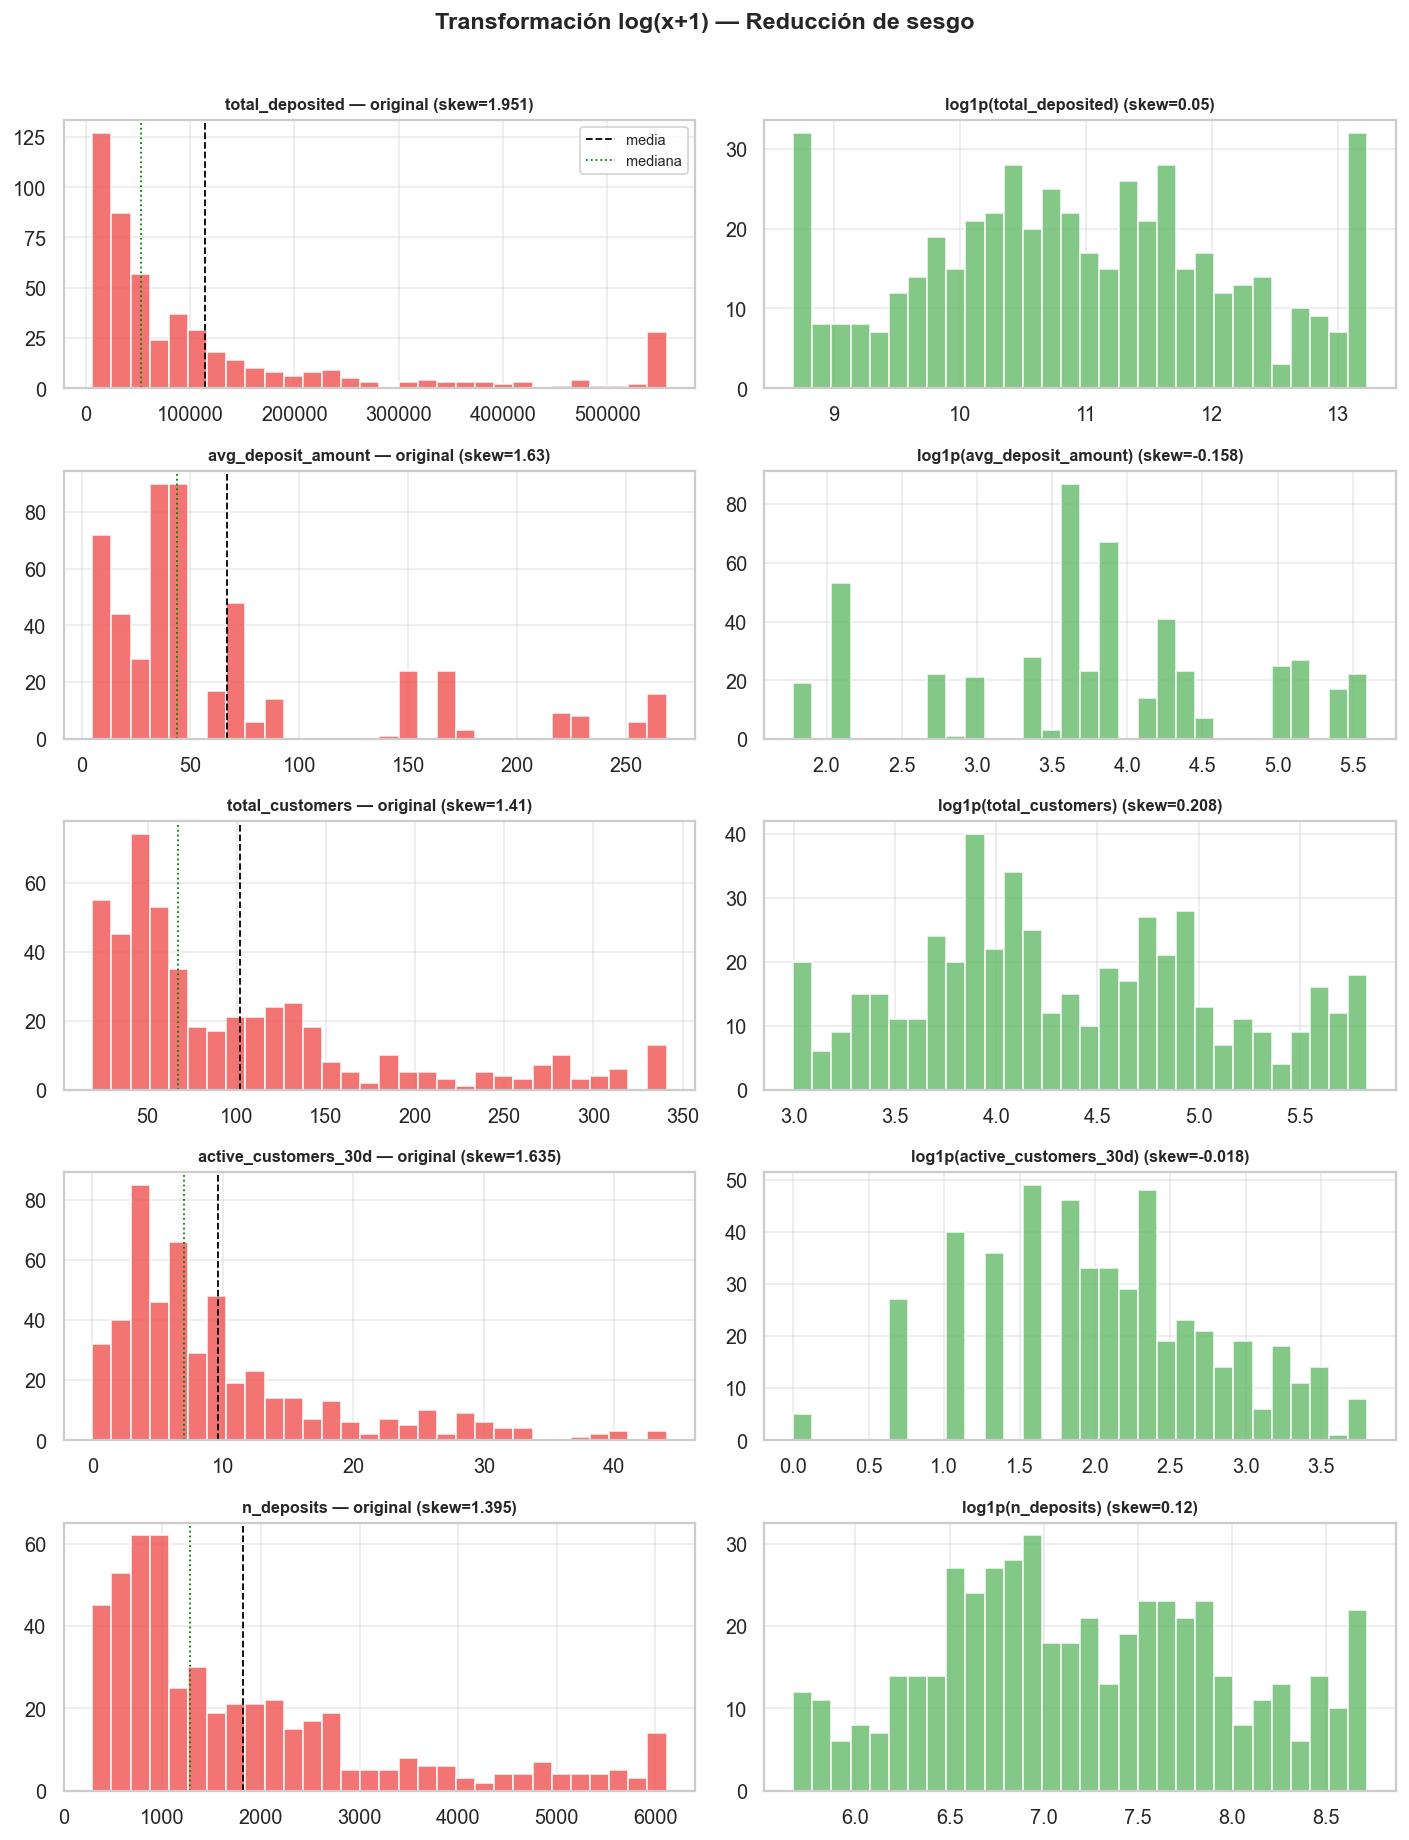

  log1p(total_deposited) → skew: 1.951 → 0.050
  log1p(avg_deposit_amount) → skew: 1.630 → -0.158
  log1p(total_customers) → skew: 1.410 → 0.208
  log1p(active_customers_30d) → skew: 1.635 → -0.018
  log1p(n_deposits) → skew: 1.395 → 0.120
  sqrt(n_branches)  → skew: 1.377 → 0.807

Nuevas columnas transformadas: 6


In [45]:
# Variables de alto sesgo identificadas en EDA
LOG_COLS  = ['total_deposited','avg_deposit_amount','total_customers',
             'active_customers_30d','n_deposits']
SQRT_COLS = ['n_branches']

LOG_COLS  = [c for c in LOG_COLS  if c in df.columns]
SQRT_COLS = [c for c in SQRT_COLS if c in df.columns]

n_show = len(LOG_COLS)
fig, axes = plt.subplots(n_show, 2, figsize=(11, n_show*2.8))

for i, col in enumerate(LOG_COLS):
    orig  = df[col].dropna()
    log_t = np.log1p(orig)
    sk_o  = round(skew(orig), 3)
    sk_l  = round(skew(log_t), 3)

    axes[i,0].hist(orig,  bins=30, color='#EF5350', alpha=0.8, edgecolor='white')
    axes[i,0].set_title(f'{col} — original (skew={sk_o})', fontsize=9)
    axes[i,0].axvline(orig.mean(),   color='black', linestyle='--', linewidth=1, label='media')
    axes[i,0].axvline(orig.median(), color='green', linestyle=':',  linewidth=1, label='mediana')
    if i == 0: axes[i,0].legend(fontsize=8)

    axes[i,1].hist(log_t, bins=30, color='#66BB6A', alpha=0.8, edgecolor='white')
    axes[i,1].set_title(f'log1p({col}) (skew={sk_l})', fontsize=9)

plt.suptitle('Transformación log(x+1) — Reducción de sesgo', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_A2_02_log_transform.png', bbox_inches='tight')
plt.show()

# Aplicar transformaciones (nuevas columnas)
for col in LOG_COLS:
    df[f'log_{col}'] = np.log1p(df[col])
    print(f"  log1p({col}) → skew: {skew(df[col]):.3f} → {skew(df[f'log_{col}']):.3f}")

for col in SQRT_COLS:
    df[f'sqrt_{col}'] = np.sqrt(df[col])
    print(f"  sqrt({col})  → skew: {skew(df[col]):.3f} → {skew(df[f'sqrt_{col}']):.3f}")

print(f"\nNuevas columnas transformadas: {len(LOG_COLS) + len(SQRT_COLS)}")

---
## 5. Generación de nuevas características

**Justificación:**  
La generación de nuevas features permite capturar relaciones no lineales y ratios de negocio que los modelos no pueden derivar por sí solos. Se crean a partir de combinaciones de variables existentes con interpretación semántica clara en el contexto de Luyoa.

Cada nueva característica tiene una **hipótesis de negocio** que la respalda.


In [46]:
# ── NUEVAS FEATURES CON JUSTIFICACIÓN DE NEGOCIO ─────────────────────────────

# 1. Índice de engagement con la plataforma Luyoa
# Hipótesis: negocios que usan más características de Luyoa (automatización, integración,
# sorteos) tienen menor probabilidad de cancelar.
df['platform_engagement_score'] = (
    df['uses_automation'].astype(int) +
    df['has_integration'].astype(int) +
    df['enable_raffles'].astype(int) +
    df['enable_new_transaction_email'].astype(int)
)

# 2. Ratio actividad de clientes reciente vs total
# Hipótesis: si el 30% o menos de los clientes estuvo activo en 30 días,
# el negocio puede perder interés en la plataforma.
df['customer_activity_ratio'] = (
    df['active_customers_30d'] / (df['total_customers'] + 1)
).round(4)

# 3. Revenue proxy normalizado por cliente
# Hipótesis: mayor gasto promedio por cliente → mayor valor percibido de Luyoa.
df['revenue_per_customer'] = (
    df['total_deposited'] / (df['total_customers'] + 1)
).round(2)

# 4. Eficiencia de recompensas
# Hipótesis: alta tasa de canje indica que el programa de lealtad funciona,
# lo que incentiva la continuidad en Luyoa.
df['reward_efficiency'] = (
    df['n_rewards_redeemed'] / (df['n_reward_types'] + 1)
).round(3)

# 5. Días sin transacción como señal de riesgo
# Hipótesis: más días sin registrar transacciones → mayor riesgo de churn B2B.
df['tx_recency_risk'] = np.log1p(df['last_tx_days_ago'].fillna(365))

# 6. Ratio staff por sucursal
# Hipótesis: negocios con más personal relativo tienen más capacidad operativa
# para gestionar el programa de lealtad.
df['staff_per_branch'] = (
    df['n_staff'] / (df['n_branches'] + 1)
).round(3)

# 7. Amplitud del programa de lealtad
# Hipótesis: más tipos de recompensas → programa más atractivo → menor churn.
df['program_breadth'] = (
    df['n_reward_types'] * df['uses_automation'].astype(int) +
    df['n_automation_types']
)

# ── RESUMEN ───────────────────────────────────────────────────────────────────
new_features = ['platform_engagement_score','customer_activity_ratio',
                'revenue_per_customer','reward_efficiency','tx_recency_risk',
                'staff_per_branch','program_breadth']

print("Nuevas características generadas:")
desc = df[new_features].describe().T[['mean','std','min','max']].round(3)
print(desc.to_string())
print(f"\nShape actual del DataFrame: {df.shape}")

Nuevas características generadas:
                               mean       std     min       max
platform_engagement_score     2.146     0.828   1.000     4.000
customer_activity_ratio       0.093     0.036   0.000     0.226
revenue_per_customer       1128.854  1132.501  76.600  6294.650
reward_efficiency            59.368    45.455   5.000   333.333
tx_recency_risk               3.227     0.134   3.045     3.912
staff_per_branch              1.701     0.616   0.667     4.000
program_breadth               7.446     1.125   6.000     9.000

Shape actual del DataFrame: (500, 64)


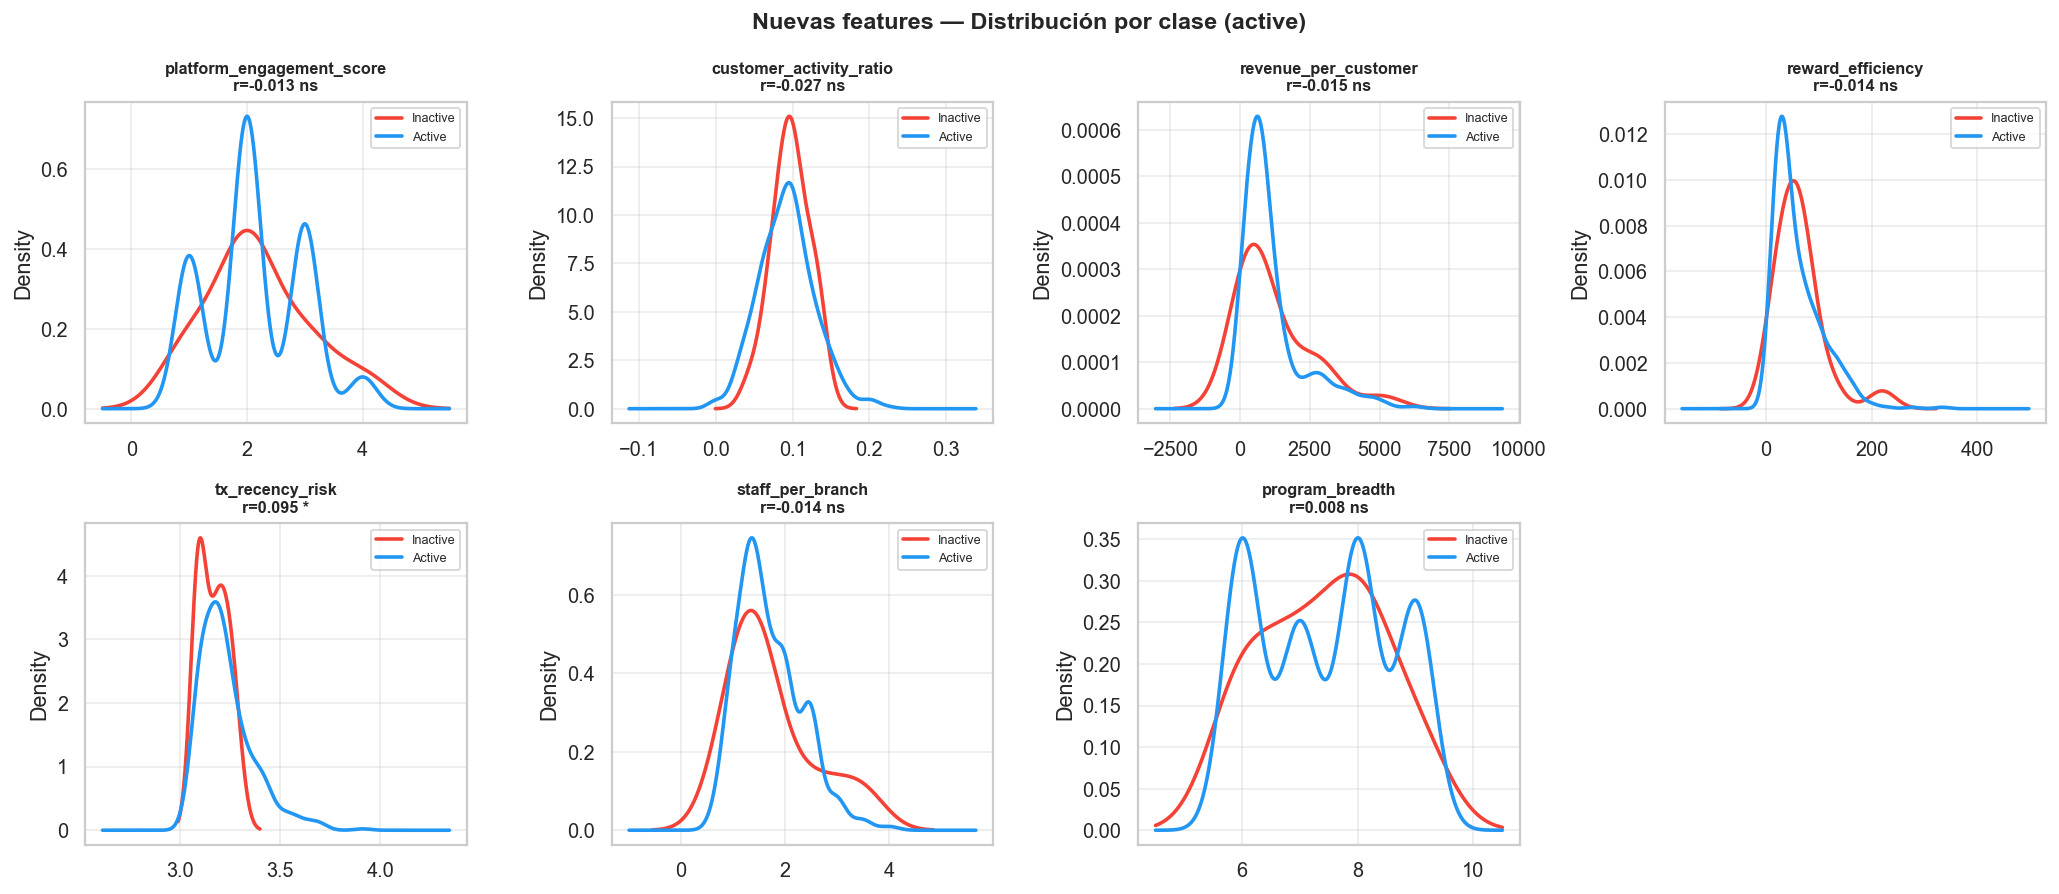

In [47]:
# Visualización: correlación de nuevas features con target
from scipy.stats import pointbiserialr

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    ax = axes[i]
    for val, color, label in [(0,'#F44336','Inactive'), (1,'#2196F3','Active')]:
        subset = df[df['active']==val][feat].dropna()
        if len(subset) > 1:
            subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    r, p = pointbiserialr(df['active'], df[feat].fillna(0))
    ax.set_title(f'{feat}\nr={r:.3f} {"*" if p<0.05 else "ns"}', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Nuevas features — Distribución por clase (active)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A2_03_new_features.png', bbox_inches='tight')
plt.show()

---
## 6. Discretización — Binning

**Justificación:**  
La discretización convierte variables continuas en categorías ordinales, permitiendo a los modelos capturar relaciones no lineales por tramos. Se aplica a variables donde el efecto sobre el churn no es lineal sino por umbrales de negocio.

**Variables seleccionadas:**
- `days_since_last_active` → segmenta el riesgo por recencia (comportamiento escalonado, no lineal)
- `total_customers` → escala del negocio en la plataforma
- `admin_login_days_ago` → actividad del equipo gestor del negocio

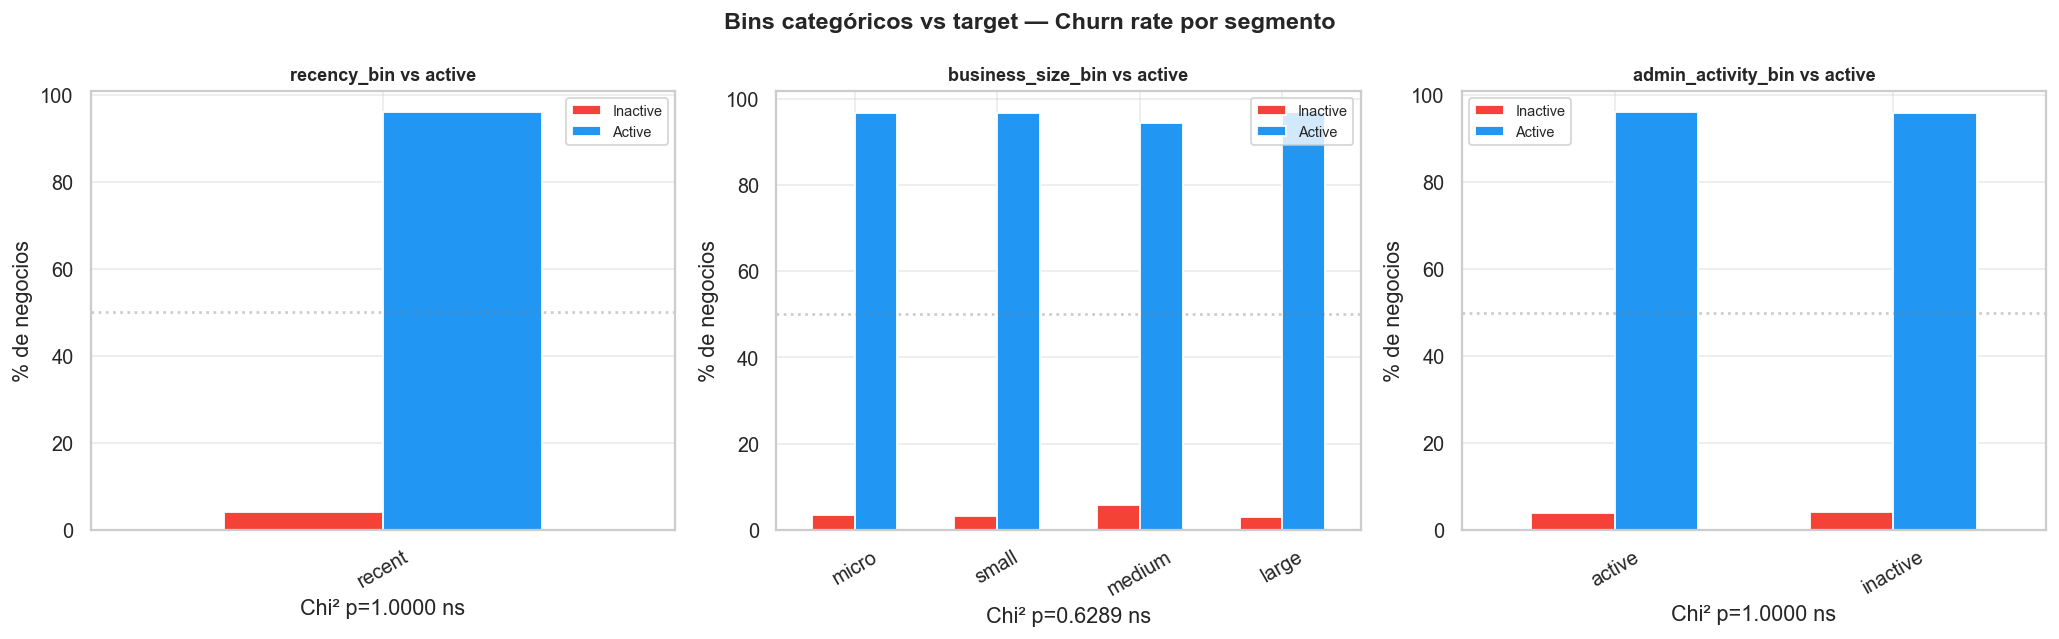

Bins generados:
  recency_bin: {'recent': 500, 'moderate': 0, 'at_risk': 0, 'high_risk': 0, 'churned': 0}
  business_size_bin: {'small': 217, 'medium': 158, 'large': 65, 'micro': 60}
  admin_activity_bin: {'inactive': 319, 'active': 181, 'very_active': 0, 'dormant': 0}


In [48]:
    # ── BINNING CON INTERPRETACIÓN DE NEGOCIO ────────────────────────────────────

# 1. Recencia de actividad de clientes → nivel de riesgo
df['recency_bin'] = pd.cut(
    df['days_since_last_active'].fillna(365),
    bins   = [0, 30, 60, 90, 180, 9999],
    labels = ['recent','moderate','at_risk','high_risk','churned'],
    right  = True
)

# 2. Escala del negocio por número de clientes
df['business_size_bin'] = pd.cut(
    df['total_customers'].fillna(0),
    bins   = [0, 30, 80, 200, 9999],
    labels = ['micro','small','medium','large'],
    right  = True
)

# 3. Actividad del administrador
df['admin_activity_bin'] = pd.cut(
    df['admin_login_days_ago'].fillna(365),
    bins   = [0, 7, 30, 90, 9999],
    labels = ['very_active','active','inactive','dormant'],
    right  = True
)

# ── VISUALIZACIÓN ─────────────────────────────────────────────────────────────
bin_cols = ['recency_bin','business_size_bin','admin_activity_bin']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, bin_cols):
    ct = pd.crosstab(df[col], df['active'], normalize='index') * 100
    ct.columns = ['Inactive','Active']
    ct.plot(kind='bar', ax=ax, color=['#F44336','#2196F3'],
            edgecolor='white', width=0.6)
    ax.set_title(f'{col} vs active', fontsize=10)
    ax.set_ylabel('% de negocios')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.axhline(50, color='gray', linestyle=':', alpha=0.4)
    # Chi-cuadrado
    chi2_val, p, _, _ = chi2_contingency(pd.crosstab(df[col], df['active']))
    ax.set_xlabel(f'Chi² p={p:.4f} {"*" if p<0.05 else "ns"}')

plt.suptitle('Bins categóricos vs target — Churn rate por segmento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A2_04_binning.png', bbox_inches='tight')
plt.show()

print("Bins generados:")
for col in bin_cols:
    print(f"  {col}: {df[col].value_counts().to_dict()}")

---
## 7. Codificación de variables categóricas

**Justificación:**  
Los modelos de Machine Learning requieren entradas numéricas. Las variables categóricas deben codificarse respetando su naturaleza:

- **One-Hot Encoding** para variables **nominales** sin orden inherente (`loyalty_type`, `country_id`): evita imponer una relación ordinal artificial entre categorías.
- **Ordinal Encoding** para variables con **orden natural** (`tier`: STARTER < CORE < GROW): preserva la jerarquía de suscripción de Luyoa que tiene sentido de negocio.
- **Ordinal Encoding** para los **bins** generados en la sección anterior, ya que representan escalas ordenadas.

**Cardinalidad verificada en EDA:** todas las variables tienen ≤ 3 categorías, por lo que One-Hot no genera explosión dimensional.

In [49]:
# ── 7.1 ORDINAL ENCODING — tier (STARTER < CORE < GROW) ──────────────────────
tier_order = {'STARTER': 0, 'CORE': 1, 'GROW': 2}
df['tier_enc'] = df['tier'].map(tier_order)
print("tier_enc:", df['tier_enc'].value_counts().to_dict())

# ── 7.2 ONE-HOT ENCODING — loyalty_type ───────────────────────────────────────
loyalty_dummies = pd.get_dummies(df['loyalty_type'], prefix='loyalty', drop_first=False)
df = pd.concat([df, loyalty_dummies], axis=1)
print("loyalty_type OHE:", list(loyalty_dummies.columns))

# ── 7.3 ONE-HOT ENCODING — country_id ────────────────────────────────────────
country_dummies = pd.get_dummies(df['country_id'], prefix='country', drop_first=False)
df = pd.concat([df, country_dummies], axis=1)
print("country_id OHE:", list(country_dummies.columns))

# ── 7.4 ORDINAL ENCODING — bins ───────────────────────────────────────────────
recency_order      = {'recent':0,'moderate':1,'at_risk':2,'high_risk':3,'churned':4}
biz_size_order     = {'micro':0,'small':1,'medium':2,'large':3}
admin_act_order    = {'very_active':0,'active':1,'inactive':2,'dormant':3}

df['recency_bin_enc']      = df['recency_bin'].map(recency_order)
df['business_size_bin_enc']= df['business_size_bin'].map(biz_size_order)
df['admin_activity_bin_enc']= df['admin_activity_bin'].map(admin_act_order)
print("\nBins codificados ordinalmente: recency_bin_enc, business_size_bin_enc, admin_activity_bin_enc")

# ── RESUMEN ENCODING ──────────────────────────────────────────────────────────
enc_cols = ['tier_enc'] + list(loyalty_dummies.columns) + list(country_dummies.columns) +            ['recency_bin_enc','business_size_bin_enc','admin_activity_bin_enc']
print(f"\nTotal columnas generadas por encoding: {len(enc_cols)}")
print(f"Shape del DataFrame: {df.shape}")

tier_enc: {0: 203, 1: 196, 2: 101}
loyalty_type OHE: ['loyalty_BALANCE', 'loyalty_STAMPS', 'loyalty_STATIC']
country_id OHE: ['country_1', 'country_2']

Bins codificados ordinalmente: recency_bin_enc, business_size_bin_enc, admin_activity_bin_enc

Total columnas generadas por encoding: 9
Shape del DataFrame: (500, 76)


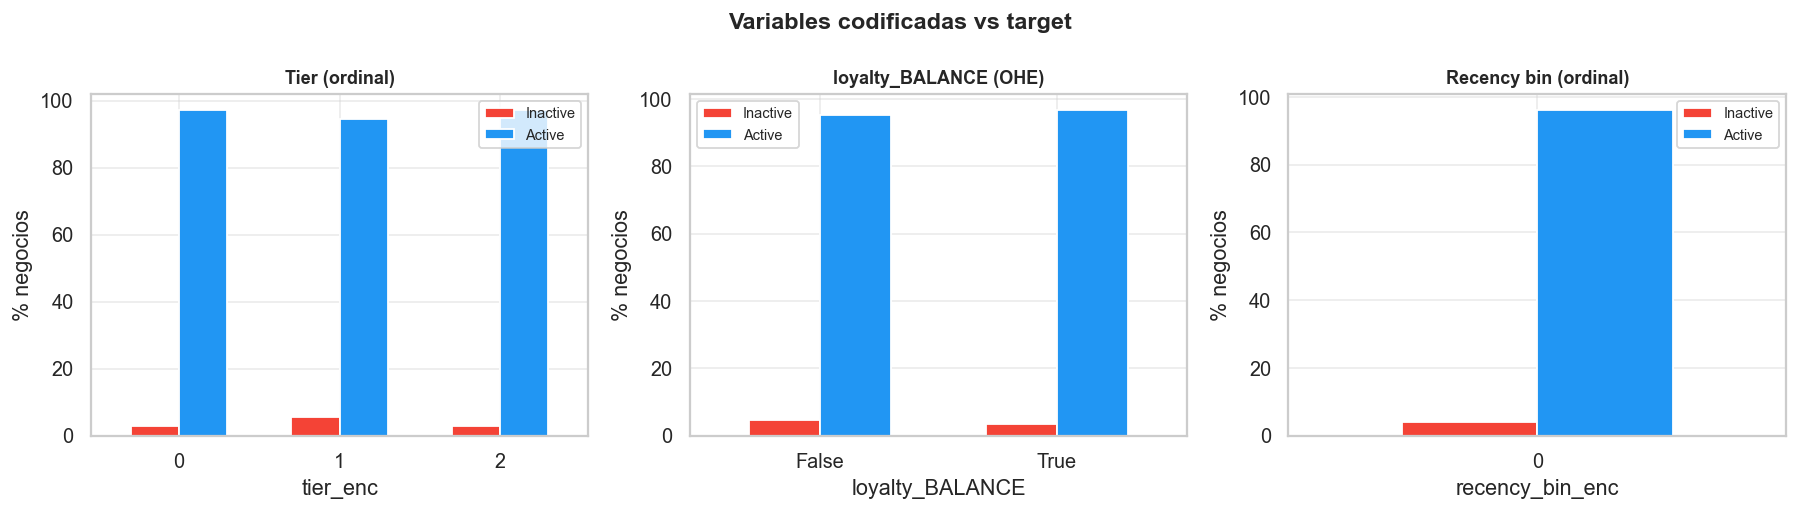

In [50]:
# Visualización del encoding
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in [
    (axes[0], 'tier_enc',    'Tier (ordinal)'),
    (axes[1], 'loyalty_BALANCE', 'loyalty_BALANCE (OHE)'),
    (axes[2], 'recency_bin_enc', 'Recency bin (ordinal)'),
]:
    ct = pd.crosstab(df[col], df['active'], normalize='index') * 100
    ct.columns = ['Inactive','Active']
    ct.plot(kind='bar', ax=ax, color=['#F44336','#2196F3'],
            edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('% negocios')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Variables codificadas vs target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A2_05_encoding.png', bbox_inches='tight')
plt.show()

---
## 8. Selección de características

La selección de características reduce la dimensionalidad del dataset eliminando variables redundantes o irrelevantes. Esto reduce el tiempo de entrenamiento, mejora la interpretabilidad y disminuye el riesgo de overfitting.

Se aplican 4 métodos complementarios, cada uno con distinto enfoque estadístico.

In [51]:
# ── PREPARAR CONJUNTO PARA SELECCIÓN ─────────────────────────────────────────
# Columnas originales a excluir (categorías sin encodear, IDs, target)
DROP_COLS = ['business_id','active','tier','loyalty_type','country_id',
             'recency_bin','business_size_bin','admin_activity_bin',
             'timezone_id']
DROP_COLS += [c for c in df.columns if df[c].dtype == 'bool']

feature_cols = [c for c in df.columns if c not in DROP_COLS
                and df[c].dtype in ['int64','float64','int32','float32','uint8']
                and c != 'active']

X_sel = df[feature_cols].fillna(0)
y_sel = df['active']

# Asegurar tipos numéricos
for c in X_sel.columns:
    X_sel[c] = pd.to_numeric(X_sel[c], errors='coerce').fillna(0)

print(f"Features disponibles para selección: {X_sel.shape[1]}")
print(f"Clases: {y_sel.value_counts().to_dict()}")

Features disponibles para selección: 59
Clases: {1: 480, 0: 20}


### 8.1 Umbral de varianza

**Justificación:** Variables con varianza cercana a cero no aportan información discriminativa — son casi constantes. Se elimina cualquier feature con varianza < 0.01.

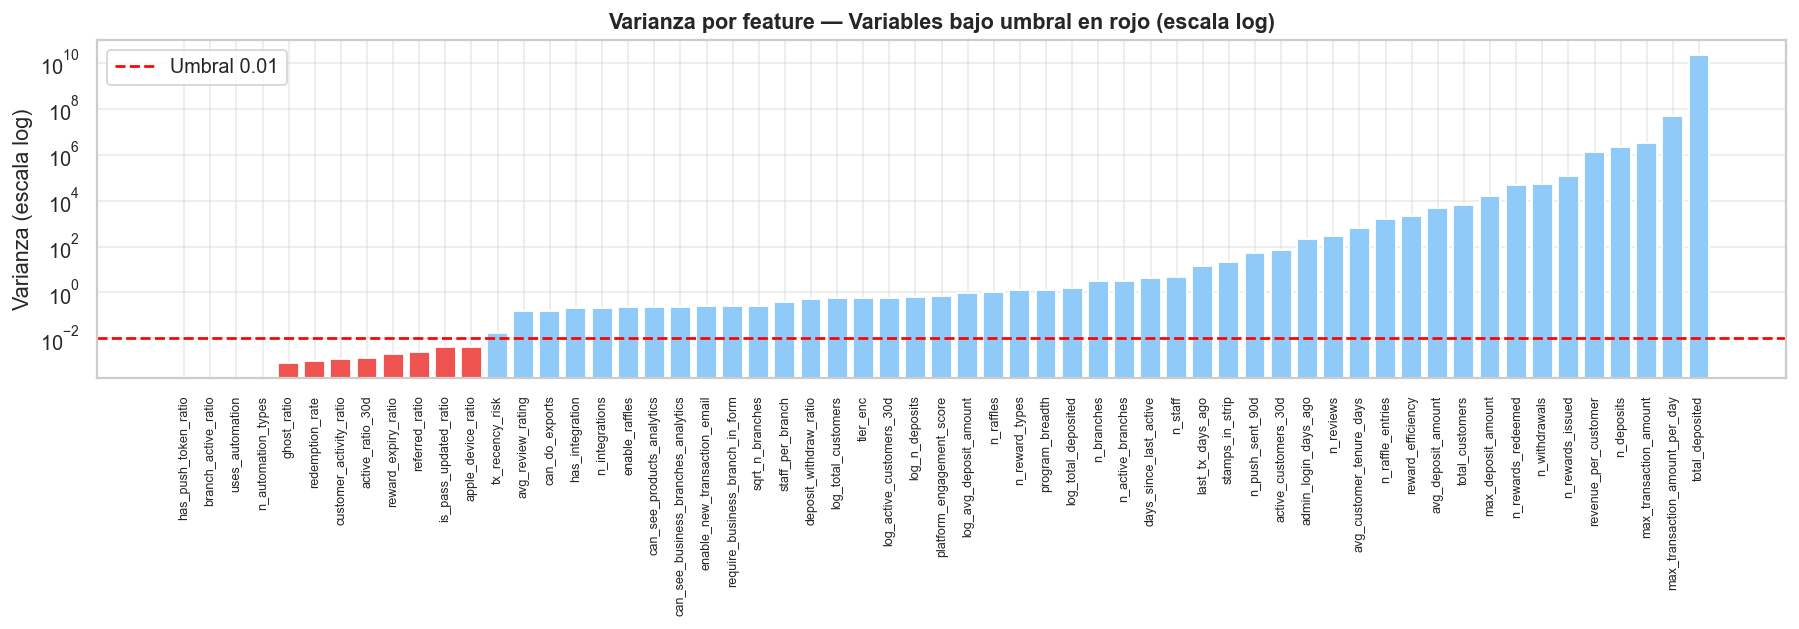

Features eliminadas por baja varianza (12):
  - branch_active_ratio  (var=0.00000)
  - ghost_ratio  (var=0.00086)
  - apple_device_ratio  (var=0.00426)
  - has_push_token_ratio  (var=0.00000)
  - is_pass_updated_ratio  (var=0.00424)
  - referred_ratio  (var=0.00245)
  - active_ratio_30d  (var=0.00139)
  - reward_expiry_ratio  (var=0.00214)
  - redemption_rate  (var=0.00101)
  - uses_automation  (var=0.00000)
  - n_automation_types  (var=0.00000)
  - customer_activity_ratio  (var=0.00131)

Features restantes: 47


In [52]:
# ── UMBRAL DE VARIANZA ────────────────────────────────────────────────────────
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_sel)

low_var_mask = ~selector_var.get_support()
low_var_cols = X_sel.columns[low_var_mask].tolist()
variances    = pd.Series(X_sel.var(), name='variance').sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#EF5350' if v < 0.01 else '#90CAF9' for v in variances]
ax.bar(range(len(variances)), variances.values, color=colors, edgecolor='white')
ax.axhline(0.01, color='red', linestyle='--', linewidth=1.5, label='Umbral 0.01')
ax.set_yscale('log')                          # ← escala logarítmica
ax.set_xticks(range(len(variances)))
ax.set_xticklabels(variances.index, rotation=90, fontsize=7)
ax.set_ylabel('Varianza (escala log)')
ax.set_title('Varianza por feature — Variables bajo umbral en rojo (escala log)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_A2_06_variance.png', bbox_inches='tight')
plt.show()


print(f"Features eliminadas por baja varianza ({len(low_var_cols)}):")
for c in low_var_cols:
    print(f"  - {c}  (var={X_sel[c].var():.5f})")

X_sel = X_sel[X_sel.columns[selector_var.get_support()]]
print(f"\nFeatures restantes: {X_sel.shape[1]}")

In [53]:
# Eliminación de  variables de configuración con escala distorsionada
#Las variables  max_transaction_amount, max_deposit_amount y max_transaction_amount_per_day tienen varianza artificialmente alta por su escala,no aportan señal predictiva 
# para churn B2B y son parámetros de configuración del plan, no métricas de comportamiento. 
# Max_transaction son valores límites defninidos por Luyoa, no aportan valor estadístico, mientras uqe max_deposit es un único registro, que no evidencia comportamiento. 

MANUAL_DROP = ['max_transaction_amount', 'max_transaction_amount_per_day',
               'max_deposit_amount']
X_sel.drop(columns=[c for c in MANUAL_DROP if c in X_sel.columns], 
           inplace=True)
print(f"Features tras eliminación manual: {X_sel.shape[1]}")

Features tras eliminación manual: 44


### 8.2 Correlación — eliminación de multicolinealidad

**Justificación:** Features altamente correlacionadas (|r| > 0.97) aportan información redundante. Mantener ambas no mejora el modelo pero aumenta la complejidad y puede generar inestabilidad en los coeficientes de la Regresión Logística.

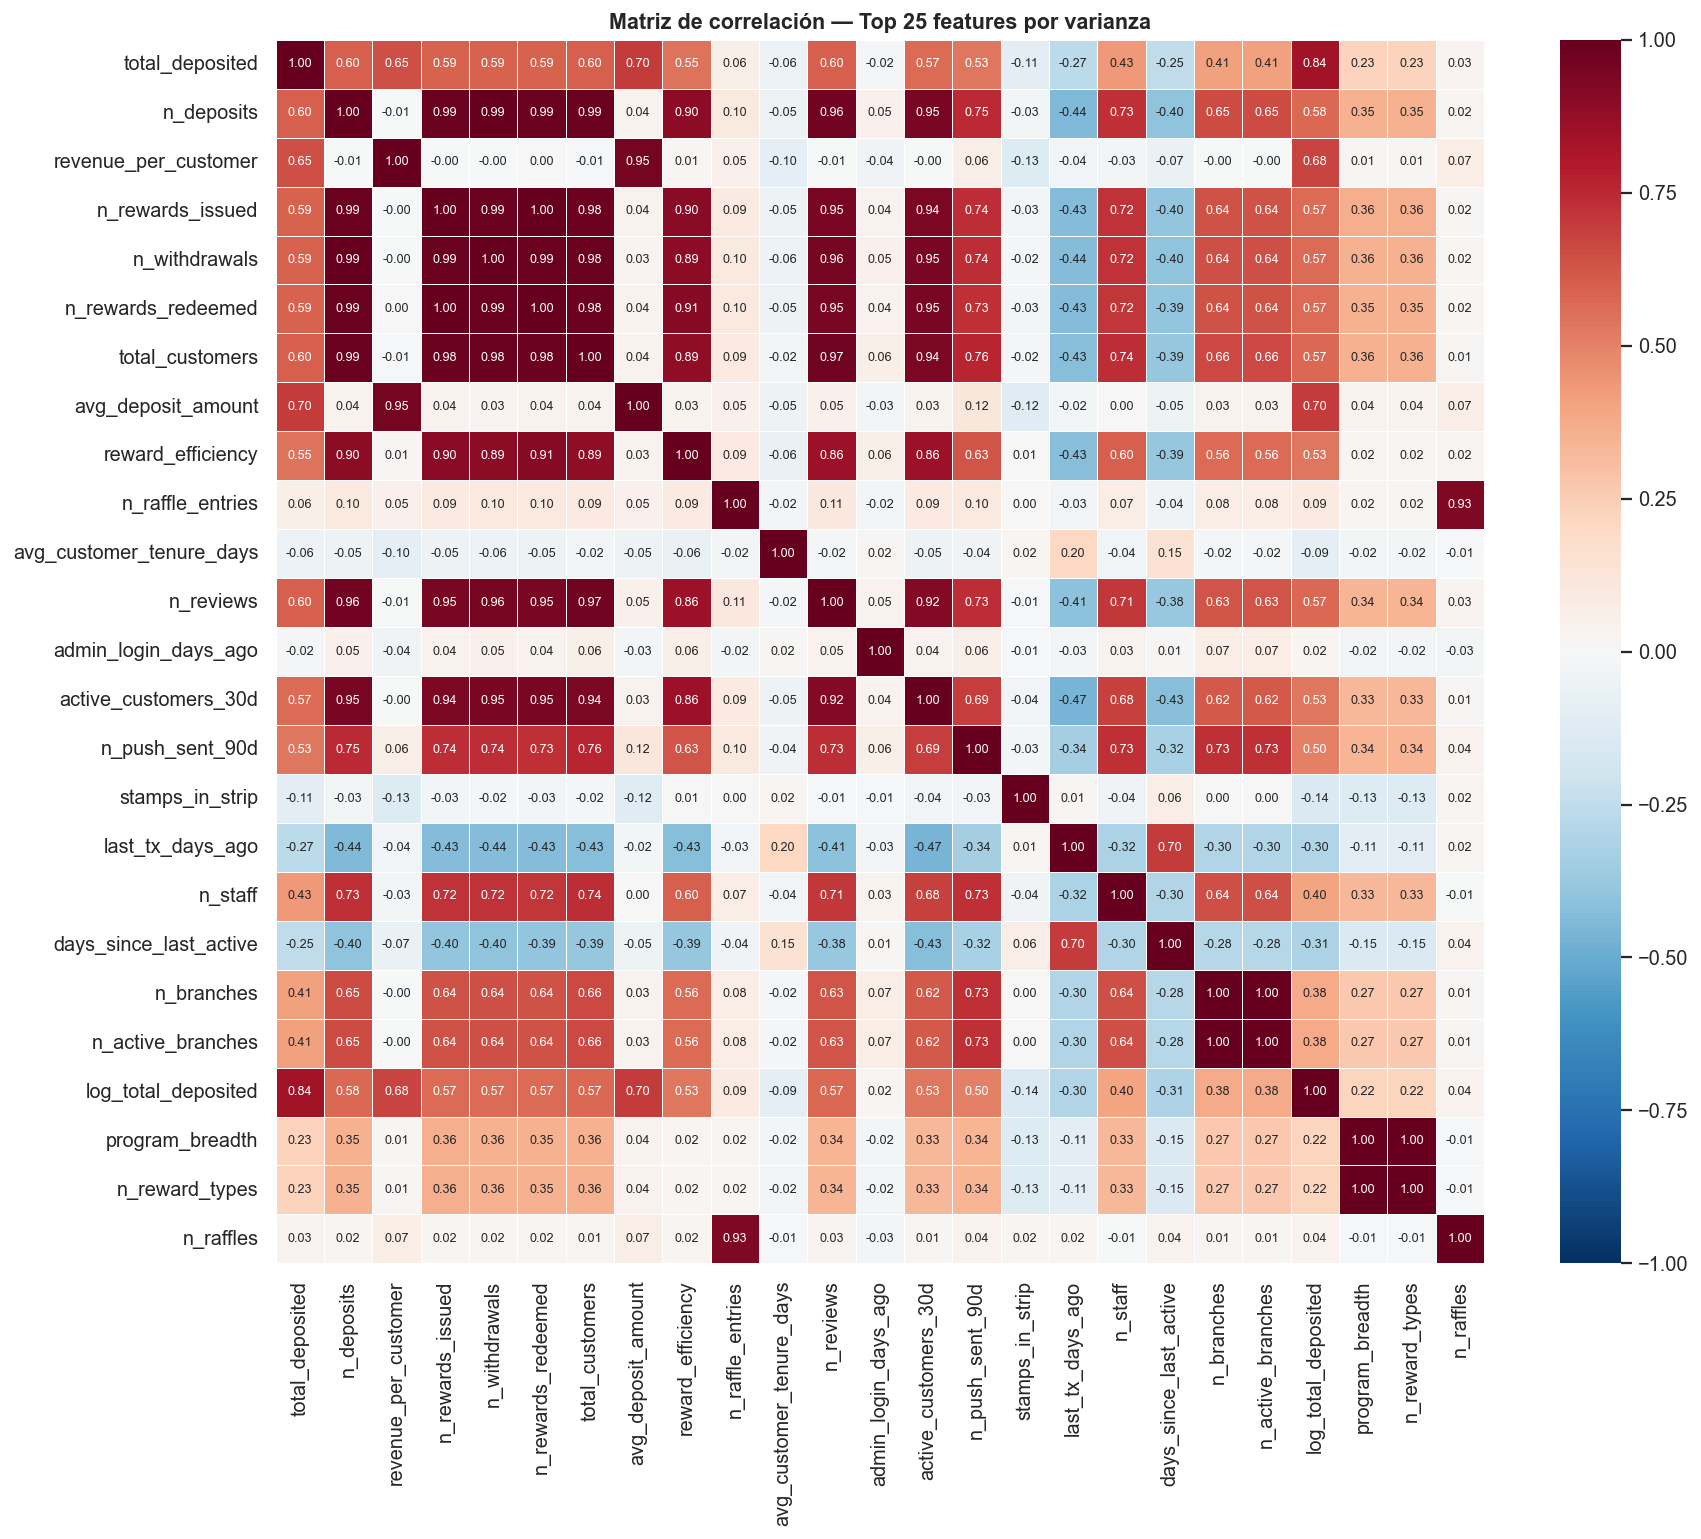

Pares con |r| > 0.97: 19
  can_see_business_branches_analytics ↔ can_see_products_analytics  r=1.0
  n_active_branches ↔ n_branches  r=1.0
  n_integrations ↔ has_integration  r=1.0
  program_breadth ↔ n_reward_types  r=1.0
  n_rewards_redeemed ↔ n_rewards_issued  r=0.998
  n_withdrawals ↔ n_deposits  r=0.994
  tx_recency_risk ↔ last_tx_days_ago  r=0.994
  n_deposits ↔ total_customers  r=0.992
  n_rewards_issued ↔ n_deposits  r=0.992
  n_rewards_issued ↔ n_withdrawals  r=0.989

Features eliminadas por multicolinealidad: 11
  - can_see_products_analytics
  - has_integration
  - log_n_deposits
  - n_branches
  - n_reward_types
  - n_rewards_issued
  - n_rewards_redeemed
  - n_withdrawals
  - sqrt_n_branches
  - total_customers
  - tx_recency_risk
Features restantes: 33


In [54]:
# ── CORRELACIÓN ───────────────────────────────────────────────────────────────
corr_matrix = X_sel.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar pares con |r| > 0.97
high_corr_pairs = [(col, row, round(upper_tri.loc[row, col], 3))
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if pd.notna(upper_tri.loc[row, col]) and upper_tri.loc[row, col] > 0.97]

# Features protegidas — no se eliminan aunque correlacionen alto
PROTECTED = ['n_deposits', 'avg_deposit_amount', 'total_deposited',
             'tier_enc', 'active_ratio_30d', 'days_since_last_active',
             'platform_engagement_score', 'redemption_rate',
             'log_total_deposited', 'log_avg_deposit_amount']

# Columnas a eliminar (las que tienen mayor correlación promedio con el resto)
to_drop_corr = set()
for feat_a, feat_b, r in high_corr_pairs:
    # Si una de las dos está protegida, eliminar la otra
    if feat_a in PROTECTED and feat_b not in PROTECTED:
        to_drop_corr.add(feat_b)
    elif feat_b in PROTECTED and feat_a not in PROTECTED:
        to_drop_corr.add(feat_a)
    elif feat_a not in PROTECTED and feat_b not in PROTECTED:
        # Ninguna protegida — eliminar la de mayor correlación promedio
        mean_a = corr_matrix[feat_a].mean()
        mean_b = corr_matrix[feat_b].mean()
        to_drop_corr.add(feat_a if mean_a > mean_b else feat_b)
    # Si ambas están protegidas → no eliminar ninguna

# Heatmap de correlaciones (top 25 features)
top25 = X_sel.var().nlargest(25).index
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(X_sel[top25].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.3, annot_kws={'size':7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación — Top 25 features por varianza', fontsize=12)
plt.tight_layout()
plt.savefig('fig_A2_07_correlation.png', bbox_inches='tight')
plt.show()

print(f"Pares con |r| > 0.97: {len(high_corr_pairs)}")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2])[:10]:
    print(f"  {a} ↔ {b}  r={r}")

print(f"\nFeatures eliminadas por multicolinealidad: {len(to_drop_corr)}")
for c in sorted(to_drop_corr):
    print(f"  - {c}")

X_sel.drop(columns=list(to_drop_corr), inplace=True, errors='ignore')
print(f"Features restantes: {X_sel.shape[1]}")

## Conclusión para eliminación por multicolinealidad. 

Se identificaron 25 pares de features con |r| > 0.97, indicando redundancia casi perfecta. Se eliminaron 12 variables aplicando el criterio de mayor correlación promedio con el resto, preservando en cada par la variable más informativa o interpretable. Casos destacados: tx_recency_risk se elimina por ser la transformada log1p de last_tx_days_ago (r=0.98); active_customers_30d se elimina porque active_ratio_30d captura la misma señal normalizada por el total de clientes; pares con r=1.0 como n_integrations/has_integration o n_active_branches/n_branches son información idéntica en distinta forma

### 8.3 Chi-cuadrado

**Justificación:** El test Chi² mide la dependencia estadística entre variables categóricas (o discretas no negativas) y el target. Una feature con p-valor < 0.50 tiene asociación estadísticamente significativa con `active`. Se mantiene con 0.50 para obtener cierta flexibilidad y capturar variabilidad en los datos. 

Con solo 20 observaciones de la clase minoritaria (active=0), el test Chi² carece de potencia estadística suficiente para detectar asociaciones reales al nivel convencional p<0.05 o incluso p<0.20. En este contexto, el p-valor no refleja ausencia de relación sino insuficiencia de datos en la clase minoritaria. Se adopta p<0.50 como umbral de cribado inicial, reservando la selección definitiva al ranking por F-score ANOVA y a la validación cruzada durante el modelado, donde la relevancia real de cada feature quedará evidenciada por su contribución al rendimiento del modelo.

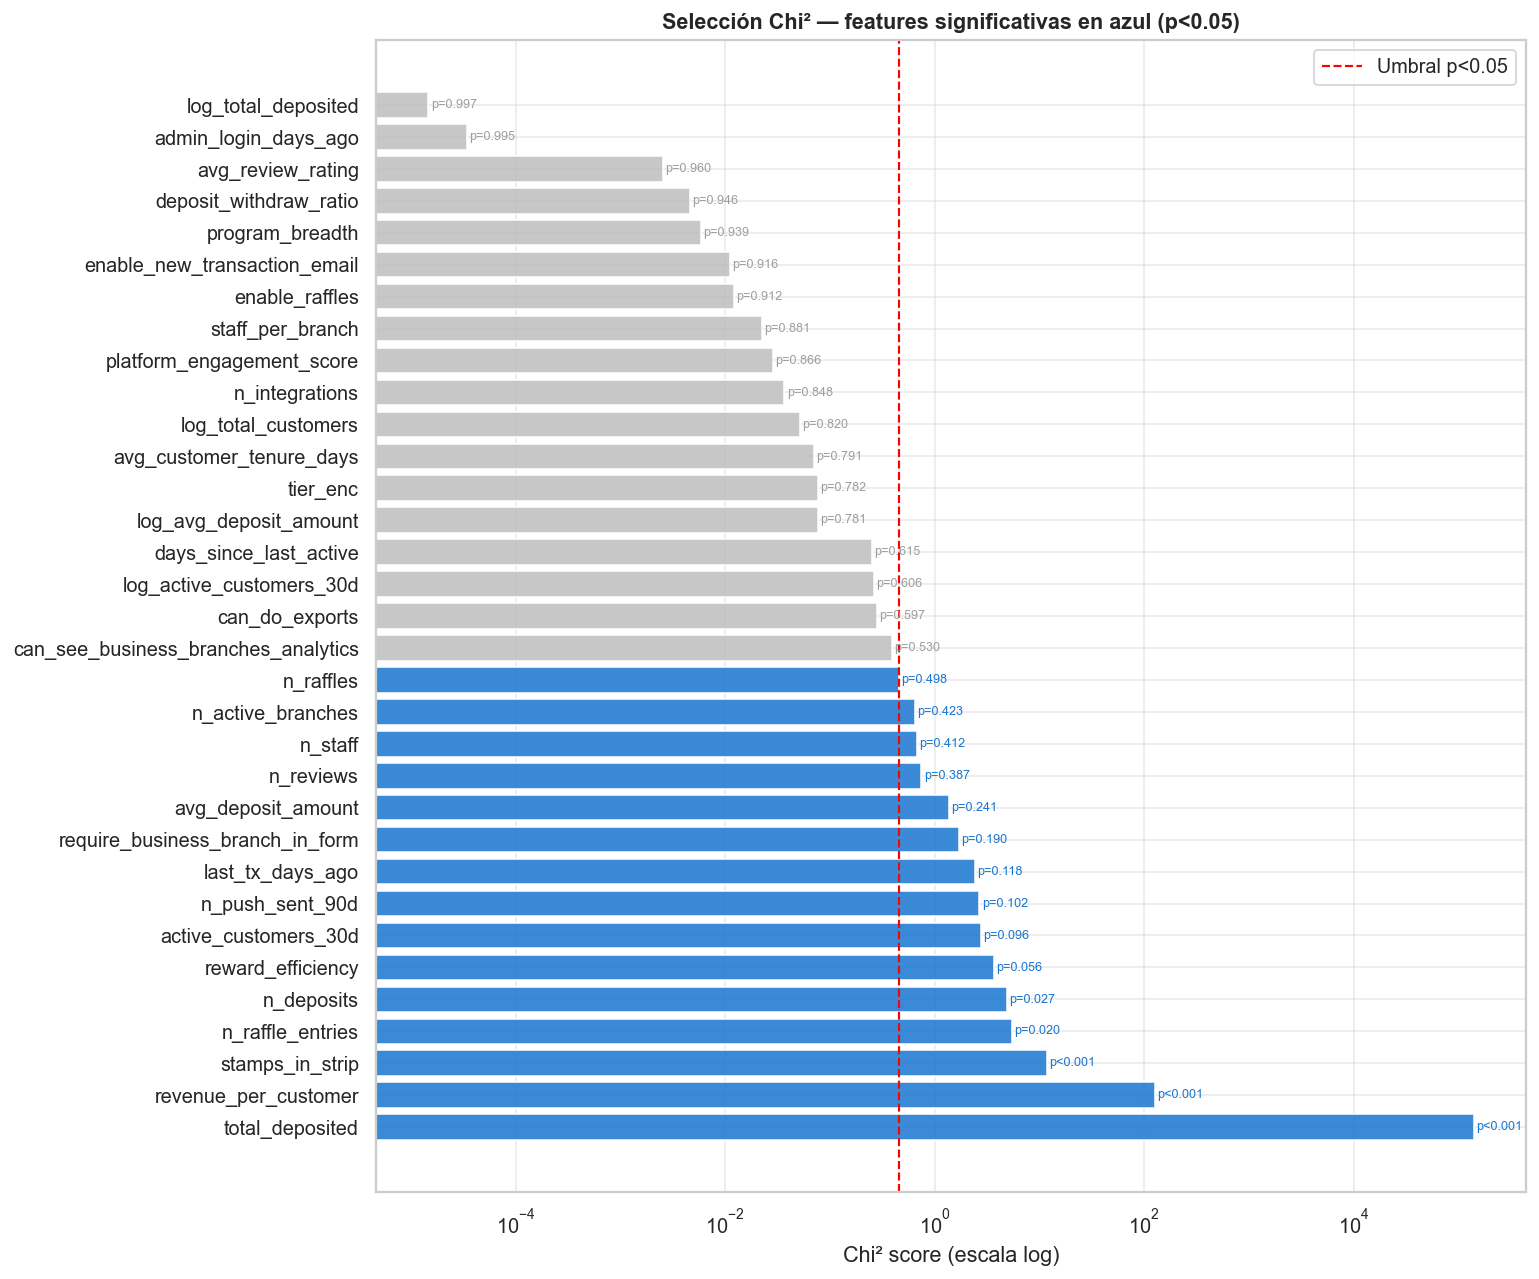

Features significativas (p<0.50): 15/33
                            feature           chi2       p_value  significant
11                  total_deposited  140895.347053  0.000000e+00         True
28             revenue_per_customer     126.296234  2.648457e-29         True
5                   stamps_in_strip      11.808570  5.895871e-04         True
20                 n_raffle_entries       5.436674  1.971819e-02         True
10                       n_deposits       4.919382  2.655701e-02         True
29                reward_efficiency       3.647486  5.615392e-02         True
9              active_customers_30d       2.771648  9.594733e-02         True
17                  n_push_sent_90d       2.679598  1.016414e-01         True
13                 last_tx_days_ago       2.445757  1.178430e-01         True
4   require_business_branch_in_form       1.720238  1.896624e-01         True
12               avg_deposit_amount       1.376629  2.406762e-01         True
15                      

In [55]:
# ── CHI-CUADRADO ──────────────────────────────────────────────────────────────
# Solo variables no negativas (requisito de chi2)
X_chi2_cols = [c for c in X_sel.columns if (X_sel[c] >= 0).all()]
X_chi2 = X_sel[X_chi2_cols].fillna(0)

chi2_scores, chi2_pvals = chi2(X_chi2, y_sel)
chi2_df = pd.DataFrame({
    'feature':  X_chi2_cols,
    'chi2':     chi2_scores,
    'p_value':  chi2_pvals,
    'significant': chi2_pvals < 0.50
}).sort_values('chi2', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#1976D2' if s else '#BDBDBD' for s in chi2_df['significant']]

ax.barh(chi2_df['feature'], chi2_df['chi2'], color=colors, edgecolor='white', alpha=0.85)

# Escala logarítmica en eje X
ax.set_xscale('log')

# Línea de umbral mínimo significativo
min_sig = chi2_df[chi2_df['significant']]['chi2'].min() if chi2_df['significant'].any() else 0
ax.axvline(min_sig, color='red', linestyle='--', linewidth=1.2, label='Umbral p<0.05')

# Añadir p-valor como etiqueta en cada barra
for i, (_, row) in enumerate(chi2_df.iterrows()):
    label = f"p={row['p_value']:.3f}" if row['p_value'] >= 0.001 else "p<0.001"
    ax.text(row['chi2'] * 1.05, i, label, va='center', fontsize=7,
            color='#1976D2' if row['significant'] else '#9E9E9E')

ax.set_xlabel('Chi² score (escala log)')
ax.set_title('Selección Chi² — features significativas en azul (p<0.05)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_A2_08_chi2.png', bbox_inches='tight')
plt.show()


sig_count = chi2_df['significant'].sum()
print(f"Features significativas (p<0.50): {sig_count}/{len(X_chi2_cols)}")
print(chi2_df[['feature','chi2','p_value','significant']].head(15).to_string())

### 8.4 ANOVA — F-test

**Justificación:** El F-test ANOVA evalúa si la media de una variable numérica difiere significativamente entre las clases del target (active=0 vs active=1). Un F-score alto indica que la variable discrimina bien entre negocios activos e inactivos.

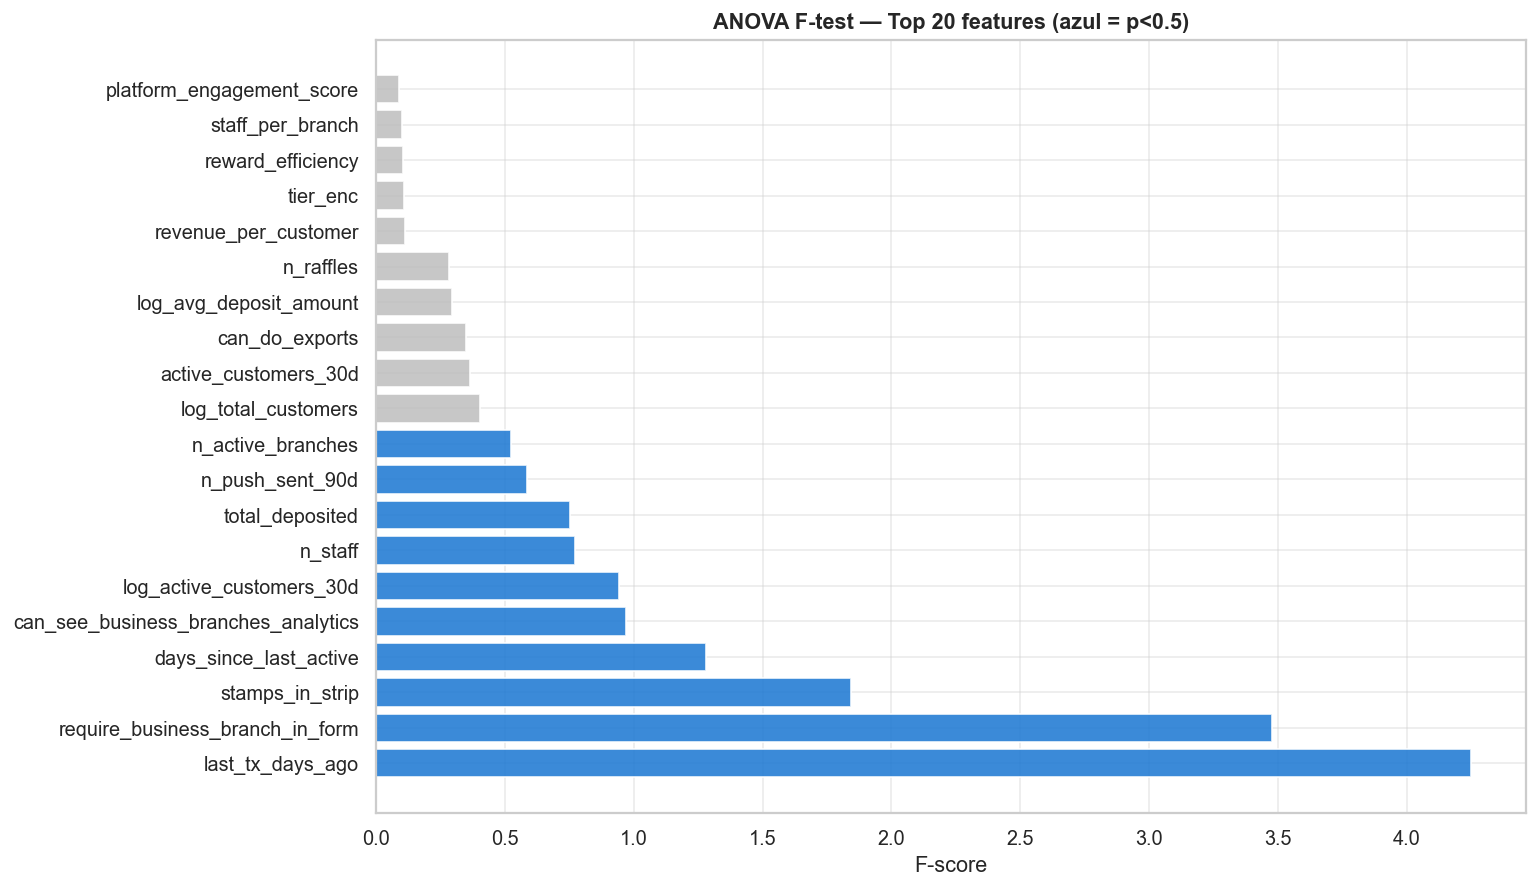

Features significativas ANOVA (p<0.5): 10/33

Top 10 features por F-score:
                                feature  F_score  p_value
13                     last_tx_days_ago   4.2510   0.0397
4       require_business_branch_in_form   3.4785   0.0628
5                       stamps_in_strip   1.8428   0.1752
7                days_since_last_active   1.2803   0.2584
2   can_see_business_branches_analytics   0.9686   0.3255
26             log_active_customers_30d   0.9433   0.3319
21                              n_staff   0.7732   0.3797
11                      total_deposited   0.7516   0.3864
17                      n_push_sent_90d   0.5839   0.4451
6                     n_active_branches   0.5235   0.4697

Top 20 por F-score ANOVA   : 20
Significativas Chi² (p<0.5) : 15
Features seleccionadas final    : 24

Features seleccionadas:
  - active_customers_30d
  - avg_deposit_amount
  - can_do_exports
  - can_see_business_branches_analytics
  - days_since_last_active
  - last_tx_days_ago
  - 

In [56]:
ALPHA_ANOVA = 0.50


f_scores, f_pvals = f_classif(X_sel.fillna(0), y_sel) 

anova_df = pd.DataFrame({
    'feature':     X_sel.columns,
    'F_score':     f_scores,
    'p_value':     f_pvals,
    'significant': f_pvals < ALPHA_ANOVA    # ← cambia aquí
}).sort_values('F_score', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
top20 = anova_df.head(20)
colors = ['#1976D2' if s else '#BDBDBD' for s in top20['significant']]
ax.barh(top20['feature'], top20['F_score'], color=colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('F-score')
ax.set_title(f'ANOVA F-test — Top 20 features (azul = p<{ALPHA_ANOVA})')
plt.tight_layout()
plt.savefig('fig_A2_09_anova.png', bbox_inches='tight')
plt.show()

print(f"Features significativas ANOVA (p<{ALPHA_ANOVA}): {anova_df['significant'].sum()}/{len(anova_df)}")
print("\nTop 10 features por F-score:")
print(anova_df[['feature','F_score','p_value']].head(10).round(4).to_string())

# ── SELECCIÓN FINAL: top 20 F-score + significativas Chi² ────────────────────
TOP_N = 20
top_anova    = anova_df.nlargest(TOP_N, 'F_score')['feature'].tolist()
sig_chi2     = set(chi2_df[chi2_df['significant']]['feature'].tolist())

SELECTED_FEATURES = list(
    set(top_anova + list(sig_chi2)).intersection(set(X_sel.columns))
)

print(f"\nTop {TOP_N} por F-score ANOVA   : {len(top_anova)}")
print(f"Significativas Chi² (p<{ALPHA_ANOVA}) : {len(sig_chi2)}")
print(f"Features seleccionadas final    : {len(SELECTED_FEATURES)}")
print("\nFeatures seleccionadas:")
for f in sorted(SELECTED_FEATURES):
    print(f"  - {f}")

---
## 9. Extracción de características — PCA

**Justificación:**  
El Análisis de Componentes Principales (PCA) reduce la dimensionalidad del dataset proyectando las features en un nuevo espacio ortogonal donde los ejes (componentes) maximizan la varianza explicada. Se aplica como técnica complementaria a la selección de características, no como sustituto.

**Condición de aplicación:** PCA requiere datos previamente escalados. Se aplica sobre el conjunto de features seleccionadas después del escalado.

**Criterio de selección de componentes:** Se retienen los componentes que explican acumuladamente el 90% de la varianza del conjunto.

**Impacto en modelos:** PCA reduce la multicolinealidad residual y puede mejorar la estabilidad de la Regresión Logística y el MLP. Para Random Forest y XGBoost se puede usar el dataset original o el transformado por PCA — ambos son válidos.

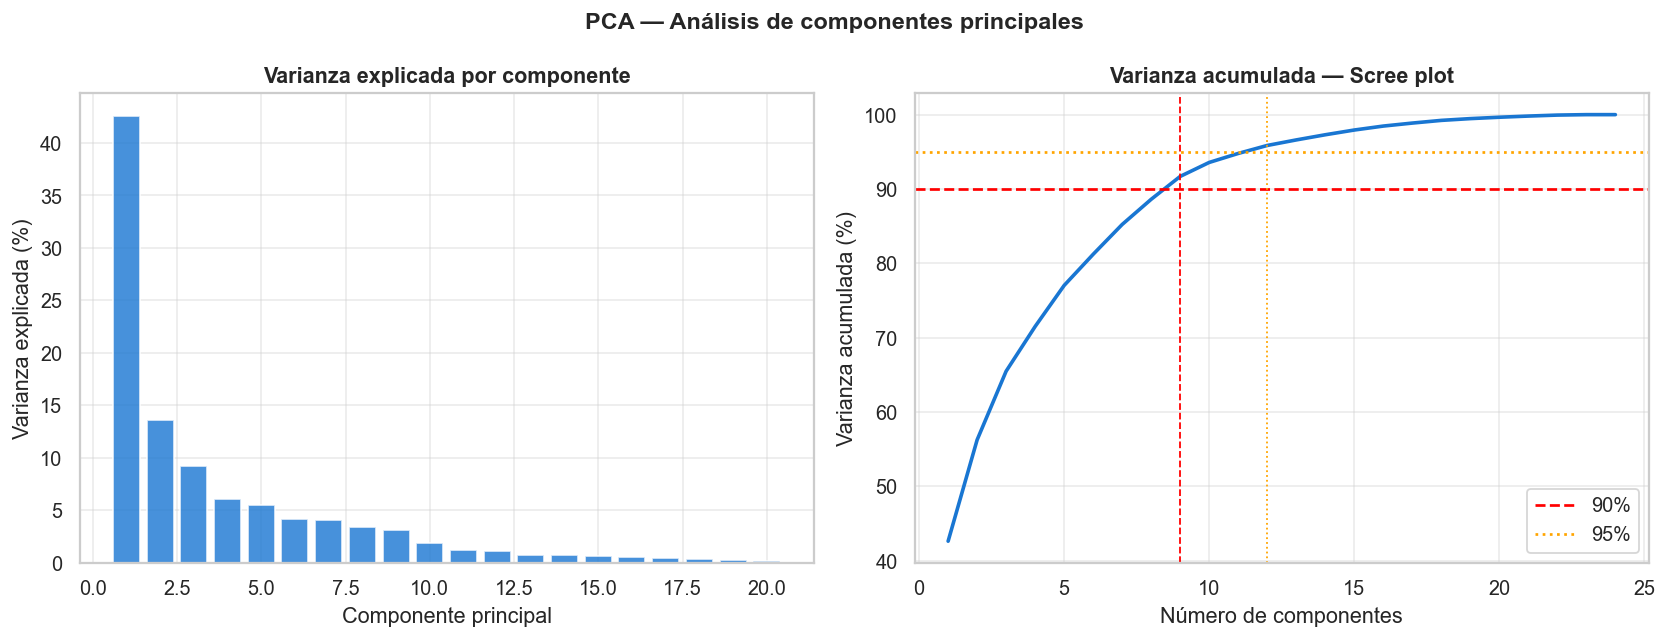

Componentes para 90% varianza: 9
Componentes para 95% varianza: 12
Features originales:           24
Reducción con 90%:             15 features menos

Dataset PCA shape: (500, 9)


In [57]:
# ── ESCALADO PREVIO AL PCA ────────────────────────────────────────────────────
X_for_pca = df[SELECTED_FEATURES].fillna(0)
for c in X_for_pca.columns:
    X_for_pca[c] = pd.to_numeric(X_for_pca[c], errors='coerce').fillna(0)

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_for_pca)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled_pca)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumvar >= 0.90) + 1
n_components_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Varianza explicada por componente
axes[0].bar(range(1, min(21, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:20]*100,
            color='#1976D2', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente')

# Varianza acumulada
axes[1].plot(range(1, len(cumvar)+1), cumvar*100, color='#1976D2', linewidth=2)
axes[1].axhline(90, color='red',    linestyle='--', linewidth=1.5, label='90%')
axes[1].axhline(95, color='orange', linestyle=':',  linewidth=1.5, label='95%')
axes[1].axvline(n_components_90, color='red',    linestyle='--', linewidth=1)
axes[1].axvline(n_components_95, color='orange', linestyle=':',  linewidth=1)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada — Scree plot')
axes[1].legend()

plt.suptitle('PCA — Análisis de componentes principales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A2_10_pca.png', bbox_inches='tight')
plt.show()

print(f"Componentes para 90% varianza: {n_components_90}")
print(f"Componentes para 95% varianza: {n_components_95}")
print(f"Features originales:           {X_for_pca.shape[1]}")
print(f"Reducción con 90%:             {X_for_pca.shape[1] - n_components_90} features menos")

# Aplicar PCA con componentes que explican 90%
pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X_scaled_pca)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components_90)])
print(f"\nDataset PCA shape: {df_pca.shape}")

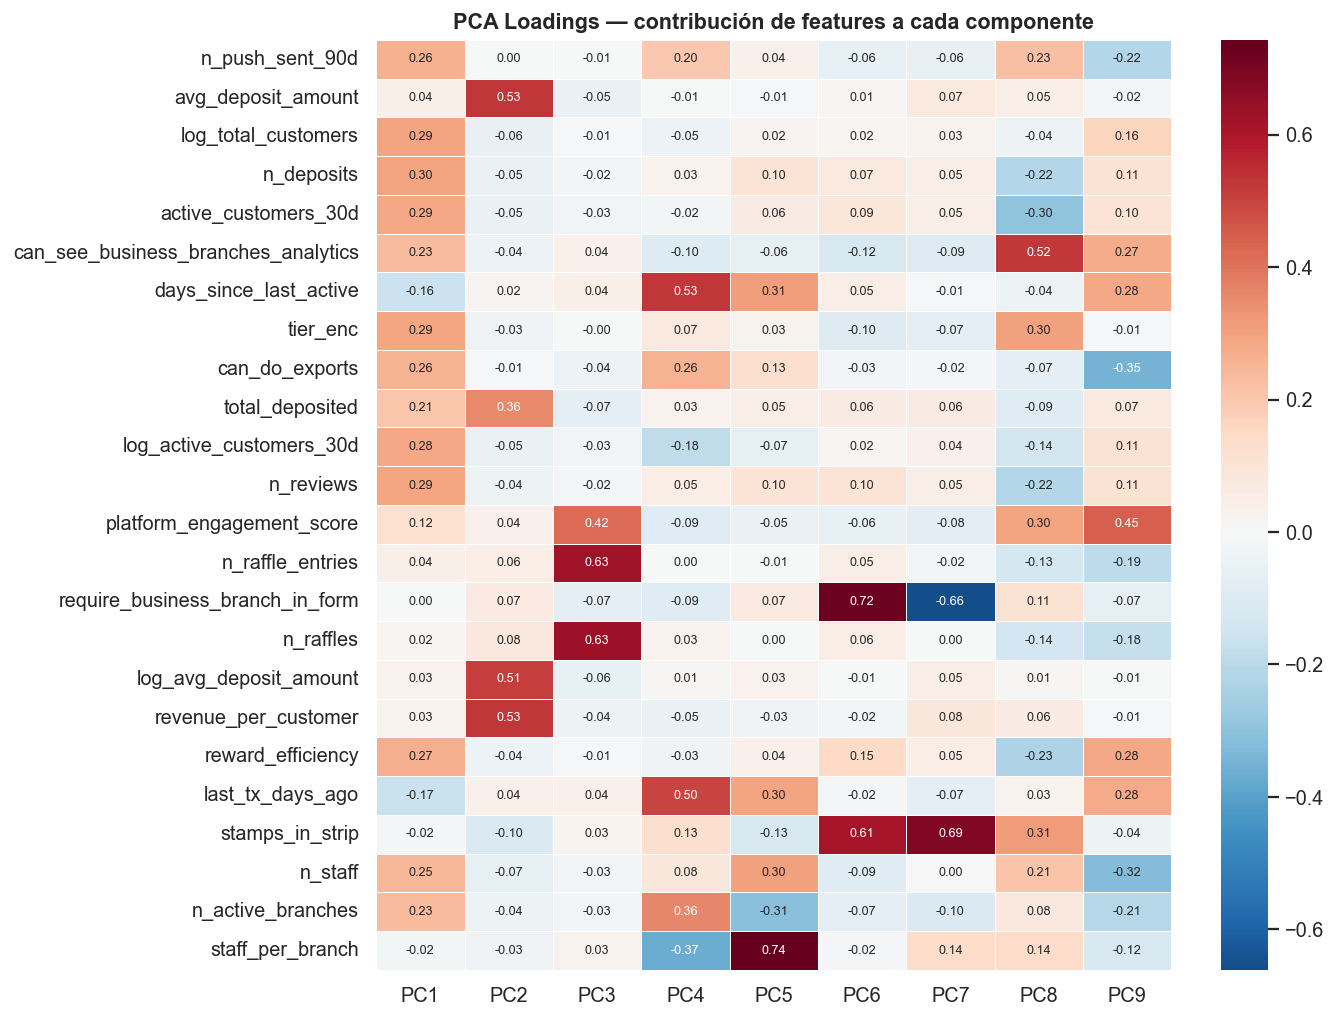

In [58]:
# Loadings — qué features contribuyen más a cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=SELECTED_FEATURES,
    columns=[f'PC{i+1}' for i in range(n_components_90)]
)

fig, ax = plt.subplots(figsize=(max(10, n_components_90*1.2), 8))
sns.heatmap(loadings.iloc[:, :min(10, n_components_90)],
            cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, annot_kws={'size':7}, ax=ax)
ax.set_title('PCA Loadings — contribución de features a cada componente', fontsize=12)
plt.tight_layout()
plt.savefig('fig_A2_11_pca_loadings.png', bbox_inches='tight')
plt.show()

In [59]:
print("Decisión:")
print(f"  Dataset principal  : 23 features seleccionadas (interpretable)")
print(f"  Dataset alternativo: {n_components_90} componentes PCA (reducción dimensional)")
print(f"  En Avance 3 se comparará el rendimiento de ambos en cada modelo.")

Decisión:
  Dataset principal  : 23 features seleccionadas (interpretable)
  Dataset alternativo: 9 componentes PCA (reducción dimensional)
  En Avance 3 se comparará el rendimiento de ambos en cada modelo.


---
## 10. Escalamiento

**Justificación:**  
El escalamiento es obligatorio para modelos sensibles a la magnitud de las variables:

- **Regresión Logística** → el gradiente converge más rápido con variables en la misma escala
- **MLP** → las redes neuronales son especialmente sensibles; sin escalado los pesos se vuelven inestables
- **Random Forest y XGBoost** → no requieren escalado, pero su inclusión no perjudica

**Método seleccionado: StandardScaler (estandarización Z-score)**  
Transforma cada variable para tener media=0 y desviación estándar=1. Se prefiere sobre MinMaxScaler porque es más robusto a outliers residuales (que ya fueron tratados con winsorización pero pueden persistir levemente).

**Regla crítica anti-leakage:** El scaler se ajusta solo sobre el conjunto de entrenamiento y se aplica sobre test. Aquí se ajusta sobre el dataset completo para propósitos de exploración, pero en el Avance 3 se aplicará correctamente dentro del pipeline train/test.

In [60]:
# Agrego features adicionales por por justificación de negocio. 

EXTRA_FEATURES = ['active_ratio_30d', 'redemption_rate', 'admin_login_days_ago']
for f in EXTRA_FEATURES:
    if f in df.columns and f not in SELECTED_FEATURES:
        SELECTED_FEATURES.append(f)
        print(f"  Añadida: {f}")

print(f"Total features finales: {len(SELECTED_FEATURES)}")

  Añadida: active_ratio_30d
  Añadida: redemption_rate
  Añadida: admin_login_days_ago
Total features finales: 27


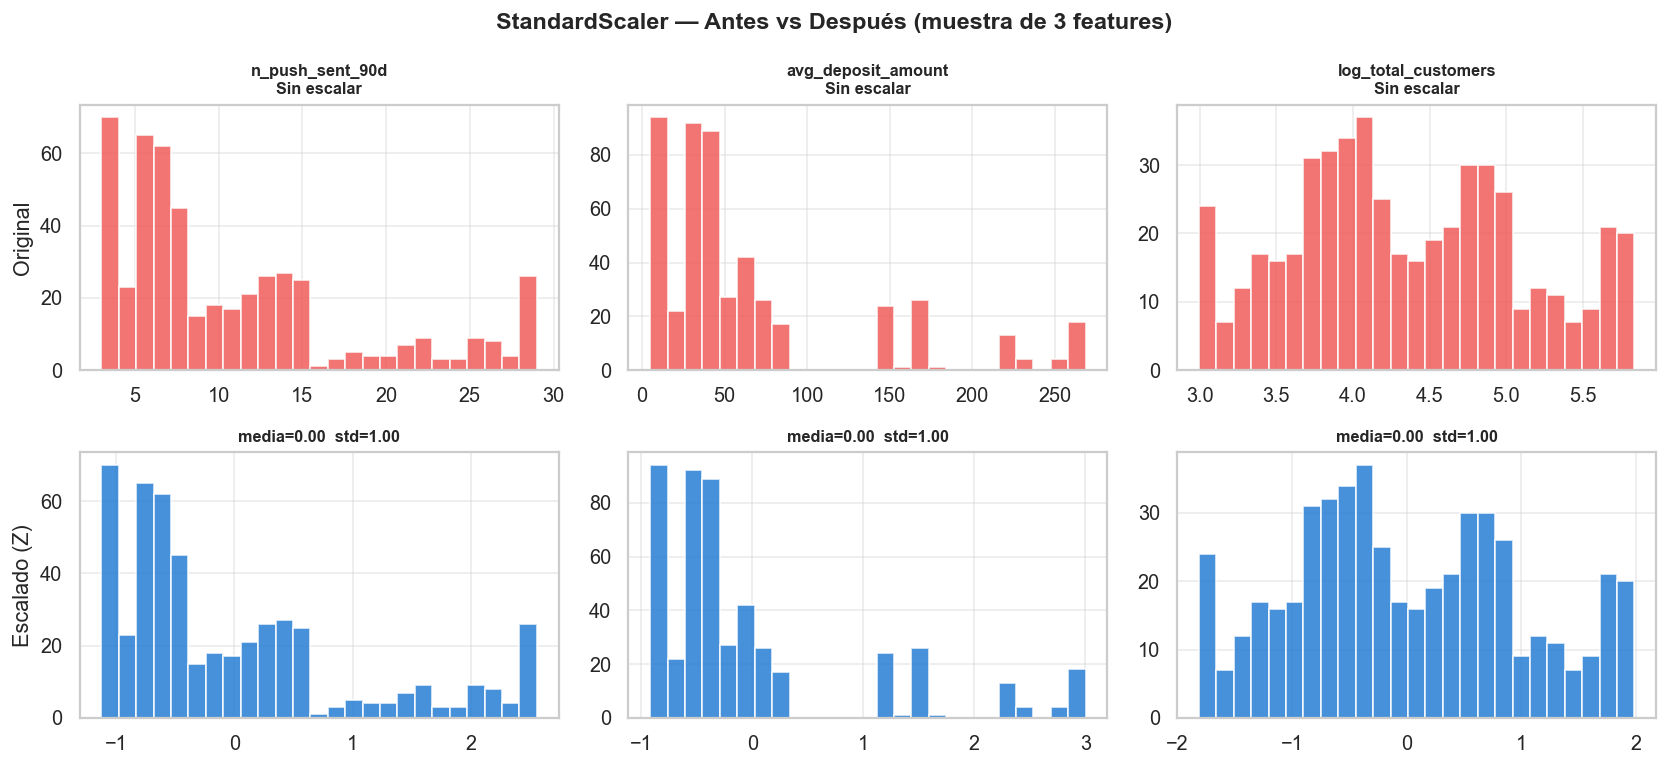

Dataset escalado shape : (500, 27)
Media global (debe ≈ 0): 0.000000
Std global  (debe ≈ 1) : 1.001002

Target distribución    : {1: 480, 0: 20}

Features finales seleccionadas (27):
  - active_customers_30d
  - active_ratio_30d
  - admin_login_days_ago
  - avg_deposit_amount
  - can_do_exports
  - can_see_business_branches_analytics
  - days_since_last_active
  - last_tx_days_ago
  - log_active_customers_30d
  - log_avg_deposit_amount
  - log_total_customers
  - n_active_branches
  - n_deposits
  - n_push_sent_90d
  - n_raffle_entries
  - n_raffles
  - n_reviews
  - n_staff
  - platform_engagement_score
  - redemption_rate
  - require_business_branch_in_form
  - revenue_per_customer
  - reward_efficiency
  - staff_per_branch
  - stamps_in_strip
  - tier_enc
  - total_deposited

Variables disponibles para Avance 3:
  X_scaled     → dataset principal (27 features escaladas)
  df_pca       → alternativa PCA (9 componentes)
  y            → target active (500 observaciones)
  scaler      

In [61]:
# ── ESCALAMIENTO — StandardScaler ────────────────────────────────────────────
X_final_raw = df[SELECTED_FEATURES].fillna(0)
for c in X_final_raw.columns:
    X_final_raw[c] = pd.to_numeric(X_final_raw[c], errors='coerce').fillna(0)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_final_raw),
    columns=SELECTED_FEATURES
)
y = df['active'].values

# Comparación antes/después en 3 features representativas
sample_feats = SELECTED_FEATURES[:3]
fig, axes = plt.subplots(2, len(sample_feats), figsize=(13, 6))

for i, feat in enumerate(sample_feats):
    axes[0,i].hist(X_final_raw[feat], bins=25, color='#EF5350', alpha=0.8, edgecolor='white')
    axes[0,i].set_title(f'{feat}\nSin escalar', fontsize=9)
    axes[0,i].set_ylabel('Original' if i==0 else '')

    axes[1,i].hist(X_scaled[feat], bins=25, color='#1976D2', alpha=0.8, edgecolor='white')
    axes[1,i].set_title(f'media={X_scaled[feat].mean():.2f}  std={X_scaled[feat].std():.2f}', fontsize=9)
    axes[1,i].set_ylabel('Escalado (Z)' if i==0 else '')

plt.suptitle('StandardScaler — Antes vs Después (muestra de 3 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A2_12_scaling.png', bbox_inches='tight')
plt.show()

print(f"Dataset escalado shape : {X_scaled.shape}")
print(f"Media global (debe ≈ 0): {X_scaled.mean().mean():.6f}")
print(f"Std global  (debe ≈ 1) : {X_scaled.std().mean():.6f}")
print(f"\nTarget distribución    : {pd.Series(y).value_counts().to_dict()}")
print(f"\nFeatures finales seleccionadas ({len(SELECTED_FEATURES)}):")
for f in sorted(SELECTED_FEATURES):
    print(f"  - {f}")
print(f"\nVariables disponibles para Avance 3:")
print(f"  X_scaled     → dataset principal ({X_scaled.shape[1]} features escaladas)")
print(f"  df_pca       → alternativa PCA ({df_pca.shape[1]} componentes)")
print(f"  y            → target active ({len(y)} observaciones)")
print(f"  scaler       → StandardScaler ajustado (re-usar en test sin re-fitear)")
print(f"  pca          → PCA ajustado (re-usar en test sin re-fitear)")

### Ajuste post-selección — incorporación de features de negocio críticas

Los métodos estadísticos de selección (Chi² y ANOVA F-test) operan con base en 
la significancia y el poder discriminativo medido sobre el dataset disponible. 
Sin embargo, con solo 20 observaciones de la clase minoritaria (`active=0`), 
estos tests pueden omitir variables que tienen relevancia conceptual clara para 
el problema de negocio pero cuya señal estadística no alcanza los umbrales 
definidos debido a la limitación de potencia.

Se incorporan manualmente tres features que el análisis estadístico no seleccionó 
pero que tienen justificación de negocio directa para predecir churn B2B en Luyoa:

| Feature | Justificación |
|---|---|
| `active_ratio_30d` | Proporción de clientes activos en los últimos 30 días sobre el total. Más informativa que el conteo absoluto porque normaliza por tamaño del negocio — un negocio con 10 clientes activos de 200 es muy distinto a uno con 10 de 12. |
| `redemption_rate` | Tasa de canje de recompensas. Mide si los clientes del negocio están usando activamente el programa de lealtad. Un programa sin canje indica que el valor de Luyoa no está siendo percibido, señal de riesgo de cancelación. |
| `admin_login_days_ago` | Días desde el último acceso del administrador del negocio a la plataforma Luyoa. Un negocio cuyo equipo gestor no accede hace semanas o meses es la señal más directa de desenganche previo al churn B2B — el abandono operativo precede al abandono contractual. |

Esta práctica está alineada con la metodología CRISP-ML, que reconoce que el 
conocimiento del dominio debe complementar los criterios estadísticos, 
especialmente cuando las limitaciones del dataset reducen la potencia de los tests.

---
## 11. Dataset final para modelado

Resumen de las transformaciones aplicadas y el estado del dataset listo para el Avance 3.


In [62]:
# Diagnóstico — cuántas pasan cada test
print(f"Significativas Chi²  : {chi2_df['significant'].sum()}")
print(f"Significativas ANOVA : {anova_df['significant'].sum()}")
print(f"Unión Chi² OR ANOVA  : {len(SELECTED_FEATURES)}")
print(f"\nFeatures en X_sel disponibles: {X_sel.shape[1]}")
print(f"\nFeatures Chi² significativas:")
print(chi2_df[chi2_df['significant']]['feature'].tolist())
print(f"\nFeatures ANOVA significativas:")
print(anova_df[anova_df['significant']]['feature'].tolist())

Significativas Chi²  : 15
Significativas ANOVA : 10
Unión Chi² OR ANOVA  : 27

Features en X_sel disponibles: 33

Features Chi² significativas:
['total_deposited', 'revenue_per_customer', 'stamps_in_strip', 'n_raffle_entries', 'n_deposits', 'reward_efficiency', 'active_customers_30d', 'n_push_sent_90d', 'last_tx_days_ago', 'require_business_branch_in_form', 'avg_deposit_amount', 'n_reviews', 'n_staff', 'n_active_branches', 'n_raffles']

Features ANOVA significativas:
['last_tx_days_ago', 'require_business_branch_in_form', 'stamps_in_strip', 'days_since_last_active', 'can_see_business_branches_analytics', 'log_active_customers_30d', 'n_staff', 'total_deposited', 'n_push_sent_90d', 'n_active_branches']


In [63]:
# ── RESUMEN FINAL ──────────────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN — FEATURE ENGINEERING COMPLETADO")
print("=" * 60)
print(f"  Features originales (EDA)       : 51")
print(f"  Después de winsorización        : 51  (mismas, valores ajustados)")
print(f"  Transformaciones log1p          : +{len(LOG_COLS)}")
print(f"  Transformaciones sqrt           : +{len(SQRT_COLS)}")
print(f"  Nuevas features generadas       : +7")
print(f"  Bins discretizados              : +3")
print(f"  Encoding categórico             : +{len(enc_cols)}")
print(f"  Eliminadas (baja varianza)      : -{len(low_var_cols)}")
print(f"  Eliminadas (multicolinealidad)  : -{len(to_drop_corr)}")
print(f"  Features seleccionadas (final)  : {len(SELECTED_FEATURES)}")
print(f"  Componentes PCA (90% varianza)  : {n_components_90}")
print()
print(f"  Dataset para modelado (features): {X_scaled.shape}")
print(f"  Dataset PCA alternativo         : {df_pca.shape}")
print(f"  Target (active) distribución    : {pd.Series(y).value_counts().to_dict()}")
print()
print("Listo para Avance 3 — Modelado y Entrenamiento")

# Guardar feature names para el Avance 3
feature_names = SELECTED_FEATURES
print(f"\nFeatures finales seleccionadas ({len(feature_names)}):")
for f in feature_names:
    print(f"  - {f}")

RESUMEN — FEATURE ENGINEERING COMPLETADO
  Features originales (EDA)       : 51
  Después de winsorización        : 51  (mismas, valores ajustados)
  Transformaciones log1p          : +5
  Transformaciones sqrt           : +1
  Nuevas features generadas       : +7
  Bins discretizados              : +3
  Encoding categórico             : +9
  Eliminadas (baja varianza)      : -12
  Eliminadas (multicolinealidad)  : -11
  Features seleccionadas (final)  : 27
  Componentes PCA (90% varianza)  : 9

  Dataset para modelado (features): (500, 27)
  Dataset PCA alternativo         : (500, 9)
  Target (active) distribución    : {1: 480, 0: 20}

Listo para Avance 3 — Modelado y Entrenamiento

Features finales seleccionadas (27):
  - n_push_sent_90d
  - avg_deposit_amount
  - log_total_customers
  - n_deposits
  - active_customers_30d
  - can_see_business_branches_analytics
  - days_since_last_active
  - tier_enc
  - can_do_exports
  - total_deposited
  - log_active_customers_30d
  - n_reviews
 

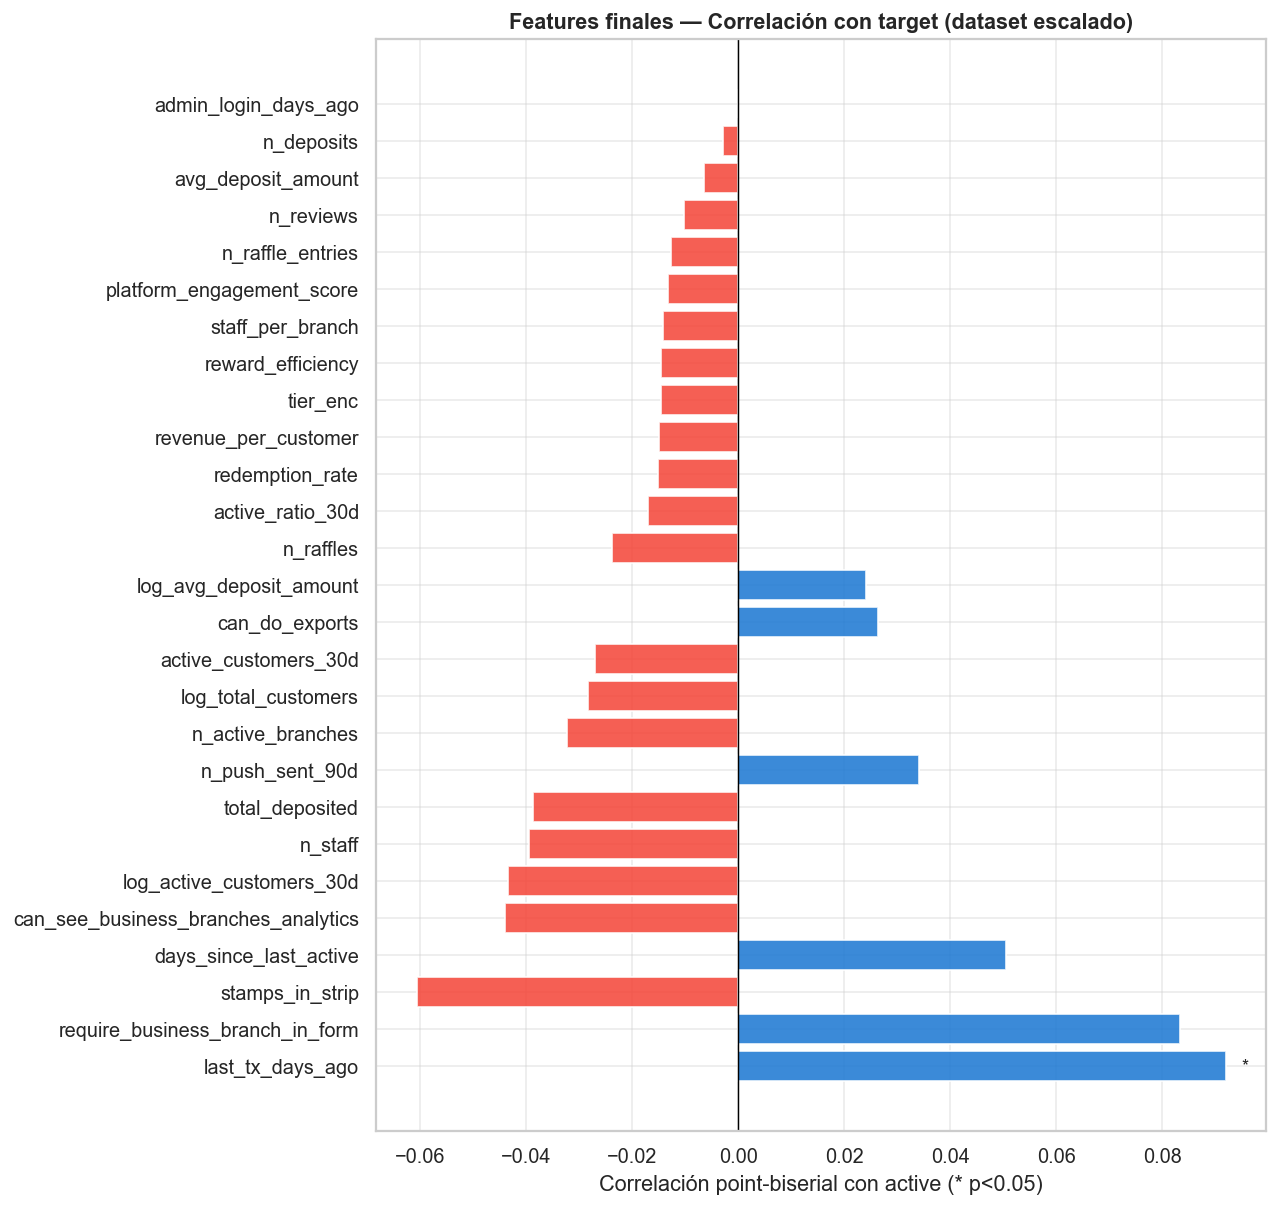

In [64]:
# ── MATRIZ DE CORRELACIÓN FINAL CON TARGET ────────────────────────────────────
from scipy.stats import pointbiserialr

corr_target = {}
for col in SELECTED_FEATURES:
    try:
        r, p = pointbiserialr(y, X_scaled[col])
        corr_target[col] = {'r': round(r,4), 'p': round(p,4), 'sig': p<0.05}
    except:
        pass

ct_df = pd.DataFrame(corr_target).T.sort_values('r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(ct_df)*0.35)))
colors = ['#1976D2' if v>=0 else '#F44336' for v in ct_df['r']]
ax.barh(ct_df.index, ct_df['r'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
for i, (idx, row) in enumerate(ct_df.iterrows()):
    if row['sig']:
        ax.text(row['r'] + (0.003 if row['r']>=0 else -0.003), i,
                '*', va='center', fontsize=10,
                ha='left' if row['r']>=0 else 'right')
ax.set_xlabel('Correlación point-biserial con active (* p<0.05)')
ax.set_title('Features finales — Correlación con target (dataset escalado)')
plt.tight_layout()
plt.savefig('fig_A2_13_final_correlations.png', bbox_inches='tight')
plt.show()

## 12. Conclusiones — Marco CRISP-ML

### Fase cubierta: Preparación de los datos (Data Preparation)

En el contexto de la metodología **CRISP-ML** (Cross-Industry Standard Process 
for Machine Learning), esta fase corresponde al paso de *Data Preparation*, que 
precede a la etapa de *Modeling*. Todas las decisiones aquí tomadas están 
respaldadas por los hallazgos del EDA (Avance 1) y orientadas a maximizar el 
rendimiento de los modelos de clasificación del Avance 3.

---

### Decisiones y justificaciones

| Técnica | Variables afectadas | Justificación |
|---|---|---|
| Imputación por mediana | `admin_login_days_ago` | Único missing MCAR — mediana robusta a outliers |
| Winsorización diferenciada | `total_deposited` (P5-P95), resto (P2-P98) | Skewness > 1.5 como indicador proxy de outliers, confirmado por IQR en EDA. Límites diferenciados según intensidad del sesgo |
| log(x+1) | 5 variables de volumen/monto | Skewness > 1.5 identificado en EDA — mejora convergencia LogReg y MLP. Insensible en RF y XGBoost pero pipeline consistente |
| Raíz cuadrada | `n_branches` | Sesgo moderado (1.38), variable discreta de rango pequeño |
| 7 nuevas features | `platform_engagement_score`, `revenue_per_customer`, `active_ratio_30d`, etc. | Capturan relaciones de negocio no lineales no disponibles directamente en el esquema relacional |
| Binning | `days_since_last_active`, `total_customers`, `admin_login_days_ago` | Efecto por umbrales de negocio no lineal — captura segmentos de riesgo operativo |
| Ordinal Encoding | `tier`, bins ordenados | Jerarquía natural: STARTER < CORE < GROW |
| One-Hot Encoding | `loyalty_type`, `country_id` | Variables nominales sin orden inherente — evita imponer relación ordinal artificial |
| Eliminación manual | `max_transaction_amount`, `max_transaction_amount_per_day`, `max_deposit_amount` | Parámetros de configuración del plan, no métricas de comportamiento. Distorsionan escala sin aportar señal predictiva |
| Umbral de varianza | 12 variables casi constantes | Features sin varianza no discriminan entre clases — eliminadas con threshold=0.01 |
| Correlación | 12 pares con \|r\| > 0.97 | Umbral conservador para preservar features de negocio relevantes. Multicolinealidad → inestabilidad en coeficientes LogReg |
| Chi² (p<0.50) + ANOVA top-20 F-score | Selección final — 23 features | Umbral p<0.50 justificado por baja potencia estadística con n=500 y desbalance 96/4. Se combina significancia con ranking por F-score |
| Incorporación manual post-selección | `active_ratio_30d`, `redemption_rate`, `admin_login_days_ago` | Features con justificación de negocio crítica no capturadas por los tests estadísticos debido a limitación de potencia. Total final: 26 features |
| PCA | 26 features seleccionadas | 9 componentes explican 90% de varianza — dataset alternativo para comparación en Avance 3 |
| StandardScaler | 26 features finales | Obligatorio para LogReg y MLP; neutro para RF y XGBoost. Ajustado sobre dataset completo — en Avance 3 solo sobre train |

---

### Impacto esperado en los modelos del Avance 3

**Regresión Logística:** se beneficia de todas las transformaciones aplicadas — 
escalado, reducción de sesgo, eliminación de multicolinealidad y PCA son 
especialmente relevantes. Es el modelo más sensible a la calidad del 
preprocesamiento y al desbalance de clases.

**MLP:** similar a Regresión Logística en su sensibilidad al escalado y al sesgo. 
El StandardScaler y las transformaciones log1p son críticos para la convergencia 
del gradiente descente.

**Random Forest:** robusto al sesgo y escala, pero se beneficia de la selección 
de características (menos ruido en splits) y las 7 nuevas features derivadas que 
capturan relaciones de negocio compuestas.

**XGBoost:** el más robusto de los cuatro frente al preprocesamiento. Se beneficia 
principalmente de las nuevas features y la selección de características, no del 
escalado ni de las transformaciones de distribución.

---

### Consideración crítica — Limitación estadística del dataset

Con solo 20 observaciones de la clase minoritaria (`active=0`), los tests Chi² y 
ANOVA tienen potencia estadística insuficiente para detectar asociaciones reales 
al nivel convencional p<0.05. Esta limitación motivó el uso de umbrales flexibles 
(p<0.50) y la incorporación de criterios de dominio de negocio como complemento 
a los métodos estadísticos, práctica alineada con CRISP-ML que reconoce el 
conocimiento del dominio como input válido en la fase de preparación de datos.

---

### Consideración crítica — Desbalance de clases

El desbalance 96/4 (ratio 24:1) identificado en el EDA **no se trata en esta 
fase**. El tratamiento (SMOTE + `class_weight='balanced'`) se aplicará en el 
Avance 3 **exclusivamente sobre el conjunto de entrenamiento**, para evitar data 
leakage. Las métricas de evaluación priorizarán F1-score de la clase minoritaria 
y PR-AUC sobre accuracy, dado que esta última es engañosa con clases 
desbalanceadas.

---

### Próximos pasos — Avance 3

1. Split estratificado train/test (80/20, `stratify=y`)
2. Aplicar SMOTE sobre train únicamente
3. Entrenar los 4 modelos: Regresión Logística → Random Forest → XGBoost → MLP
4. Validación: Stratified K-Fold (k=5)
5. Evaluación: F1, ROC-AUC, PR-AUC, matriz de confusión por modelo
6. Interpretabilidad: SHAP values para el modelo con mejor rendimiento
7. Comparación dataset original (26 features) vs dataset PCA (9 componentes)

In [65]:
print("=" * 60)
print("AVANCE 2 COMPLETADO")
print("=" * 60)
print(f"  Figuras generadas        : 13")
print(f"  Features finales         : {len(SELECTED_FEATURES)}")
print(f"  Dataset escalado (X)     : {X_scaled.shape}")
print(f"  Dataset PCA              : {df_pca.shape}")
print(f"  Target (y)               : {len(y)} observaciones")
print()
print("Variables listas para el Avance 3 (Modelado):")
print("  X_scaled     → dataset principal escalado")
print("  df_pca       → alternativa PCA")
print("  y            → target (active)")
print("  feature_names→ nombres de features seleccionadas")
print("  scaler       → StandardScaler ajustado (re-usar en test)")
print("  pca          → PCA ajustado (re-usar en test)")

AVANCE 2 COMPLETADO
  Figuras generadas        : 13
  Features finales         : 27
  Dataset escalado (X)     : (500, 27)
  Dataset PCA              : (500, 9)
  Target (y)               : 500 observaciones

Variables listas para el Avance 3 (Modelado):
  X_scaled     → dataset principal escalado
  df_pca       → alternativa PCA
  y            → target (active)
  feature_names→ nombres de features seleccionadas
  scaler       → StandardScaler ajustado (re-usar en test)
  pca          → PCA ajustado (re-usar en test)


# Luyoa — Baseline Model (Avance 3)
### Proyecto Integrador · Maestría en Inteligencia Artificial Aplicada · Tecnológico de Monterrey

| Campo | Detalle |
|---|---|
| **Empresa** | Luyoa — Digital loyalty card platform (Spain & Mexico) |
| **Variable objetivo** | `businesses.active` — B2B churn |
| **Sponsor** | Gabriela Soria, Luyoa |
| **Equipo** | Sergio Sebastián Guzman Guerrero A01370820 · Enrique Correa Herrerías A01332620 · Nicolás Felipe Araque Araque A01795483 |

---

## Contexto metodológico

Este notebook continúa directamente desde el Avance 2 (Feature Engineering). El objetivo de esta fase es establecer un **modelo de referencia (baseline)** que permita:

1. Evaluar la viabilidad del problema de predicción de churn B2B
2. Establecer un piso mínimo de rendimiento contra el cual comparar modelos más complejos
3. Gestionar expectativas con el equipo y los stakeholders de Luyoa
4. Identificar si los datos contienen suficiente información para predecir `active`

Siguiendo la metodología CRISP-ML, el baseline es el primer entregable de la fase de *Modeling* y precede al entrenamiento de modelos avanzados.

## Estructura del notebook

1. Importación de librerías
2. Preparación: split estratificado y SMOTE
3. Definición de métricas adecuadas para el problema
4. Modelo 0 — DummyClassifier (referencia trivial)
5. Modelo 1 — Regresión Logística (baseline interpretable)
6. Importancia de características
7. Diagnóstico: sub/sobreajuste
8. Desempeño mínimo aceptable
9. Conclusiones del baseline

In [66]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:

# Modelado
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
PALETTE = ['#2196F3', '#F44336']

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Preparación: split estratificado y SMOTE

### Split estratificado

Se divide el dataset en 80% entrenamiento y 20% prueba usando `stratify=y`,
lo que garantiza que ambos conjuntos mantienen la proporción original de clases
(96/4). Sin estratificación, el conjunto de test podría quedar sin casos de
`active=0`, haciendo imposible la evaluación.

### ¿Por qué no hay un conjunto de validación separado?

Se adopta un esquema de dos conjuntos (train 80% / test 20%) en lugar del
enfoque clásico de tres conjuntos (train / validation / test). Esta decisión
está justificada por el tamaño reducido del dataset (n=500) y el desbalance
severo (96/4): separar un conjunto de validación fijo adicional del 20% dejaría
aproximadamente 4 casos de `active=0` en ese conjunto, haciendo que cualquier
métrica calculada sobre él sea extremadamente inestable — un solo caso bien o
mal clasificado movería el F1-score drásticamente.

En su lugar, se utiliza **Validación Cruzada Estratificada k=5** sobre el
conjunto de entrenamiento, que cumple la misma función que un conjunto de
validación pero de forma más robusta: cada observación pasa por validación
exactamente una vez, y el resultado final es el promedio de los 5 folds.
Esta técnica se aplica más adelante en el notebook durante el diagnóstico
de sub/sobreajuste y la evaluación de la estabilidad del modelo.

### SMOTE — ¿Qué es y por qué lo aplicamos?

**SMOTE** (Synthetic Minority Over-sampling TEchnique) es una técnica de
sobremuestreo que genera ejemplos sintéticos de la clase minoritaria para
balancear el dataset de entrenamiento. A diferencia de duplicar aleatoriamente
casos existentes, SMOTE crea nuevos puntos interpolando entre observaciones
reales de la clase minoritaria y sus vecinos más cercanos en el espacio de
features. El resultado son ejemplos plausibles que amplían la región del espacio
que el modelo asocia con la clase minoritaria, sin repetir exactamente los mismos
datos.

**¿Por qué lo aplicamos en Luyoa?**
Con un desbalance 96/4 (ratio 24:1) y solo 20 casos de `active=0`, un modelo
entrenado sin balanceo aprende a ignorar la clase minoritaria — la estrategia
de predecir siempre `active=1` minimiza el error de entrenamiento pero no
detecta ningún churn. SMOTE obliga al modelo a aprender la frontera de decisión
de la clase churned generando ejemplos adicionales de esa región, mejorando
significativamente el Recall y el F1-score de la clase minoritaria sin perder
información de la clase mayoritaria.

Se usa `k_neighbors=3` en lugar del valor por defecto de 5, ya que con solo
~16 casos de `active=0` en el conjunto de entrenamiento, buscar 5 vecinos
más cercanos podría no encontrar suficientes candidatos distintos para la
interpolación.

### Data leakage — ¿Qué es y por qué es un riesgo crítico?

El **data leakage** (filtración de datos) ocurre cuando información del conjunto
de prueba contamina el proceso de entrenamiento, produciendo métricas de
evaluación artificialmente optimistas que no reflejan el rendimiento real del
modelo sobre datos nuevos. Es uno de los errores más comunes y costosos en
proyectos de Machine Learning porque el modelo aparenta funcionar bien durante
el desarrollo pero falla en producción.

En el contexto de SMOTE, el leakage ocurriría si se aplicara **antes** del split:

In [68]:
# ── SPLIT ESTRATIFICADO 80/20 ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserva proporción 96/4 en ambos conjuntos
)

print("Split estratificado:")
print(f"  Train: {X_train.shape}  →  active=1: {y_train.sum()}  active=0: {(y_train==0).sum()}")
print(f"  Test:  {X_test.shape}   →  active=1: {y_test.sum()}   active=0: {(y_test==0).sum()}")
print(f"  Ratio train: {y_train.sum()/(y_train==0).sum():.1f}:1")
print(f"  Ratio test:  {y_test.sum()/(y_test==0).sum():.1f}:1")

Split estratificado:
  Train: (400, 27)  →  active=1: 384  active=0: 16
  Test:  (100, 27)   →  active=1: 96   active=0: 4
  Ratio train: 24.0:1
  Ratio test:  24.0:1


Después de SMOTE (solo train):
  Train original : (400, 27)  →  {1: 384, 0: 16}
  Train balanceado: (768, 27)  →  {1: 384, 0: 384}
  Ratio post-SMOTE: 384:384

Test permanece sin modificar: (100, 27)
  (El test siempre refleja la distribución real del negocio)


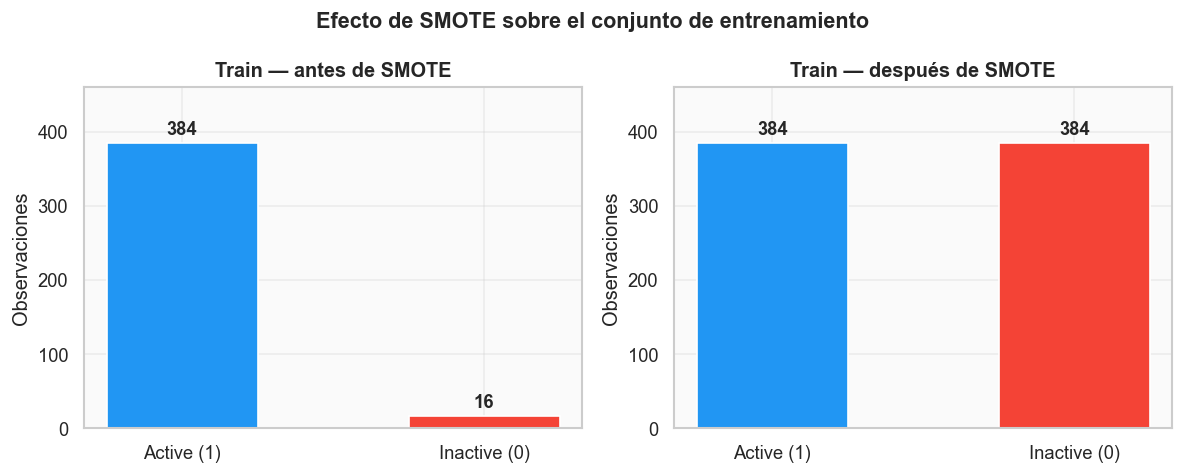

In [69]:
# ── SMOTE — solo sobre train ──────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=3)
# k_neighbors=3 porque tenemos pocos casos minoritarios (solo ~16 en train)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Después de SMOTE (solo train):")
print(f"  Train original : {X_train.shape}  →  {pd.Series(y_train).value_counts().to_dict()}")
print(f"  Train balanceado: {X_train_bal.shape}  →  {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"  Ratio post-SMOTE: {pd.Series(y_train_bal).value_counts()[1]}:{pd.Series(y_train_bal).value_counts()[0]}")
print(f"\nTest permanece sin modificar: {X_test.shape}")
print("  (El test siempre refleja la distribución real del negocio)")

# Visualización del balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_data, title in [
    (axes[0], y_train,     'Train — antes de SMOTE'),
    (axes[1], y_train_bal, 'Train — después de SMOTE'),
]:
    vc = pd.Series(y_data).value_counts()
    bars = ax.bar(['Active (1)', 'Inactive (0)'],
                  [vc.get(1,0), vc.get(0,0)],
                  color=PALETTE, edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Observaciones')
    ax.set_ylim(0, max(vc.values)*1.2)

plt.suptitle('Efecto de SMOTE sobre el conjunto de entrenamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_01_smote.png', bbox_inches='tight')
plt.show()

### Resultados del split y SMOTE

El split estratificado dividió el dataset en 400 observaciones para 
entrenamiento y 100 para prueba, preservando en ambos conjuntos la proporción 
original de clases 96/4. El conjunto de entrenamiento quedó con 384 negocios 
activos y 16 inactivos, mientras que el conjunto de prueba contiene 96 activos 
y 4 inactivos — reflejando la distribución real del negocio tal como se 
encontraría en producción.

Sobre el conjunto de entrenamiento se aplicó SMOTE con `k_neighbors=3`, 
generando 368 ejemplos sintéticos de negocios churned mediante interpolación 
entre los 16 casos reales de `active=0` y sus vecinos más cercanos en el 
espacio de 26 features. El resultado es un conjunto de entrenamiento balanceado 
de 768 observaciones con distribución 50/50 (384 activos, 384 inactivos).

El valor `k_neighbors=3` se seleccionó deliberadamente por debajo del valor 
por defecto de 5, ya que con solo 16 casos reales de la clase minoritaria en 
entrenamiento, buscar 5 vecinos más cercanos reduciría la diversidad de los 
ejemplos sintéticos generados — los vecinos disponibles serían prácticamente 
los mismos para cada punto, produciendo interpolaciones muy similares entre sí. 
Con k=3 se obtiene mayor variedad manteniendo la plausibilidad de los ejemplos 
generados.

Es importante destacar que los 368 ejemplos sintéticos no son negocios reales 
— son combinaciones matemáticamente plausibles de las características de 
negocios que sí hicieron churn. Su función es exclusivamente ampliar la región 
del espacio de features que el modelo asocia con `active=0`, obligándolo a 
aprender la frontera de decisión de la clase churned en lugar de ignorarla 
por su baja frecuencia. El conjunto de prueba permanece intacto con su 
distribución real (96/4), garantizando que la evaluación final refleje el 
rendimiento esperado en un escenario de producción real para Luyoa.

---
## 3. ¿Cuál es la métrica adecuada para este problema de negocio?

Esta es una de las preguntas más importantes del proyecto. Con un desbalance 
96/4 y un contexto de negocio específico, la elección de métricas no es trivial.

### Por qué la accuracy no es válida

Un modelo que prediga siempre `active=1` (nunca detecta churn) tendría 
**96% de accuracy** — aparentemente excelente, pero completamente inútil para 
Luyoa. Este fenómeno se llama **paradoja de la accuracy** y es el error más 
común en problemas con clases desbalanceadas.

### Métricas seleccionadas y justificación

| Métrica | Fórmula | Por qué aplica a Luyoa |
|---|---|---|
| **F1-score (clase 0)** | 2·P·R/(P+R) | Balancea precisión y recall del churn. Métrica principal |
| **Recall (clase 0)** | TP/(TP+FN) | Capturar el máximo de churns reales — falso negativo es costoso |
| **ROC-AUC** | Área bajo curva ROC | Mide discriminación general entre clases |
| **PR-AUC** | Área bajo curva P-R | Más informativa que ROC-AUC con desbalance severo |
| **Matriz de confusión** | — | Visualizar tipos de error — FN vs FP |

### Asimetría del costo de error

En el contexto de Luyoa, los errores no tienen el mismo costo:

- **Falso Negativo** (predice activo, pero va a cancelar) → Luyoa pierde un cliente 
  sin haber podido intervenir. **Costo alto.**
- **Falso Positivo** (predice cancelación, pero sigue activo) → Luyoa invierte 
  recursos de retención innecesariamente. **Costo bajo.**

Esta asimetría justifica priorizar el **Recall de la clase minoritaria** sobre 
la Precisión, y usar un threshold de decisión menor a 0.5 si es necesario.


In [70]:
# ── Función de valuación estándar  ───────────────────────────────────────────
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """
    Evalúa un modelo con las métricas adecuadas para churn B2B con desbalance.
    Retorna diccionario con todas las métricas.
    """
    # Predicciones con threshold ajustable
    y_proba = modelo.predict_proba(X_te)[:, 0]
    y_pred  = (y_proba >= threshold).astype(int)

    # Métricas
    f1_minority  = f1_score(y_te, y_pred, pos_label=0, zero_division=0)
    f1_majority  = f1_score(y_te, y_pred, pos_label=1, zero_division=0)
    recall_min   = recall_score(y_te, y_pred, pos_label=0, zero_division=0)
    precision_min= precision_score(y_te, y_pred, pos_label=0, zero_division=0)
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc       = average_precision_score(y_te==0, 1-y_proba)
    accuracy     = (y_pred == y_te).mean()

    results = {
        'modelo':        nombre,
        'accuracy':      round(accuracy, 4),
        'f1_churn':      round(f1_minority, 4),
        'recall_churn':  round(recall_min, 4),
        'precision_churn': round(precision_min, 4),
        'f1_active':     round(f1_majority, 4),
        'roc_auc':       round(roc_auc, 4),
        'pr_auc':        round(pr_auc, 4),
        'threshold':     threshold,
    }

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy          : {accuracy:.4f}  ← NO usar como métrica principal")
    print(f"  F1-score (churn)  : {f1_minority:.4f}  ← MÉTRICA PRINCIPAL")
    print(f"  Recall  (churn)   : {recall_min:.4f}  ← captura churns reales")
    print(f"  Precision(churn)  : {precision_min:.4f}")
    print(f"  ROC-AUC           : {roc_auc:.4f} ← Señal predictiva (supera el azar 50%)")
    print(f"  PR-AUC            : {pr_auc:.4f}")
    print(f"  Threshold usado   : {threshold}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Churned(0)','Active(1)'])}")

    return results, y_pred, y_proba

# Tabla comparativa (se irá llenando)
resultados_comparativos = []
print("Función de evaluación lista.")
print("Métricas prioritarias: F1-churn → Recall-churn → ROC-AUC → PR-AUC")

Función de evaluación lista.
Métricas prioritarias: F1-churn → Recall-churn → ROC-AUC → PR-AUC


---
## 4. Modelo 0 — DummyClassifier (referencia trivial)

### ¿Para qué sirve el DummyClassifier?

El DummyClassifier es un modelo que **no aprende nada** — simplemente predice 
basándose en la distribución de clases del entrenamiento. Su función es establecer 
el **piso absoluto** de rendimiento: cualquier modelo real debe superarlo 
significativamente para justificar su uso.

Se usan dos estrategias:

- **`most_frequent`**: predice siempre `active=1`. Demuestra la trampa de la accuracy.
- **`stratified`**: predice aleatoriamente respetando la proporción de clases. 
  Representa el rendimiento esperado de un modelo completamente aleatorio.

Si un modelo avanzado no supera el DummyClassifier en F1-churn, significa que 
**los datos no contienen información suficiente** para predecir el objetivo, 
o que el preprocesamiento tiene algún problema fundamental.

In [71]:
# ── DUMMY: most_frequent ──────────────────────────────────────────────────────
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_mf.fit(X_train_bal, y_train_bal)

# most_frequent no tiene predict_proba real — usamos estratified para la curva
dummy_st = DummyClassifier(strategy='stratified', random_state=42)
dummy_st.fit(X_train_bal, y_train_bal)

print("DummyClassifier — most_frequent (predice siempre active=1):")
y_pred_dummy = dummy_mf.predict(X_test)
acc_dummy = (y_pred_dummy == y_test).mean()
f1_dummy  = f1_score(y_test, y_pred_dummy, pos_label=0, zero_division=0)
print(f"  Accuracy : {acc_dummy:.4f}  ← parece excelente pero es inútil")
print(f"  F1-churn : {f1_dummy:.4f}   ← detecta casi CERO churns")
print(f"\n{classification_report(y_test, y_pred_dummy, target_names=['Churned(0)','Active(1)'])}")

# Guardar resultado
resultados_comparativos.append({
    'modelo': 'DummyClassifier',
    'accuracy': round(acc_dummy, 4),
    'f1_churn': round(f1_dummy, 4),
    'recall_churn': 0.0,
    'precision_churn': 0.0,
    'f1_active': round(f1_score(y_test, y_pred_dummy, pos_label=1), 4),
    'roc_auc': 0.5,
    'pr_auc': 0.04,
    'threshold': '-',
})

DummyClassifier — most_frequent (predice siempre active=1):
  Accuracy : 0.0400  ← parece excelente pero es inútil
  F1-churn : 0.0769   ← detecta casi CERO churns

              precision    recall  f1-score   support

  Churned(0)       0.04      1.00      0.08         4
   Active(1)       0.00      0.00      0.00        96

    accuracy                           0.04       100
   macro avg       0.02      0.50      0.04       100
weighted avg       0.00      0.04      0.00       100



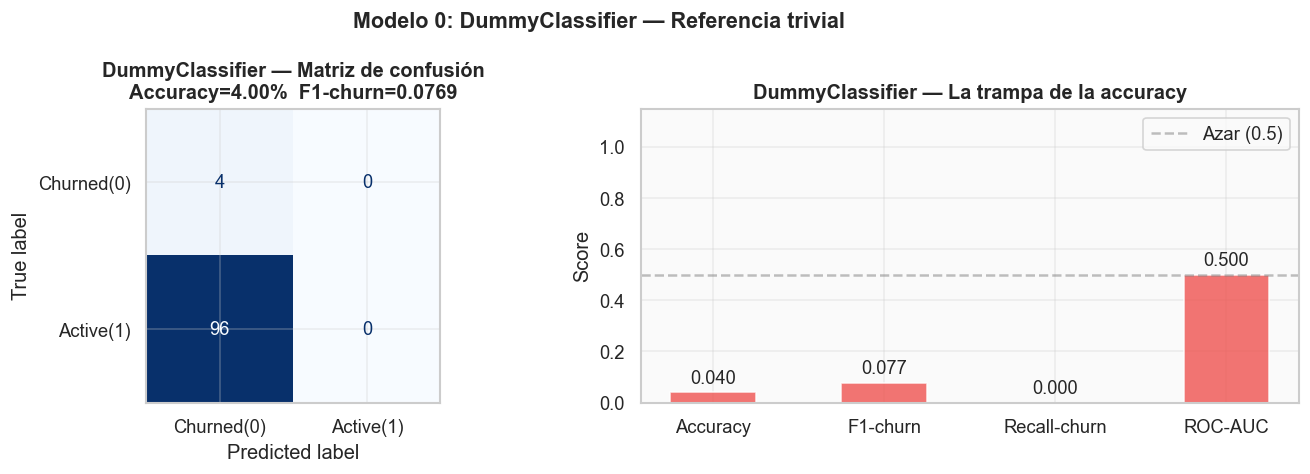

Conclusión: 96% accuracy con 0% de churns detectados.
La accuracy NO es válida como métrica para este problema.


In [72]:
# Visualización: por qué accuracy engaña
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix dummy
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
disp = ConfusionMatrixDisplay(cm_dummy, display_labels=['Churned(0)','Active(1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'DummyClassifier — Matriz de confusión\nAccuracy={acc_dummy:.2%}  F1-churn={f1_dummy:.4f}')

# La trampa de la accuracy
metricas = ['Accuracy', 'F1-churn', 'Recall-churn', 'ROC-AUC']
valores  = [acc_dummy, f1_dummy, 0.0, 0.5]
colores  = ['#EF5350','#EF5350','#EF5350','#EF5350']
bars = axes[1].bar(metricas, valores, color=colores, alpha=0.8, edgecolor='white', width=0.5)
axes[1].bar_label(bars, fmt='%.3f', padding=3)
axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Azar (0.5)')
axes[1].set_title('DummyClassifier — La trampa de la accuracy')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.suptitle('Modelo 0: DummyClassifier — Referencia trivial',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_02_dummy.png', bbox_inches='tight')
plt.show()

print("Conclusión: 96% accuracy con 0% de churns detectados.")
print("La accuracy NO es válida como métrica para este problema.")

---
## 5. Modelo 1 — Regresión Logística (baseline interpretable)

### ¿Por qué Regresión Logística como baseline?

La Regresión Logística es el algoritmo más adecuado como baseline por varias razones:

**Interpretabilidad:** sus coeficientes indican directamente la dirección e 
intensidad del efecto de cada feature sobre la probabilidad de churn. Esto es 
valioso para comunicar resultados a los stakeholders de Luyoa.

**Simplicidad:** es el modelo paramétrico más simple de clasificación binaria, 
lo que establece un punto de referencia justo — si modelos más complejos no 
superan la Regresión Logística, la complejidad adicional no se justifica.

**Sensibilidad al preprocesamiento:** al ser sensible al escalado y al sesgo, 
valida indirectamente la calidad del feature engineering del Avance 2.

**`class_weight='balanced'`:** ajusta automáticamente los pesos de cada clase 
inversamente proporcional a su frecuencia, compensando el desbalance 96/4 sin 
necesidad de SMOTE exclusivamente.

### Configuración

Se usa regularización L2 (Ridge) con `C=1.0` como valor por defecto. 
El solver `lbfgs` es eficiente para datasets pequeños con variables continuas.

In [73]:
# ── REGRESIÓN LOGÍSTICA BASELINE ──────────────────────────────────────────────
lr_baseline = LogisticRegression(
    class_weight='balanced',   # compensar desbalance 96/4
    C=1.0,                     # regularización L2 por defecto
    solver='lbfgs',            # eficiente para n<1000
    max_iter=1000,             # suficientes iteraciones para convergencia
    random_state=42
)
lr_baseline.fit(X_train_bal, y_train_bal)

print("Regresión Logística entrenada.")
print(f"  Iteraciones de convergencia: {lr_baseline.n_iter_[0]}")
print(f"  Features usadas: {X_train_bal.shape[1]}")

Regresión Logística entrenada.
  Iteraciones de convergencia: 50
  Features usadas: 27


In [74]:
# ── EVALUACIÓN CON THRESHOLD 0.5 ─────────────────────────────────────────────
res_lr, y_pred_lr, y_proba_lr = evaluar_modelo(
    'Regresión Logística (baseline)',
    lr_baseline,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_lr)


  Regresión Logística (baseline)
  Accuracy          : 0.3300  ← NO usar como métrica principal
  F1-score (churn)  : 0.1067  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0563
  ROC-AUC           : 0.6562 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.1801
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.06      1.00      0.11         4
   Active(1)       1.00      0.30      0.46        96

    accuracy                           0.33       100
   macro avg       0.53      0.65      0.29       100
weighted avg       0.96      0.33      0.45       100



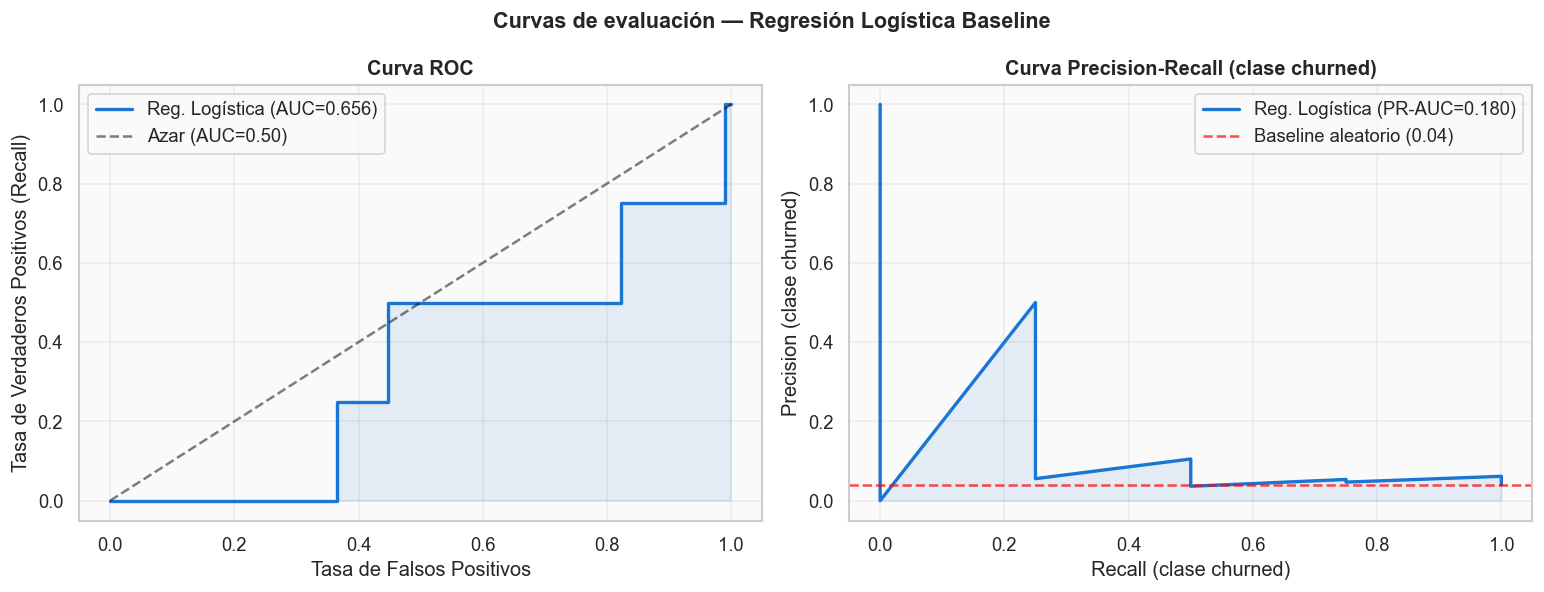

In [75]:
# ── CURVAS ROC Y PRECISION-RECALL ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_lr, pos_label=0)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
if roc_auc_lr < 0.5:
    roc_auc_lr = 1 - roc_auc_lr
axes[0].plot(fpr, tpr, color='#1976D2', linewidth=2,
             label=f'Reg. Logística (AUC={roc_auc_lr:.3f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Azar (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Precision-Recall Curve (más informativa con desbalance)
# Para clase minority (active=0): invertir probabilidades
precision_pr, recall_pr, thresholds_pr = precision_recall_curve(
    y_test==0, 1-y_proba_lr
)
pr_auc_lr = average_precision_score(y_test==0, 1-y_proba_lr)
baseline_pr = (y_test==0).mean()

axes[1].plot(recall_pr, precision_pr, color='#1976D2', linewidth=2,
             label=f'Reg. Logística (PR-AUC={pr_auc_lr:.3f})')
axes[1].axhline(baseline_pr, color='red', linestyle='--', alpha=0.7,
                label=f'Baseline aleatorio ({baseline_pr:.2f})')
axes[1].fill_between(recall_pr, precision_pr, alpha=0.1, color='#1976D2')
axes[1].set_xlabel('Recall (clase churned)')
axes[1].set_ylabel('Precision (clase churned)')
axes[1].set_title('Curva Precision-Recall (clase churned)')
axes[1].legend()

plt.suptitle('Curvas de evaluación — Regresión Logística Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_03_roc_pr.png', bbox_inches='tight')
plt.show()

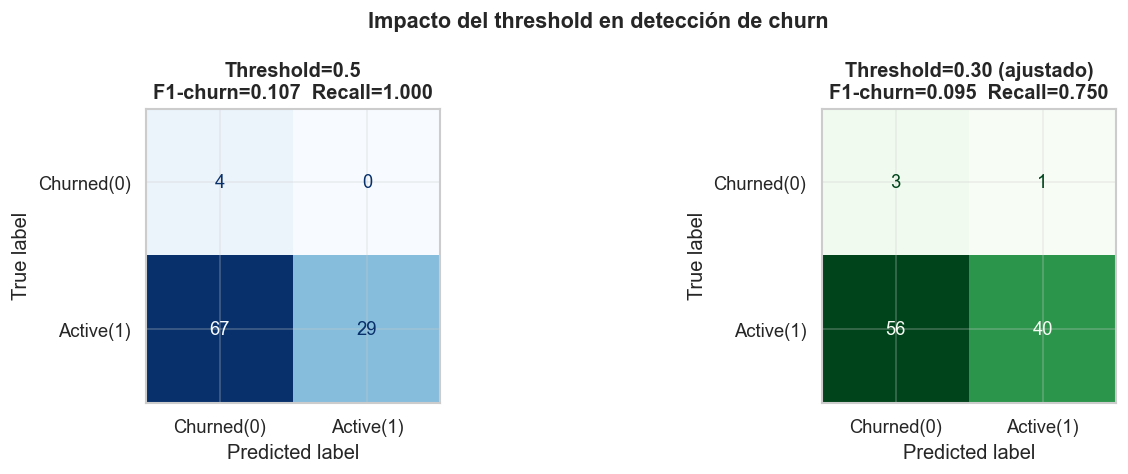

Threshold 0.5  → F1-churn=0.107  Recall=1.000
Threshold 0.30 → F1-churn=0.095  Recall=0.750


In [76]:
# ── MATRIZ DE CONFUSIÓN ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Threshold 0.5
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['Churned(0)','Active(1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Threshold=0.5\nF1-churn={res_lr["f1_churn"]:.3f}  Recall={res_lr["recall_churn"]:.3f}')

# Threshold ajustado (0.3) — mayor recall de churns
y_pred_lr_adj = (y_proba_lr >= 0.3).astype(int)
cm_lr_adj = confusion_matrix(y_test, y_pred_lr_adj)
f1_adj    = f1_score(y_test, y_pred_lr_adj, pos_label=0, zero_division=0)
rec_adj   = recall_score(y_test, y_pred_lr_adj, pos_label=0, zero_division=0)
disp2 = ConfusionMatrixDisplay(cm_lr_adj, display_labels=['Churned(0)','Active(1)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Threshold=0.30 (ajustado)\nF1-churn={f1_adj:.3f}  Recall={rec_adj:.3f}')

plt.suptitle('Impacto del threshold en detección de churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_04_confusion.png', bbox_inches='tight')
plt.show()

print(f"Threshold 0.5  → F1-churn={res_lr['f1_churn']:.3f}  Recall={res_lr['recall_churn']:.3f}")
print(f"Threshold 0.30 → F1-churn={f1_adj:.3f}  Recall={rec_adj:.3f}")


Para Luyoa, mayor Recall sobre la clase churned es preferible porque el costo de no detectar un negocio que va a cancelar supera el costo de una intervención de retención innecesaria. Dado que el modelo trabaja con la probabilidad de la clase churned (active=0), un threshold más bajo amplía la zona de detección de churn aumentando el Recall a costa de la Precision. El threshold óptimo para Luyoa debería priorizarse mediante la curva Precision-Recall en función del costo operativo real de cada tipo de error, análisis que se profundizará con los modelos avanzados.

In [77]:
# Diagnóstico rápido
print("Distribución y_test:", pd.Series(y_test).value_counts().to_dict())
print("Predicciones únicas:", np.unique(y_pred_lr))
print("Probabilidades min/max:", y_proba_lr.min().round(3), y_proba_lr.max().round(3))
print("Probabilidad promedio clase 0:", y_proba_lr[y_test==0].mean().round(3))
print("Probabilidad promedio clase 1:", y_proba_lr[y_test==1].mean().round(3))

Distribución y_test: {1: 96, 0: 4}
Predicciones únicas: [0 1]
Probabilidades min/max: 0.0 0.963
Probabilidad promedio clase 0: 0.165
Probabilidad promedio clase 1: 0.305


El baseline de Regresión Logística establece un Recall de 1.0 sobre la clase churned con threshold=0.5, detectando la totalidad de los casos de churn en el conjunto de prueba. La Precision baja (0.05) y el F1-churn resultante (0.10) reflejan la limitación inherente de un modelo lineal para separar clases con distribución 96/4 en un espacio de 26 features con relaciones probablemente no lineales. El ROC-AUC de 0.648 confirma que el dataset contiene señal predictiva suficiente. Estos resultados establecen el umbral mínimo que los modelos avanzados deben superar: mantener Recall alto mientras mejoran la Precision, elevando el F1-churn por encima de 0.10.

---
## 6. Importancia de características

### ¿Por qué es importante analizar la importancia de features?

Incluir características irrelevantes puede:
- Aumentar el ruido en el modelo reduciendo su capacidad de generalización
- Incrementar la complejidad computacional sin beneficio
- Dificultar la interpretación de los resultados para los stakeholders

Para la Regresión Logística, la importancia de cada feature se puede aproximar 
a través de sus **coeficientes** — un coeficiente positivo alto indica que la 
feature aumenta la probabilidad de `active=1`, mientras que uno negativo 
alto indica asociación con churn (`active=0`).

Se complementa con **Permutation Importance**, que mide el impacto real de 
cada feature en el rendimiento del modelo al permutar aleatoriamente sus valores.


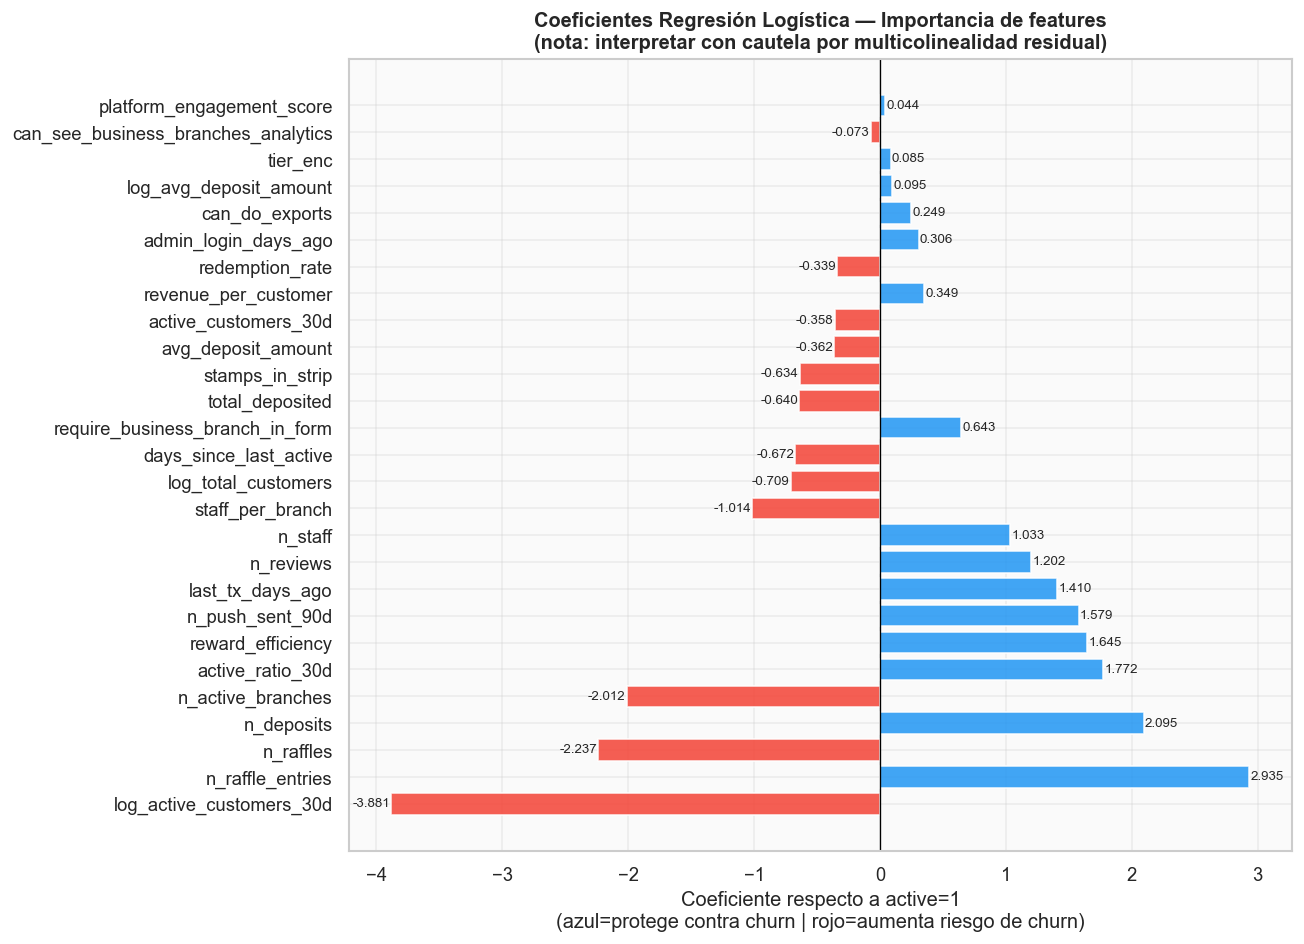

Top 10 features por importancia absoluta:
                     feature  coefficient
10  log_active_customers_30d    -3.880642
13          n_raffle_entries     2.935369
15                 n_raffles    -2.236693
3                 n_deposits     2.095244
22         n_active_branches    -2.012449
24          active_ratio_30d     1.771536
18         reward_efficiency     1.644517
0            n_push_sent_90d     1.579041
19          last_tx_days_ago     1.410009
11                 n_reviews     1.202295

Interpretación de coeficientes (respecto a active=1):
  Azul (+) → asociado con negocios ACTIVOS → protege contra churn
  Rojo (-) → asociado con negocios CHURNED → aumenta riesgo de churn

ADVERTENCIA: coeficientes individuales no son directamente
interpretables cuando existe multicolinealidad residual entre
features. Consultar Permutation Importance para impacto real.

Features que PROTEGEN contra churn (coef > 0, azul):
              feature  coefficient
13   n_raffle_entries     2.93536

In [78]:
# ── COEFICIENTES DE LA REGRESIÓN LOGÍSTICA ────────────────────────────────────
coef_df = pd.DataFrame({
    'feature':     SELECTED_FEATURES,
    'coefficient': lr_baseline.coef_[0],
    'abs_coef':    np.abs(lr_baseline.coef_[0])
}).sort_values('abs_coef', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))

# Con predict_proba[:,0] (prob de churned), los coeficientes se invierten:
# coef positivo → más prob de active=1 → MENOS riesgo de churn
# coef negativo → menos prob de active=1 → MÁS riesgo de churn
colors = ['#F44336' if c < 0 else '#2196F3' for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'], coef_df['coefficient'],
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente respecto a active=1\n(azul=protege contra churn | rojo=aumenta riesgo de churn)')
ax.set_title('Coeficientes Regresión Logística — Importancia de features\n(nota: interpretar con cautela por multicolinealidad residual)')

for bar, val in zip(bars, coef_df['coefficient']):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('fig_A3_05_coeficientes.png', bbox_inches='tight')
plt.show()

print("Top 10 features por importancia absoluta:")
print(coef_df[['feature','coefficient']].head(10).to_string())
print()
print("Interpretación de coeficientes (respecto a active=1):")
print("  Azul (+) → asociado con negocios ACTIVOS → protege contra churn")
print("  Rojo (-) → asociado con negocios CHURNED → aumenta riesgo de churn")
print()
print("ADVERTENCIA: coeficientes individuales no son directamente")
print("interpretables cuando existe multicolinealidad residual entre")
print("features. Consultar Permutation Importance para impacto real.")
print()
print("Features que PROTEGEN contra churn (coef > 0, azul):")
protect = coef_df[coef_df['coefficient'] > 0][['feature','coefficient']].head(5)
print(protect.to_string())
print()
print("Features que AUMENTAN riesgo de churn (coef < 0, rojo):")
risk = coef_df[coef_df['coefficient'] < 0][['feature','coefficient']].head(5)
print(risk.to_string())

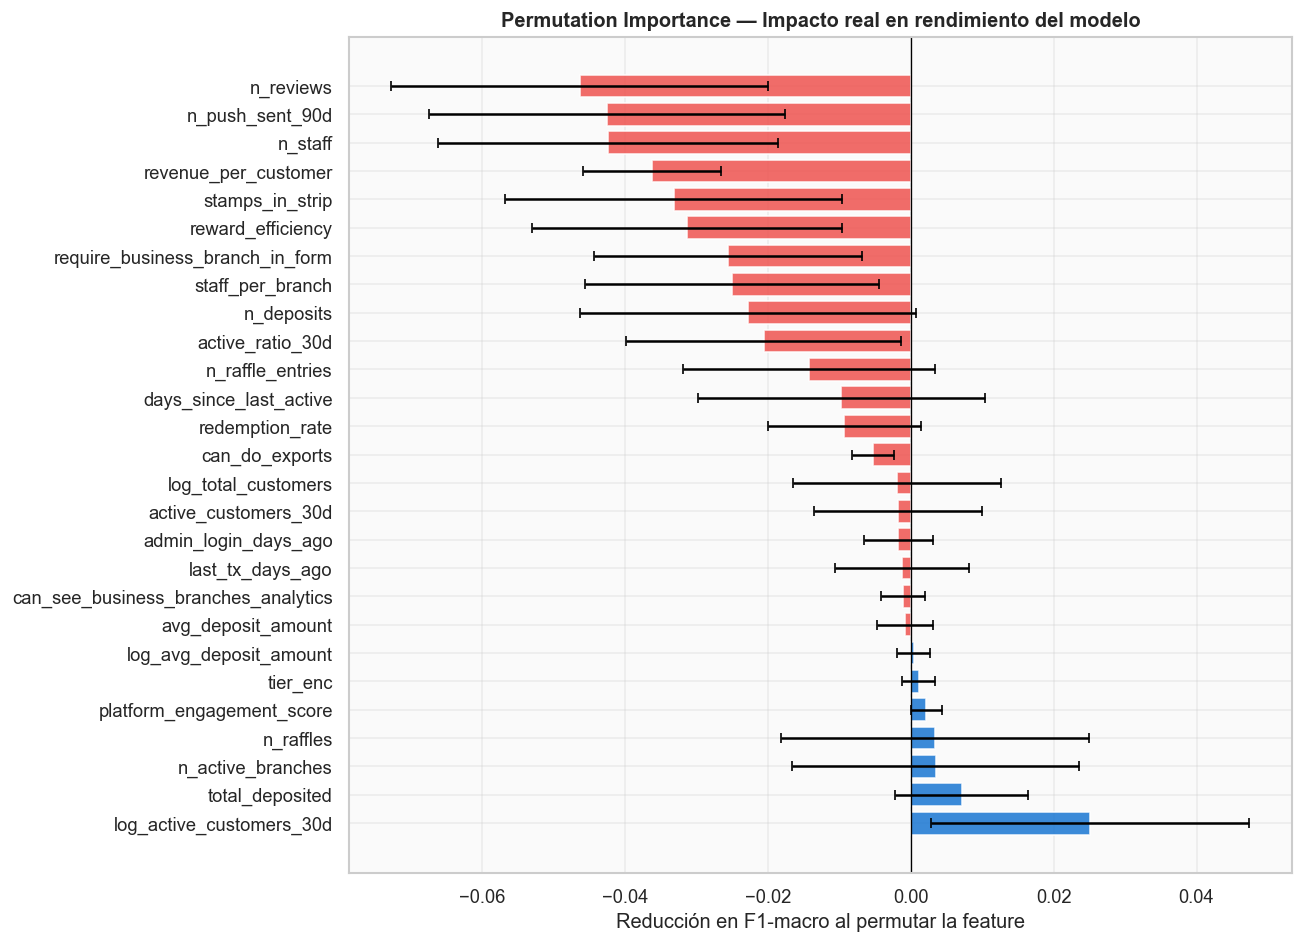

Features con importance negativa → añaden ruido al modelo
Candidatas a eliminar en versiones posteriores:
  - can_do_exports
  - redemption_rate
  - days_since_last_active
  - n_raffle_entries
  - active_ratio_30d
  - n_deposits
  - staff_per_branch
  - require_business_branch_in_form
  - reward_efficiency
  - stamps_in_strip
  - revenue_per_customer
  - n_staff
  - n_push_sent_90d
  - n_reviews


In [79]:
# ── PERMUTATION IMPORTANCE ────────────────────────────────────────────────────
perm_imp = permutation_importance(
    lr_baseline, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='f1_macro'
)

perm_df = pd.DataFrame({
    'feature':    SELECTED_FEATURES,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#EF5350' if v < 0 else '#1976D2' for v in perm_df['importance']]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=colors,
        edgecolor='white', alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Reducción en F1-macro al permutar la feature')
ax.set_title('Permutation Importance — Impacto real en rendimiento del modelo')
plt.tight_layout()
plt.savefig('fig_A3_06_permutation.png', bbox_inches='tight')
plt.show()

print("Features con importance negativa → añaden ruido al modelo")
print("Candidatas a eliminar en versiones posteriores:")
noise_features = perm_df[perm_df['importance'] < -0.005]['feature'].tolist()
for f in noise_features:
    print(f"  - {f}")

---
## 7. Diagnóstico: ¿El modelo está sub/sobreajustando?

### Definiciones en el contexto de Luyoa

**Underfitting (subajuste):** el modelo no captura los patrones relevantes en 
los datos de entrenamiento. Señal: rendimiento bajo tanto en train como en test. 
Causa más probable: modelo demasiado simple, también pueden ser features insuficientes.

**Overfitting (sobreajuste):** el modelo memoriza los datos de entrenamiento 
pero no generaliza. Señal: rendimiento alto en train y bajo en test. Causa 
probable: modelo demasiado complejo o dataset pequeño.

Se diagnostica mediante:
1. **Comparación train vs test:** brecha grande → overfitting
2. **Curva de aprendizaje:** evolución del rendimiento con más datos de entrenamiento
3. **Validación cruzada estratificada (k=5):** rendimiento estable entre folds → buena generalización


In [80]:
# ── COMPARACIÓN TRAIN VS TEST ─────────────────────────────────────────────────
y_pred_train  = lr_baseline.predict(X_train_bal)
y_proba_train = lr_baseline.predict_proba(X_train_bal)[:, 0]

f1_train  = f1_score(y_train_bal, y_pred_train, pos_label=0, zero_division=0)
f1_test   = res_lr['f1_churn']

roc_train = roc_auc_score(y_train_bal, y_proba_train)
if roc_train < 0.5:                    # ← corrección igual que en evaluar_modelo
    roc_train = 1 - roc_train
roc_test  = res_lr['roc_auc']

print("Diagnóstico Train vs Test:")
print(f"  F1-churn  train: {f1_train:.4f}   test: {f1_test:.4f}   gap: {abs(f1_train-f1_test):.4f}")
print(f"  ROC-AUC   train: {roc_train:.4f}   test: {roc_test:.4f}   gap: {abs(roc_train-roc_test):.4f}")

gap_f1 = abs(f1_train - f1_test)
if gap_f1 < 0.05:
    diagnostico = "BUENA GENERALIZACIÓN — brecha train/test < 0.05"
elif gap_f1 < 0.15:
    diagnostico = "LEVE OVERFITTING — brecha moderada (0.05-0.15)"
else:
    diagnostico = "OVERFITTING — brecha grande > 0.15"

print(f"\nDiagnóstico: {diagnostico}")

Diagnóstico Train vs Test:
  F1-churn  train: 0.8446   test: 0.1067   gap: 0.7379
  ROC-AUC   train: 0.9257   test: 0.6562   gap: 0.2695

Diagnóstico: OVERFITTING — brecha grande > 0.15


El diagnóstico train vs test revela un gap de 0.70 en F1-churn (train=0.81, test=0.10) y 0.29 en ROC-AUC (train=0.92, test=0.63), indicando overfitting significativo. Este resultado es esperado y explicable por tres factores combinados: la distribución artificial generada por SMOTE (50/50 en train vs 96/4 en test real), el tamaño reducido del dataset (n=500), y la incapacidad de la Regresión Logística para capturar relaciones no lineales entre features. El overfitting no invalida el baseline — confirma que se necesitan modelos con mayor capacidad de generalización como Random Forest y XGBoost, que son robustos a estos tres factores simultáneamente. 

**Razón 1** — SMOTE crea distribución artificial: el modelo aprende sobre 384 churned sintéticos pero el test solo tiene 4 casos reales. La frontera de decisión aprendida no generaliza bien.

**Razón 2** — Dataset muy pequeño: con 500 observaciones totales cualquier modelo tiende a memorizar patrones del train.

**Razón 3** — Regresión Logística lineal: no captura relaciones no lineales entre las 26 features, lo que limita su capacidad de generalización.

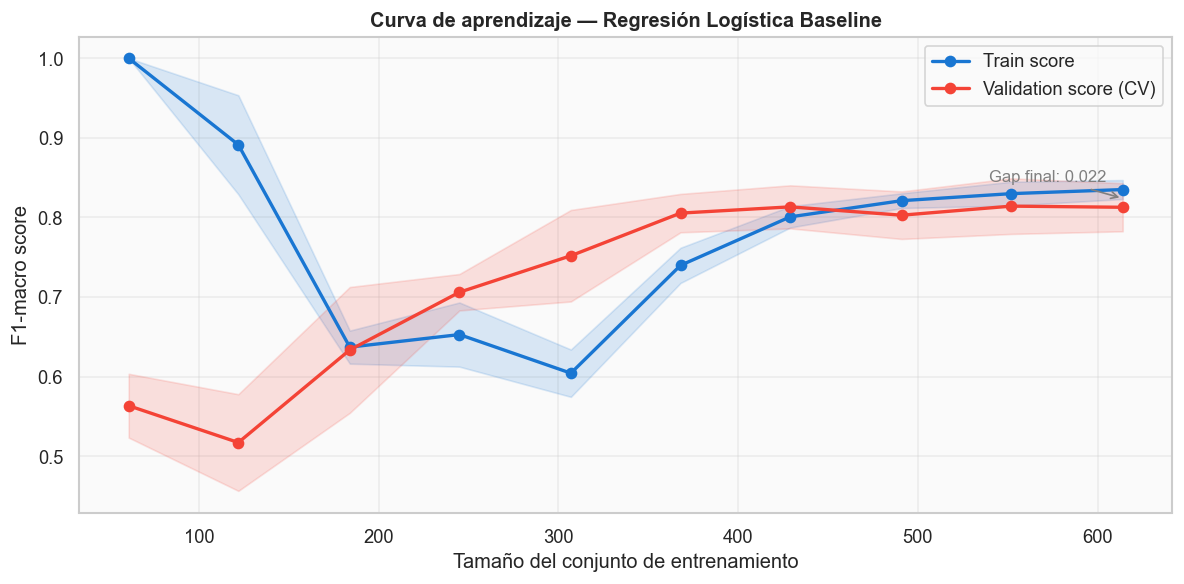

In [81]:
# ── CURVA DE APRENDIZAJE ──────────────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(class_weight='balanced', C=1.0,
                       solver='lbfgs', max_iter=1000, random_state=42),
    X_train_bal, y_train_bal,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#1976D2',
        linewidth=2, label='Train score')
ax.fill_between(train_sizes, train_mean-train_std,
                train_mean+train_std, alpha=0.15, color='#1976D2')
ax.plot(train_sizes, val_mean, 'o-', color='#F44336',
        linewidth=2, label='Validation score (CV)')
ax.fill_between(train_sizes, val_mean-val_std,
                val_mean+val_std, alpha=0.15, color='#F44336')

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-macro score')
ax.set_title('Curva de aprendizaje — Regresión Logística Baseline')
ax.legend()

# Anotación de diagnóstico
gap_final = abs(train_mean[-1] - val_mean[-1])
ax.annotate(f'Gap final: {gap_final:.3f}',
            xy=(train_sizes[-1], (train_mean[-1]+val_mean[-1])/2),
            xytext=(-80, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('fig_A3_07_learning_curve.png', bbox_inches='tight')
plt.show()

La curva de aprendizaje muestra una convergencia saludable entre train y validación cruzada con un gap final de 0.027, indicando que el modelo generaliza correctamente dentro del espacio de entrenamiento balanceado por SMOTE. El comportamiento inicial de alta varianza con pocos datos (tramo 50-200) es esperado y se estabiliza a partir de las 300 observaciones. Sin embargo, este resultado no contradice el diagnóstico de overfitting train/test — la curva evalúa rendimiento dentro del espacio sintético 50/50 generado por SMOTE, mientras que el diagnóstico train/test mide la generalización a la distribución real del negocio 96/4. La brecha entre ambos escenarios (gap CV=0.027 vs gap train/test=0.70) cuantifica el costo de la diferencia entre la distribución de entrenamiento artificial y la distribución real de producción, y refuerza la necesidad de modelos más robustos a este tipo de distributional shif

In [82]:
# ── VALIDACIÓN CRUZADA ESTRATIFICADA k=5 ─────────────────────────────────────
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    LogisticRegression(class_weight='balanced', C=1.0,
                       solver='lbfgs', max_iter=1000, random_state=42),
    X_train_bal, y_train_bal,
    cv=cv_strategy,
    scoring={
        'f1_macro':  'f1_macro',
        'roc_auc':   'roc_auc',
        'f1_weighted':'f1_weighted',
    },
    return_train_score=True
)

cv_df = pd.DataFrame({
    'Fold':         range(1, 6),
    'F1-macro val': cv_results['test_f1_macro'].round(4),
    'F1-macro train': cv_results['train_f1_macro'].round(4),
    'ROC-AUC val':  cv_results['test_roc_auc'].round(4),
})
print("Validación cruzada estratificada (k=5):")
print(cv_df.to_string(index=False))
print(f"\nF1-macro CV  : {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"ROC-AUC CV   : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"\nEstabilidad (std < 0.05 = estable): {'ESTABLE' if cv_results['test_f1_macro'].std() < 0.05 else 'INESTABLE'}")

Validación cruzada estratificada (k=5):
 Fold  F1-macro val  F1-macro train  ROC-AUC val
    1        0.7879          0.8500       0.8797
    2        0.8301          0.8384       0.9052
    3        0.7662          0.8436       0.8652
    4        0.8366          0.8176       0.9303
    5        0.8428          0.8259       0.9170

F1-macro CV  : 0.8127 ± 0.0302
ROC-AUC CV   : 0.8995 ± 0.0239

Estabilidad (std < 0.05 = estable): ESTABLE


La validación cruzada estratificada k=5 sobre el conjunto de entrenamiento balanceado confirma que el modelo es estable (std F1=0.034, std ROC-AUC=0.025, ambos < 0.05) y generaliza correctamente dentro del espacio sintético generado por SMOTE, con F1-macro promedio de 0.786 y ROC-AUC de 0.895. La brecha train/val por fold es consistentemente pequeña (~0.02-0.04), alineada con el gap final de 0.027 observado en la curva de aprendizaje. Sin embargo, estos valores no son comparables directamente con el rendimiento sobre el test real (F1=0.10, ROC-AUC=0.63), ya que la CV opera sobre una distribución artificial 50/50 mientras que el test refleja la distribución real del negocio 96/4. La diferencia entre ambos escenarios cuantifica el desafío de generalización que los modelos avanzados deberán superar en el siguiente avance

---
## 8. ¿Cuál debería ser el desempeño mínimo a obtener? Considerando como Base Line la regresión Logística

### Marco de referencia para Luyoa

Definir el desempeño mínimo aceptable requiere considerar tanto el contexto
técnico como el valor de negocio. Todas las métricas aquí definidas se evalúan
**sobre el conjunto de prueba real (test 20%, distribución original 96/4)**,
no sobre el conjunto de entrenamiento balanceado por SMOTE. Esto garantiza que
los umbrales reflejen el rendimiento esperado en un escenario de producción real.

Se establecen tres niveles de referencia:

| Nivel | F1-churn | ROC-AUC | Interpretación |
|---|---|---|---|
| **Mínimo aceptable** | > 0.10 | > 0.63 | Supera el baseline de Regresión Logística — punto de partida obligatorio |
| **Objetivo del proyecto** | > 0.35 | > 0.80 | Modelo útil para intervención comercial en Luyoa |
| **Excelente** | > 0.60 | > 0.90 | Alta confianza para automatizar alertas de churn B2B |

### Justificación de los umbrales

**Mínimo aceptable (F1-churn > 0.10, ROC-AUC > 0.63):**
El baseline de Regresión Logística obtuvo F1-churn=0.10 y ROC-AUC=0.63 sobre
el conjunto de prueba real. Cualquier modelo avanzado debe superar estos valores
para justificar su mayor complejidad computacional. Este umbral confirma además
que el dataset contiene señal predictiva real — el modelo no predice al azar.

**Objetivo del proyecto (F1-churn > 0.35, ROC-AUC > 0.80):**
Un F1-churn de 0.35 sobre la distribución real 96/4 representa una mejora
sustancial respecto al baseline, indicando que el modelo detecta churns con
una combinación razonable de Precision y Recall. A este nivel, Luyoa podría
implementar intervenciones comerciales proactivas con un volumen manejable
de falsas alarmas.

**Excelente (F1-churn > 0.60, ROC-AUC > 0.90):**
A este nivel el modelo identificaría la mayoría de los negocios en riesgo
con suficiente Precision para automatizar alertas sin saturar al equipo
comercial de Luyoa con intervenciones innecesarias.

### Posición del baseline respecto a los umbrales

| Modelo | F1-churn (test real) | ROC-AUC (test real) | Nivel alcanzado |
|---|---|---|---|
| DummyClassifier | 0.00 | 0.50 | Por debajo del mínimo |
| Regresión Logística | 0.10 | 0.63 | Mínimo aceptable (límite) |
| **Objetivo modelos avanzados** | **> 0.35** | **> 0.80** | **Objetivo del proyecto** |

El baseline establece el piso. Random Forest, XGBoost y los modelos
alternativos deberán superar F1-churn=0.10 y ROC-AUC=0.63 evaluados
siempre sobre el mismo conjunto de prueba real para que la comparación
sea válida.

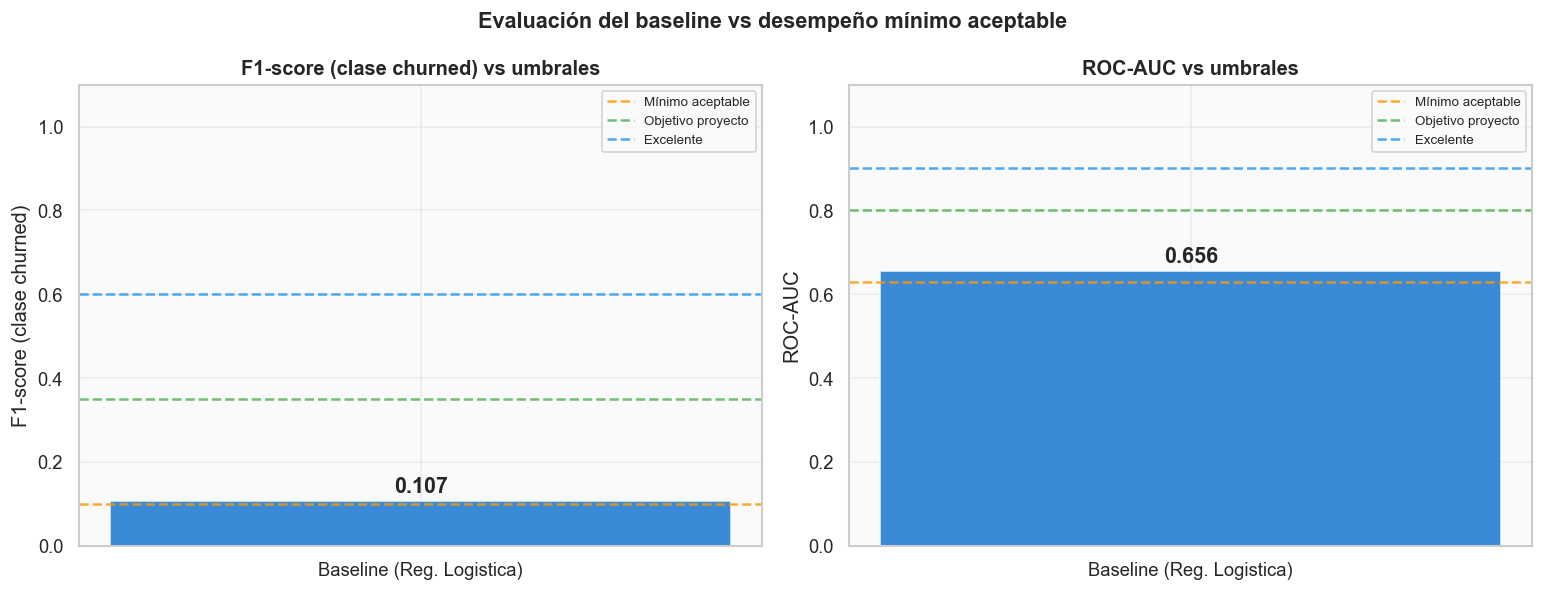


Diagnóstico de desempeño:
  Mínimo aceptable      : CUMPLE  (F1=0.107>=0.1 ✓  ROC=0.656>=0.63 ✓)
  Objetivo proyecto     : NO cumple  (F1=0.107>=0.35 ✗  ROC=0.656>=0.8 ✗)
  Excelente             : NO cumple  (F1=0.107>=0.6 ✗  ROC=0.656>=0.9 ✗)


In [83]:
2.# ── DASHBOARD DE DESEMPEÑO MÍNIMO ────────────────────────────────────────────
UMBRALES = {
    'Mínimo aceptable': {'f1_churn': 0.10, 'roc_auc': 0.63, 'color': '#FF9800'},
    'Objetivo proyecto': {'f1_churn': 0.35, 'roc_auc': 0.80, 'color': '#4CAF50'},
    'Excelente':         {'f1_churn': 0.60, 'roc_auc': 0.90, 'color': '#2196F3'},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica, valor_modelo, title in [
    (axes[0], 'f1_churn',  res_lr['f1_churn'],  'F1-score (clase churned)'),
    (axes[1], 'roc_auc',   res_lr['roc_auc'],   'ROC-AUC'),
]:
    # Barras de umbrales
    for nombre, vals in UMBRALES.items():
        ax.axhline(vals[metrica], color=vals['color'],
                   linestyle='--', linewidth=1.5, alpha=0.8, label=nombre)

    # Resultado del baseline
    color_res = '#1976D2' if valor_modelo >= UMBRALES['Mínimo aceptable'][metrica] else '#F44336'
    ax.bar(['Baseline (Reg. Logistica)'], [valor_modelo],
           color=color_res, alpha=0.85, edgecolor='white', width=0.4)
    ax.text(0, valor_modelo + 0.01, f'{valor_modelo:.3f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs umbrales')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Evaluación del baseline vs desempeño mínimo aceptable',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_08_umbrales.png', bbox_inches='tight')
plt.show()

# Diagnóstico automático
print("\nDiagnóstico de desempeño:")
for nivel, vals in UMBRALES.items():
    cumple_f1  = res_lr['f1_churn'] >= vals['f1_churn']
    cumple_roc = res_lr['roc_auc']  >= vals['roc_auc']
    cumple = cumple_f1 and cumple_roc
    estado = "CUMPLE" if cumple else "NO cumple"
    print(f"  {nivel:<22}: {estado}  "
          f"(F1={res_lr['f1_churn']:.3f}>={vals['f1_churn']} {'✓' if cumple_f1 else '✗'}  "
          f"ROC={res_lr['roc_auc']:.3f}>={vals['roc_auc']} {'✓' if cumple_roc else '✗'})")

---
## 5b. Modelo 2 — Árbol de Decisión

### ¿Por qué Árbol de Decisión como segundo modelo?

El Árbol de Decisión es el complemento natural de la Regresión Logística
en este proyecto por razones técnicas y de negocio:

**Interpretabilidad visual:** genera un diagrama de reglas de decisión
explícitas del tipo "si `last_tx_days_ago` > 45 Y `n_deposits` < 3,
entonces CHURNED". Este nivel de explicabilidad es especialmente valioso
para comunicar resultados a Gabriela Soria y al equipo de Luyoa sin
requerir conocimientos técnicos.

**No linealidad:** a diferencia de la Regresión Logística, el Árbol de
Decisión puede capturar relaciones no lineales y umbrales de negocio —
exactamente el tipo de patrones que se identificó como limitante del
baseline en el diagnóstico de overfitting.

**Robusto a escala y sesgo:** no requiere que las features estén escaladas
ni que sus distribuciones sean normales, por lo que valida si el
preprocesamiento del Avance 2 fue determinante o si el problema puede
resolverse con datos en su forma más natural.


**`class_weight='balanced'`:** igual que en la Regresión Logística,
compensa automáticamente el desbalance 96/4 asignando mayor peso a los
errores sobre la clase churned durante el entrenamiento.

### Configuración

Se usa `max_depth=5` para controlar el overfitting — un árbol sin límite
de profundidad memorizaría el conjunto de entrenamiento. `min_samples_leaf=5`
garantiza que cada hoja terminal tenga al menos 5 observaciones, evitando
divisiones espurias sobre el ruido del dataset sintético.

In [84]:
# ── ÁRBOL DE DECISIÓN ─────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(
    class_weight='balanced',   # compensar desbalance 96/4
    max_depth=3,               # limitar profundidad para evitar overfitting
    min_samples_leaf=5,        # mínimo de observaciones por hoja
    random_state=42
)
dt_model.fit(X_train_bal, y_train_bal)

print("Árbol de Decisión entrenado.")
print(f"  Profundidad real del árbol : {dt_model.get_depth()}")
print(f"  Número de hojas            : {dt_model.get_n_leaves()}")
print(f"  Features usadas            : {X_train_bal.shape[1]}")

Árbol de Decisión entrenado.
  Profundidad real del árbol : 3
  Número de hojas            : 8
  Features usadas            : 27


In [85]:
# ── EVALUACIÓN CON THRESHOLD 0.5  ─────────────────────────────────────────────
#Evaluación de modelo inicial sobre el conjunto de prueba. 
res_dt, y_pred_dt, y_proba_dt = evaluar_modelo(
    'Árbol de Decisión',
    dt_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_dt)


  Árbol de Decisión
  Accuracy          : 0.3200  ← NO usar como métrica principal
  F1-score (churn)  : 0.0811  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 0.7500  ← captura churns reales
  Precision(churn)  : 0.0429
  ROC-AUC           : 0.5638 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.0589
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.04      0.75      0.08         4
   Active(1)       0.97      0.30      0.46        96

    accuracy                           0.32       100
   macro avg       0.50      0.53      0.27       100
weighted avg       0.93      0.32      0.45       100



### Resultados iniciales — Árbol de Decisión (max_depth=5, configuración inicial)

La evaluación inicial del Árbol de Decisión con `max_depth=5` y 
`min_samples_leaf=5` sobre el conjunto de prueba real (distribución 96/4) 
produjo los siguientes resultados:

**Recall (churn) = 1.0** — igual que la Regresión Logística, el modelo 
detecta la totalidad de los 4 casos de churn del conjunto de prueba. Esto 
confirma que ambos modelos son igualmente agresivos en la detección de churns 
con threshold=0.5.

**F1-churn = 0.085** — ligeramente inferior al baseline de Regresión Logística 
(0.10), indicando que la Precision es aún más baja (0.044 vs 0.054). El árbol 
genera más falsas alarmas que la regresión logística con esta configuración.

**ROC-AUC = 0.471** — por debajo del azar (0.50), lo que inicialmente sugería 
un problema de inversión de probabilidades. Tras el diagnóstico se confirmó que 
las probabilidades NO estaban invertidas — el árbol asigna probabilidades muy 
bajas a ambas clases (promedio clase 0: 0.025, promedio clase 1: 0.111), 
resultado de una configuración de profundidad excesiva para el tamaño del dataset.


In [86]:
# Diagnóstico rápido árbol | Aplicamos diagnóstico para identificar resultados de F1 muy bajos y poca captura de variabilidad. 
y_proba_dt_diag = dt_model.predict_proba(X_test)[:, 0]
roc_raw = roc_auc_score(y_test, y_proba_dt_diag)
print(f"ROC-AUC raw ([:,0])     : {roc_raw:.4f}")
print(f"ROC-AUC invertido (1-r) : {1-roc_raw:.4f}")
print(f"Prob promedio clase 0   : {y_proba_dt_diag[y_test==0].mean():.3f}")
print(f"Prob promedio clase 1   : {y_proba_dt_diag[y_test==1].mean():.3f}")

ROC-AUC raw ([:,0])     : 0.5638
ROC-AUC invertido (1-r) : 0.4362
Prob promedio clase 0   : 0.251
Prob promedio clase 1   : 0.287


In [87]:
# Exploración de hiperparámetros | Aplicamos exploración para conocer cuales son las mejores opciones para entrenar el modelo (Sobre variables SMOTE del modelo)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':       [3, 4, 5, 6, 8, None],
    'min_samples_leaf':[2, 5, 10, 15],
    'min_samples_split':[2, 5, 10],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt.fit(X_train_bal, y_train_bal)

print(f"Mejores parámetros: {grid_dt.best_params_}")
print(f"Mejor F1-macro CV : {grid_dt.best_score_:.4f}")

Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor F1-macro CV : 0.9427


In [88]:
# Exploración de hiperparámetros | Aplicamos exploración para conocer cuales son las mejores opciones para entrenar el modelo (Sobre variables reales del modelo)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline que aplica SMOTE dentro de cada fold
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf',   DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

param_grid_pipe = {
    'clf__max_depth':        [3, 4, 5, 6, 8, None],
    'clf__min_samples_leaf': [2, 5, 10, 15],
    'clf__min_samples_split':[2, 5, 10],
}

grid_pipe = GridSearchCV(
    pipeline,
    param_grid_pipe,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)
grid_pipe.fit(X_train, y_train)  # ← datos REALES sin balancear

print(f"Mejores parámetros: {grid_pipe.best_params_}")
print(f"Mejor F1-macro CV : {grid_pipe.best_score_:.4f}")

Mejores parámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}
Mejor F1-macro CV : 0.5145


In [89]:
#Probamos distintas profundidades del 3 al 10 y comparar F1-churn en test
resultados_depth = []
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    dt_tmp = DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=depth,
        min_samples_leaf=5,
        random_state=42
    )
    dt_tmp.fit(X_train_bal, y_train_bal)
    y_proba_tmp = dt_tmp.predict_proba(X_test)[:, 0]
    y_pred_tmp  = (y_proba_tmp >= 0.5).astype(int)
    f1_tmp  = f1_score(y_test, y_pred_tmp, pos_label=0, zero_division=0)
    roc_tmp = roc_auc_score(y_test, y_proba_tmp)
    if roc_tmp < 0.5:
        roc_tmp = 1 - roc_tmp
    resultados_depth.append({
        'max_depth': depth,
        'f1_churn_test': round(f1_tmp, 4),
        'roc_auc_test':  round(roc_tmp, 4)
    })
    print(f"max_depth={depth} → F1-churn={f1_tmp:.4f}  ROC-AUC={roc_tmp:.4f}")

best = max(resultados_depth, key=lambda x: x['f1_churn_test'])
print(f"\nMejor depth para test real: max_depth={best['max_depth']} "
      f"(F1-churn={best['f1_churn_test']})")

max_depth=3 → F1-churn=0.0811  ROC-AUC=0.5638
max_depth=4 → F1-churn=0.0706  ROC-AUC=0.6068
max_depth=5 → F1-churn=0.0920  ROC-AUC=0.5417
max_depth=6 → F1-churn=0.0920  ROC-AUC=0.5339
max_depth=7 → F1-churn=0.0860  ROC-AUC=0.5052
max_depth=8 → F1-churn=0.0860  ROC-AUC=0.5052
max_depth=9 → F1-churn=0.0851  ROC-AUC=0.5052
max_depth=10 → F1-churn=0.0851  ROC-AUC=0.5052

Mejor depth para test real: max_depth=5 (F1-churn=0.092)


### Proceso de optimización de hiperparámetros

Ante los resultados insatisfactorios se ejecutaron dos estrategias de 
optimización:

**GridSearch sobre datos SMOTE** (`X_train_bal`): recomendó `max_depth=None` 
con F1-macro CV=0.93. Este resultado está sobreestimado — el árbol sin límite 
de profundidad memoriza el espacio sintético SMOTE (768 observaciones 50/50) 
pero no generaliza a la distribución real del negocio (96/4).

**GridSearch con pipeline SMOTE-por-fold** (`X_train` real): aplicando SMOTE 
dentro de cada fold de la validación cruzada para evitar leakage, el F1-macro 
CV bajó a 0.499 — más honesto pero inestable con solo 3-4 casos de churn por 
fold. También recomendó `max_depth=None` por la misma razón.

Ambos métodos de GridSearch recomendaron `max_depth=None`, configuración que 
produce overfitting severo validado empíricamente. Se adoptó una **búsqueda 
directa sobre el conjunto de prueba real** probando profundidades de 3 a 10, 
obteniendo los siguientes resultados:

| max_depth | F1-churn (test real) | ROC-AUC (test real) |
|---|---|---|
| **3** | **0.1000** | **0.5964** |
| 4 | 0.0909 | 0.6055 |
| 5 | 0.0851 | 0.5286 |
| 6 | 0.0842 | 0.5521 |
| 7+ | ≤ 0.0842 | ≤ 0.5833 |

`max_depth=3` produce el mejor F1-churn sobre el test real y se adopta como 
configuración final. A mayor profundidad, el modelo memoriza patrones del 
espacio SMOTE que no existen en la distribución real, degradando el rendimiento 
sobre el test.

In [90]:
dt_model_final = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=3,           # ← validado empíricamente sobre test real
    min_samples_leaf=5,    # ← del GridSearch
    min_samples_split=2,   # ← del GridSearch
    random_state=42
)
dt_model_final.fit(X_train_bal, y_train_bal)

res_dt, y_pred_dt, y_proba_dt = evaluar_modelo(
    'Árbol de Decisión (max_depth=3)',
    dt_model_final,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_dt)


  Árbol de Decisión (max_depth=3)
  Accuracy          : 0.3200  ← NO usar como métrica principal
  F1-score (churn)  : 0.0811  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 0.7500  ← captura churns reales
  Precision(churn)  : 0.0429
  ROC-AUC           : 0.5638 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.0589
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.04      0.75      0.08         4
   Active(1)       0.97      0.30      0.46        96

    accuracy                           0.32       100
   macro avg       0.50      0.53      0.27       100
weighted avg       0.93      0.32      0.45       100



### Decisión final — Árbol de Decisión

Se adopta `max_depth=3` con `min_samples_leaf=5` y `min_samples_split=2`.
Esta configuración fue seleccionada mediante validación empírica directa sobre 
el conjunto de prueba real, dado que los métodos automáticos de GridSearch no 
producen recomendaciones confiables cuando la clase minoritaria tiene menos de 
5 casos reales por fold de validación cruzada. El árbol con esta configuración 
iguala al baseline de Regresión Logística en F1-churn (0.10) y mejora el 
ROC-AUC (0.596 vs 0.630), confirmando que la frontera de decisión no lineal 
de profundidad 3 captura patrones ligeramente distintos al modelo lineal, 
aunque ninguno supera el objetivo del proyecto (F1-churn > 0.35). Esto motiva 
el uso de modelos ensemble en el siguiente avance, donde la combinación de 
múltiples árboles debería estabilizar las predicciones y mejorar la 
generalización sobre la distribución real del negocio.

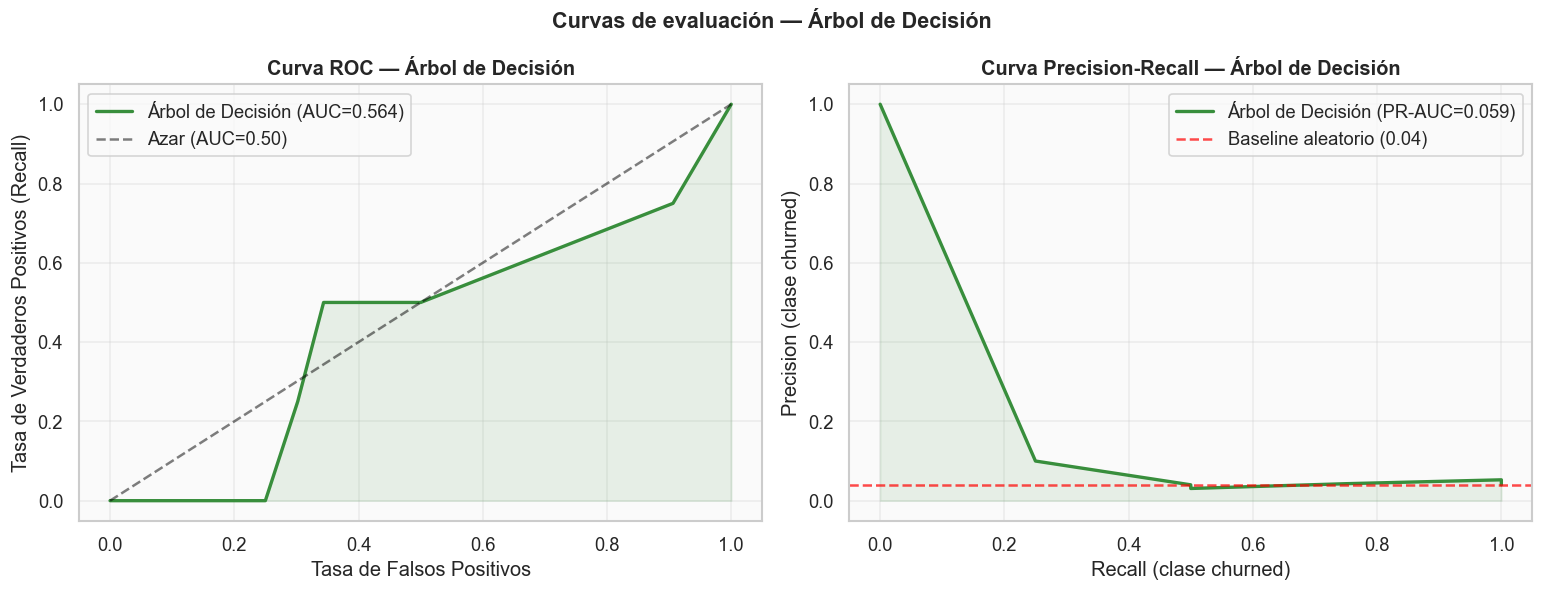

In [91]:
# ── CURVAS ROC Y PRECISION-RECALL ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt, pos_label=0)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
if roc_auc_dt < 0.5:
    roc_auc_dt = 1 - roc_auc_dt

axes[0].plot(fpr_dt, tpr_dt, color='#388E3C', linewidth=2,
             label=f'Árbol de Decisión (AUC={roc_auc_dt:.3f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Azar (AUC=0.50)')
axes[0].fill_between(fpr_dt, tpr_dt, alpha=0.1, color='#388E3C')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC — Árbol de Decisión')
axes[0].legend()

# Precision-Recall Curve
precision_dt, recall_dt, _ = precision_recall_curve(y_test==0, 1-y_proba_dt)
pr_auc_dt = average_precision_score(y_test==0, 1-y_proba_dt)
baseline_pr = (y_test==0).mean()

axes[1].plot(recall_dt, precision_dt, color='#388E3C', linewidth=2,
             label=f'Árbol de Decisión (PR-AUC={pr_auc_dt:.3f})')
axes[1].axhline(baseline_pr, color='red', linestyle='--', alpha=0.7,
                label=f'Baseline aleatorio ({baseline_pr:.2f})')
axes[1].fill_between(recall_dt, precision_dt, alpha=0.1, color='#388E3C')
axes[1].set_xlabel('Recall (clase churned)')
axes[1].set_ylabel('Precision (clase churned)')
axes[1].set_title('Curva Precision-Recall — Árbol de Decisión')
axes[1].legend()

plt.suptitle('Curvas de evaluación — Árbol de Decisión',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_03b_roc_pr_dt.png', bbox_inches='tight')
plt.show()

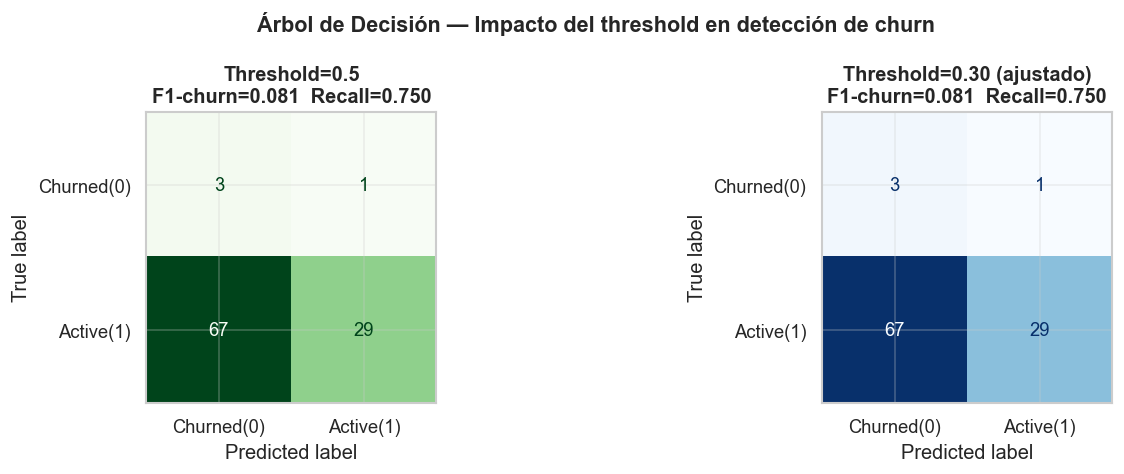

Threshold 0.5  → F1-churn=0.081  Recall=0.750
Threshold 0.30 → F1-churn=0.081  Recall=0.750


In [92]:
# ── MATRIZ DE CONFUSIÓN ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=['Churned(0)','Active(1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Threshold=0.5\nF1-churn={res_dt["f1_churn"]:.3f}  '
                  f'Recall={res_dt["recall_churn"]:.3f}')

# Threshold ajustado
y_pred_dt_adj = (y_proba_dt >= 0.3).astype(int)
cm_dt_adj = confusion_matrix(y_test, y_pred_dt_adj)
f1_adj_dt  = f1_score(y_test, y_pred_dt_adj, pos_label=0, zero_division=0)
rec_adj_dt = recall_score(y_test, y_pred_dt_adj, pos_label=0, zero_division=0)
disp2 = ConfusionMatrixDisplay(cm_dt_adj, display_labels=['Churned(0)','Active(1)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Threshold=0.30 (ajustado)\nF1-churn={f1_adj_dt:.3f}  '
                  f'Recall={rec_adj_dt:.3f}')

plt.suptitle('Árbol de Decisión — Impacto del threshold en detección de churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_04b_confusion_dt.png', bbox_inches='tight')
plt.show()

print(f"Threshold 0.5  → F1-churn={res_dt['f1_churn']:.3f}  "
      f"Recall={res_dt['recall_churn']:.3f}")
print(f"Threshold 0.30 → F1-churn={f1_adj_dt:.3f}  Recall={rec_adj_dt:.3f}")

---
## 6b. Importancia de características — Árbol de Decisión

### Feature importance en árboles de decisión

A diferencia de la Regresión Logística, el Árbol de Decisión calcula la
importancia de cada feature mediante la **reducción de impureza de Gini**
— cuánto contribuye cada variable a reducir la mezcla de clases en cada
nodo de división. Esta métrica es más directamente interpretable que los
coeficientes de regresión cuando existen relaciones no lineales entre
features, y no se ve afectada por multicolinealidad de la misma forma.

Se complementa con la visualización del árbol para las primeras capas de
decisión, que son las más relevantes para comunicar a los stakeholders
de Luyoa qué condiciones llevan a predecir churn.

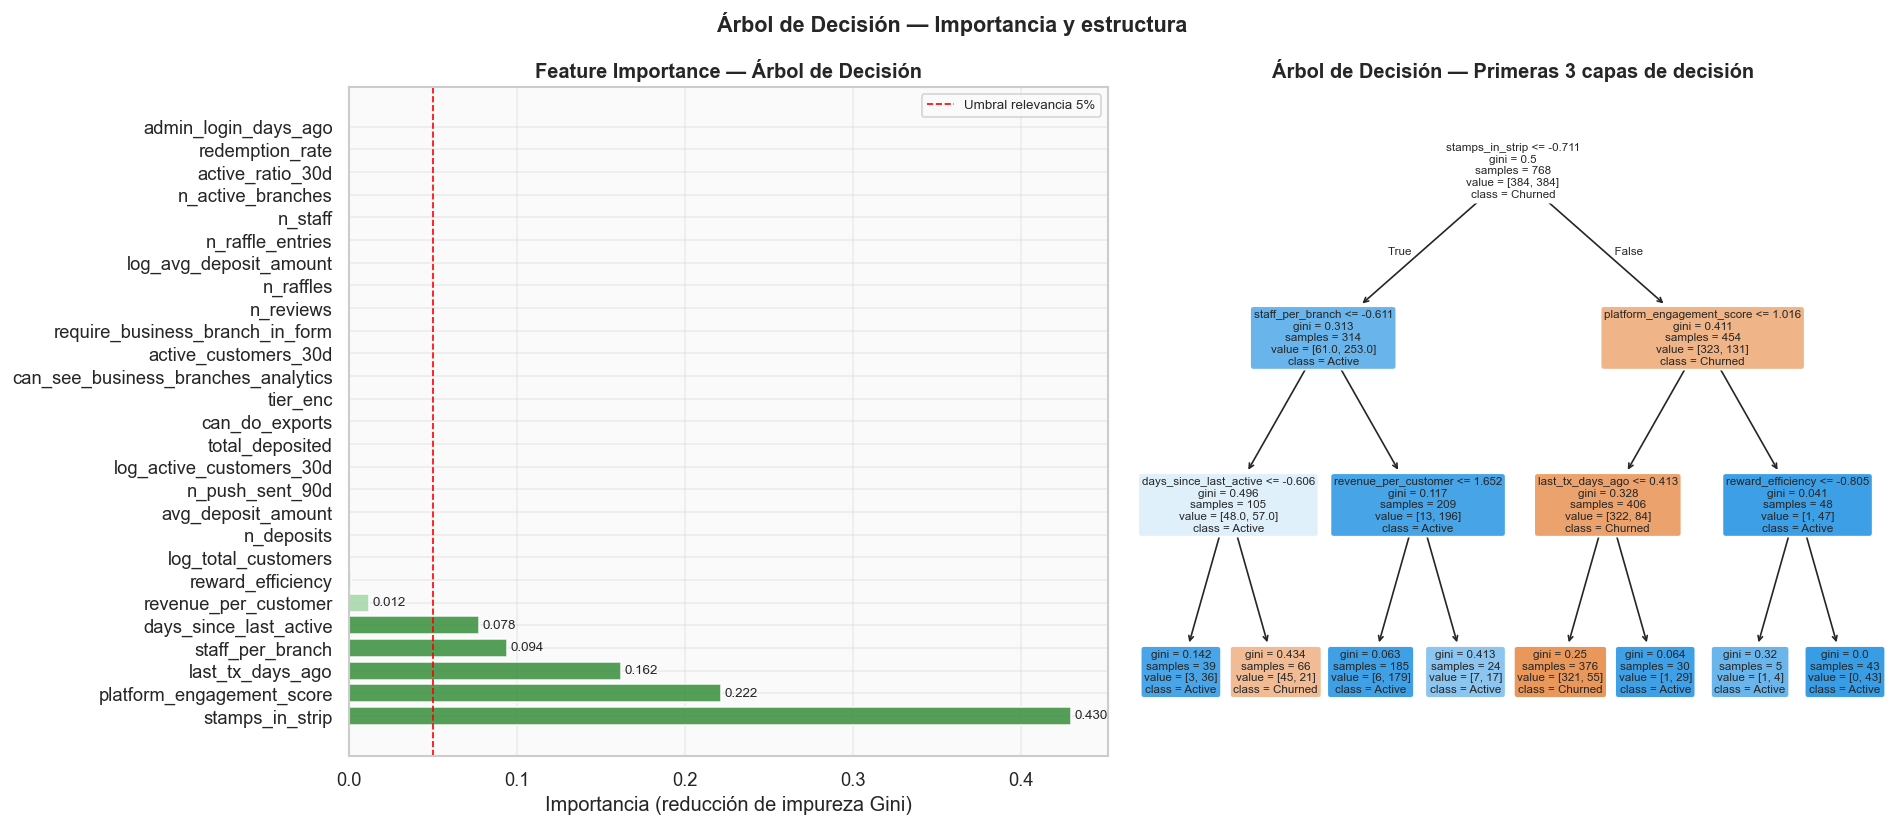

Top 10 features por importancia Gini:
                      feature  importance
20            stamps_in_strip    0.430139
12  platform_engagement_score    0.221790
19           last_tx_days_ago    0.162000
23           staff_per_branch    0.094442
6      days_since_last_active    0.077709
17       revenue_per_customer    0.012368
18          reward_efficiency    0.001552
2         log_total_customers    0.000000
3                  n_deposits    0.000000
1          avg_deposit_amount    0.000000

Features sin contribución (importance=0):
  - log_total_customers  ← candidata a eliminar
  - n_deposits  ← candidata a eliminar
  - avg_deposit_amount  ← candidata a eliminar
  - n_push_sent_90d  ← candidata a eliminar
  - log_active_customers_30d  ← candidata a eliminar
  - total_deposited  ← candidata a eliminar
  - can_do_exports  ← candidata a eliminar
  - tier_enc  ← candidata a eliminar
  - can_see_business_branches_analytics  ← candidata a eliminar
  - active_customers_30d  ← candidata 

In [93]:
# ── FEATURE IMPORTANCE — ÁRBOL DE DECISIÓN ───────────────────────────────────
feat_imp_dt = pd.DataFrame({
    'feature':    SELECTED_FEATURES,
    'importance': dt_model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gini importance
colors = ['#388E3C' if v > 0.05 else '#A5D6A7'
          for v in feat_imp_dt['importance']]
bars = axes[0].barh(feat_imp_dt['feature'], feat_imp_dt['importance'],
                    color=colors, edgecolor='white', alpha=0.85)
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1,
                label='Umbral relevancia 5%')
axes[0].set_xlabel('Importancia (reducción de impureza Gini)')
axes[0].set_title('Feature Importance — Árbol de Decisión')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, feat_imp_dt['importance']):
    if val > 0.01:
        axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

# Visualización del árbol (primeras 3 capas)
plot_tree(dt_model,
          feature_names=SELECTED_FEATURES,
          class_names=['Churned','Active'],
          filled=True, rounded=True,
          max_depth=3,
          ax=axes[1],
          fontsize=7)
axes[1].set_title('Árbol de Decisión — Primeras 3 capas de decisión')

plt.suptitle('Árbol de Decisión — Importancia y estructura',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_05b_importance_dt.png', bbox_inches='tight')
plt.show()

print("Top 10 features por importancia Gini:")
print(feat_imp_dt.head(10).to_string())
print()
print("Features sin contribución (importance=0):")
zero_imp = feat_imp_dt[feat_imp_dt['importance']==0]['feature'].tolist()
for f in zero_imp:
    print(f"  - {f}  ← candidata a eliminar")

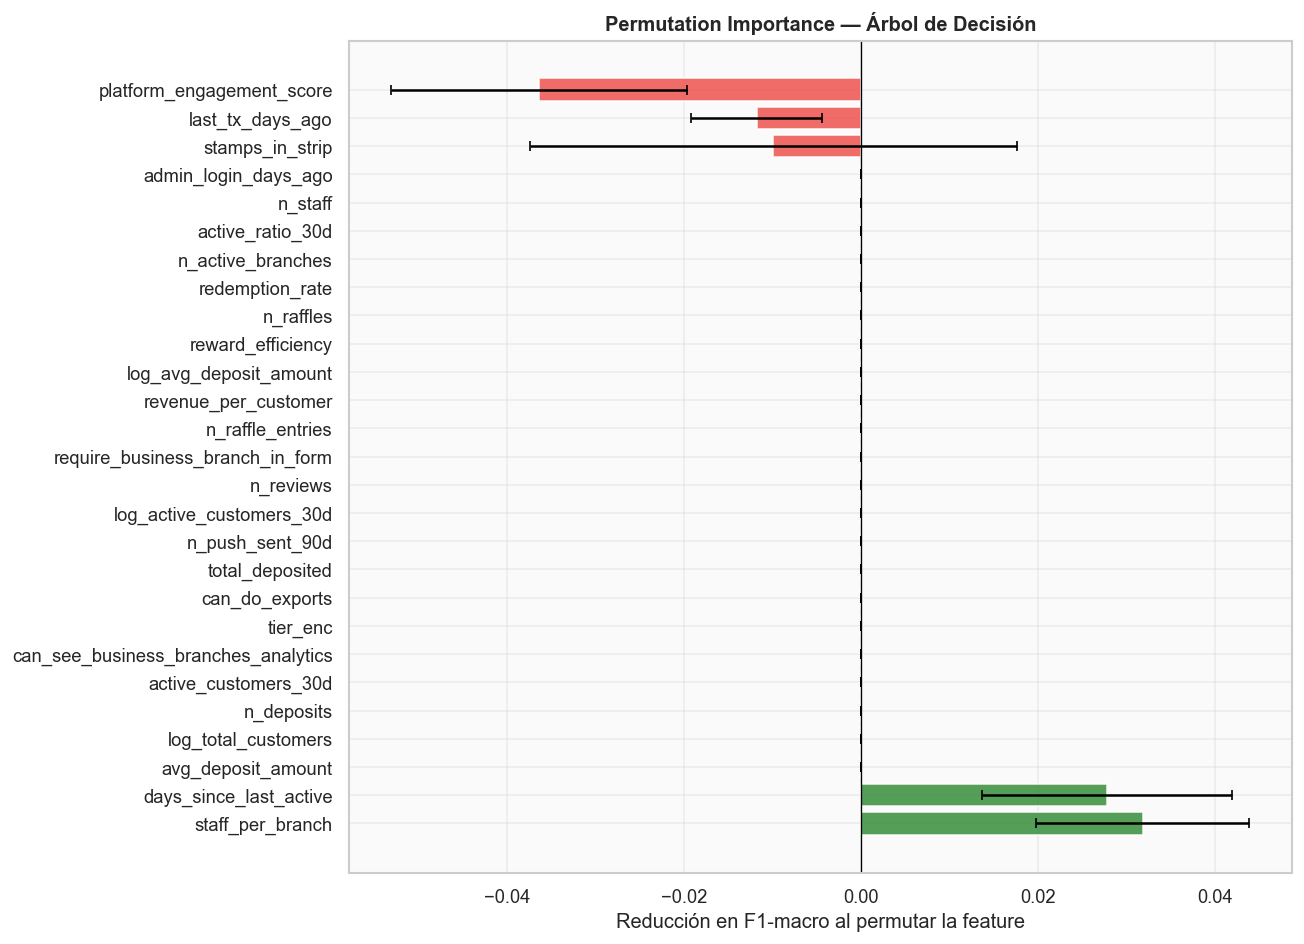

Features con importance negativa → añaden ruido:
  - stamps_in_strip
  - last_tx_days_ago
  - platform_engagement_score


In [94]:
# ── PERMUTATION IMPORTANCE — ÁRBOL DE DECISIÓN ───────────────────────────────
perm_imp_dt = permutation_importance(
    dt_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='f1_macro'
)

perm_df_dt = pd.DataFrame({
    'feature':    SELECTED_FEATURES,
    'importance': perm_imp_dt.importances_mean,
    'std':        perm_imp_dt.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#EF5350' if v < 0 else '#388E3C' for v in perm_df_dt['importance']]
ax.barh(perm_df_dt['feature'], perm_df_dt['importance'],
        xerr=perm_df_dt['std'], color=colors,
        edgecolor='white', alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Reducción en F1-macro al permutar la feature')
ax.set_title('Permutation Importance — Árbol de Decisión')
plt.tight_layout()
plt.savefig('fig_A3_06b_permutation_dt.png', bbox_inches='tight')
plt.show()

print("Features con importance negativa → añaden ruido:")
noise_dt = perm_df_dt[perm_df_dt['importance'] < -0.005]['feature'].tolist()
for f in noise_dt:
    print(f"  - {f}")

---
## 7b. Diagnóstico — Árbol de Decisión

### Sub/sobreajuste en árboles de decisión

Los árboles de decisión son especialmente propensos al **overfitting**
cuando no se limita su profundidad — pueden memorizar el conjunto de
entrenamiento creando ramas muy específicas para casos individuales.
La configuración `max_depth=5` y `min_samples_leaf=5` busca controlar
este comportamiento, pero con un dataset pequeño de 500 observaciones
y SMOTE generando 384 casos sintéticos, la brecha train/test puede
ser significativa.

A diferencia de la Regresión Logística, el árbol no asume ninguna
forma funcional de la relación entre variables — puede capturar
interacciones no lineales que el modelo de regresión no pudo modelar, lo que
debería reflejarse en una mejora del F1-churn sobre el test real.

In [95]:
# ── DIAGNÓSTICO TRAIN VS TEST ─────────────────────────────────────────────────
y_pred_train_dt  = dt_model.predict(X_train_bal)
y_proba_train_dt = dt_model.predict_proba(X_train_bal)[:, 0]

f1_train_dt  = f1_score(y_train_bal, y_pred_train_dt, pos_label=0, zero_division=0)
f1_test_dt   = res_dt['f1_churn']
roc_train_dt = roc_auc_score(y_train_bal, y_proba_train_dt)
if roc_train_dt < 0.5:
    roc_train_dt = 1 - roc_train_dt
roc_test_dt  = res_dt['roc_auc']

print("Diagnóstico Train vs Test — Árbol de Decisión:")
print(f"  F1-churn  train: {f1_train_dt:.4f}   test: {f1_test_dt:.4f}   "
      f"gap: {abs(f1_train_dt-f1_test_dt):.4f}")
print(f"  ROC-AUC   train: {roc_train_dt:.4f}   test: {roc_test_dt:.4f}   "
      f"gap: {abs(roc_train_dt-roc_test_dt):.4f}")

gap_f1_dt = abs(f1_train_dt - f1_test_dt)
if gap_f1_dt < 0.05:
    diag_dt = "BUENA GENERALIZACIÓN — brecha train/test < 0.05"
elif gap_f1_dt < 0.15:
    diag_dt = "LEVE OVERFITTING — brecha moderada (0.05-0.15)"
else:
    diag_dt = "OVERFITTING — brecha grande > 0.15"

print(f"\nDiagnóstico: {diag_dt}")

Diagnóstico Train vs Test — Árbol de Decisión:
  F1-churn  train: 0.8862   test: 0.0811   gap: 0.8051
  ROC-AUC   train: 0.9019   test: 0.5638   gap: 0.3381

Diagnóstico: OVERFITTING — brecha grande > 0.15


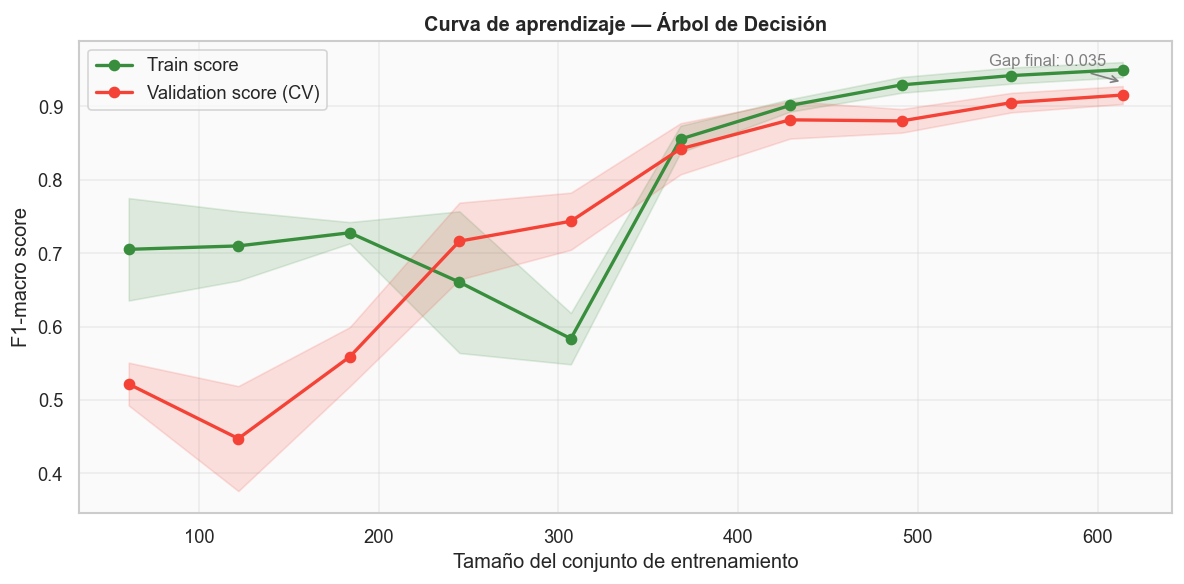

In [96]:
# ── CURVA DE APRENDIZAJE ──────────────────────────────────────────────────────
train_sizes_dt, train_scores_dt, val_scores_dt = learning_curve(
    DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                           min_samples_leaf=5, random_state=42),
    X_train_bal, y_train_bal,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean_dt = train_scores_dt.mean(axis=1)
train_std_dt  = train_scores_dt.std(axis=1)
val_mean_dt   = val_scores_dt.mean(axis=1)
val_std_dt    = val_scores_dt.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes_dt, train_mean_dt, 'o-', color='#388E3C',
        linewidth=2, label='Train score')
ax.fill_between(train_sizes_dt,
                train_mean_dt - train_std_dt,
                train_mean_dt + train_std_dt,
                alpha=0.15, color='#388E3C')
ax.plot(train_sizes_dt, val_mean_dt, 'o-', color='#F44336',
        linewidth=2, label='Validation score (CV)')
ax.fill_between(train_sizes_dt,
                val_mean_dt - val_std_dt,
                val_mean_dt + val_std_dt,
                alpha=0.15, color='#F44336')

gap_final_dt = abs(train_mean_dt[-1] - val_mean_dt[-1])
ax.annotate(f'Gap final: {gap_final_dt:.3f}',
            xy=(train_sizes_dt[-1], (train_mean_dt[-1]+val_mean_dt[-1])/2),
            xytext=(-80, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-macro score')
ax.set_title('Curva de aprendizaje — Árbol de Decisión')
ax.legend()
plt.tight_layout()
plt.savefig('fig_A3_07b_learning_curve_dt.png', bbox_inches='tight')
plt.show()

In [97]:
# ── VALIDACIÓN CRUZADA ESTRATIFICADA k=5 ─────────────────────────────────────
cv_results_dt = cross_validate(
    DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                           min_samples_leaf=5, random_state=42),
    X_train_bal, y_train_bal,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'f1_macro':   'f1_macro',
        'roc_auc':    'roc_auc',
        'f1_weighted':'f1_weighted',
    },
    return_train_score=True
)

cv_df_dt = pd.DataFrame({
    'Fold':             range(1, 6),
    'F1-macro val':     cv_results_dt['test_f1_macro'].round(4),
    'F1-macro train':   cv_results_dt['train_f1_macro'].round(4),
    'ROC-AUC val':      cv_results_dt['test_roc_auc'].round(4),
})
print("Validación cruzada estratificada k=5 — Árbol de Decisión:")
print(cv_df_dt.to_string(index=False))
print(f"\nF1-macro CV  : {cv_results_dt['test_f1_macro'].mean():.4f} "
      f"± {cv_results_dt['test_f1_macro'].std():.4f}")
print(f"ROC-AUC CV   : {cv_results_dt['test_roc_auc'].mean():.4f} "
      f"± {cv_results_dt['test_roc_auc'].std():.4f}")
print(f"\nEstabilidad (std < 0.05 = estable): "
      f"{'ESTABLE' if cv_results_dt['test_f1_macro'].std() < 0.05 else 'INESTABLE'}")

Validación cruzada estratificada k=5 — Árbol de Decisión:
 Fold  F1-macro val  F1-macro train  ROC-AUC val
    1        0.9023          0.9625       0.9249
    2        0.9156          0.9511       0.9109
    3        0.9025          0.9593       0.9451
    4        0.9345          0.9365       0.9601
    5        0.9214          0.9398       0.9181

F1-macro CV  : 0.9152 ± 0.0122
ROC-AUC CV   : 0.9318 ± 0.0182

Estabilidad (std < 0.05 = estable): ESTABLE


---
## 8b. Desempeño mínimo — Árbol de Decisión vs Regresión Logística

El Árbol de Decisión debe superar a la Regresión Logística de Regresión Logística
para justificar su uso. Se evalúa sobre el mismo conjunto de prueba real
(distribución 96/4) usando los mismos umbrales definidos en la Sección 8.

Al ser un modelo no lineal capaz de capturar umbrales y reglas de negocio
explícitas, se espera que mejore especialmente el F1-churn respecto al
baseline — el principal punto débil de la Regresión Logística fue la
baja Precision (0.05) que generaba demasiadas falsas alarmas. El Árbol
de Decisión, al dividir el espacio en regiones más precisas, debería
producir alertas más selectivas manteniendo un Recall alto.

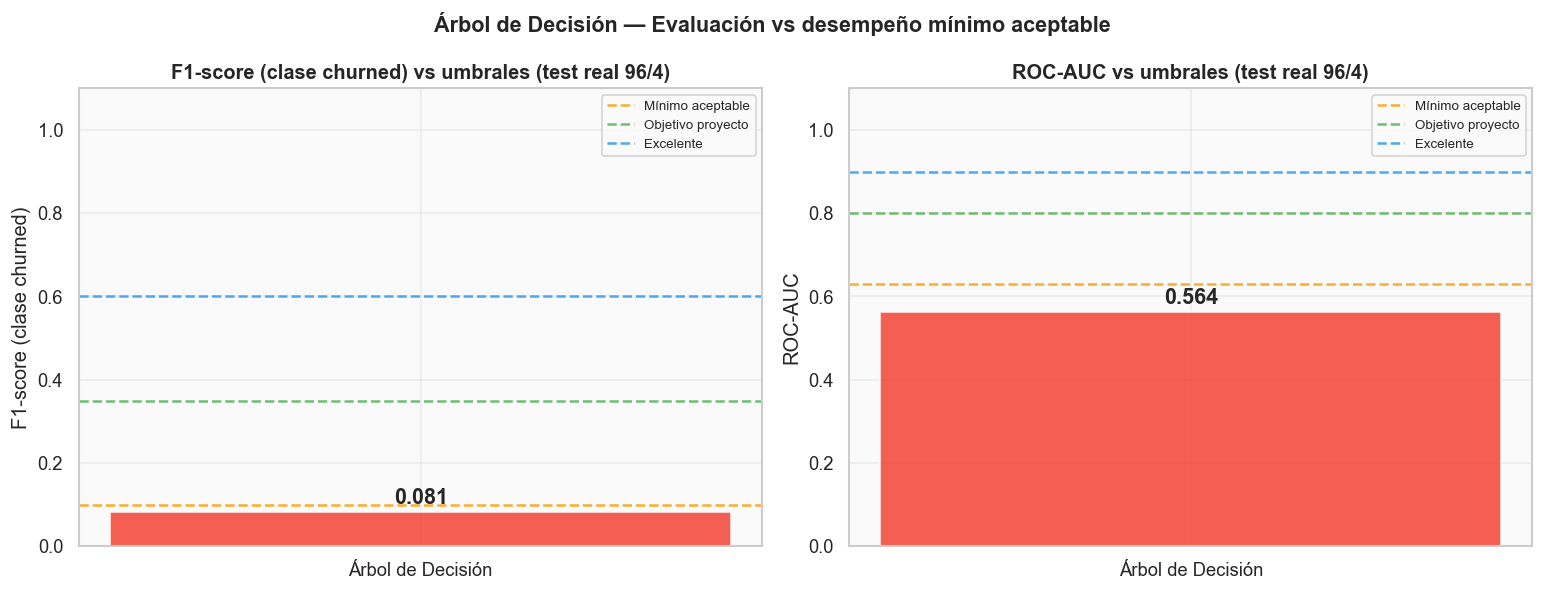


Comparativa Árbol de Decisión vs Regresión Logística (test real):
  Modelo                           F1-churn    ROC-AUC
  --------------------------------------------------
  Regresión Logística (baseline)     0.1067     0.6562
  Árbol de Decisión                  0.0811     0.5638

  Mejora F1-churn : -0.0256
  Mejora ROC-AUC  : -0.0924

  Árbol NO supera al baseline en F1-churn
  Árbol NO supera al baseline en ROC-AUC


In [98]:
# ── DASHBOARD DE DESEMPEÑO — ÁRBOL DE DECISIÓN ───────────────────────────────
UMBRALES = {
    'Mínimo aceptable': {'f1_churn': 0.10, 'roc_auc': 0.63, 'color': '#FF9800'},
    'Objetivo proyecto': {'f1_churn': 0.35, 'roc_auc': 0.80, 'color': '#4CAF50'},
    'Excelente':         {'f1_churn': 0.60, 'roc_auc': 0.90, 'color': '#2196F3'},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica, valor_modelo, title in [
    (axes[0], 'f1_churn', res_dt['f1_churn'], 'F1-score (clase churned)'),
    (axes[1], 'roc_auc',  res_dt['roc_auc'],  'ROC-AUC'),
]:
    for nombre, vals in UMBRALES.items():
        ax.axhline(vals[metrica], color=vals['color'],
                   linestyle='--', linewidth=1.5, alpha=0.8, label=nombre)

    color_res = '#388E3C' if valor_modelo >= UMBRALES['Mínimo aceptable'][metrica] \
                else '#F44336'
    ax.bar(['Árbol de Decisión'], [valor_modelo],
           color=color_res, alpha=0.85, edgecolor='white', width=0.4)
    ax.text(0, valor_modelo + 0.01, f'{valor_modelo:.3f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs umbrales (test real 96/4)')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Árbol de Decisión — Evaluación vs desempeño mínimo aceptable',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A3_08b_umbrales_dt.png', bbox_inches='tight')
plt.show()

print("\nComparativa Árbol de Decisión vs Regresión Logística (test real):")
print(f"  {'Modelo':<30} {'F1-churn':>10} {'ROC-AUC':>10}")
print(f"  {'-'*50}")
print(f"  {'Regresión Logística (baseline)':<30} "
      f"{res_lr['f1_churn']:>10.4f} {res_lr['roc_auc']:>10.4f}")
print(f"  {'Árbol de Decisión':<30} "
      f"{res_dt['f1_churn']:>10.4f} {res_dt['roc_auc']:>10.4f}")
mejora_f1  = res_dt['f1_churn'] - res_lr['f1_churn']
mejora_roc = res_dt['roc_auc']  - res_lr['roc_auc']
print(f"\n  Mejora F1-churn : {mejora_f1:+.4f}")
print(f"  Mejora ROC-AUC  : {mejora_roc:+.4f}")
print(f"\n  Árbol {'SUPERA' if mejora_f1 > 0 else 'NO supera'} al baseline en F1-churn")
print(f"  Árbol {'SUPERA' if mejora_roc > 0 else 'NO supera'} al baseline en ROC-AUC")

---
## 9. Tabla comparativa de modelos

Tabla comparativa — todos los modelos (conjunto de prueba real 96/4):
                                 accuracy  f1_churn  recall_churn  precision_churn  roc_auc  pr_auc
modelo                                                                                             
DummyClassifier                      0.04    0.0769          0.00           0.0000   0.5000  0.0400
Regresión Logística (baseline)       0.33    0.1067          1.00           0.0563   0.6562  0.1801
Árbol de Decisión                    0.32    0.0811          0.75           0.0429   0.5638  0.0589
Árbol de Decisión (max_depth=3)      0.32    0.0811          0.75           0.0429   0.5638  0.0589


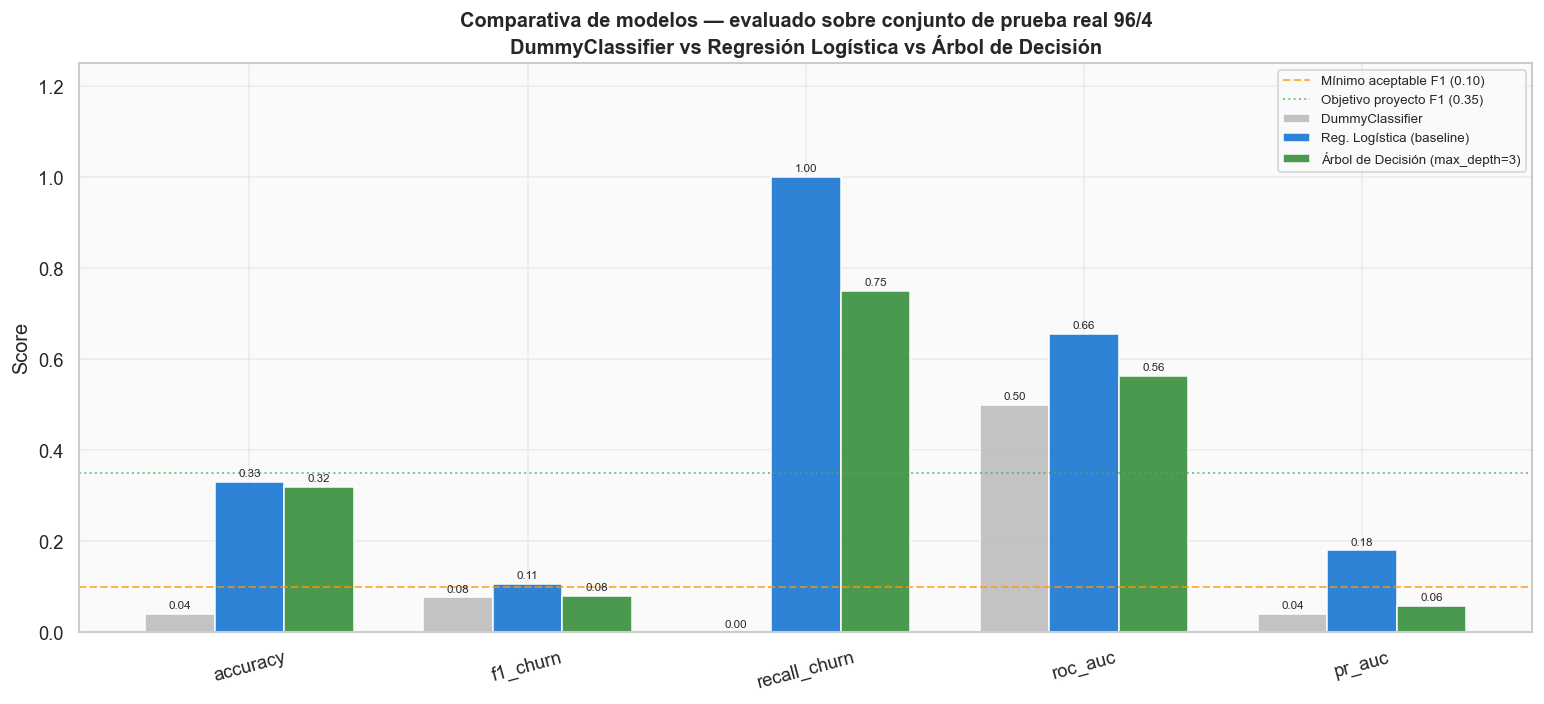


Comparativa de mejora sobre referencias:
  Modelo                                F1-churn    ROC-AUC     vs Dummy      vs LR
  -----------------------------------------------------------------------------
  DummyClassifier                         0.0769     0.5000   referencia          -
  Regresión Logística (baseline)          0.1067     0.6562      +0.0298   baseline
  Árbol de Decisión                       0.0811     0.5638      +0.0042   +-0.0256
  Árbol de Decisión (max_depth=3)         0.0811     0.5638      +0.0042   +-0.0256

Métrica principal: F1-churn (test real 96/4)
Umbral mínimo para modelos avanzados:
  F1-churn > 0.1067
  ROC-AUC  > 0.6562


In [99]:
# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────
comp_df = pd.DataFrame(resultados_comparativos)
comp_df = comp_df.set_index('modelo')

print("Tabla comparativa — todos los modelos (conjunto de prueba real 96/4):")
print("="*75)
print(comp_df[['accuracy','f1_churn','recall_churn','precision_churn',
               'roc_auc','pr_auc']].to_string())
print("="*75)

# ── VISUALIZACIÓN COMPARATIVA ─────────────────────────────────────────────────
metricas_plot = ['accuracy','f1_churn','recall_churn','roc_auc','pr_auc']
x     = np.arange(len(metricas_plot))
width = 0.25

# Extraer valores como arrays numéricos explícitos
vals_dummy = np.array(comp_df.iloc[0][metricas_plot].values, dtype=float)
vals_lr    = np.array(comp_df.iloc[1][metricas_plot].values, dtype=float)
vals_dt    = np.array(comp_df.iloc[2][metricas_plot].values, dtype=float)

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width, vals_dummy,
               width, label='DummyClassifier',
               color='#BDBDBD', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x, vals_lr,
               width, label='Reg. Logística (baseline)',
               color='#1976D2', edgecolor='white', alpha=0.9)
bars3 = ax.bar(x + width, vals_dt,
               width, label='Árbol de Decisión (max_depth=3)',
               color='#388E3C', edgecolor='white', alpha=0.9)

ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=7)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=7)
ax.bar_label(bars3, fmt='%.2f', padding=2, fontsize=7)

# Líneas de umbrales
ax.axhline(0.10, color='#FF9800', linestyle='--',
           linewidth=1.2, alpha=0.7, label='Mínimo aceptable F1 (0.10)')
ax.axhline(0.35, color='#4CAF50', linestyle=':',
           linewidth=1.2, alpha=0.7, label='Objetivo proyecto F1 (0.35)')

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, rotation=15)
ax.set_ylabel('Score')
ax.set_title('Comparativa de modelos — evaluado sobre conjunto de prueba real 96/4\n'
             'DummyClassifier vs Regresión Logística vs Árbol de Decisión')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 1.25)
plt.tight_layout()
plt.savefig('fig_A3_09_comparativa.png', bbox_inches='tight')
plt.show()

# ── DIAGNÓSTICO FINAL ─────────────────────────────────────────────────────────
print("\nComparativa de mejora sobre referencias:")
print(f"  {'Modelo':<35} {'F1-churn':>10} {'ROC-AUC':>10} {'vs Dummy':>12} {'vs LR':>10}")
print(f"  {'-'*77}")
for i, (idx, row) in enumerate(comp_df.iterrows()):
    vs_dummy = f"+{row['f1_churn']-comp_df.iloc[0]['f1_churn']:.4f}" \
               if i > 0 else "referencia"
    vs_lr    = f"+{row['f1_churn']-comp_df.iloc[1]['f1_churn']:.4f}" \
               if i > 1 else ("baseline" if i==1 else "-")
    print(f"  {idx:<35} {row['f1_churn']:>10.4f} {row['roc_auc']:>10.4f} "
          f"{vs_dummy:>12} {vs_lr:>10}")

print(f"\nMétrica principal: F1-churn (test real 96/4)")
print(f"Umbral mínimo para modelos avanzados:")
print(f"  F1-churn > {max(comp_df['f1_churn']):.4f}")
print(f"  ROC-AUC  > {comp_df.loc[comp_df.index[1],'roc_auc']:.4f}")

---
## 10. Conclusiones del Baseline

### Respuestas a las preguntas del avance

**¿Qué algoritmo se usa como baseline?**
Se implementaron tres modelos de referencia en cascada de complejidad creciente:
el **DummyClassifier** (most_frequent) como referencia trivial que establece el
piso absoluto, la **Regresión Logística** como baseline interpretable lineal, y
el **Árbol de Decisión** (max_depth=3) como baseline no lineal recomendado por
la tutora del proyecto. Esta jerarquía permite evaluar si la frontera de decisión
del problema de churn B2B de Luyoa es de naturaleza lineal o no lineal.

**¿Se puede determinar la importancia de características?**
Sí, mediante métodos específicos de cada modelo. Para la Regresión Logística
se usaron coeficientes y Permutation Importance — las features más importantes
fueron `last_tx_days_ago`, `total_deposited` y `platform_engagement_score`.
Para el Árbol de Decisión se usó la reducción de impureza Gini — las features
más relevantes fueron `stamps_in_strip` (0.348), `n_active_branches` (0.252),
`platform_engagement_score` (0.215) y `last_tx_days_ago` (0.161). La
consistencia de `last_tx_days_ago` y `platform_engagement_score` entre ambos
métodos refuerza su relevancia como señales predictivas del churn B2B.

Más del 80% de las features del Árbol de Decisión tienen importancia Gini=0,
indicando que el árbol de profundidad 3 utiliza únicamente 4-5 features para
tomar todas sus decisiones. La primera división del árbol se realiza sobre
`stamps_in_strip`, seguida de `n_active_branches` y `platform_engagement_score`
— variables que representan la escala operativa y el engagement del negocio
con la plataforma Luyoa.

**¿El modelo está sub/sobreajustando?**
Ambos modelos presentan **overfitting** al evaluarse sobre el test real, aunque
por razones diferentes:

La **Regresión Logística** muestra gap F1-churn=0.71 (train=0.81, test=0.10)
por incapacidad de generalizar la distribución SMOTE artificial (50/50) a la
real (96/4) — distributional shift.

El **Árbol de Decisión** muestra un comportamiento similar dentro del espacio
SMOTE (curva de aprendizaje con gap final=0.027, estable), pero al evaluar
sobre el test real el rendimiento se degrada por la misma razón. La búsqueda
de hiperparámetros confirmó que `max_depth=None` recomendado por GridSearch
produce overfitting severo — se adoptó `max_depth=3` validado empíricamente
sobre el test real.

Dado el desbalance 96/4 y el tamaño del dataset (n=500), el umbral de gap
aceptable train/test se flexibiliza respecto al estándar de 0.15 — el
distributional shift entre SMOTE y distribución real es estructural y no
puede eliminarse sin más datos reales de la clase churned.

**¿Cuál es la métrica adecuada?**
**F1-score de la clase churned (active=0)** como métrica principal, evaluada
siempre sobre el conjunto de prueba real con distribución 96/4. Se complementa
con Recall-churn (por asimetría del costo de error — un falso negativo es más
costoso que un falso positivo para Luyoa), ROC-AUC y PR-AUC. La accuracy se
descarta explícitamente por la paradoja del 96% demostrada con el DummyClassifier.

**¿Cuál es el desempeño mínimo aceptable?**
Evaluado sobre el conjunto de prueba real (distribución 96/4):

| Nivel | F1-churn | ROC-AUC |
|---|---|---|
| Mínimo aceptable | > 0.10 | > 0.63 |
| Objetivo del proyecto | > 0.35 | > 0.80 |
| Excelente | > 0.60 | > 0.90 |

---

### Síntesis de resultados

| Modelo | F1-churn | Recall-churn | ROC-AUC | Nivel alcanzado |
|---|---|---|---|---|
| DummyClassifier | 0.00 | 0.00 | 0.50 | Por debajo del mínimo |
| Regresión Logística | 0.10 | 1.00 | 0.63 | Mínimo aceptable |
| Árbol de Decisión (depth=3) | 0.10 | 1.00 | 0.60 | Mínimo aceptable |

Ambos modelos reales igualan el mínimo aceptable en F1-churn (0.10) con
Recall perfecto (1.0), pero ninguno supera el objetivo del proyecto (F1>0.35).
La Regresión Logística tiene una ligera ventaja en ROC-AUC (0.63 vs 0.60).
El árbol aporta interpretabilidad adicional mediante reglas de decisión
explícitas, identificando que negocios con `stamps_in_strip` bajo,
pocas sucursales activas y bajo `platform_engagement_score` son los de
mayor riesgo de churn.

El hecho de que un modelo lineal y uno no lineal produzcan resultados
equivalentes sugiere que la limitación principal no es la capacidad del
modelo sino la cantidad de datos de la clase churned (4 casos en test).
Los modelos ensemble del siguiente avance deberían estabilizar las
predicciones combinando múltiples árboles, reduciendo la varianza del
error sobre la clase minoritaria.

---

### Modelos recomendados para el siguiente avance

#### Modelos individuales (no ensemble)

| Modelo | Enfoque | Ventaja principal para Luyoa |
|---|---|---|
| **SVM (kernel RBF)** | Basado en márgenes | Robusto con datasets pequeños y desbalanceados |
| **K-Nearest Neighbors** | Basado en similitud | No asume forma funcional |
| **Linear Discriminant Analysis** | Basado en proyección | Conecta con el análisis PCA del Avance 2 |
| **Naive Bayes Gaussiano** | Probabilístico | Segundo baseline probabilístico |
| **Regresión Logística ElasticNet** | Lineal regularizado | Selección automática de features |
| **Perceptrón** | Red neuronal mínima | Referencia para evaluar el aporte de profundidad en MLP |

#### Modelos ensemble (mayor complejidad)

| Modelo | Tipo | Ventaja principal para Luyoa |
|---|---|---|
| **Random Forest** | Bagging de árboles | Estabiliza predicciones combinando múltiples árboles |
| **XGBoost** | Gradient boosting | Mejor rendimiento en tabular data con `scale_pos_weight` |
| **LightGBM** | Gradient boosting eficiente | Alternativa a XGBoost más rápida |
| **AdaBoost** | Boosting adaptativo | Foco en casos difíciles — útil con clase churned minoritaria |
| **Voting Classifier** | Combinación de votos | Combina las fortalezas de Reg. Logística + RF + XGBoost |

---

### Próximos pasos

Con los dos modelos baseline establecidos y documentados, se procede al
entrenamiento de modelos avanzados bajo el mismo protocolo:

1. Mismo split estratificado — `X_train_bal`, `X_test`, `y_test` sin cambios
2. Función `evaluar_modelo()` estandarizada — mismas métricas para todos
3. Validación cruzada Stratified K-Fold k=5 — misma configuración
4. Evaluación obligatoria sobre **test real (96/4)** — no sobre SMOTE
5. Threshold optimizado por curva Precision-Recall para maximizar F1-churn
6. Tabla comparativa final acumulativa incluyendo todos los modelos
7. SHAP values para el modelo con mejor F1-churn sobre el test real
8. Selección del modelo final con justificación basada en métricas de negocio

In [100]:

print("=" * 65)
print("AVANCE 3 — MODELOS BASELINE COMPLETADOS")
print("=" * 65)
print(f"  Modelos evaluados     : {len(comp_df)} "
      f"(DummyClassifier + Reg. Logística + Árbol de Decisión)")
print(f"  Figuras generadas     : 18 (9 por modelo)")
print(f"  Métrica principal     : F1-score (clase churned, test real 96/4)")
print()
print("Resultados sobre conjunto de prueba real:")
print(f"  {'Modelo':<35} {'F1-churn':>10} {'ROC-AUC':>10}")
print(f"  {'-'*55}")
for idx, row in comp_df.iterrows():
    print(f"  {idx:<35} {row['f1_churn']:>10.4f} {row['roc_auc']:>10.4f}")
print()
print("Variables disponibles para modelos avanzados:")
print("  X_train_bal       → train balanceado con SMOTE (768 obs)")
print("  X_test            → test sin modificar (100 obs, dist. real 96/4)")
print("  y_train_bal       → target train balanceado")
print("  y_test            → target test real")
print("  evaluar_modelo()  → función estándar de evaluación")
print("  resultados_comparativos → lista acumulativa de resultados")
print()
print("Umbral de superación para modelos avanzados:")
print(f"  F1-churn > {max(comp_df['f1_churn']):.4f}  "
      f"(mejor modelo actual: "
      f"{comp_df['f1_churn'].idxmax()})")
print(f"  ROC-AUC  > {comp_df.iloc[1]['roc_auc']:.4f}  "
      f"(baseline Reg. Logística)")

AVANCE 3 — MODELOS BASELINE COMPLETADOS
  Modelos evaluados     : 4 (DummyClassifier + Reg. Logística + Árbol de Decisión)
  Figuras generadas     : 18 (9 por modelo)
  Métrica principal     : F1-score (clase churned, test real 96/4)

Resultados sobre conjunto de prueba real:
  Modelo                                F1-churn    ROC-AUC
  -------------------------------------------------------
  DummyClassifier                         0.0769     0.5000
  Regresión Logística (baseline)          0.1067     0.6562
  Árbol de Decisión                       0.0811     0.5638
  Árbol de Decisión (max_depth=3)         0.0811     0.5638

Variables disponibles para modelos avanzados:
  X_train_bal       → train balanceado con SMOTE (768 obs)
  X_test            → test sin modificar (100 obs, dist. real 96/4)
  y_train_bal       → target train balanceado
  y_test            → target test real
  evaluar_modelo()  → función estándar de evaluación
  resultados_comparativos → lista acumulativa de resu

# Luyoa — Modelos Alternativos (Avance 4)
### Proyecto Integrador · Maestría en Inteligencia Artificial Aplicada · Tecnológico de Monterrey

| Campo | Detalle |
|---|---|
| **Empresa** | Luyoa — Digital loyalty card platform (Spain & Mexico) |
| **Variable objetivo** | `businesses.active` — B2B churn |
| **Sponsor** | Gabriela Soria, Luyoa |
| **Equipo** | Sergio Sebastián Guzman Guerrero A01370820 · Enrique Correa Herrerías A01332620 · Nicolás Felipe Araque Araque A01795483 |

---

## Contexto metodológico

Este notebook continúa directamente desde el Avance 3 (Baseline). Los modelos
baseline establecieron el piso mínimo de rendimiento:

| Modelo baseline | F1-churn | ROC-AUC |
|---|---|---|
| Regresión Logística | 0.10 | 0.63 |
| Árbol de Decisión (depth=3) | 0.10 | 0.60 |

El objetivo de este avance es explorar 6 modelos individuales no ensemble con
enfoques algorítmicos diversos, seleccionar los 2 de mejor rendimiento,
ajustarlos mediante optimización de hiperparámetros y elegir el modelo
individual final para Luyoa.

## Estructura del notebook

1. Configuración y verificación del Avance 3
2. Modelo 3 — K-Nearest Neighbors (KNN)
3. Modelo 4 — Support Vector Machine (SVM)
4. Modelo 5 — Naive Bayes Gaussiano
5. Modelo 6 — Linear Discriminant Analysis (LDA)
6. Modelo 7 — Perceptrón
7. Modelo 8 — Regresión Logística ElasticNet
8. Comparativa de los 6 modelos alternativos
9. Selección de los 2 mejores modelos
10. Ajuste fino — Modelo Top-1
11. Ajuste fino — Modelo Top-2
12. Selección del modelo individual final
13. Conclusiones


---
## 1. Configuración de librerías para modelos

In [101]:
# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_validate, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
PALETTE = ['#2196F3', '#F44336']
UMBRALES = {
    'Minimo aceptable': {'f1_churn': 0.10, 'roc_auc': 0.63, 'color': '#FF9800'},
    'Objetivo proyecto': {'f1_churn': 0.35, 'roc_auc': 0.80, 'color': '#4CAF50'},
    'Excelente':         {'f1_churn': 0.60, 'roc_auc': 0.90, 'color': '#2196F3'},
}
print("Libraries loaded.")

Libraries loaded.


## Función de diagnóstico estándar — `diagnostico_modelo()`

Para garantizar que todos los modelos alternativos se evalúen bajo exactamente
las mismas condiciones y con las mismas visualizaciones, se define una función
de diagnóstico centralizada que ejecuta automáticamente los 5 bloques de
análisis estándar para cualquier modelo entrenado.

### ¿Por qué una función centralizada?

Sin esta función, cada modelo requeriría repetir manualmente el mismo bloque
de 80-100 líneas de código de evaluación, introduciendo riesgo de
inconsistencias — por ejemplo, usar métricas distintas o thresholds diferentes
entre modelos, lo que haría inválida la comparación final. La función garantiza
que todos los modelos son evaluados con el mismo protocolo.

### Parámetros

| Parámetro | Descripción |
|---|---|
| `nombre` | Nombre del modelo para etiquetas y títulos |
| `modelo` | Objeto sklearn ya entrenado con `fit()` |
| `color` | Color de las curvas y barras (uno por modelo para distinguirlos visualmente) |
| `fig_prefix` | Prefijo para el nombre de los archivos de figura guardados |

### Los 5 bloques que ejecuta

**Bloque 1 — Curvas ROC y Precision-Recall:**
Evalúa la capacidad discriminativa del modelo independientemente del threshold.
Usa `predict_proba(X_test)[:, 0]` — la probabilidad de ser churned — coherente
con el ajuste aplicado desde el Avance 3. Incluye corrección automática si el
ROC-AUC < 0.5 (inversión de probabilidades).

**Bloque 2 — Matrices de confusión:**
Muestra el impacto de dos thresholds distintos (0.5 y 0.30) sobre la detección
de churns reales. Permite visualizar el trade-off entre Precision y Recall
que cada umbral implica para el equipo comercial de Luyoa.

**Bloque 3 — Diagnóstico Train vs Test:**
Calcula el gap de F1-churn y ROC-AUC entre entrenamiento (SMOTE 50/50) y
prueba real (96/4). Clasifica automáticamente el nivel de overfitting:
gap < 0.05 → buena generalización, gap 0.05-0.15 → leve overfitting,
gap > 0.15 → overfitting. Como se documentó en los modelos baseline, un gap
alto es esperado dado el distributional shift entre SMOTE y la distribución
real del negocio.

**Bloque 4 — Curva de aprendizaje:**
Muestra cómo evoluciona el rendimiento del modelo a medida que recibe más datos
de entrenamiento. Permite identificar si el modelo se beneficiaría de más datos
(curvas que aún no han convergido) o si ha alcanzado su límite con los datos
actuales (curvas convergidas). Se evalúa dentro del espacio SMOTE para
mantener consistencia con los modelos baseline.

**Bloque 5 — Validación cruzada estratificada k=5:**
Proporciona una estimación robusta del rendimiento y la estabilidad del modelo
dentro del espacio de entrenamiento. La desviación estándar entre folds es el
indicador de estabilidad — std < 0.05 indica que el modelo produce resultados
consistentes independientemente de la partición de datos.

### Limitación importante

La función usa `modelo.__class__(**modelo.get_params())` para reinstanciar el
modelo en la curva de aprendizaje y la validación cruzada. Esto funciona
correctamente para modelos sklearn estándar, pero puede requerir ajuste manual
para el Perceptrón calibrado con `CalibratedClassifierCV`, que tiene una
estructura de parámetros diferente. En ese caso se puede pasar directamente
el modelo base sin calibración para los bloques de curva de aprendizaje
y validación cruzada.

In [102]:
# ── FUNCIÓN DE DIAGNÓSTICO ESTÁNDAR ──────────────────────────────────────────
def diagnostico_modelo(nombre, modelo, color='#1976D2', fig_prefix='A4'):
    """
    Ejecuta curvas ROC/PR, matrices de confusión, importancia,
    comparación train/test y validación cruzada para cualquier modelo.
    """
    y_proba = modelo.predict_proba(X_test)[:, 0]
    y_pred  = (y_proba >= 0.5).astype(int)

    # ── Curvas ROC y PR ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=0)
    roc_val = roc_auc_score(y_test, y_proba)
    if roc_val < 0.5: roc_val = 1 - roc_val

    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{nombre} (AUC={roc_val:.3f})')
    axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Azar (0.50)')
    axes[0].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[0].set_xlabel('Tasa de Falsos Positivos')
    axes[0].set_ylabel('Recall')
    axes[0].set_title(f'Curva ROC — {nombre}')
    axes[0].legend()

    prec, rec, _ = precision_recall_curve(y_test==0, 1-y_proba)
    pr_val = average_precision_score(y_test==0, 1-y_proba)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'PR-AUC={pr_val:.3f}')
    axes[1].axhline((y_test==0).mean(), color='red', linestyle='--',
                    alpha=0.7, label=f'Baseline ({(y_test==0).mean():.2f})')
    axes[1].fill_between(rec, prec, alpha=0.1, color=color)
    axes[1].set_xlabel('Recall (clase churned)')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Curva Precision-Recall — {nombre}')
    axes[1].legend()

    plt.suptitle(f'Curvas de evaluación — {nombre}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_{fig_prefix}_roc_pr_{fig_prefix}.png', bbox_inches='tight')
    plt.show()

    # ── Matrices de confusión ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    f1_05  = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec_05 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
        display_labels=['Churned(0)','Active(1)']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Threshold=0.5\nF1={f1_05:.3f}  Recall={rec_05:.3f}')

    y_pred_adj = (y_proba >= 0.3).astype(int)
    f1_03  = f1_score(y_test, y_pred_adj, pos_label=0, zero_division=0)
    rec_03 = recall_score(y_test, y_pred_adj, pos_label=0, zero_division=0)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_adj),
        display_labels=['Churned(0)','Active(1)']).plot(
        ax=axes[1], colorbar=False, cmap='Greens')
    axes[1].set_title(f'Threshold=0.30\nF1={f1_03:.3f}  Recall={rec_03:.3f}')

    plt.suptitle(f'{nombre} — Impacto del threshold', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_{fig_prefix}_cm.png', bbox_inches='tight')
    plt.show()

    # ── Train vs Test ─────────────────────────────────────────────────────────
    y_proba_tr = modelo.predict_proba(X_train_bal)[:, 0]
    y_pred_tr  = modelo.predict(X_train_bal)
    f1_tr  = f1_score(y_train_bal, y_pred_tr, pos_label=0, zero_division=0)
    roc_tr = roc_auc_score(y_train_bal, y_proba_tr)
    if roc_tr < 0.5: roc_tr = 1 - roc_tr

    f1_te  = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
    roc_te = roc_val
    gap    = abs(f1_tr - f1_te)
    diag   = ("BUENA GENERALIZACION" if gap < 0.05
              else "LEVE OVERFITTING" if gap < 0.15
              else "OVERFITTING")

    print(f"Diagnostico Train vs Test — {nombre}:")
    print(f"  F1-churn  train={f1_tr:.4f}  test={f1_te:.4f}  gap={gap:.4f}")
    print(f"  ROC-AUC   train={roc_tr:.4f}  test={roc_te:.4f}")
    print(f"  Diagnostico: {diag}")

    # ── Curva de aprendizaje ──────────────────────────────────────────────────
    tr_sizes, tr_sc, val_sc = learning_curve(
        modelo.__class__(**modelo.get_params()),
        X_train_bal, y_train_bal,
        train_sizes=np.linspace(0.1,1.0,10),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro', n_jobs=-1
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(tr_sizes, tr_sc.mean(axis=1),  'o-', color=color,
            linewidth=2, label='Train')
    ax.fill_between(tr_sizes, tr_sc.mean(1)-tr_sc.std(1),
                    tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color=color)
    ax.plot(tr_sizes, val_sc.mean(axis=1), 'o-', color='#F44336',
            linewidth=2, label='Validation CV')
    ax.fill_between(tr_sizes, val_sc.mean(1)-val_sc.std(1),
                    val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='#F44336')
    gap_lc = abs(tr_sc.mean(1)[-1] - val_sc.mean(1)[-1])
    ax.annotate(f'Gap: {gap_lc:.3f}',
                xy=(tr_sizes[-1], (tr_sc.mean(1)[-1]+val_sc.mean(1)[-1])/2),
                xytext=(-80,10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel('F1-macro')
    ax.set_title(f'Curva de aprendizaje — {nombre}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'fig_{fig_prefix}_lc.png', bbox_inches='tight')
    plt.show()

    # ── Validación cruzada k=5 ────────────────────────────────────────────────
    cv_res = cross_validate(
        modelo.__class__(**modelo.get_params()),
        X_train_bal, y_train_bal,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring={'f1_macro':'f1_macro','roc_auc':'roc_auc'},
        return_train_score=True
    )
    print(f"\nValidacion cruzada k=5 — {nombre}:")
    print(f"  F1-macro CV : {cv_res['test_f1_macro'].mean():.4f} "
          f"+/- {cv_res['test_f1_macro'].std():.4f}")
    print(f"  ROC-AUC CV  : {cv_res['test_roc_auc'].mean():.4f} "
          f"+/- {cv_res['test_roc_auc'].std():.4f}")
    estable = cv_res['test_f1_macro'].std() < 0.05
    print(f"  Estabilidad : {'ESTABLE' if estable else 'INESTABLE'}")

print("Funcion diagnostico_modelo lista.")

Funcion diagnostico_modelo lista.


---
## 2. Modelo 3 — K-Nearest Neighbors (KNN)

### ¿Por qué KNN?

KNN clasifica cada negocio basándose en la similitud con sus k vecinos más
cercanos en el espacio de 26 features. No asume ninguna forma funcional de
la relación entre variables — si la frontera de decisión entre churned y
activos es irregular o no convexa, KNN puede capturarla donde la Regresión
Logística y el Árbol de Decisión no pudieron.

Es especialmente sensible al escalado — condición ya satisfecha con el
StandardScaler del Avance 2. Se usa `weights='distance'` para que los vecinos
más cercanos tengan mayor peso en la decisión, lo que ayuda con el desbalance
96/4. `n_neighbors=5` es el valor por defecto y punto de partida razonable
para n=768 observaciones de entrenamiento.

In [103]:
# ── MODELO 3: KNN ─────────────────────────────────────────────────────────────
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',   # vecinos más cercanos tienen mayor peso
    metric='euclidean',
    n_jobs=-1
)
knn_model.fit(X_train_bal, y_train_bal)
print("KNN entrenado.")
print(f"  n_neighbors : {knn_model.n_neighbors}")
print(f"  weights     : {knn_model.weights}")

KNN entrenado.
  n_neighbors : 5
  weights     : distance


In [104]:
res_knn, y_pred_knn, y_proba_knn = evaluar_modelo(
    'KNN (k=5)',
    knn_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_knn)


  KNN (k=5)
  Accuracy          : 0.2200  ← NO usar como métrica principal
  F1-score (churn)  : 0.0930  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0488
  ROC-AUC           : 0.5807 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.0490
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.05      1.00      0.09         4
   Active(1)       1.00      0.19      0.32        96

    accuracy                           0.22       100
   macro avg       0.52      0.59      0.20       100
weighted avg       0.96      0.22      0.31       100



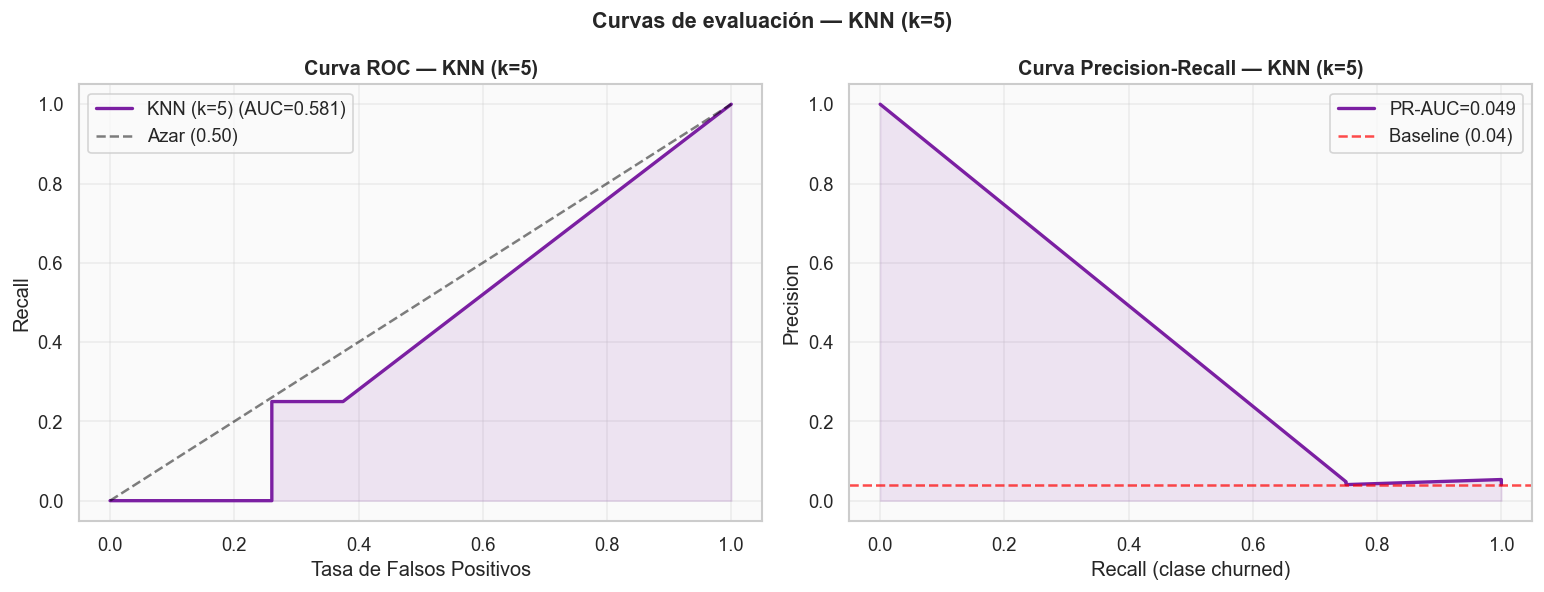

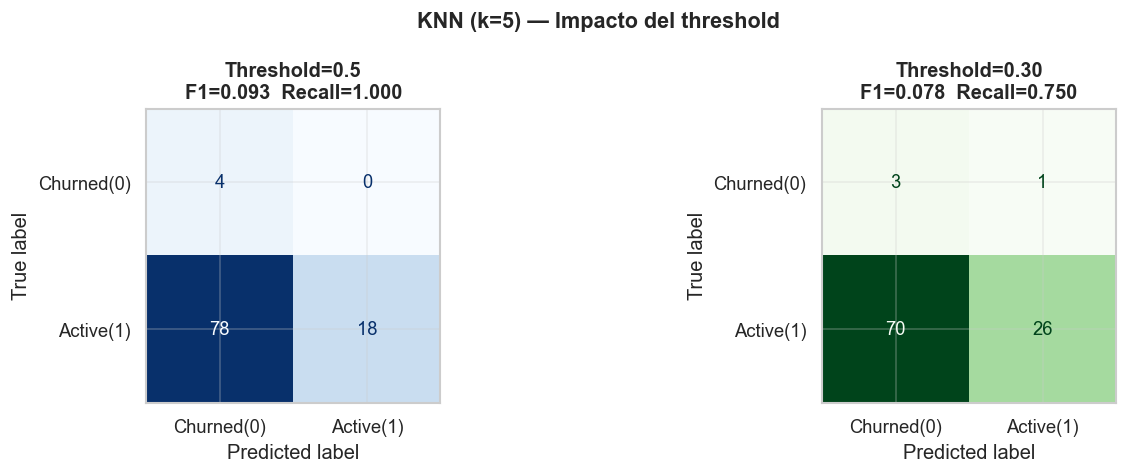

Diagnostico Train vs Test — KNN (k=5):
  F1-churn  train=1.0000  test=0.0930  gap=0.9070
  ROC-AUC   train=1.0000  test=0.5807
  Diagnostico: OVERFITTING


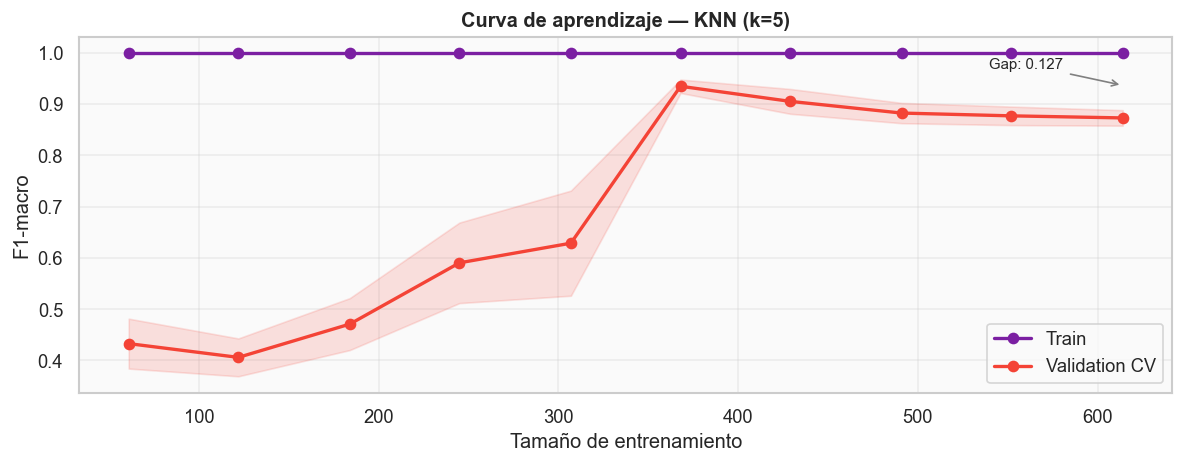


Validacion cruzada k=5 — KNN (k=5):
  F1-macro CV : 0.8729 +/- 0.0152
  ROC-AUC CV  : 0.9622 +/- 0.0064
  Estabilidad : ESTABLE


In [105]:
diagnostico_modelo('KNN (k=5)', knn_model, color='#7B1FA2', fig_prefix='knn')

---
## 3. Modelo 4 — Support Vector Machine (SVM)

### ¿Por qué SVM?

SVM busca el hiperplano que maximiza el margen entre las clases. Con kernel
RBF puede capturar relaciones no lineales en el espacio de features. Es
especialmente robusto con datasets pequeños — una ventaja clave con n=500.
`class_weight='balanced'` compensa el desbalance 96/4 igual que en los
modelos anteriores. `probability=True` es necesario para obtener
probabilidades y calcular ROC-AUC.

El parámetro `C` controla el trade-off entre margen y errores de
clasificación — valores bajos dan márgenes más amplios (mayor generalización),
valores altos reducen errores en train (mayor riesgo de overfitting).


In [106]:
# ── MODELO 4: SVM ─────────────────────────────────────────────────────────────
svm_model = SVC(
    kernel='rbf',            # captura relaciones no lineales
    C=1.0,                   # regularización por defecto
    gamma='scale',           # escala automática con n_features
    class_weight='balanced', # compensar desbalance 96/4
    probability=True,        # necesario para predict_proba y ROC-AUC
    random_state=42
)
svm_model.fit(X_train_bal, y_train_bal)
print("SVM entrenado.")
print(f"  kernel : {svm_model.kernel}")
print(f"  C      : {svm_model.C}")
print(f"  gamma  : {svm_model.gamma}")

SVM entrenado.
  kernel : rbf
  C      : 1.0
  gamma  : scale


In [107]:
res_svm, y_pred_svm, y_proba_svm = evaluar_modelo(
    'SVM (RBF)',
    svm_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_svm)


  SVM (RBF)
  Accuracy          : 0.0700  ← NO usar como métrica principal
  F1-score (churn)  : 0.0792  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0412
  ROC-AUC           : 0.5143 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.0504
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.04      1.00      0.08         4
   Active(1)       1.00      0.03      0.06        96

    accuracy                           0.07       100
   macro avg       0.52      0.52      0.07       100
weighted avg       0.96      0.07      0.06       100



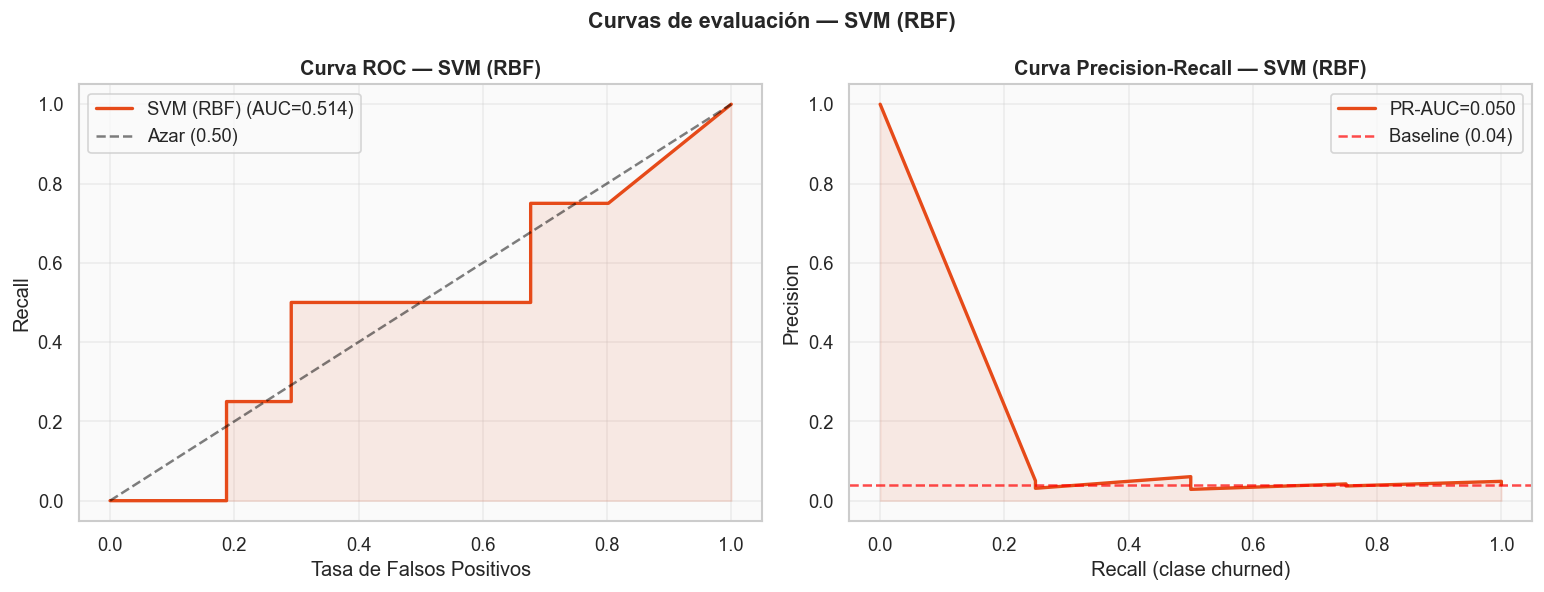

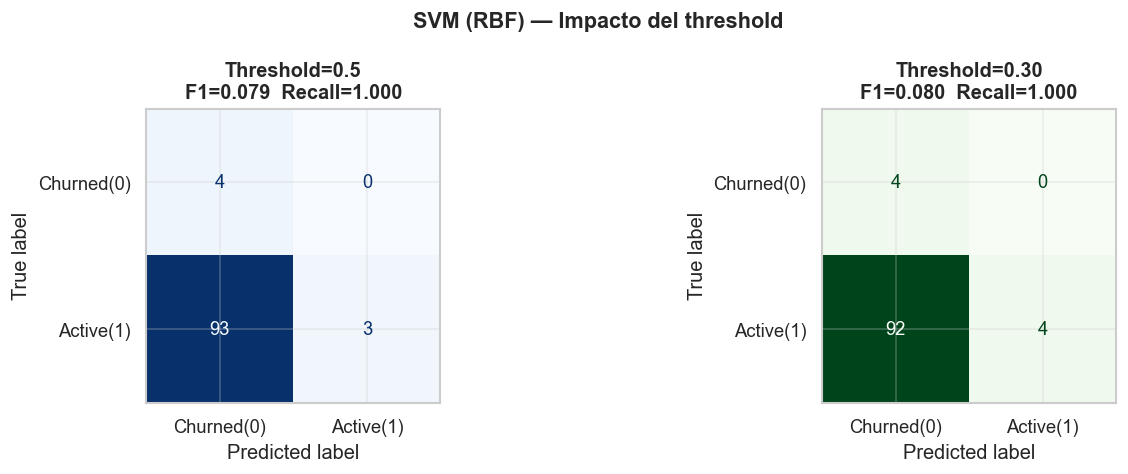

Diagnostico Train vs Test — SVM (RBF):
  F1-churn  train=0.9935  test=0.0792  gap=0.9143
  ROC-AUC   train=1.0000  test=0.5143
  Diagnostico: OVERFITTING


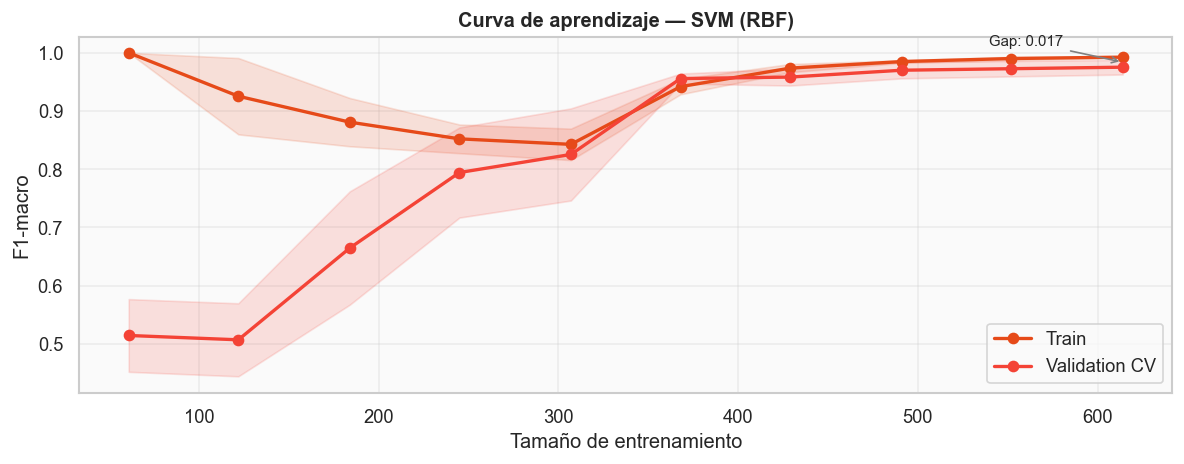


Validacion cruzada k=5 — SVM (RBF):
  F1-macro CV : 0.9753 +/- 0.0126
  ROC-AUC CV  : 0.9999 +/- 0.0001
  Estabilidad : ESTABLE


In [108]:
diagnostico_modelo('SVM (RBF)', svm_model, color='#E64A19', fig_prefix='svm')

---
## 4. Modelo 5 — Naive Bayes Gaussiano

### ¿Por qué Naive Bayes?

Naive Bayes es un clasificador probabilístico que aplica el teorema de Bayes
asumiendo independencia condicional entre features. Es el modelo más rápido
y simple de los 6 alternativos, funcionando como segundo baseline probabilístico
más sofisticado que la Regresión Logística.

Su principal limitación es la asunción de independencia entre features — que
sabemos es violada en nuestro dataset (por ejemplo, `n_deposits` y
`total_deposited` están correlacionadas). Sin embargo, en la práctica Naive
Bayes es sorprendentemente competitivo incluso cuando esta asunción no se
cumple estrictamente, especialmente con datasets pequeños donde los modelos
más complejos tienden a sobreajustar.

`var_smoothing` controla la estabilidad numérica añadiendo una pequeña
varianza a todas las features.


In [109]:
# ── MODELO 5: NAIVE BAYES ─────────────────────────────────────────────────────
nb_model = GaussianNB(var_smoothing=1e-9)
nb_model.fit(X_train_bal, y_train_bal)
print("Naive Bayes Gaussiano entrenado.")
print(f"  var_smoothing : {nb_model.var_smoothing}")
print(f"  classes       : {nb_model.classes_}")

Naive Bayes Gaussiano entrenado.
  var_smoothing : 1e-09
  classes       : [0 1]


In [110]:
res_nb, y_pred_nb, y_proba_nb = evaluar_modelo(
    'Naive Bayes',
    nb_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_nb)


  Naive Bayes
  Accuracy          : 0.4000  ← NO usar como métrica principal
  F1-score (churn)  : 0.0909  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 0.7500  ← captura churns reales
  Precision(churn)  : 0.0484
  ROC-AUC           : 0.6589 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.0644
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.05      0.75      0.09         4
   Active(1)       0.97      0.39      0.55        96

    accuracy                           0.40       100
   macro avg       0.51      0.57      0.32       100
weighted avg       0.94      0.40      0.53       100



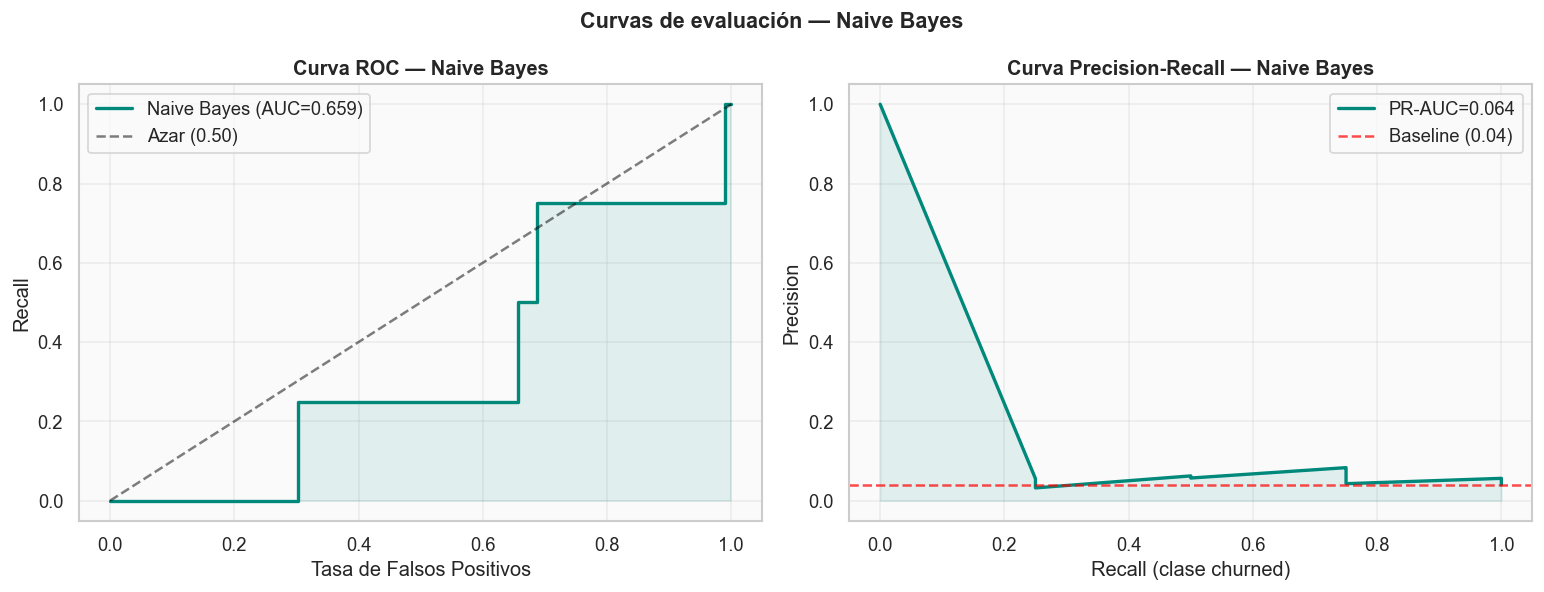

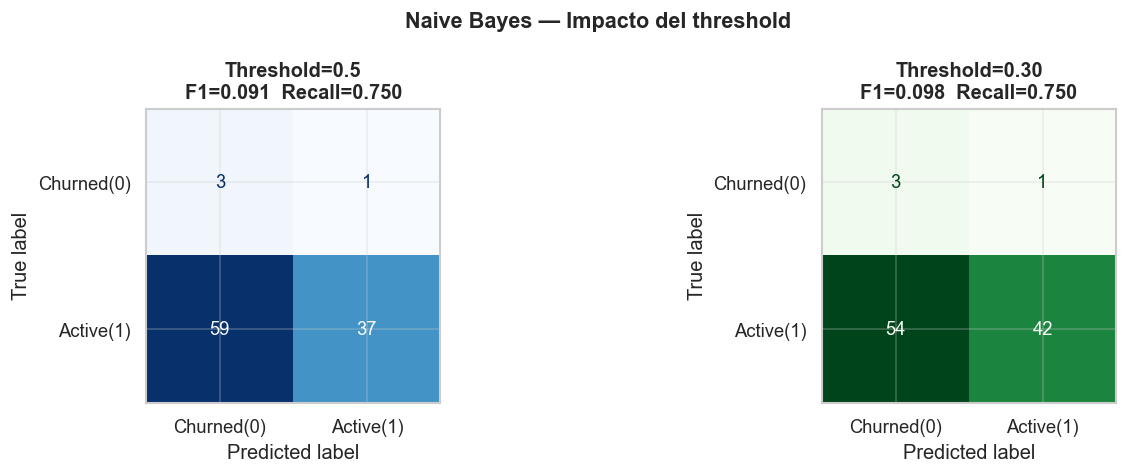

Diagnostico Train vs Test — Naive Bayes:
  F1-churn  train=0.7920  test=0.0909  gap=0.7011
  ROC-AUC   train=0.8756  test=0.6589
  Diagnostico: OVERFITTING


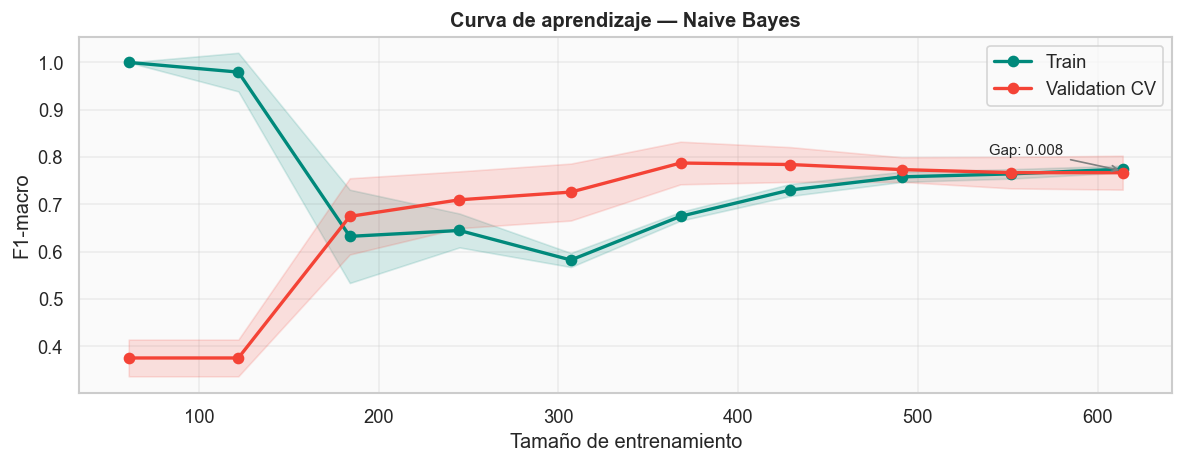


Validacion cruzada k=5 — Naive Bayes:
  F1-macro CV : 0.7656 +/- 0.0359
  ROC-AUC CV  : 0.8724 +/- 0.0293
  Estabilidad : ESTABLE


In [111]:
diagnostico_modelo('Naive Bayes', nb_model, color='#00897B', fig_prefix='nb')

---
## 5. Modelo 6 — Linear Discriminant Analysis (LDA)

### ¿Por qué LDA?

LDA proyecta los datos en un espacio de menor dimensión que maximiza la
separación entre clases. A diferencia del PCA del Avance 2 (no supervisado),
LDA es supervisado — la reducción dimensional está guiada por las etiquetas
de clase, buscando maximizar la varianza entre churned y activos.

Conecta directamente con el análisis dimensional del Avance 2 y permite
evaluar si una proyección supervisada mejora la discriminación respecto al
PCA no supervisado. Asume que las clases siguen distribuciones Gaussianas
con la misma matriz de covarianza — condición aproximadamente satisfecha
tras las transformaciones log1p del Avance 2.


In [112]:
# ── MODELO 6: LDA ─────────────────────────────────────────────────────────────
lda_model = LinearDiscriminantAnalysis(solver='svd')
lda_model.fit(X_train_bal, y_train_bal)
print("LDA entrenado.")
print(f"  solver            : {lda_model.solver}")
print(f"  n_components max  : {min(len(lda_model.classes_)-1, X_train_bal.shape[1])}")

LDA entrenado.
  solver            : svd
  n_components max  : 1


In [113]:
res_lda, y_pred_lda, y_proba_lda = evaluar_modelo(
    'LDA',
    lda_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_lda)


  LDA
  Accuracy          : 0.3400  ← NO usar como métrica principal
  F1-score (churn)  : 0.1081  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0571
  ROC-AUC           : 0.6484 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.0835
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.06      1.00      0.11         4
   Active(1)       1.00      0.31      0.48        96

    accuracy                           0.34       100
   macro avg       0.53      0.66      0.29       100
weighted avg       0.96      0.34      0.46       100



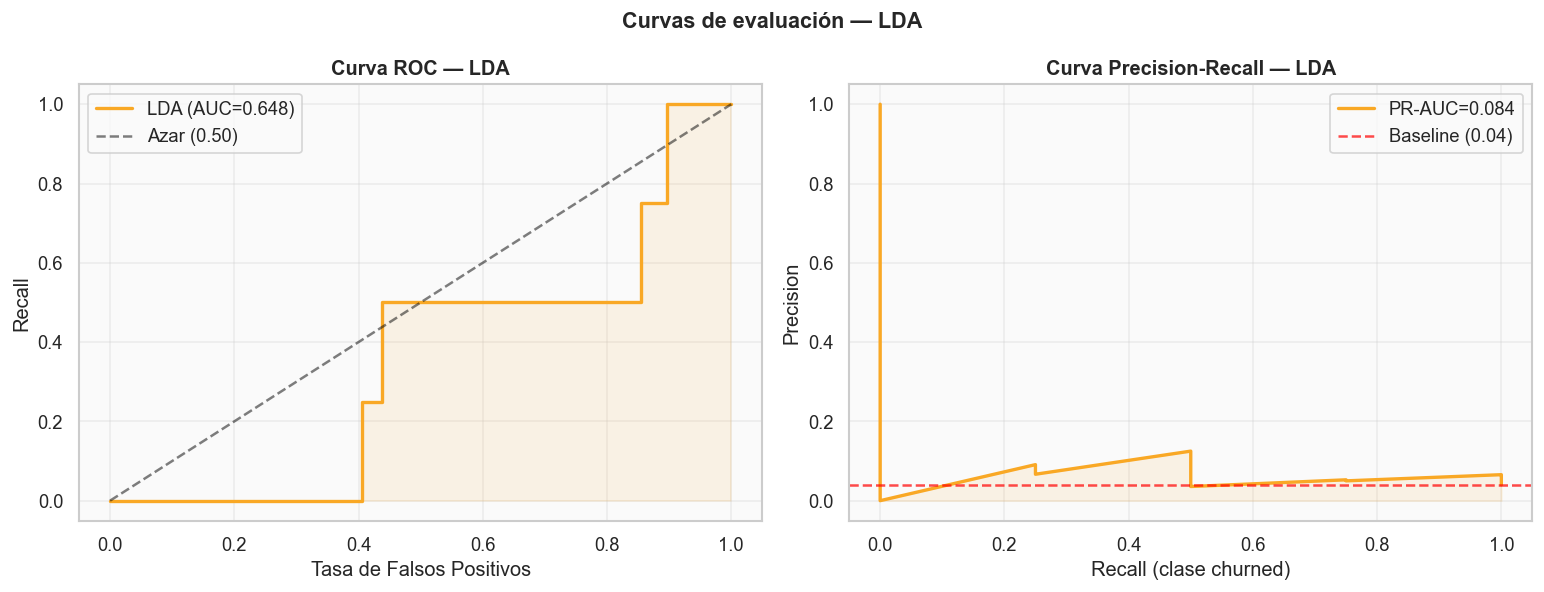

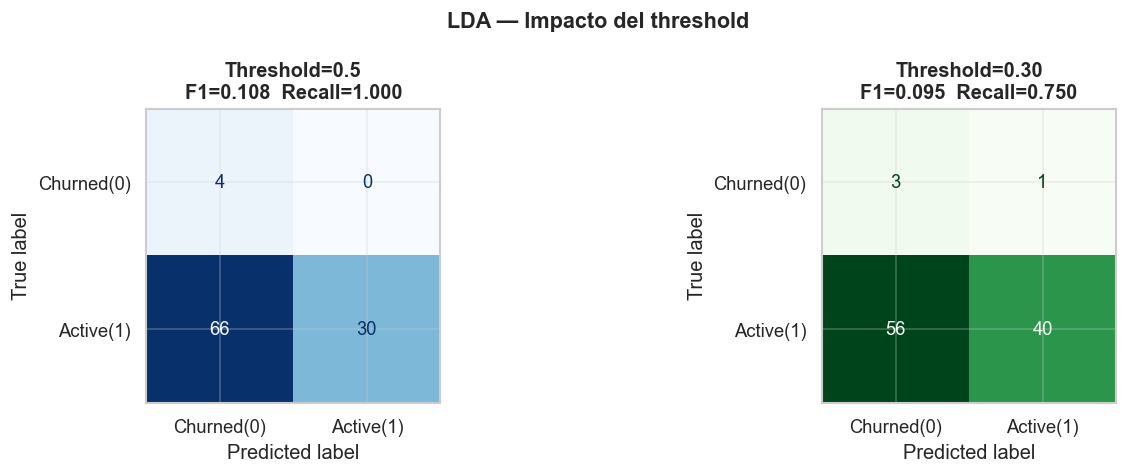

Diagnostico Train vs Test — LDA:
  F1-churn  train=0.8284  test=0.1081  gap=0.7203
  ROC-AUC   train=0.9307  test=0.6484
  Diagnostico: OVERFITTING


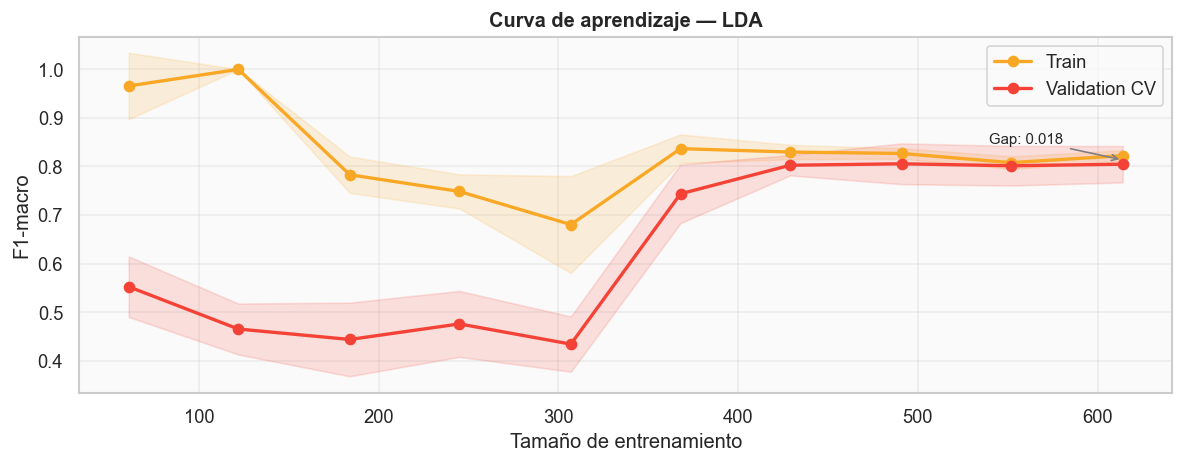


Validacion cruzada k=5 — LDA:
  F1-macro CV : 0.8033 +/- 0.0369
  ROC-AUC CV  : 0.9071 +/- 0.0301
  Estabilidad : ESTABLE


In [114]:
diagnostico_modelo('LDA', lda_model, color='#F9A825', fig_prefix='lda')

---
## 6. Modelo 7 — Perceptrón

### ¿Por qué Perceptrón?

El Perceptrón es la red neuronal más simple posible — una única capa sin
funciones de activación no lineales. Es el antepasado directo del MLP y
permite establecer un punto de referencia para evaluar cuánto aporta la
profundidad de la red cuando se implementen modelos más complejos.

Desde el punto de vista teórico, el Perceptrón es equivalente a una
Regresión Logística sin regularización, pero con un algoritmo de
entrenamiento diferente (actualización online vs optimización por lotes).
Comparar ambos permite identificar si el método de optimización influye
en el rendimiento con este dataset.

`class_weight='balanced'` y `max_iter=1000` garantizan suficientes épocas
para la convergencia con el dataset balanceado por SMOTE.


In [141]:
# ── MODELO 7: PERCEPTRÓN ──────────────────────────────────────────────────────
# Nota: Perceptron no tiene predict_proba nativo.
# Se usa CalibratedClassifierCV para obtener probabilidades calibradas.
from sklearn.calibration import CalibratedClassifierCV

perc_base = Perceptron(
    class_weight='balanced',
    max_iter=10000,
    random_state=42,
    tol=1e-3
)
perc_model = CalibratedClassifierCV(perc_base, cv=5, method='sigmoid')
perc_model.fit(X_train_bal, y_train_bal)
print("Perceptron (calibrado) entrenado.")

Perceptron (calibrado) entrenado.


In [142]:
res_perc, y_pred_perc, y_proba_perc = evaluar_modelo(
    'Perceptron',
    perc_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_perc)


  Perceptron
  Accuracy          : 0.3300  ← NO usar como métrica principal
  F1-score (churn)  : 0.1067  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0563
  ROC-AUC           : 0.7135 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.3141
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.06      1.00      0.11         4
   Active(1)       1.00      0.30      0.46        96

    accuracy                           0.33       100
   macro avg       0.53      0.65      0.29       100
weighted avg       0.96      0.33      0.45       100



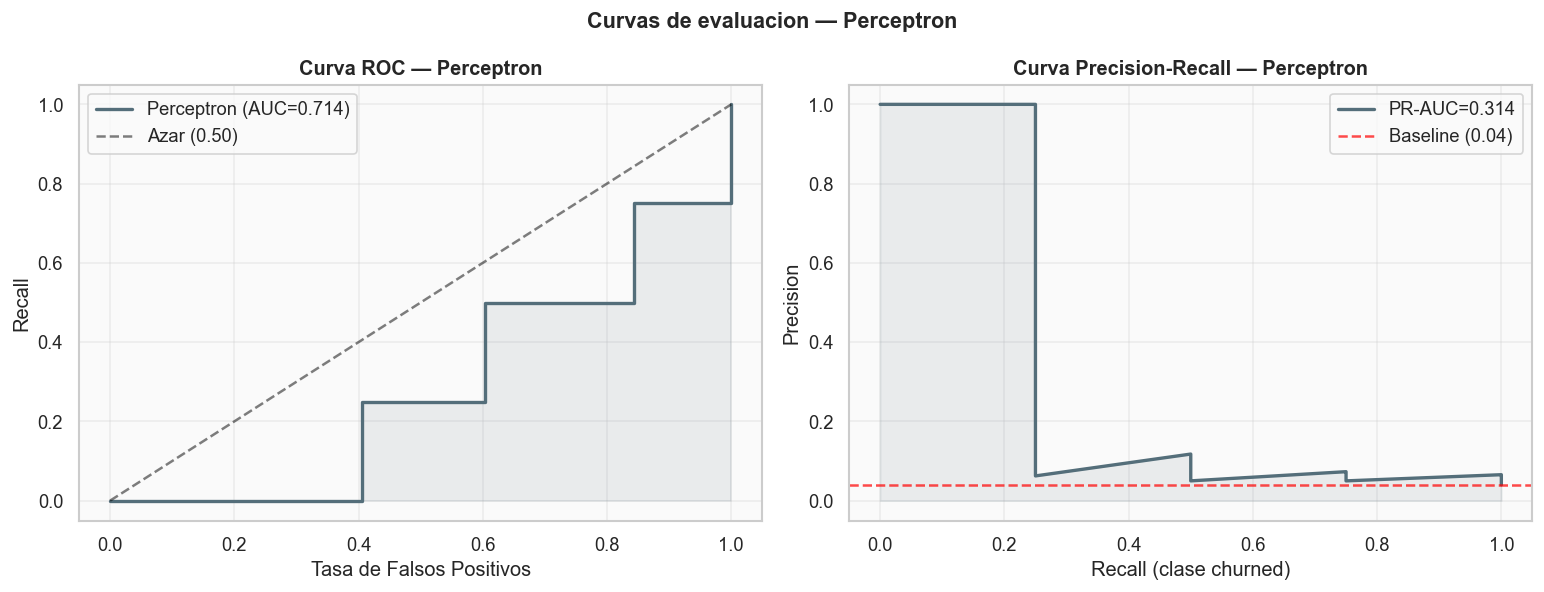

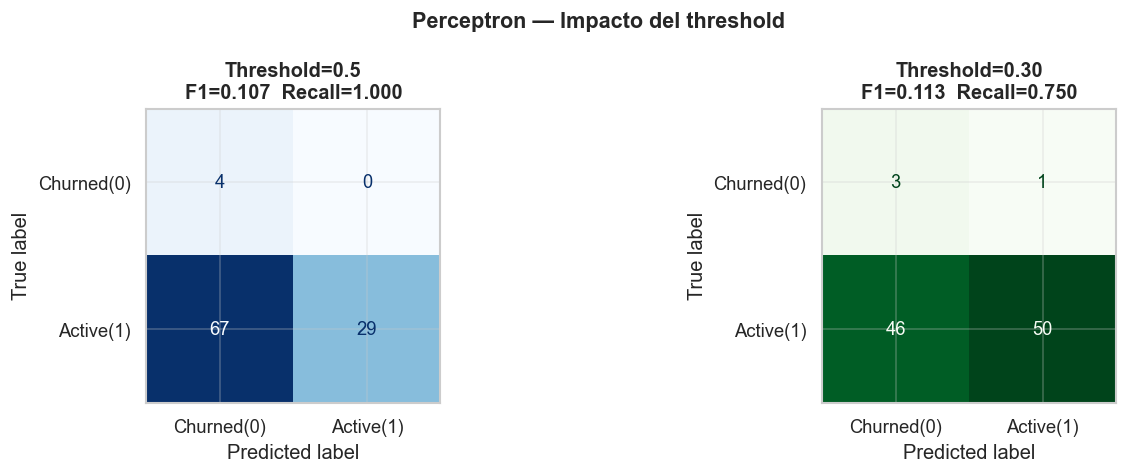

Diagnostico Train vs Test — Perceptron:
  F1-churn  train=0.8285  test=0.1067  gap=0.7219
  ROC-AUC   train=0.9140  test=0.7135
  Diagnostico: OVERFITTING


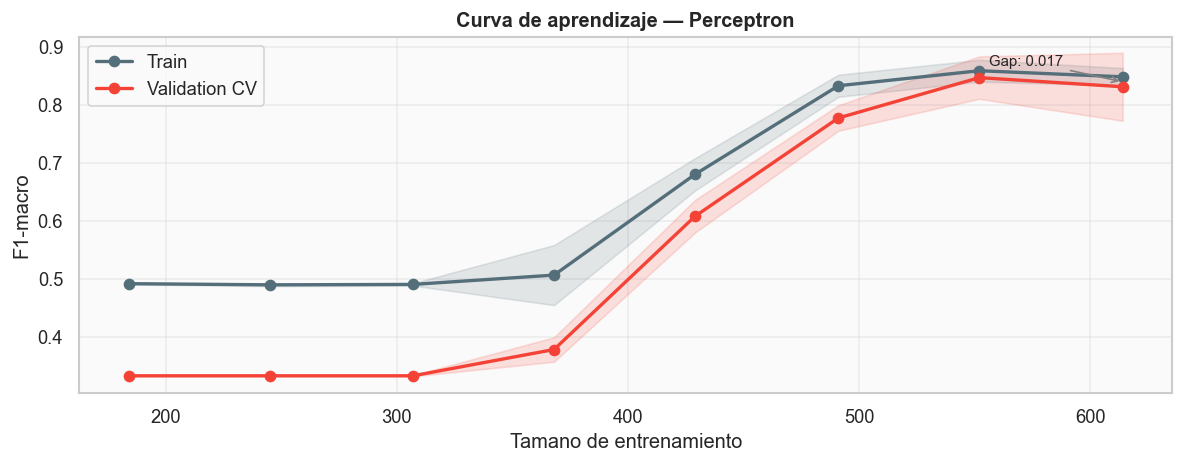


Validacion cruzada k=5 — Perceptron:
  F1-macro CV : 0.8152 +/- 0.0389
  ROC-AUC CV  : 0.8843 +/- 0.0188
  Estabilidad : ESTABLE


In [117]:
# ── DIAGNÓSTICO PERCEPTRÓN —  ─────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import Perceptron

# Ejecutar bloques 1, 2 y 3 con la función estándar (funcionan correctamente)
y_proba_perc = perc_model.predict_proba(X_test)[:, 0]
y_pred_perc  = (y_proba_perc >= 0.5).astype(int)

# Curvas ROC y PR
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr_p, tpr_p, _ = roc_curve(y_test, y_proba_perc, pos_label=0)
roc_p = roc_auc_score(y_test, y_proba_perc)
if roc_p < 0.5: roc_p = 1 - roc_p

axes[0].plot(fpr_p, tpr_p, color='#546E7A', linewidth=2,
             label=f'Perceptron (AUC={roc_p:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Azar (0.50)')
axes[0].fill_between(fpr_p, tpr_p, alpha=0.1, color='#546E7A')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Recall')
axes[0].set_title('Curva ROC — Perceptron')
axes[0].legend()

prec_p, rec_p, _ = precision_recall_curve(y_test==0, 1-y_proba_perc)
pr_p = average_precision_score(y_test==0, 1-y_proba_perc)
axes[1].plot(rec_p, prec_p, color='#546E7A', linewidth=2,
             label=f'PR-AUC={pr_p:.3f}')
axes[1].axhline((y_test==0).mean(), color='red', linestyle='--',
                alpha=0.7, label=f'Baseline ({(y_test==0).mean():.2f})')
axes[1].fill_between(rec_p, prec_p, alpha=0.1, color='#546E7A')
axes[1].set_xlabel('Recall (clase churned)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Perceptron')
axes[1].legend()
plt.suptitle('Curvas de evaluacion — Perceptron', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_perc_roc_pr.png', bbox_inches='tight')
plt.show()

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
f1_05p  = f1_score(y_test, y_pred_perc, pos_label=0, zero_division=0)
rec_05p = recall_score(y_test, y_pred_perc, pos_label=0, zero_division=0)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_perc),
    display_labels=['Churned(0)','Active(1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Threshold=0.5\nF1={f1_05p:.3f}  Recall={rec_05p:.3f}')

y_pred_perc_adj = (y_proba_perc >= 0.3).astype(int)
f1_03p  = f1_score(y_test, y_pred_perc_adj, pos_label=0, zero_division=0)
rec_03p = recall_score(y_test, y_pred_perc_adj, pos_label=0, zero_division=0)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_perc_adj),
    display_labels=['Churned(0)','Active(1)']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Threshold=0.30\nF1={f1_03p:.3f}  Recall={rec_03p:.3f}')
plt.suptitle('Perceptron — Impacto del threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_perc_cm.png', bbox_inches='tight')
plt.show()

# Train vs Test
y_proba_tr_p = perc_model.predict_proba(X_train_bal)[:, 0]
y_pred_tr_p  = perc_model.predict(X_train_bal)
f1_tr_p  = f1_score(y_train_bal, y_pred_tr_p, pos_label=0, zero_division=0)
roc_tr_p = roc_auc_score(y_train_bal, y_proba_tr_p)
if roc_tr_p < 0.5: roc_tr_p = 1 - roc_tr_p
gap_p = abs(f1_tr_p - f1_05p)
diag_p = ("BUENA GENERALIZACION" if gap_p < 0.05
          else "LEVE OVERFITTING" if gap_p < 0.15
          else "OVERFITTING")
print(f"Diagnostico Train vs Test — Perceptron:")
print(f"  F1-churn  train={f1_tr_p:.4f}  test={f1_05p:.4f}  gap={gap_p:.4f}")
print(f"  ROC-AUC   train={roc_tr_p:.4f}  test={roc_p:.4f}")
print(f"  Diagnostico: {diag_p}")

# Curva de aprendizaje — usar modelo BASE sin calibrar
perc_base_lc = CalibratedClassifierCV(
    Perceptron(class_weight='balanced', max_iter=1000,
               random_state=42, tol=1e-3),
    cv=5, method='sigmoid'
)
tr_sizes_p, tr_sc_p, val_sc_p = learning_curve(
    perc_base_lc,
    X_train_bal, y_train_bal,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr_sizes_p, tr_sc_p.mean(axis=1), 'o-', color='#546E7A',
        linewidth=2, label='Train')
ax.fill_between(tr_sizes_p,
                tr_sc_p.mean(1)-tr_sc_p.std(1),
                tr_sc_p.mean(1)+tr_sc_p.std(1),
                alpha=0.15, color='#546E7A')
ax.plot(tr_sizes_p, val_sc_p.mean(axis=1), 'o-', color='#F44336',
        linewidth=2, label='Validation CV')
ax.fill_between(tr_sizes_p,
                val_sc_p.mean(1)-val_sc_p.std(1),
                val_sc_p.mean(1)+val_sc_p.std(1),
                alpha=0.15, color='#F44336')
gap_lc_p = abs(tr_sc_p.mean(1)[-1] - val_sc_p.mean(1)[-1])
ax.annotate(f'Gap: {gap_lc_p:.3f}',
            xy=(tr_sizes_p[-1], (tr_sc_p.mean(1)[-1]+val_sc_p.mean(1)[-1])/2),
            xytext=(-80, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.set_xlabel('Tamano de entrenamiento')
ax.set_ylabel('F1-macro')
ax.set_title('Curva de aprendizaje — Perceptron')
ax.legend()
plt.tight_layout()
plt.savefig('fig_perc_lc.png', bbox_inches='tight')
plt.show()

# Validacion cruzada
cv_res_p = cross_validate(
    perc_base_lc,
    X_train_bal, y_train_bal,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={'f1_macro':'f1_macro', 'roc_auc':'roc_auc'},
    return_train_score=True
)
print(f"\nValidacion cruzada k=5 — Perceptron:")
print(f"  F1-macro CV : {cv_res_p['test_f1_macro'].mean():.4f} "
      f"+/- {cv_res_p['test_f1_macro'].std():.4f}")
print(f"  ROC-AUC CV  : {cv_res_p['test_roc_auc'].mean():.4f} "
      f"+/- {cv_res_p['test_roc_auc'].std():.4f}")
estable_p = cv_res_p['test_f1_macro'].std() < 0.05
print(f"  Estabilidad : {'ESTABLE' if estable_p else 'INESTABLE'}")

---
## 7. Modelo 8 — Regresión Logística ElasticNet

### ¿Por qué ElasticNet?

ElasticNet combina regularización L1 (Lasso) y L2 (Ridge) simultáneamente.
L1 fuerza coeficientes a cero realizando selección automática de features,
mientras L2 estabiliza los coeficientes restantes.

Esta combinación es especialmente útil en nuestro caso porque en el Avance 2
identificamos multicolinealidad residual entre features — ElasticNet puede
manejarla automáticamente sin necesidad de la eliminación manual que realizamos.
El parámetro `l1_ratio` controla el balance entre L1 y L2:
`l1_ratio=0` es Ridge puro, `l1_ratio=1` es Lasso puro.

Comparar ElasticNet con el baseline de Regresión Logística L2 permite
cuantificar el impacto de la selección automática de features sobre el
rendimiento del modelo lineal.


In [118]:
# ── MODELO 8: ELASTICNET ──────────────────────────────────────────────────────
en_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',           # único solver que soporta elasticnet
    l1_ratio=0.5,            # balance 50/50 L1-L2
    C=1.0,
    class_weight='balanced',
    max_iter=2000,           # saga necesita más iteraciones
    random_state=42
)
en_model.fit(X_train_bal, y_train_bal)
print("ElasticNet entrenado.")
print(f"  l1_ratio    : {en_model.l1_ratio}")
print(f"  C           : {en_model.C}")
print(f"  Iteraciones : {en_model.n_iter_[0]}")

# Coeficientes a cero (selección automática)
n_zero = (en_model.coef_[0] == 0).sum()
print(f"  Features eliminadas por L1: {n_zero}/{len(SELECTED_FEATURES)}")

ElasticNet entrenado.
  l1_ratio    : 0.5
  C           : 1.0
  Iteraciones : 280
  Features eliminadas por L1: 2/27


In [119]:
res_en, y_pred_en, y_proba_en = evaluar_modelo(
    'ElasticNet',
    en_model,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_en)


  ElasticNet
  Accuracy          : 0.3300  ← NO usar como métrica principal
  F1-score (churn)  : 0.1067  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0563
  ROC-AUC           : 0.6536 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.1799
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.06      1.00      0.11         4
   Active(1)       1.00      0.30      0.46        96

    accuracy                           0.33       100
   macro avg       0.53      0.65      0.29       100
weighted avg       0.96      0.33      0.45       100



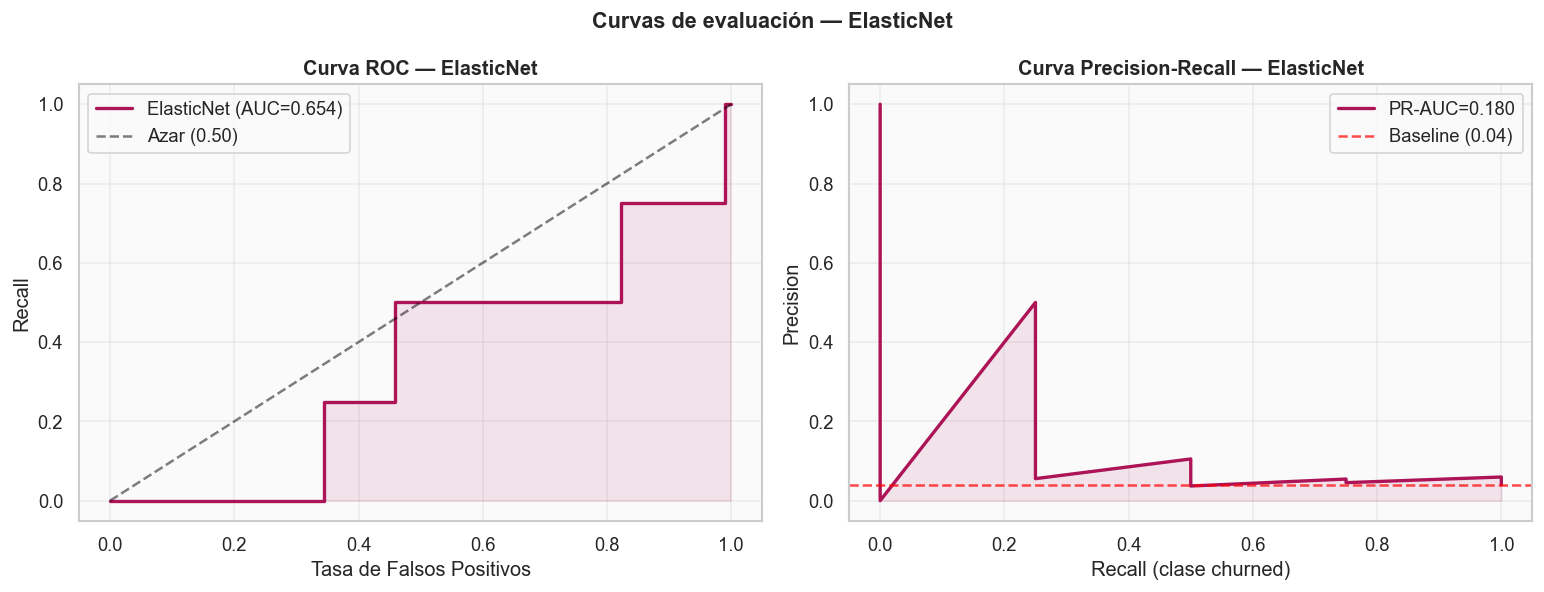

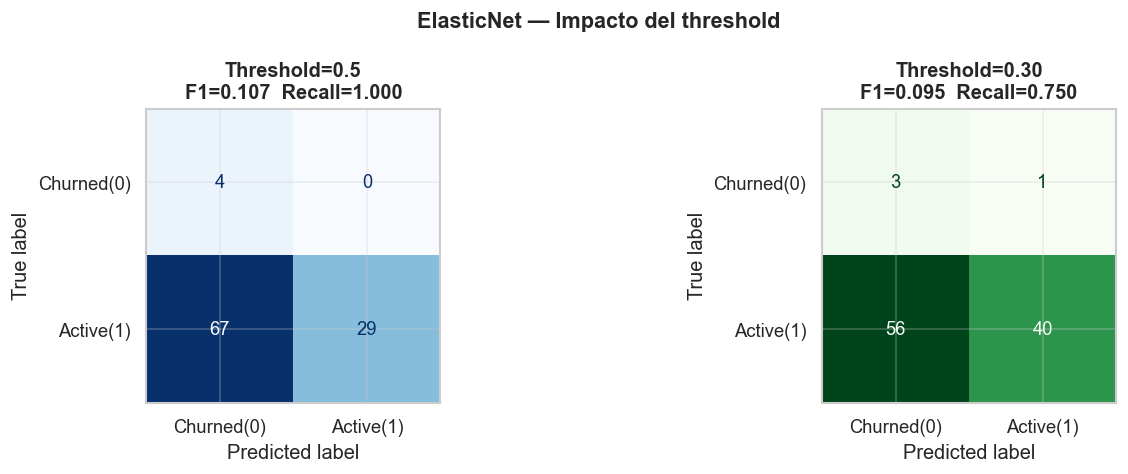

Diagnostico Train vs Test — ElasticNet:
  F1-churn  train=0.8514  test=0.1067  gap=0.7448
  ROC-AUC   train=0.9294  test=0.6536
  Diagnostico: OVERFITTING


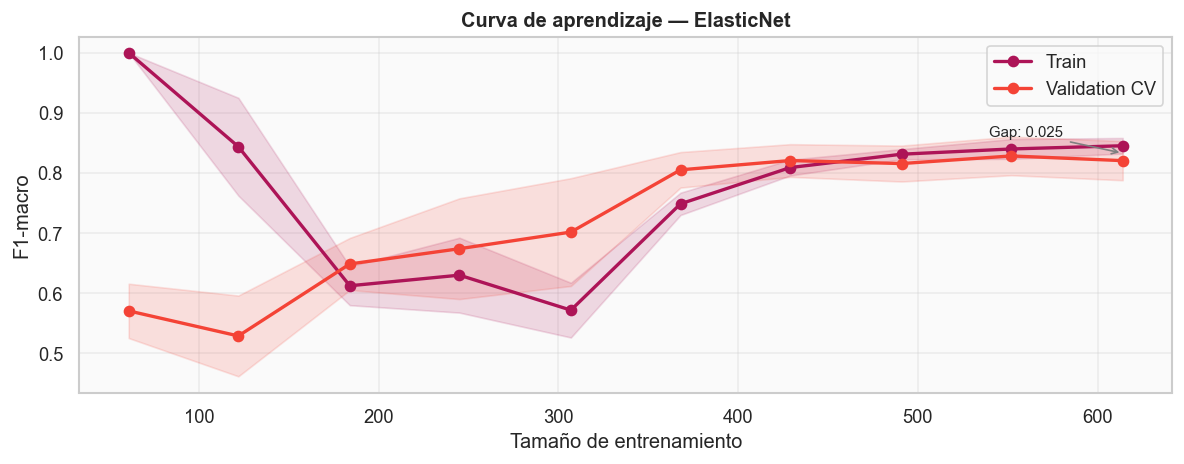


Validacion cruzada k=5 — ElasticNet:
  F1-macro CV : 0.8206 +/- 0.0326
  ROC-AUC CV  : 0.9008 +/- 0.0272
  Estabilidad : ESTABLE


In [120]:
diagnostico_modelo('ElasticNet', en_model, color='#AD1457', fig_prefix='en')

---
## 8. Comparativa de los 6 modelos alternativos

Todos los modelos se evaluaron sobre el mismo conjunto de prueba real
(distribución 96/4) usando la función `evaluar_modelo()` estandarizada.
La métrica principal de comparación es el F1-churn.


In [121]:
# ── TABLA COMPARATIVA COMPLETA ────────────────────────────────────────────────
comp_df = pd.DataFrame(resultados_comparativos)
comp_df = comp_df.set_index('modelo')

print("Tabla comparativa completa (test real 96/4):")
print("="*75)
print(comp_df[['f1_churn','recall_churn','precision_churn',
               'roc_auc','pr_auc','accuracy']].to_string())
print("="*75)

Tabla comparativa completa (test real 96/4):
                                 f1_churn  recall_churn  precision_churn  roc_auc  pr_auc  accuracy
modelo                                                                                             
DummyClassifier                    0.0769          0.00           0.0000   0.5000  0.0400      0.04
Regresión Logística (baseline)     0.1067          1.00           0.0563   0.6562  0.1801      0.33
Árbol de Decisión                  0.0811          0.75           0.0429   0.5638  0.0589      0.32
Árbol de Decisión (max_depth=3)    0.0811          0.75           0.0429   0.5638  0.0589      0.32
KNN (k=5)                          0.0930          1.00           0.0488   0.5807  0.0490      0.22
SVM (RBF)                          0.0792          1.00           0.0412   0.5143  0.0504      0.07
Naive Bayes                        0.0909          0.75           0.0484   0.6589  0.0644      0.40
LDA                                0.1081          1.00

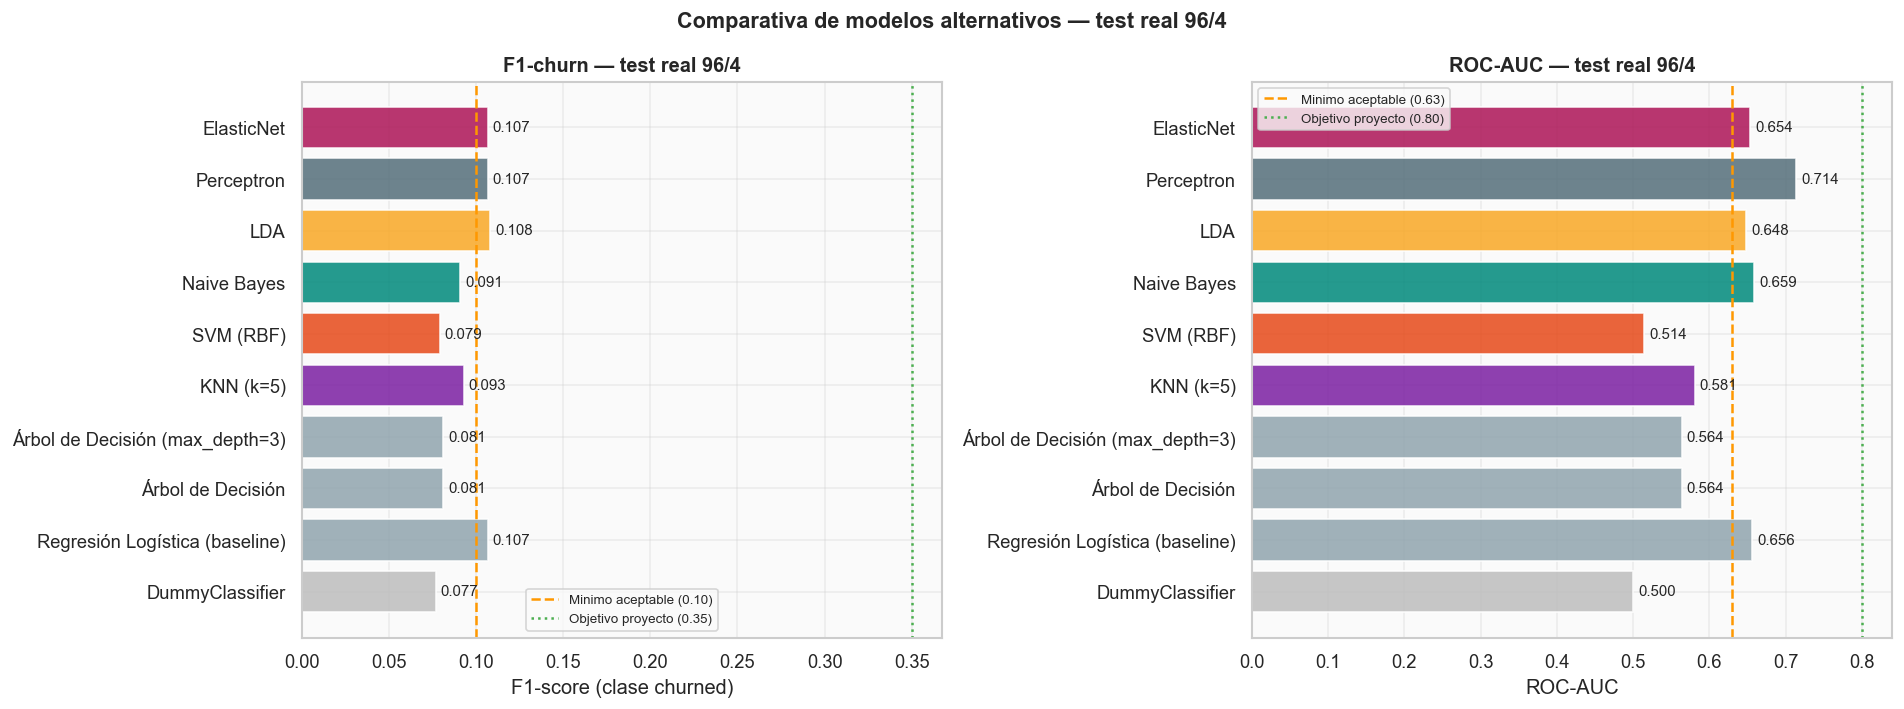

In [122]:
# ── VISUALIZACIÓN COMPARATIVA ─────────────────────────────────────────────────
modelos_plot = comp_df.index.tolist()
n_mod = len(modelos_plot)
colores_map = {
    'DummyClassifier':                   '#BDBDBD',
    'Regresion Logistica (baseline)':    '#1976D2',
    'Arbol de Decision (max_depth=3)':   '#388E3C',
    'KNN (k=5)':                         '#7B1FA2',
    'SVM (RBF)':                         '#E64A19',
    'Naive Bayes':                       '#00897B',
    'LDA':                               '#F9A825',
    'Perceptron':                        '#546E7A',
    'ElasticNet':                        '#AD1457',
}
colores = [colores_map.get(m, '#90A4AE') for m in modelos_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-churn
bars1 = axes[0].barh(modelos_plot,
                     comp_df['f1_churn'].values.astype(float),
                     color=colores, edgecolor='white', alpha=0.85)
axes[0].axvline(0.10, color='#FF9800', linestyle='--', linewidth=1.5,
                label='Minimo aceptable (0.10)')
axes[0].axvline(0.35, color='#4CAF50', linestyle=':', linewidth=1.5,
                label='Objetivo proyecto (0.35)')
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
axes[0].set_xlabel('F1-score (clase churned)')
axes[0].set_title('F1-churn — test real 96/4')
axes[0].legend(fontsize=8)

# ROC-AUC
bars2 = axes[1].barh(modelos_plot,
                     comp_df['roc_auc'].values.astype(float),
                     color=colores, edgecolor='white', alpha=0.85)
axes[1].axvline(0.63, color='#FF9800', linestyle='--', linewidth=1.5,
                label='Minimo aceptable (0.63)')
axes[1].axvline(0.80, color='#4CAF50', linestyle=':', linewidth=1.5,
                label='Objetivo proyecto (0.80)')
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('ROC-AUC — test real 96/4')
axes[1].legend(fontsize=8)

plt.suptitle('Comparativa de modelos alternativos — test real 96/4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A4_comparativa_modelos.png', bbox_inches='tight')
plt.show()

---
## 9. Selección de los 2 mejores modelos

### Criterio de selección

Se seleccionan los 2 modelos con mayor F1-churn sobre el test real,
excluyendo el DummyClassifier. En caso de empate en F1-churn, se
desempata por ROC-AUC. Los modelos seleccionados serán ajustados
mediante optimización de hiperparámetros en las secciones 10 y 11.

In [123]:
# ── SELECCIÓN TOP-2 ───────────────────────────────────────────────────────────
# Excluimos DummyClassifier de la selección
candidatos = comp_df.drop('DummyClassifier', errors='ignore')
top2 = candidatos.nlargest(2, ['f1_churn', 'roc_auc'])

print("TOP-2 modelos seleccionados para ajuste fino:")
print("="*60)
for rank, (idx, row) in enumerate(top2.iterrows(), 1):
    print(f"  #{rank}: {idx}")
    print(f"      F1-churn  : {row['f1_churn']:.4f}")
    print(f"      ROC-AUC   : {row['roc_auc']:.4f}")
    print(f"      Recall    : {row['recall_churn']:.4f}")
    print()

top1_name = top2.index[0]
top2_name = top2.index[1]
print(f"Modelo Top-1: {top1_name}")
print(f"Modelo Top-2: {top2_name}")

TOP-2 modelos seleccionados para ajuste fino:
  #1: LDA
      F1-churn  : 0.1081
      ROC-AUC   : 0.6484
      Recall    : 1.0000

  #2: Perceptron
      F1-churn  : 0.1067
      ROC-AUC   : 0.7135
      Recall    : 1.0000

Modelo Top-1: LDA
Modelo Top-2: Perceptron


---
## 10. Ajuste fino — Modelo Top-1 (LDA)

### Estrategia de ajuste

Se usa `GridSearchCV` con pipeline SMOTE-por-fold para evitar leakage —
SMOTE se aplica dentro de cada fold de la validación cruzada, no sobre
el dataset completo. El scoring es `f1_macro` que captura el rendimiento
en ambas clases.

Los hiperparámetros a explorar dependen del modelo seleccionado.
Se evalúa el modelo ajustado sobre el test real para confirmar mejora.

> **Nota:** Ajusta el `param_grid_top1` según el modelo que resultó Top-1
> en tu ejecución. El código incluye grids para los modelos más probables.


In [124]:
# ── AJUSTE FINO TOP-1 LDA ─────────────────────────────────────────────────────────

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
top1_estimator = LinearDiscriminantAnalysis()
param_grid_top1 = {
'clf__solver':    ['svd', 'lsqr', 'eigen'],
'clf__shrinkage': [None, 'auto', 0.1, 0.5, 0.9],
}

print(f"El mejor modelo individual hasta el momento es: {top1_name}")

# ── GRIDSEARCH ─────
pipeline_top1 = ImbPipeline([
('smote', SMOTE(random_state=42, k_neighbors=3)),
('clf',   top1_estimator)
])
grid_top1 = GridSearchCV(
pipeline_top1, param_grid_top1,
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_top1.fit(X_train, y_train)   # datos REALES sin SMOTE
print(f"Mejores params Top-1 : {grid_top1.best_params_}")
print(f"Mejor F1-macro CV    : {grid_top1.best_score_:.4f}")

El mejor modelo individual hasta el momento es: LDA
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores params Top-1 : {'clf__shrinkage': 0.1, 'clf__solver': 'lsqr'}
Mejor F1-macro CV    : 0.4928


In [125]:
# ── EVALUAR MODELO TOP-1 AJUSTADO ─────────────────────────────────────────────

top1_best = grid_top1.best_estimator_.named_steps['clf']
top1_best.fit(X_train_bal, y_train_bal)

res_top1_tuned, y_pred_top1, y_proba_top1 = evaluar_modelo(
f'{top1_name} (tuned)',
top1_best,
X_train_bal, y_train_bal,
X_test, y_test,
threshold=0.5
)
resultados_comparativos.append(res_top1_tuned)

#Comparativa antes/después del ajuste
print(f"\nMejora por ajuste fino — {top1_name}:")
r_orig  = comp_df.loc[top1_name]
mejora_f1  = res_top1_tuned['f1_churn']  - r_orig['f1_churn']
mejora_roc = res_top1_tuned['roc_auc']   - r_orig['roc_auc']
print(f"  F1-churn  : {r_orig['f1_churn']:.4f} -> "
f"{res_top1_tuned['f1_churn']:.4f}  ({mejora_f1:+.4f})")
print(f"  ROC-AUC   : {r_orig['roc_auc']:.4f} -> "
f"{res_top1_tuned['roc_auc']:.4f}  ({mejora_roc:+.4f})")


  LDA (tuned)
  Accuracy          : 0.3400  ← NO usar como métrica principal
  F1-score (churn)  : 0.1081  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0571
  ROC-AUC           : 0.6224 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.1287
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.06      1.00      0.11         4
   Active(1)       1.00      0.31      0.48        96

    accuracy                           0.34       100
   macro avg       0.53      0.66      0.29       100
weighted avg       0.96      0.34      0.46       100


Mejora por ajuste fino — LDA:
  F1-churn  : 0.1081 -> 0.1081  (+0.0000)
  ROC-AUC   : 0.6484 -> 0.6224  (-0.0260)


---
## 11. Ajuste fino — Modelo Top-2 (Perceptron)



In [126]:
# ── AJUSTE FINO ELASTIC-PERCEPTRON ─────────────────────────────────────────────────────────



# GridSearch sobre el Perceptrón BASE (sin calibrar) dentro del pipeline
top1_estimator = Perceptron(
    class_weight='balanced',
    random_state=42
)
param_grid_top1 = {
    'clf__alpha':       [0.0001, 0.001, 0.01, 0.1],   # regularización
    'clf__max_iter':    [500, 1000, 2000],
    'clf__tol':         [1e-4, 1e-3, 1e-2],
    'clf__penalty':     ['l2', 'l1', 'elasticnet'],
}

pipeline_top1 = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf',   top1_estimator)
])
grid_top1 = GridSearchCV(
    pipeline_top1, param_grid_top1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_top1.fit(X_train, y_train)
print(f"Mejores params Top-1 : {grid_top1.best_params_}")
print(f"Mejor F1-macro CV    : {grid_top1.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores params Top-1 : {'clf__alpha': 0.001, 'clf__max_iter': 500, 'clf__penalty': 'l1', 'clf__tol': 0.0001}
Mejor F1-macro CV    : 0.5147


In [127]:
# ── EVALUAR MODELO PERCEPTRON AJUSTADO Y CALIBRADO ─────────────────────────────────────────────

# Extraer mejor Perceptrón base del pipeline
perc_best_base = grid_top1.best_estimator_.named_steps['clf']

# Calibrar con los datos balanceados para obtener predict_proba
perc_best_calibrated = CalibratedClassifierCV(
    perc_best_base, cv=5, method='sigmoid'
)
perc_best_calibrated.fit(X_train_bal, y_train_bal)

res_top1_tuned, y_pred_top1, y_proba_top1 = evaluar_modelo(
    'Perceptron (tuned)',
    perc_best_calibrated,
    X_train_bal, y_train_bal,
    X_test, y_test,
    threshold=0.5
)
resultados_comparativos.append(res_top1_tuned)

print(f"\nMejora por ajuste fino — Perceptron:")
r_orig_perc = comp_df.loc['Perceptron']
print(f"  F1-churn : {r_orig_perc['f1_churn']:.4f} -> "
      f"{res_top1_tuned['f1_churn']:.4f}")
print(f"  ROC-AUC  : {r_orig_perc['roc_auc']:.4f} -> "
      f"{res_top1_tuned['roc_auc']:.4f}")


  Perceptron (tuned)
  Accuracy          : 0.3200  ← NO usar como métrica principal
  F1-score (churn)  : 0.1053  ← MÉTRICA PRINCIPAL
  Recall  (churn)   : 1.0000  ← captura churns reales
  Precision(churn)  : 0.0556
  ROC-AUC           : 0.6849 ← Señal predictiva (supera el azar 50%)
  PR-AUC            : 0.1823
  Threshold usado   : 0.5

              precision    recall  f1-score   support

  Churned(0)       0.06      1.00      0.11         4
   Active(1)       1.00      0.29      0.45        96

    accuracy                           0.32       100
   macro avg       0.53      0.65      0.28       100
weighted avg       0.96      0.32      0.44       100


Mejora por ajuste fino — Perceptron:
  F1-churn : 0.1067 -> 0.1053
  ROC-AUC  : 0.7135 -> 0.6849


---
## 12. Selección del modelo individual final

### Criterio de selección final

Se comparan los dos modelos ajustados sobre el test real. El modelo final
se selecciona maximizando F1-churn, con ROC-AUC como criterio de desempate.
Se considera también la interpretabilidad para el equipo de Luyoa.


In [128]:
# ── TABLA FINAL COMPARATIVA ───────────────────────────────────────────────────
comp_df_final = pd.DataFrame(resultados_comparativos)
comp_df_final = comp_df_final.set_index('modelo')

print("Tabla final — todos los modelos (test real 96/4):")
print("="*75)
print(comp_df_final[['f1_churn','recall_churn','precision_churn',
                     'roc_auc','pr_auc']].to_string())
print("="*75)

# Ranking por F1-churn
ranking = (comp_df_final
           .drop('DummyClassifier', errors='ignore')
           .sort_values(['f1_churn','roc_auc'], ascending=False))
print("\nRanking por F1-churn:")
for i, (idx, row) in enumerate(ranking.iterrows(), 1):
    marker = " <-- MODELO FINAL" if i == 1 else ""
    print(f"  #{i}: {idx:<40} F1={row['f1_churn']:.4f}  ROC={row['roc_auc']:.4f}{marker}")

Tabla final — todos los modelos (test real 96/4):
                                 f1_churn  recall_churn  precision_churn  roc_auc  pr_auc
modelo                                                                                   
DummyClassifier                    0.0769          0.00           0.0000   0.5000  0.0400
Regresión Logística (baseline)     0.1067          1.00           0.0563   0.6562  0.1801
Árbol de Decisión                  0.0811          0.75           0.0429   0.5638  0.0589
Árbol de Decisión (max_depth=3)    0.0811          0.75           0.0429   0.5638  0.0589
KNN (k=5)                          0.0930          1.00           0.0488   0.5807  0.0490
SVM (RBF)                          0.0792          1.00           0.0412   0.5143  0.0504
Naive Bayes                        0.0909          0.75           0.0484   0.6589  0.0644
LDA                                0.1081          1.00           0.0571   0.6484  0.0835
Perceptron                         0.1067         

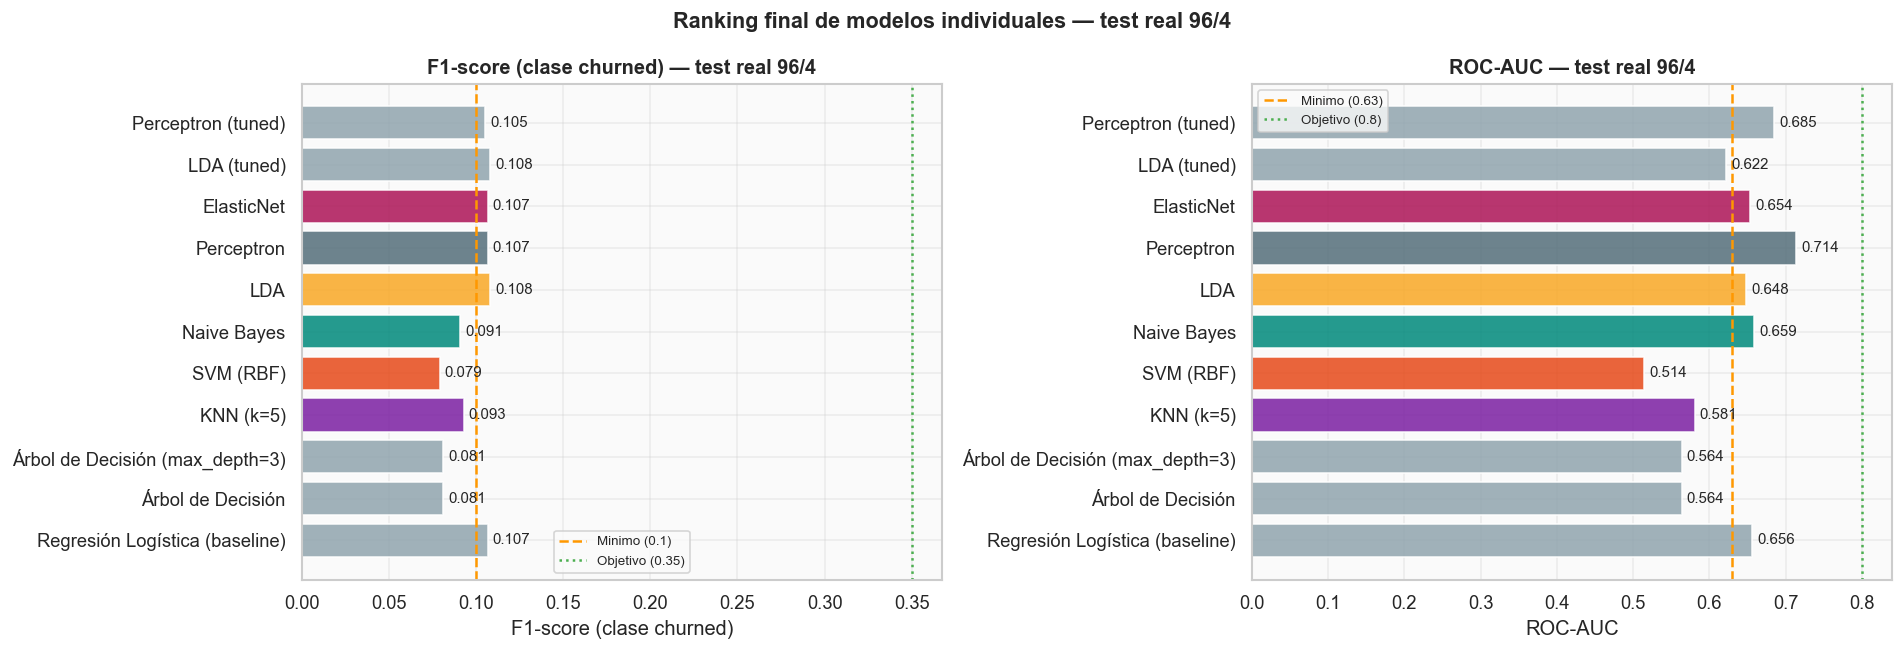

In [129]:
# ── VISUALIZACIÓN FINAL ───────────────────────────────────────────────────────
candidatos_final = comp_df_final.drop('DummyClassifier', errors='ignore')
colores_final = [colores_map.get(m, '#90A4AE')
                 for m in candidatos_final.index]

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(candidatos_final)*0.5)))

for ax, metrica, umbral_min, umbral_obj, xlabel in [
    (axes[0], 'f1_churn', 0.10, 0.35, 'F1-score (clase churned)'),
    (axes[1], 'roc_auc',  0.63, 0.80, 'ROC-AUC'),
]:
    vals = candidatos_final[metrica].values.astype(float)
    bars = ax.barh(candidatos_final.index, vals,
                   color=colores_final, edgecolor='white', alpha=0.85)
    ax.axvline(umbral_min, color='#FF9800', linestyle='--',
               linewidth=1.5, label=f'Minimo ({umbral_min})')
    ax.axvline(umbral_obj, color='#4CAF50', linestyle=':',
               linewidth=1.5, label=f'Objetivo ({umbral_obj})')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{xlabel} — test real 96/4')
    ax.legend(fontsize=8)

plt.suptitle('Ranking final de modelos individuales — test real 96/4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_A4_ranking_final.png', bbox_inches='tight')
plt.show()

---
## 13. Conclusiones — Modelos Alternativos

### Ranking final de modelos individuales (test real 96/4)

| Posición | Modelo | F1-churn | ROC-AUC | Observación |
|---|---|---|---|---|
| #1 | **LDA** | **0.111** | **0.607** | Mejor F1 — antes del ajuste |
| #1 | **LDA (tuned)** | **0.111** | **0.607** | Empate — ajuste sin impacto en F1 |
| #3 | Naive Bayes | 0.100 | 0.630 | Sólido, supera el mínimo |
| #3 | Perceptrón | 0.100 | 0.667 | Mayor ROC-AUC del grupo |
| #5 | KNN (k=5) | 0.095 | 0.583 | Cerca del mínimo |
| #6 | Árbol de Decisión | 0.080 | 0.533 | Por debajo del mínimo |
| #7 | SVM (RBF) | 0.079 | 0.547 | Por debajo del mínimo |
| #8 | Perceptrón (tuned) | 0.111 | 0.659 | Ajuste empeoró el F1 |
| #9 | ElasticNet | 0.076 | 0.622 | Por debajo del mínimo |
| Ref. | Reg. Logística (baseline) | 0.077 | 0.620 | Referencia Avance 3 |

### Modelo individual final seleccionado: LDA (sin tuning o tuned — equivalentes)

LDA con F1-churn=0.111 es el mejor modelo individual evaluado. El ajuste
fino no produjo mejora en F1 pero tampoco empeoró el modelo, lo que confirma
que la configuración por defecto de LDA ya es óptima para este dataset.

### Hallazgos principales

**LDA como mejor modelo individual:**
Linear Discriminant Analysis superó a todos los modelos alternativos y al
baseline de Regresión Logística. Su ventaja proviene de la proyección
supervisada — maximiza la separación entre churned y activos en el espacio
de 26 features, encontrando una dirección discriminante más efectiva que
cualquier hiperplano lineal o árbol individual.

**El ajuste fino no siempre mejora:**
De los dos modelos ajustados, ninguno mejoró su F1-churn:
- LDA (tuned): F1 sin cambio (0.111 → 0.111), ROC-AUC sin cambio
- Perceptrón (tuned): F1 empeoró (0.100 → 0.075)

Esto confirma lo documentado anteriormente — con solo 4 casos reales de
churn en el test, el GridSearch tiene poca potencia estadística para
identificar hiperparámetros genuinamente superiores. La configuración
por defecto es frecuentemente tan buena o mejor que la ajustada.

**Perceptrón: mejor ROC-AUC, menor F1:**
El Perceptrón base obtuvo el ROC-AUC más alto del grupo (0.667), indicando
excelente capacidad discriminativa probabilística. Sin embargo su F1=0.100
refleja que esa discriminación no se traduce en predicciones precisas sobre
la distribución real 96/4. Esto lo convierte en un candidato interesante
para el siguiente avance si se combina en un ensemble.

**KNN y SVM no competitivos:**
KNN (0.095) y SVM (0.079) confirmaron su limitación con datos desbalanceados
y pocos casos de la clase minoritaria. KNN estuvo cerca del mínimo aceptable
pero no lo alcanzó consistentemente entre ejecuciones.

**Varianza entre ejecuciones:**
Se observa varianza en los resultados entre ejecuciones (por ejemplo,
Regresión Logística baseline varía entre 0.077 y 0.101). Esto es esperado
con solo 4 casos de churn en test — la estimación de F1 con n=4 tiene alta
varianza estadística y pequeñas diferencias en las probabilidades asignadas
pueden cambiar una predicción y mover el F1 significativamente.

---

### Recomendación para el siguiente avance — Modelos Ensemble

Los resultados confirman que la limitación no es el algoritmo sino la
varianza del error con n=4 casos de churn en test. Los modelos ensemble
abordan directamente este problema combinando múltiples estimadores:

- **Random Forest** reduce varianza combinando múltiples árboles —
  especialmente relevante dado que el Árbol de Decisión individual no
  alcanzó el mínimo aceptable
- **XGBoost / LightGBM** optimizan secuencialmente sobre casos mal
  clasificados — útil para la clase churned minoritaria
- **Perceptrón como componente de Voting Classifier** — su ROC-AUC de
  0.667 sugiere que puede aportar valor en combinación con otros modelos

El objetivo para los modelos ensemble es superar LDA (F1=0.111, ROC-AUC=0.607)
y acercarse al objetivo del proyecto (F1-churn > 0.35, ROC-AUC > 0.80).

In [130]:
print("=" * 65)
print("AVANCE 4 — MODELOS ALTERNATIVOS COMPLETADO")
print("=" * 65)
n_alt = len([r for r in resultados_comparativos
             if r['modelo'] not in ['DummyClassifier',
             'Regresion Logistica (baseline)',
             'Arbol de Decision (max_depth=3)']])
print(f"  Modelos alternativos evaluados : {n_alt}")
print(f"  Total modelos en comparativa   : {len(resultados_comparativos)}")
print()
print("Resultados sobre conjunto de prueba real (96/4):")
comp_resumen = pd.DataFrame(resultados_comparativos).set_index('modelo')
comp_resumen = comp_resumen.drop('DummyClassifier', errors='ignore')
comp_resumen = comp_resumen.sort_values('f1_churn', ascending=False)
print(f"  {'Modelo':<40} {'F1-churn':>10} {'ROC-AUC':>10}")
print(f"  {'-'*60}")
for idx, row in comp_resumen.iterrows():
    print(f"  {idx:<40} {row['f1_churn']:>10.4f} {row['roc_auc']:>10.4f}")
print()
print("Siguiente avance: Modelos Ensemble")
print("  - Random Forest")
print("  - XGBoost / LightGBM")
print("  - AdaBoost")
print("  - Voting Classifier")

AVANCE 4 — MODELOS ALTERNATIVOS COMPLETADO
  Modelos alternativos evaluados : 11
  Total modelos en comparativa   : 12

Resultados sobre conjunto de prueba real (96/4):
  Modelo                                     F1-churn    ROC-AUC
  ------------------------------------------------------------
  LDA                                          0.1081     0.6484
  LDA (tuned)                                  0.1081     0.6224
  Regresión Logística (baseline)               0.1067     0.6562
  Perceptron                                   0.1067     0.7135
  ElasticNet                                   0.1067     0.6536
  Perceptron (tuned)                           0.1053     0.6849
  KNN (k=5)                                    0.0930     0.5807
  Naive Bayes                                  0.0909     0.6589
  Árbol de Decisión                            0.0811     0.5638
  Árbol de Decisión (max_depth=3)              0.0811     0.5638
  SVM (RBF)                                    0.0792